# Machine maintenance ML model

This notebook is a work regarding an analysis of predictive machine maintenance.

The goal here is to identify if a mahcine is about to fail or not, and provide information for the plant maintenance team when to take action in the machines.

In the first part of the lab, we will make simple analysis of the dataset, verifying the following:

1. Simple dataset analysis;
2. Run a logistic regression model without taking into account some crucial data characteristics (highly unbalanced data);
3. Run a pipeline to assess the best model to be used in the prediction if a machine is failing or not;
4. check if it is possible to determine what kind of issue the machine is going through.

The dataset used can be found in the following URL: https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip

This notebook will not cover multivariate analysis, meaning that we will check only if the machine fails, leaving the causes to another notebook.


In [100]:
import pandas as pd
import zipfile
import numpy as np
import io
import os
import requests
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from imblearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, make_scorer
)
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE,SVMSMOTE,RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import optuna
from sklearn.metrics import matthews_corrcoef, make_scorer
import shap
from sklearn.base import clone

In [2]:
URL = 'https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip'
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(URL, headers=headers)

In [3]:
zip_buffer = io.BytesIO(response.content)
with zipfile.ZipFile(zip_buffer) as z:     
    csv_files = z.namelist()
    print(f"Arquivos encontrados: {csv_files}")
    f = z.open(csv_files[0])
    print(f"Carregando: {f}...")
    df = pd.read_csv(f)

Arquivos encontrados: ['ai4i2020.csv']
Carregando: <zipfile.ZipExtFile name='ai4i2020.csv' mode='r'>...


## Data analysis

To begin the analysis, we are using the polars database. It is not strictly needed, since our dataset does not contain a high amount of data. In the next steps, we are going to transform them into pandas, to avoid any errors due to compatibility with scikit learn

In [4]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


At this point, we are going only to check if the machine is about to fail or not. So we are not going to use the columns TWF, HDF, PWF, OSF, RNF at this point. More details about them, can be found in the link of the dataset

In [5]:
X = df[['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Tool wear [min]','Type','Torque [Nm]']]
Y = df[['Machine failure']]


<Axes: xlabel='Process temperature [K]', ylabel='Torque [Nm]'>

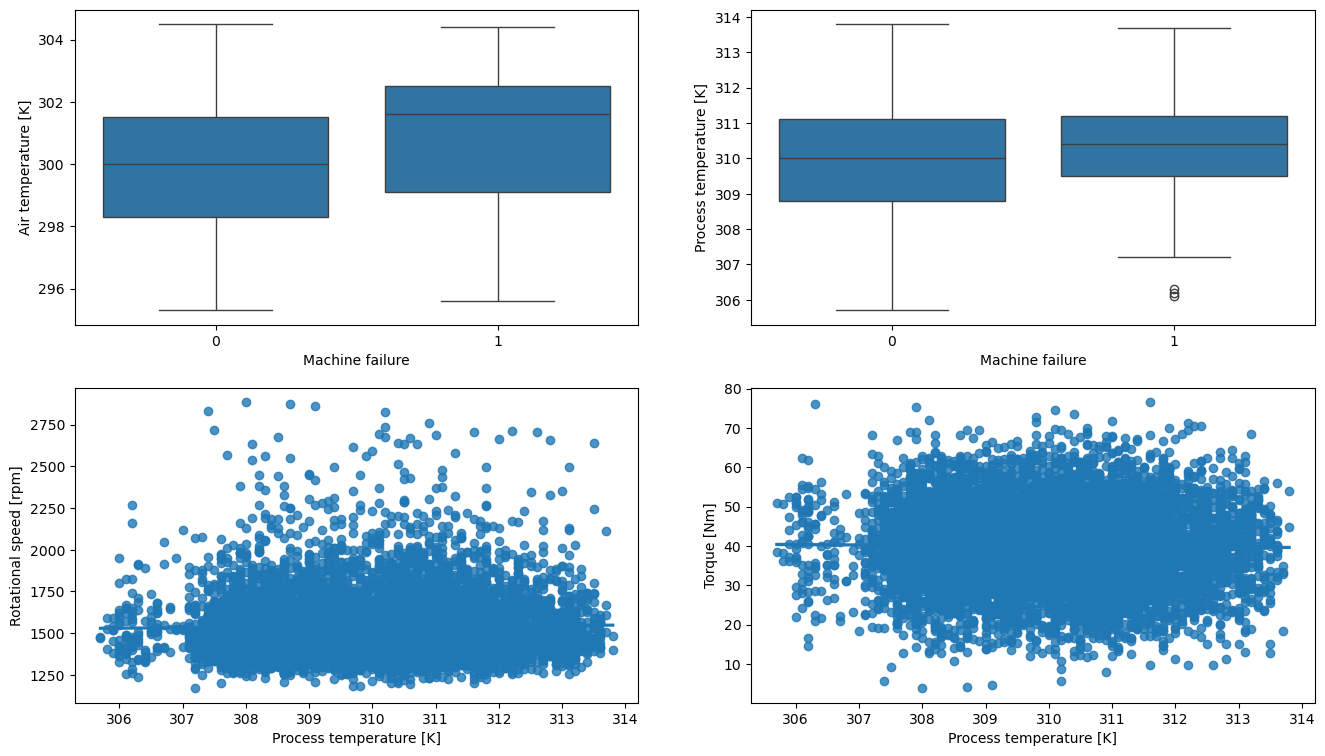

In [6]:
fig, ax = plt.subplots(2,2, figsize=(16,9))

sns.boxplot(data=df, x='Machine failure', y="Air temperature [K]", ax = ax[0][0])
sns.boxplot(data=df, x='Machine failure', y="Process temperature [K]", ax = ax[0][1])
sns.regplot(data=df, x='Process temperature [K]', y="Rotational speed [rpm]", ax = ax[1][0])
sns.regplot(data=df, x='Process temperature [K]', y="Torque [Nm]", ax = ax[1][1])


As seen, there are some diferences in the process temperature, when we check when the machine fails, with some outliars in it. Air temperature seems to be a bit higher also when we the process fails. Other than that, both rotational speed and torque does not seem to have any correlation with process temperature.

In the next step, we are going to perform logistic regressions:
1. the first case, we will not consider the unbalanced dataset, just to show how important it is to verify this to avoid any misconclusions.
2. The second time, we are going to perform the regression considering a balanced dataset.

Also, before moving forward, let's check variable correlations:

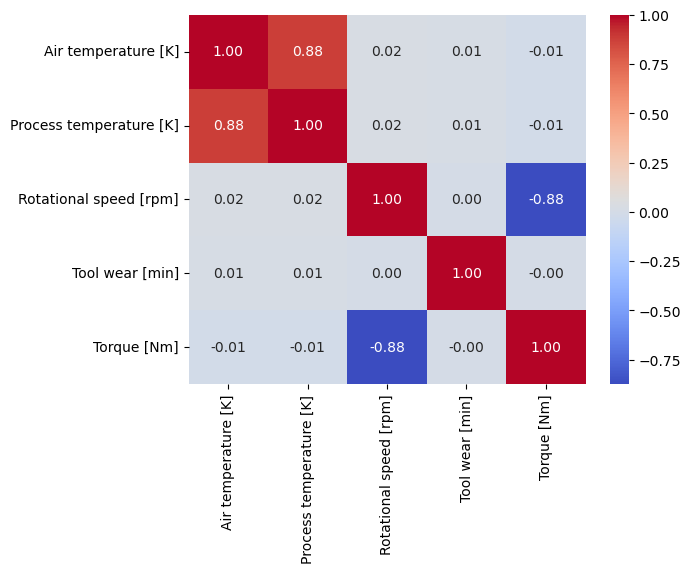

In [7]:
sns.heatmap(X.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

### Correlation analysys

It seems that both Air and Process Temperatures are correlated, meaning that they may be combined into a single column.
Also, Rotational Speed and Torque are correlated. Actually, their product is the POWER of the machine. So it may be an important feature to be created.

And the Temperatures may be related through their difference: hotter days may have hotter processes temperature, and when this pattern breaks, it may signal a potential failure

In [8]:
X['Temp_Diff'] = X['Air temperature [K]'] - X['Process temperature [K]']
X['Power'] = X['Torque [Nm]']*X['Rotational speed [rpm]']
X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Tool wear [min],Type,Torque [Nm],Temp_Diff,Power
0,298.1,308.6,1551,0,M,42.8,-10.5,66382.8
1,298.2,308.7,1408,3,L,46.3,-10.5,65190.4
2,298.1,308.5,1498,5,L,49.4,-10.4,74001.2
3,298.2,308.6,1433,7,L,39.5,-10.4,56603.5
4,298.2,308.7,1408,9,L,40.0,-10.5,56320.0


## Pipeline build

Now that our features seems ready, let's build our pipeline:
it will be composed of:
Train test split;

Standard Scaler for continuous variables;
Ordinal Scaler for Type variable, with increasing importance from L->M->H;

Classifier (Logistic Regressor) without imbalance analysis

our score method will be f1-weighted, as accuracy will lead to no correct predictions due to high data imbalance

We will store our data in a dictionary, called pipelines_results, to compare with further analysis in this Notebook

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')
pipelines_resultados = {}
mcc_scorer = make_scorer(matthews_corrcoef)
scores = {
        'mcc': mcc_scorer,
        'f1': 'f1',
        'roc_auc': 'roc_auc'
        }


x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size = 0.2, random_state = 1,stratify = Y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

features_continuas = X.drop(columns = 'Type').columns.tolist()
features_categoricas = ['Type']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_continuas),
        ('cat', OrdinalEncoder(categories = [['L', 'M', 'H']]), features_categoricas)
    ])

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight = None)) 
])

pipelines_resultados['LR_baseline'] = [pipe,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = scores,return_train_score=True),classification_report(y_test,pipe.predict(x_test)),confusion_matrix(y_test,pipe.predict(x_test))]


Let's check some of our model results:

In [10]:
print(f"Train Score MCC :{pipelines_resultados['LR_baseline'][3]['train_mcc'].mean():.3f}\nValidation Score MCC :{pipelines_resultados['LR_baseline'][3]['test_mcc'].mean():.3f}")
print(pipelines_resultados['LR_baseline'][4])

Train Score MCC :0.408
Validation Score MCC :0.395
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.70      0.21      0.32        68

    accuracy                           0.97      2000
   macro avg       0.84      0.60      0.65      2000
weighted avg       0.96      0.97      0.96      2000



Well, from the first results and accuracy check, it seems that our model is performing very well. Let's check through the confusion matrix to check what is going on with our model.

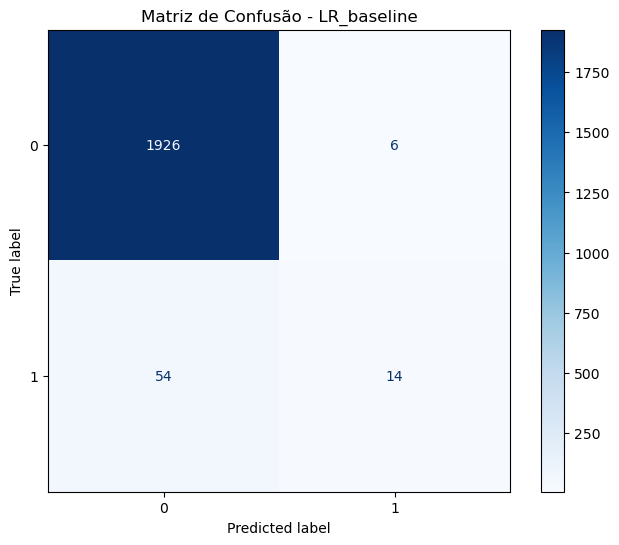

In [11]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=pipelines_resultados['LR_baseline'][-1])

disp.plot(cmap='Blues', ax=ax)
plt.title(f'Matriz de Confusão - {list(pipelines_resultados.keys())[0]}')
plt.show()

## First Impressions

It is clear that even though we have high accuracy on our model, due to data imbalance, our model suffers from false negatives, evend though our predictor performs well as if there was not one at all, meaning that from 68 machine failures, we misslabeled 60 times from false negatives through false positives. It is a start already

### Next step

Now that we have a baseline, let's ad a class imbalance in our logistic regresison model, to see how well it performs:

In [12]:
features_continuas = X.drop(columns = 'Type').columns.tolist()
features_categoricas = ['Type']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_continuas),
        ('cat', OrdinalEncoder(categories = [['L', 'M', 'H']]), features_categoricas)
    ])

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight = 'balanced')) 
])

pipelines_resultados['LR_balanced'] = [pipe,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = scores,return_train_score=True),classification_report(y_test,pipe.predict(x_test)),confusion_matrix(y_test,pipe.predict(x_test))]


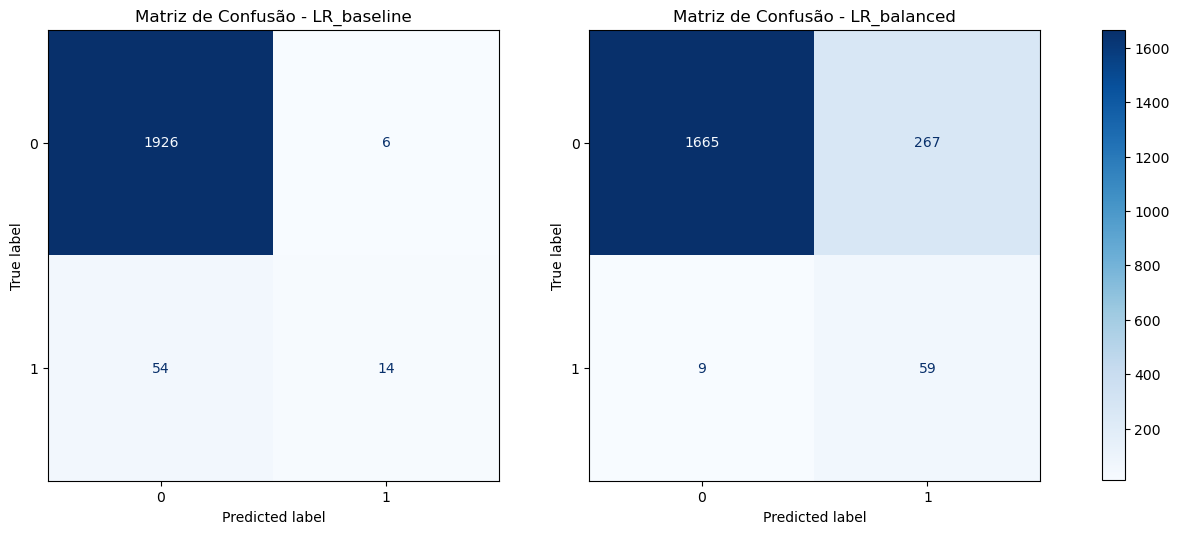

In [13]:
fig, ax = plt.subplots(1,2,figsize=(16, 9))
images = []
for i,modelo in enumerate(pipelines_resultados):
    disp = ConfusionMatrixDisplay(confusion_matrix=pipelines_resultados[modelo][-1])
    disp.plot(cmap='Blues', ax=ax[i], colorbar = False)
    ax[i].set_title(f'Matriz de Confusão - {modelo}')
    images.append(ax[i].images[0])

fig.colorbar(images[-1], ax=ax, location='right', shrink=0.65)

Our Model now predicted correctly almost all of our machine failures. However, we had too many false positives.

## Logistic Regression optimization - Optuna

In this section, we will try to tune some hyperparameters of our model, as well test some oversamplers to see if we get a better result.

In [14]:
def objective(trial):
    mcc_scorer = make_scorer(matthews_corrcoef)
    C =     trial.suggest_float('C', 1e-3, 100, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
    
    
    samplers = [
    ("no_sampler", None),  # baseline sem oversampling
    ("random", RandomOverSampler(
        sampling_strategy=0.1,
        random_state=42
    )),
    ("smote", SMOTE(
        sampling_strategy=0.1,
        k_neighbors=3,        # conservador com poucos dados
        random_state=42
    )),
    ("borderline", BorderlineSMOTE(
        sampling_strategy=0.1,
        k_neighbors=3,
        random_state=42
    )),
    ("svmsmote", SVMSMOTE(
        sampling_strategy=0.1,
        k_neighbors=3,
        random_state=42
    )),
    ("balanced_weight", None),
    ]

    sampler_name = trial.suggest_categorical(
        'samplers', ['no_sampler','random','smote', 'borderline','svmsmote','balanced_weight'])

    samplers_dict = dict(samplers)
    sampler_obj = samplers_dict[sampler_name]
    
    use_class_weight = "balanced" if sampler_name == "balanced_weight" else None
        
    # Monta o pipeline com os parâmetros sugeridos
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('sampler', sampler_obj),
        ('classifier', LogisticRegression(
            penalty = 'elasticnet',
            C = C,
            solver = 'saga',
            l1_ratio=l1_ratio,
            max_iter = 1000,
            random_state=42,
            class_weight=use_class_weight
        ))
    ])

    # Cross-validation estratificado — mantém proporção das classes
    cv = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipe, x_train, y_train,
        cv=cv,
        scoring='matthews_corrcoef',
        n_jobs=-1
    )

    return scores.mean()


In [15]:
sampler_optuna  = optuna.samplers.TPESampler(seed=42)   # Bayesiano
pruner_optuna   = optuna.pruners.MedianPruner()         # Poda tentativas ruins

study = optuna.create_study(
    direction='maximize',           # Queremos maximizar o score
    sampler=sampler_optuna,
    pruner=pruner_optuna
)

# n_trials = número de combinações testadas
# 100 tentativas já costuma convergir bem para XGBoost
study.optimize(objective, n_trials=500, show_progress_bar=True)

[I 2026-03-09 10:31:53,264] A new study created in memory with name: no-name-db50beb2-057e-47c8-9e4a-0cfe9e3ef209
Best trial: 0. Best value: 0.330495:   0%|          | 1/500 [00:07<59:11,  7.12s/it]

[I 2026-03-09 10:32:00,382] Trial 0 finished with value: 0.33049468088043066 and parameters: {'C': 0.0745934328572655, 'l1_ratio': 0.9507143064099162, 'samplers': 'balanced_weight'}. Best is trial 0 with value: 0.33049468088043066.


Best trial: 1. Best value: 0.453686:   0%|          | 2/500 [00:07<25:46,  3.10s/it]

[I 2026-03-09 10:32:00,677] Trial 1 finished with value: 0.45368576387284626 and parameters: {'C': 1.0129197956845732, 'l1_ratio': 0.7080725777960455, 'samplers': 'random'}. Best is trial 1 with value: 0.45368576387284626.
[I 2026-03-09 10:32:00,862] Trial 2 finished with value: 0.3913785725240588 and parameters: {'C': 0.033205591037519584, 'l1_ratio': 0.5247564316322378, 'samplers': 'smote'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   1%|          | 5/500 [00:08<07:44,  1.07it/s]

[I 2026-03-09 10:32:01,681] Trial 3 finished with value: 0.4516429428589952 and parameters: {'C': 0.19069966103000435, 'l1_ratio': 0.7851759613930136, 'samplers': 'svmsmote'}. Best is trial 1 with value: 0.45368576387284626.
[I 2026-03-09 10:32:01,815] Trial 4 finished with value: 0.0 and parameters: {'C': 0.0021147447960615704, 'l1_ratio': 0.9488855372533332, 'samplers': 'no_sampler'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   1%|          | 6/500 [00:08<05:42,  1.44it/s]

[I 2026-03-09 10:32:02,026] Trial 5 finished with value: 0.11461228683941281 and parameters: {'C': 0.00407559644007287, 'l1_ratio': 0.4951769101112702, 'samplers': 'random'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   1%|▏         | 7/500 [00:09<04:48,  1.71it/s]

[I 2026-03-09 10:32:02,388] Trial 6 finished with value: 0.3935274954905694 and parameters: {'C': 0.5414413211338525, 'l1_ratio': 0.18485445552552704, 'samplers': 'no_sampler'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   2%|▏         | 8/500 [00:09<05:10,  1.59it/s]

[I 2026-03-09 10:32:03,115] Trial 7 finished with value: 0.10227867689882973 and parameters: {'C': 0.0027698899227562817, 'l1_ratio': 0.1959828624191452, 'samplers': 'svmsmote'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   2%|▏         | 10/500 [00:10<03:11,  2.56it/s]

[I 2026-03-09 10:32:03,314] Trial 8 finished with value: 0.3835266317353408 and parameters: {'C': 0.02539057572102413, 'l1_ratio': 0.5426960831582485, 'samplers': 'borderline'}. Best is trial 1 with value: 0.45368576387284626.
[I 2026-03-09 10:32:03,475] Trial 9 finished with value: 0.0 and parameters: {'C': 0.0010656401760606447, 'l1_ratio': 0.8154614284548342, 'samplers': 'smote'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   2%|▏         | 11/500 [00:10<03:06,  2.62it/s]

[I 2026-03-09 10:32:03,831] Trial 10 finished with value: 0.4508023787591117 and parameters: {'C': 28.33953511939785, 'l1_ratio': 0.0059971829558173595, 'samplers': 'random'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   2%|▏         | 12/500 [00:11<04:24,  1.85it/s]

[I 2026-03-09 10:32:04,739] Trial 11 finished with value: 0.441710815034423 and parameters: {'C': 1.581770609038747, 'l1_ratio': 0.715169612196795, 'samplers': 'svmsmote'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   3%|▎         | 13/500 [00:12<06:16,  1.29it/s]

[I 2026-03-09 10:32:06,048] Trial 12 finished with value: 0.4346890773382254 and parameters: {'C': 5.325351805103951, 'l1_ratio': 0.7017553010648062, 'samplers': 'svmsmote'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   3%|▎         | 14/500 [00:13<05:08,  1.58it/s]

[I 2026-03-09 10:32:06,361] Trial 13 finished with value: 0.4414643572958597 and parameters: {'C': 0.23959356118451489, 'l1_ratio': 0.7183803821417525, 'samplers': 'random'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   3%|▎         | 15/500 [00:13<05:06,  1.58it/s]

[I 2026-03-09 10:32:06,983] Trial 14 finished with value: 0.32902764324026507 and parameters: {'C': 7.511999512689627, 'l1_ratio': 0.8081156468116762, 'samplers': 'balanced_weight'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   3%|▎         | 16/500 [00:14<04:28,  1.80it/s]

[I 2026-03-09 10:32:07,363] Trial 15 finished with value: 0.44124336230400063 and parameters: {'C': 0.5117785529689942, 'l1_ratio': 0.42711230563333186, 'samplers': 'borderline'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   3%|▎         | 17/500 [00:15<05:35,  1.44it/s]

[I 2026-03-09 10:32:08,379] Trial 16 finished with value: 0.43891652447147605 and parameters: {'C': 0.15782842093356372, 'l1_ratio': 0.62461177965236, 'samplers': 'svmsmote'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   4%|▎         | 18/500 [00:15<04:53,  1.64it/s]

[I 2026-03-09 10:32:08,791] Trial 17 finished with value: 0.4497251992994028 and parameters: {'C': 95.20117701615145, 'l1_ratio': 0.36740408763680665, 'samplers': 'random'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   4%|▍         | 19/500 [00:16<06:07,  1.31it/s]

[I 2026-03-09 10:32:09,915] Trial 18 finished with value: 0.43742985851331384 and parameters: {'C': 1.9448473748699353, 'l1_ratio': 0.8620169696307762, 'samplers': 'svmsmote'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   4%|▍         | 20/500 [00:16<04:55,  1.63it/s]

[I 2026-03-09 10:32:10,177] Trial 19 finished with value: 0.35371905904882706 and parameters: {'C': 0.013667688059759639, 'l1_ratio': 0.6446928089065054, 'samplers': 'random'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   4%|▍         | 21/500 [00:17<04:22,  1.82it/s]

[I 2026-03-09 10:32:10,574] Trial 20 finished with value: 0.4500548132723784 and parameters: {'C': 1.4442554849819305, 'l1_ratio': 0.8791686722888706, 'samplers': 'smote'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   4%|▍         | 22/500 [00:17<03:59,  2.00it/s]

[I 2026-03-09 10:32:10,960] Trial 21 finished with value: 0.4497251992994028 and parameters: {'C': 59.16866279705316, 'l1_ratio': 0.3122349359221165, 'samplers': 'random'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   5%|▍         | 23/500 [00:18<03:40,  2.17it/s]

[I 2026-03-09 10:32:11,328] Trial 22 finished with value: 0.4508023787591117 and parameters: {'C': 26.821237458901827, 'l1_ratio': 0.01252057527131988, 'samplers': 'random'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   5%|▍         | 24/500 [00:18<03:30,  2.26it/s]

[I 2026-03-09 10:32:11,727] Trial 23 finished with value: 0.4508023787591117 and parameters: {'C': 12.105033477910725, 'l1_ratio': 0.0530336699332972, 'samplers': 'random'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   5%|▌         | 25/500 [00:19<03:49,  2.07it/s]

[I 2026-03-09 10:32:12,302] Trial 24 finished with value: 0.4535084180188007 and parameters: {'C': 3.7864621512334686, 'l1_ratio': 0.5938700616555876, 'samplers': 'random'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   5%|▌         | 26/500 [00:19<04:09,  1.90it/s]

[I 2026-03-09 10:32:12,931] Trial 25 finished with value: 0.4442885080881898 and parameters: {'C': 2.545976149454793, 'l1_ratio': 0.5994523725657991, 'samplers': 'borderline'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   5%|▌         | 27/500 [00:19<03:40,  2.15it/s]

[I 2026-03-09 10:32:13,255] Trial 26 finished with value: 0.33004989193541984 and parameters: {'C': 0.6000457844419408, 'l1_ratio': 0.7791060691257956, 'samplers': 'balanced_weight'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   6%|▌         | 28/500 [00:20<03:29,  2.26it/s]

[I 2026-03-09 10:32:13,652] Trial 27 finished with value: 0.3715781300697619 and parameters: {'C': 0.1453796807979898, 'l1_ratio': 0.9970905789454628, 'samplers': 'no_sampler'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   6%|▌         | 29/500 [00:21<05:56,  1.32it/s]

[I 2026-03-09 10:32:15,140] Trial 28 finished with value: 0.43544228704964527 and parameters: {'C': 3.386055028879387, 'l1_ratio': 0.6743112861866274, 'samplers': 'svmsmote'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   6%|▌         | 30/500 [00:22<04:41,  1.67it/s]

[I 2026-03-09 10:32:15,379] Trial 29 finished with value: 0.33020523003151503 and parameters: {'C': 1.124327318055151, 'l1_ratio': 0.5884019747969322, 'samplers': 'balanced_weight'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   6%|▌         | 31/500 [00:22<04:00,  1.95it/s]

[I 2026-03-09 10:32:15,689] Trial 30 finished with value: 0.43908028153934897 and parameters: {'C': 0.12148543364654242, 'l1_ratio': 0.4709197884328291, 'samplers': 'random'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   6%|▋         | 32/500 [00:22<03:35,  2.18it/s]

[I 2026-03-09 10:32:16,021] Trial 31 finished with value: 0.4508023787591117 and parameters: {'C': 22.925975582126977, 'l1_ratio': 0.12012483061335921, 'samplers': 'random'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   7%|▋         | 33/500 [00:23<03:06,  2.50it/s]

[I 2026-03-09 10:32:16,276] Trial 32 finished with value: 0.42733375097202875 and parameters: {'C': 0.04674653043798601, 'l1_ratio': 0.7423452689871065, 'samplers': 'random'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   7%|▋         | 34/500 [00:23<03:00,  2.58it/s]

[I 2026-03-09 10:32:16,645] Trial 33 finished with value: 0.4508023787591117 and parameters: {'C': 12.913569912968418, 'l1_ratio': 0.28882304109153156, 'samplers': 'random'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   7%|▋         | 35/500 [00:23<03:04,  2.52it/s]

[I 2026-03-09 10:32:17,056] Trial 34 finished with value: 0.4497251992994028 and parameters: {'C': 37.786909759272405, 'l1_ratio': 0.9134866186744709, 'samplers': 'random'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   7%|▋         | 36/500 [00:25<05:06,  1.51it/s]

[I 2026-03-09 10:32:18,333] Trial 35 finished with value: 0.4483564411480965 and parameters: {'C': 4.962618847895066, 'l1_ratio': 0.5074158000319069, 'samplers': 'smote'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   7%|▋         | 37/500 [00:25<04:33,  1.69it/s]

[I 2026-03-09 10:32:18,767] Trial 36 finished with value: 0.3958508708941417 and parameters: {'C': 0.611520450922819, 'l1_ratio': 0.5753755716507081, 'samplers': 'no_sampler'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   8%|▊         | 38/500 [00:25<04:03,  1.89it/s]

[I 2026-03-09 10:32:19,140] Trial 37 finished with value: 0.4508023787591117 and parameters: {'C': 10.305240878384156, 'l1_ratio': 0.4290279013500598, 'samplers': 'random'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   8%|▊         | 39/500 [00:26<05:22,  1.43it/s]

[I 2026-03-09 10:32:20,240] Trial 38 finished with value: 0.45056550750991137 and parameters: {'C': 0.31638929617697453, 'l1_ratio': 0.765707518518439, 'samplers': 'svmsmote'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   8%|▊         | 40/500 [00:27<04:28,  1.71it/s]

[I 2026-03-09 10:32:20,557] Trial 39 finished with value: 0.3512437983431611 and parameters: {'C': 0.01049336867809985, 'l1_ratio': 0.6602847187518358, 'samplers': 'borderline'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   8%|▊         | 41/500 [00:27<03:50,  2.00it/s]

[I 2026-03-09 10:32:20,867] Trial 40 finished with value: 0.3176409871395919 and parameters: {'C': 0.062037079177499996, 'l1_ratio': 0.8346398223728768, 'samplers': 'no_sampler'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   8%|▊         | 42/500 [00:27<03:29,  2.18it/s]

[I 2026-03-09 10:32:21,223] Trial 41 finished with value: 0.4508023787591117 and parameters: {'C': 24.67652815261545, 'l1_ratio': 0.015021211625687314, 'samplers': 'random'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 1. Best value: 0.453686:   9%|▊         | 43/500 [00:28<03:18,  2.30it/s]

[I 2026-03-09 10:32:21,601] Trial 42 finished with value: 0.4508023787591117 and parameters: {'C': 21.399459095611615, 'l1_ratio': 0.15043155592036317, 'samplers': 'random'}. Best is trial 1 with value: 0.45368576387284626.


Best trial: 43. Best value: 0.456489:   9%|▉         | 44/500 [00:28<03:14,  2.34it/s]

[I 2026-03-09 10:32:22,021] Trial 43 finished with value: 0.4564888544342562 and parameters: {'C': 3.2940383041037085, 'l1_ratio': 0.09305170951120456, 'samplers': 'random'}. Best is trial 43 with value: 0.4564888544342562.


Best trial: 43. Best value: 0.456489:   9%|▉         | 45/500 [00:29<03:48,  1.99it/s]

[I 2026-03-09 10:32:22,699] Trial 44 finished with value: 0.45279718751957265 and parameters: {'C': 0.8724052668511436, 'l1_ratio': 0.12217295459433714, 'samplers': 'random'}. Best is trial 43 with value: 0.4564888544342562.


Best trial: 43. Best value: 0.456489:   9%|▉         | 46/500 [00:30<04:39,  1.62it/s]

[I 2026-03-09 10:32:23,575] Trial 45 finished with value: 0.4537975727402519 and parameters: {'C': 0.9357591672477625, 'l1_ratio': 0.17238145640451807, 'samplers': 'random'}. Best is trial 43 with value: 0.4564888544342562.


Best trial: 43. Best value: 0.456489:   9%|▉         | 47/500 [00:31<05:39,  1.33it/s]

[I 2026-03-09 10:32:24,634] Trial 46 finished with value: 0.4537975727402519 and parameters: {'C': 0.9064181423039789, 'l1_ratio': 0.23317225862259125, 'samplers': 'random'}. Best is trial 43 with value: 0.4564888544342562.


Best trial: 47. Best value: 0.459497:  10%|▉         | 48/500 [00:31<05:16,  1.43it/s]

[I 2026-03-09 10:32:25,226] Trial 47 finished with value: 0.4594971086979719 and parameters: {'C': 3.229980210549951, 'l1_ratio': 0.20122880575514704, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  10%|▉         | 49/500 [00:32<04:48,  1.57it/s]

[I 2026-03-09 10:32:25,716] Trial 48 finished with value: 0.45543229863321333 and parameters: {'C': 0.9474237499706569, 'l1_ratio': 0.29630999853047957, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  10%|█         | 50/500 [00:33<04:37,  1.62it/s]

[I 2026-03-09 10:32:26,279] Trial 49 finished with value: 0.4584583151257572 and parameters: {'C': 2.6128658718100928, 'l1_ratio': 0.19830835541794908, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  10%|█         | 51/500 [00:33<04:07,  1.82it/s]

[I 2026-03-09 10:32:26,673] Trial 50 finished with value: 0.4423109546981291 and parameters: {'C': 0.3444331742370507, 'l1_ratio': 0.24038097481849938, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  10%|█         | 52/500 [00:33<04:08,  1.80it/s]

[I 2026-03-09 10:32:27,238] Trial 51 finished with value: 0.45368576387284626 and parameters: {'C': 1.8897956690350062, 'l1_ratio': 0.20809337952987053, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  11%|█         | 53/500 [00:34<03:41,  2.02it/s]

[I 2026-03-09 10:32:27,599] Trial 52 finished with value: 0.4537975727402519 and parameters: {'C': 1.0204056098986516, 'l1_ratio': 0.07581824660750855, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  11%|█         | 54/500 [00:34<03:22,  2.20it/s]

[I 2026-03-09 10:32:27,958] Trial 53 finished with value: 0.45259674680217377 and parameters: {'C': 6.2889627904884895, 'l1_ratio': 0.2518949610365383, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  11%|█         | 55/500 [00:35<03:21,  2.21it/s]

[I 2026-03-09 10:32:28,405] Trial 54 finished with value: 0.45103391131463555 and parameters: {'C': 3.541788377440711, 'l1_ratio': 0.16448804475298406, 'samplers': 'smote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  11%|█         | 56/500 [00:35<04:04,  1.82it/s]

[I 2026-03-09 10:32:29,186] Trial 55 finished with value: 0.4584583151257572 and parameters: {'C': 2.228559570355763, 'l1_ratio': 0.3297917359319348, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  11%|█▏        | 57/500 [00:36<04:14,  1.74it/s]

[I 2026-03-09 10:32:29,815] Trial 56 finished with value: 0.45746795247651334 and parameters: {'C': 2.4119348730123686, 'l1_ratio': 0.3660262780908458, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  12%|█▏        | 58/500 [00:36<03:56,  1.87it/s]

[I 2026-03-09 10:32:30,262] Trial 57 finished with value: 0.32997717253765046 and parameters: {'C': 2.2025722323626717, 'l1_ratio': 0.36946786238954843, 'samplers': 'balanced_weight'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  12%|█▏        | 59/500 [00:37<03:21,  2.18it/s]

[I 2026-03-09 10:32:30,533] Trial 58 finished with value: 0.4508023787591117 and parameters: {'C': 8.915936028008815, 'l1_ratio': 0.32861676151723945, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  12%|█▏        | 60/500 [00:37<03:31,  2.08it/s]

[I 2026-03-09 10:32:31,068] Trial 59 finished with value: 0.45368576387284626 and parameters: {'C': 1.5947046356621633, 'l1_ratio': 0.3620152652488773, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  12%|█▏        | 61/500 [00:38<03:48,  1.92it/s]

[I 2026-03-09 10:32:31,685] Trial 60 finished with value: 0.4440295985148551 and parameters: {'C': 2.79970401791301, 'l1_ratio': 0.2806042270394206, 'samplers': 'borderline'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  12%|█▏        | 62/500 [00:38<03:21,  2.17it/s]

[I 2026-03-09 10:32:32,010] Trial 61 finished with value: 0.4417909627095943 and parameters: {'C': 0.43080384324055493, 'l1_ratio': 0.09467430589063688, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  13%|█▎        | 63/500 [00:39<03:02,  2.40it/s]

[I 2026-03-09 10:32:32,314] Trial 62 finished with value: 0.4567432734908757 and parameters: {'C': 4.834555224157179, 'l1_ratio': 0.19107167120516066, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  13%|█▎        | 64/500 [00:39<02:48,  2.59it/s]

[I 2026-03-09 10:32:32,633] Trial 63 finished with value: 0.4567432734908757 and parameters: {'C': 5.207359838532096, 'l1_ratio': 0.21282980989447436, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  13%|█▎        | 65/500 [00:39<02:37,  2.75it/s]

[I 2026-03-09 10:32:32,942] Trial 64 finished with value: 0.4567432734908757 and parameters: {'C': 5.634393810011122, 'l1_ratio': 0.20494466670912984, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  13%|█▎        | 66/500 [00:39<02:27,  2.95it/s]

[I 2026-03-09 10:32:33,234] Trial 65 finished with value: 0.4535084180188007 and parameters: {'C': 6.071863078840349, 'l1_ratio': 0.22202245053083197, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  13%|█▎        | 67/500 [00:40<02:25,  2.97it/s]

[I 2026-03-09 10:32:33,552] Trial 66 finished with value: 0.4508023787591117 and parameters: {'C': 14.787476576088027, 'l1_ratio': 0.2649270973973414, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  14%|█▎        | 68/500 [00:40<02:27,  2.94it/s]

[I 2026-03-09 10:32:33,907] Trial 67 finished with value: 0.44929238701205343 and parameters: {'C': 4.553703845526567, 'l1_ratio': 0.19363521911494455, 'samplers': 'smote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  14%|█▍        | 69/500 [00:40<02:21,  3.04it/s]

[I 2026-03-09 10:32:34,211] Trial 68 finished with value: 0.45169834850274204 and parameters: {'C': 7.215823594800113, 'l1_ratio': 0.3230915352428425, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  14%|█▍        | 70/500 [00:41<02:11,  3.28it/s]

[I 2026-03-09 10:32:34,456] Trial 69 finished with value: 0.32902764324026507 and parameters: {'C': 17.434116956317215, 'l1_ratio': 0.14110920993254647, 'samplers': 'balanced_weight'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  14%|█▍        | 71/500 [00:41<02:29,  2.88it/s]

[I 2026-03-09 10:32:34,907] Trial 70 finished with value: 0.4099430830722026 and parameters: {'C': 1.4048262689125608, 'l1_ratio': 0.3375881099007934, 'samplers': 'no_sampler'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  14%|█▍        | 72/500 [00:41<02:22,  2.99it/s]

[I 2026-03-09 10:32:35,209] Trial 71 finished with value: 0.4554174747231442 and parameters: {'C': 2.690978682942351, 'l1_ratio': 0.09090045779076462, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  15%|█▍        | 73/500 [00:42<03:39,  1.94it/s]

[I 2026-03-09 10:32:36,141] Trial 72 finished with value: 0.4535084180188007 and parameters: {'C': 4.404197461177926, 'l1_ratio': 0.42129109808001935, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  15%|█▍        | 74/500 [00:43<03:10,  2.24it/s]

[I 2026-03-09 10:32:36,428] Trial 73 finished with value: 0.4594971086979719 and parameters: {'C': 3.2523786944295456, 'l1_ratio': 0.1938904512415042, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  15%|█▌        | 75/500 [00:43<02:49,  2.50it/s]

[I 2026-03-09 10:32:36,718] Trial 74 finished with value: 0.45169834850274204 and parameters: {'C': 8.40367271245663, 'l1_ratio': 0.19337915948442855, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  15%|█▌        | 76/500 [00:44<03:16,  2.16it/s]

[I 2026-03-09 10:32:37,336] Trial 75 finished with value: 0.4554174747231442 and parameters: {'C': 2.2334291222018385, 'l1_ratio': 0.2665633228765453, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  15%|█▌        | 77/500 [00:44<02:53,  2.44it/s]

[I 2026-03-09 10:32:37,615] Trial 76 finished with value: 0.4567432734908757 and parameters: {'C': 4.781320300975306, 'l1_ratio': 0.22077070657653805, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  16%|█▌        | 78/500 [00:44<02:50,  2.48it/s]

[I 2026-03-09 10:32:38,001] Trial 77 finished with value: 0.44106981297492664 and parameters: {'C': 36.38777800815816, 'l1_ratio': 0.3868346256406764, 'samplers': 'borderline'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  16%|█▌        | 79/500 [00:45<02:59,  2.34it/s]

[I 2026-03-09 10:32:38,496] Trial 78 finished with value: 0.4508023787591117 and parameters: {'C': 11.215264989450246, 'l1_ratio': 0.1255813349268154, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  16%|█▌        | 80/500 [00:46<05:24,  1.30it/s]

[I 2026-03-09 10:32:40,071] Trial 79 finished with value: 0.4457841031485931 and parameters: {'C': 1.2614238964341673, 'l1_ratio': 0.1848709295698036, 'samplers': 'svmsmote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  16%|█▌        | 81/500 [00:47<04:49,  1.45it/s]

[I 2026-03-09 10:32:40,565] Trial 80 finished with value: 0.4551174222688279 and parameters: {'C': 1.8800750477475505, 'l1_ratio': 0.05902560572752755, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  16%|█▋        | 82/500 [00:47<04:24,  1.58it/s]

[I 2026-03-09 10:32:41,058] Trial 81 finished with value: 0.4567432734908757 and parameters: {'C': 5.324411701412925, 'l1_ratio': 0.21555817430668292, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  17%|█▋        | 83/500 [00:48<03:47,  1.83it/s]

[I 2026-03-09 10:32:41,415] Trial 82 finished with value: 0.4584583151257572 and parameters: {'C': 2.812252086385787, 'l1_ratio': 0.16366329052431447, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  17%|█▋        | 84/500 [00:48<03:17,  2.11it/s]

[I 2026-03-09 10:32:41,711] Trial 83 finished with value: 0.4594971086979719 and parameters: {'C': 3.335505115582921, 'l1_ratio': 0.1445508995096005, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  17%|█▋        | 85/500 [00:48<02:59,  2.31it/s]

[I 2026-03-09 10:32:42,056] Trial 84 finished with value: 0.45746795247651334 and parameters: {'C': 2.9684380869076943, 'l1_ratio': 0.16476864443463282, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  17%|█▋        | 86/500 [00:49<02:51,  2.41it/s]

[I 2026-03-09 10:32:42,421] Trial 85 finished with value: 0.44920227282169606 and parameters: {'C': 0.7110495866581508, 'l1_ratio': 0.15670267280738528, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  17%|█▋        | 87/500 [00:49<02:39,  2.59it/s]

[I 2026-03-09 10:32:42,737] Trial 86 finished with value: 0.4584583151257572 and parameters: {'C': 2.90800403272842, 'l1_ratio': 0.03369236114818017, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  18%|█▊        | 88/500 [00:49<02:38,  2.59it/s]

[I 2026-03-09 10:32:43,123] Trial 87 finished with value: 0.40425182512102387 and parameters: {'C': 2.798274381319496, 'l1_ratio': 0.040443405134819546, 'samplers': 'no_sampler'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  18%|█▊        | 89/500 [00:50<02:24,  2.84it/s]

[I 2026-03-09 10:32:43,397] Trial 88 finished with value: 0.4520140642065815 and parameters: {'C': 1.5876637450141846, 'l1_ratio': 0.11455758987145204, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  18%|█▊        | 90/500 [00:50<02:19,  2.93it/s]

[I 2026-03-09 10:32:43,718] Trial 89 finished with value: 0.4594971086979719 and parameters: {'C': 3.766909989330812, 'l1_ratio': 0.027346083742898153, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  18%|█▊        | 91/500 [00:50<02:18,  2.95it/s]

[I 2026-03-09 10:32:44,055] Trial 90 finished with value: 0.451831053126138 and parameters: {'C': 3.8285572084077266, 'l1_ratio': 0.02927190071292201, 'samplers': 'smote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  18%|█▊        | 92/500 [00:51<02:14,  3.03it/s]

[I 2026-03-09 10:32:44,353] Trial 91 finished with value: 0.45746795247651334 and parameters: {'C': 3.2989014538189165, 'l1_ratio': 0.007202765901723668, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  19%|█▊        | 93/500 [00:51<02:08,  3.16it/s]

[I 2026-03-09 10:32:44,647] Trial 92 finished with value: 0.4520140642065815 and parameters: {'C': 1.8278627608899725, 'l1_ratio': 0.05584324038598128, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  19%|█▉        | 94/500 [00:51<02:10,  3.12it/s]

[I 2026-03-09 10:32:44,971] Trial 93 finished with value: 0.4527345577725573 and parameters: {'C': 2.384664527356115, 'l1_ratio': 0.13725308661044638, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  19%|█▉        | 95/500 [00:52<02:10,  3.10it/s]

[I 2026-03-09 10:32:45,301] Trial 94 finished with value: 0.45169834850274204 and parameters: {'C': 7.982418977081649, 'l1_ratio': 0.07788263319390049, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  19%|█▉        | 96/500 [00:52<02:09,  3.11it/s]

[I 2026-03-09 10:32:45,619] Trial 95 finished with value: 0.4520140642065815 and parameters: {'C': 1.3141833083201473, 'l1_ratio': 0.471474446963513, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  19%|█▉        | 97/500 [00:52<02:12,  3.04it/s]

[I 2026-03-09 10:32:45,971] Trial 96 finished with value: 0.3295315936229649 and parameters: {'C': 3.2785853456103333, 'l1_ratio': 0.24341284555717785, 'samplers': 'balanced_weight'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  20%|█▉        | 98/500 [00:53<02:18,  2.90it/s]

[I 2026-03-09 10:32:46,346] Trial 97 finished with value: 0.4554174747231442 and parameters: {'C': 2.4440059387043047, 'l1_ratio': 0.16903201526452186, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  20%|█▉        | 99/500 [00:53<02:09,  3.09it/s]

[I 2026-03-09 10:32:46,624] Trial 98 finished with value: 0.44920227282169606 and parameters: {'C': 0.7408887941981314, 'l1_ratio': 0.11120257305274589, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  20%|██        | 100/500 [00:54<03:04,  2.17it/s]

[I 2026-03-09 10:32:47,409] Trial 99 finished with value: 0.4346890773382254 and parameters: {'C': 9.884490266773247, 'l1_ratio': 0.30477464545928673, 'samplers': 'svmsmote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  20%|██        | 101/500 [00:54<02:44,  2.43it/s]

[I 2026-03-09 10:32:47,699] Trial 100 finished with value: 0.45259674680217377 and parameters: {'C': 7.029870779031481, 'l1_ratio': 0.13931906614047707, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  20%|██        | 102/500 [00:54<02:27,  2.70it/s]

[I 2026-03-09 10:32:47,979] Trial 101 finished with value: 0.4551174222688279 and parameters: {'C': 2.000113864363876, 'l1_ratio': 0.011575071521194094, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  21%|██        | 103/500 [00:54<02:16,  2.90it/s]

[I 2026-03-09 10:32:48,265] Trial 102 finished with value: 0.4564888544342562 and parameters: {'C': 3.550771573783635, 'l1_ratio': 0.032407066804446626, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  21%|██        | 104/500 [00:55<02:09,  3.06it/s]

[I 2026-03-09 10:32:48,544] Trial 103 finished with value: 0.4564888544342562 and parameters: {'C': 3.453270985204556, 'l1_ratio': 0.0595335579964668, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  21%|██        | 105/500 [00:55<02:36,  2.53it/s]

[I 2026-03-09 10:32:49,096] Trial 104 finished with value: 0.4442885080881898 and parameters: {'C': 2.815633497393702, 'l1_ratio': 0.5550705087701981, 'samplers': 'borderline'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  21%|██        | 106/500 [00:56<02:19,  2.83it/s]

[I 2026-03-09 10:32:49,349] Trial 105 finished with value: 0.4537975727402519 and parameters: {'C': 1.113417486587061, 'l1_ratio': 0.0014200353272095234, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  21%|██▏       | 107/500 [00:56<02:09,  3.03it/s]

[I 2026-03-09 10:32:49,636] Trial 106 finished with value: 0.4594971086979719 and parameters: {'C': 3.892102451315773, 'l1_ratio': 0.07862154507997504, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  22%|██▏       | 108/500 [00:56<02:06,  3.09it/s]

[I 2026-03-09 10:32:49,943] Trial 107 finished with value: 0.4520140642065815 and parameters: {'C': 1.7273432017644363, 'l1_ratio': 0.0942132495920546, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  22%|██▏       | 109/500 [00:56<01:58,  3.29it/s]

[I 2026-03-09 10:32:50,202] Trial 108 finished with value: 0.4576857196658339 and parameters: {'C': 4.2770629951254495, 'l1_ratio': 0.10689941014548811, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  22%|██▏       | 110/500 [00:57<01:52,  3.45it/s]

[I 2026-03-09 10:32:50,455] Trial 109 finished with value: 0.458561162834015 and parameters: {'C': 4.046645979317199, 'l1_ratio': 0.07258259371397775, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  22%|██▏       | 111/500 [00:57<01:48,  3.60it/s]

[I 2026-03-09 10:32:50,708] Trial 110 finished with value: 0.4567432734908757 and parameters: {'C': 6.404537241155308, 'l1_ratio': 0.07236896092117345, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  22%|██▏       | 112/500 [00:57<01:46,  3.63it/s]

[I 2026-03-09 10:32:50,973] Trial 111 finished with value: 0.4576857196658339 and parameters: {'C': 4.232802122627534, 'l1_ratio': 0.10345620671349358, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  23%|██▎       | 113/500 [00:57<01:46,  3.64it/s]

[I 2026-03-09 10:32:51,253] Trial 112 finished with value: 0.4576857196658339 and parameters: {'C': 4.337000919148376, 'l1_ratio': 0.04179330634911696, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  23%|██▎       | 114/500 [00:58<01:46,  3.63it/s]

[I 2026-03-09 10:32:51,529] Trial 113 finished with value: 0.4576857196658339 and parameters: {'C': 4.080266267260033, 'l1_ratio': 0.10153863401787379, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  23%|██▎       | 115/500 [00:58<01:47,  3.57it/s]

[I 2026-03-09 10:32:51,814] Trial 114 finished with value: 0.4567432734908757 and parameters: {'C': 6.022358825898577, 'l1_ratio': 0.07711670506654651, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  23%|██▎       | 116/500 [00:58<01:56,  3.30it/s]

[I 2026-03-09 10:32:52,172] Trial 115 finished with value: 0.40833617801020405 and parameters: {'C': 16.96620949029936, 'l1_ratio': 0.1366987429486069, 'samplers': 'no_sampler'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  23%|██▎       | 117/500 [00:59<01:52,  3.40it/s]

[I 2026-03-09 10:32:52,448] Trial 116 finished with value: 0.45169834850274204 and parameters: {'C': 8.613221584526954, 'l1_ratio': 0.12088002766529253, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  24%|██▎       | 118/500 [00:59<01:51,  3.41it/s]

[I 2026-03-09 10:32:52,735] Trial 117 finished with value: 0.4500548132723784 and parameters: {'C': 4.320270387376885, 'l1_ratio': 0.17720492722812478, 'samplers': 'smote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  24%|██▍       | 119/500 [00:59<01:46,  3.59it/s]

[I 2026-03-09 10:32:52,988] Trial 118 finished with value: 0.4508023787591117 and parameters: {'C': 13.443653271410568, 'l1_ratio': 0.0745124750321601, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  24%|██▍       | 120/500 [01:00<01:48,  3.52it/s]

[I 2026-03-09 10:32:53,285] Trial 119 finished with value: 0.4527345577725573 and parameters: {'C': 2.299043741239047, 'l1_ratio': 0.15122407173058716, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  24%|██▍       | 121/500 [01:00<01:47,  3.51it/s]

[I 2026-03-09 10:32:53,571] Trial 120 finished with value: 0.45391450103086195 and parameters: {'C': 1.371935446134452, 'l1_ratio': 0.02420143205080702, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  24%|██▍       | 122/500 [01:00<01:43,  3.67it/s]

[I 2026-03-09 10:32:53,816] Trial 121 finished with value: 0.4576857196658339 and parameters: {'C': 4.37508687904981, 'l1_ratio': 0.042538789305099946, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  25%|██▍       | 123/500 [01:00<01:46,  3.54it/s]

[I 2026-03-09 10:32:54,121] Trial 122 finished with value: 0.4567432734908757 and parameters: {'C': 5.788751801102886, 'l1_ratio': 0.10280917871348501, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  25%|██▍       | 124/500 [01:01<01:46,  3.53it/s]

[I 2026-03-09 10:32:54,407] Trial 123 finished with value: 0.3295315936229649 and parameters: {'C': 3.6946708003619366, 'l1_ratio': 0.04821398376068785, 'samplers': 'balanced_weight'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  25%|██▌       | 125/500 [01:01<01:53,  3.31it/s]

[I 2026-03-09 10:32:54,752] Trial 124 finished with value: 0.4535084180188007 and parameters: {'C': 7.130398185472518, 'l1_ratio': 0.08778786050130316, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  25%|██▌       | 126/500 [01:01<02:14,  2.79it/s]

[I 2026-03-09 10:32:55,238] Trial 125 finished with value: 0.4584583151257572 and parameters: {'C': 2.9790370200406993, 'l1_ratio': 0.06276565945261713, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  25%|██▌       | 127/500 [01:02<02:01,  3.06it/s]

[I 2026-03-09 10:32:55,490] Trial 126 finished with value: 0.0 and parameters: {'C': 0.0019147713764070665, 'l1_ratio': 0.1272557453599671, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  26%|██▌       | 128/500 [01:03<04:11,  1.48it/s]

[I 2026-03-09 10:32:56,984] Trial 127 finished with value: 0.4420787501276719 and parameters: {'C': 2.006659643688965, 'l1_ratio': 0.061886050228832465, 'samplers': 'svmsmote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  26%|██▌       | 129/500 [01:04<03:32,  1.75it/s]

[I 2026-03-09 10:32:57,312] Trial 128 finished with value: 0.45746795247651334 and parameters: {'C': 2.845141725551013, 'l1_ratio': 0.15307950670284826, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  26%|██▌       | 130/500 [01:04<03:17,  1.87it/s]

[I 2026-03-09 10:32:57,756] Trial 129 finished with value: 0.4424531322815363 and parameters: {'C': 11.351031213801043, 'l1_ratio': 0.11599484875562446, 'samplers': 'borderline'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  26%|██▌       | 131/500 [01:04<02:54,  2.12it/s]

[I 2026-03-09 10:32:58,087] Trial 130 finished with value: 0.45305670714244123 and parameters: {'C': 1.6007115490363226, 'l1_ratio': 0.024971816881635467, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  26%|██▋       | 132/500 [01:05<02:38,  2.33it/s]

[I 2026-03-09 10:32:58,415] Trial 131 finished with value: 0.4576857196658339 and parameters: {'C': 4.942445715485974, 'l1_ratio': 0.043028281354323836, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  27%|██▋       | 133/500 [01:05<02:31,  2.43it/s]

[I 2026-03-09 10:32:58,784] Trial 132 finished with value: 0.458561162834015 and parameters: {'C': 4.098400842348929, 'l1_ratio': 0.09002492279688708, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  27%|██▋       | 134/500 [01:05<02:24,  2.54it/s]

[I 2026-03-09 10:32:59,135] Trial 133 finished with value: 0.4584583151257572 and parameters: {'C': 2.8376452662470006, 'l1_ratio': 0.10239048901779346, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  27%|██▋       | 135/500 [01:06<02:23,  2.54it/s]

[I 2026-03-09 10:32:59,531] Trial 134 finished with value: 0.45746795247651334 and parameters: {'C': 2.8123483736545705, 'l1_ratio': 0.17850126035001188, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  27%|██▋       | 136/500 [01:06<02:19,  2.60it/s]

[I 2026-03-09 10:32:59,891] Trial 135 finished with value: 0.4554174747231442 and parameters: {'C': 2.564114487938045, 'l1_ratio': 0.06884094700368272, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  27%|██▋       | 137/500 [01:06<02:11,  2.76it/s]

[I 2026-03-09 10:33:00,211] Trial 136 finished with value: 0.45368576387284626 and parameters: {'C': 2.1186617540679613, 'l1_ratio': 0.08655703902891272, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  28%|██▊       | 138/500 [01:07<02:40,  2.26it/s]

[I 2026-03-09 10:33:00,834] Trial 137 finished with value: 0.458561162834015 and parameters: {'C': 3.3497564454366615, 'l1_ratio': 0.26215417739326075, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  28%|██▊       | 139/500 [01:08<03:07,  1.93it/s]

[I 2026-03-09 10:33:01,536] Trial 138 finished with value: 0.458561162834015 and parameters: {'C': 3.2264583403761873, 'l1_ratio': 0.27035291229042185, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  28%|██▊       | 140/500 [01:08<03:27,  1.74it/s]

[I 2026-03-09 10:33:02,234] Trial 139 finished with value: 0.458561162834015 and parameters: {'C': 3.302667648734677, 'l1_ratio': 0.2684491924276966, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  28%|██▊       | 141/500 [01:09<03:08,  1.90it/s]

[I 2026-03-09 10:33:02,654] Trial 140 finished with value: 0.40797013624767275 and parameters: {'C': 5.514299547068709, 'l1_ratio': 0.27488935753322585, 'samplers': 'no_sampler'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  28%|██▊       | 142/500 [01:09<03:07,  1.91it/s]

[I 2026-03-09 10:33:03,176] Trial 141 finished with value: 0.458561162834015 and parameters: {'C': 3.3006508571502517, 'l1_ratio': 0.23637093501696577, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  29%|██▊       | 143/500 [01:10<03:20,  1.78it/s]

[I 2026-03-09 10:33:03,815] Trial 142 finished with value: 0.4520140642065815 and parameters: {'C': 1.6051903129896383, 'l1_ratio': 0.2491882034433493, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  29%|██▉       | 144/500 [01:11<03:21,  1.77it/s]

[I 2026-03-09 10:33:04,388] Trial 143 finished with value: 0.458561162834015 and parameters: {'C': 3.4565184213803906, 'l1_ratio': 0.23666591209547205, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  29%|██▉       | 145/500 [01:11<03:20,  1.77it/s]

[I 2026-03-09 10:33:04,952] Trial 144 finished with value: 0.4576857196658339 and parameters: {'C': 3.7403637598080492, 'l1_ratio': 0.2329258352943951, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  29%|██▉       | 146/500 [01:12<03:58,  1.48it/s]

[I 2026-03-09 10:33:05,882] Trial 145 finished with value: 0.4554174747231442 and parameters: {'C': 2.1303558931457505, 'l1_ratio': 0.2961531904857042, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  29%|██▉       | 147/500 [01:13<03:33,  1.65it/s]

[I 2026-03-09 10:33:06,332] Trial 146 finished with value: 0.45169834850274204 and parameters: {'C': 6.8796667596186145, 'l1_ratio': 0.26288449289833227, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  30%|██▉       | 148/500 [01:13<03:31,  1.66it/s]

[I 2026-03-09 10:33:06,927] Trial 147 finished with value: 0.4594971086979719 and parameters: {'C': 3.380652851025311, 'l1_ratio': 0.20440040110819147, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  30%|██▉       | 149/500 [01:14<03:18,  1.77it/s]

[I 2026-03-09 10:33:07,402] Trial 148 finished with value: 0.45169834850274204 and parameters: {'C': 8.53785998114701, 'l1_ratio': 0.20118972474346325, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  30%|███       | 150/500 [01:14<02:54,  2.00it/s]

[I 2026-03-09 10:33:07,754] Trial 149 finished with value: 0.3299967634405101 and parameters: {'C': 5.2885769734183015, 'l1_ratio': 0.22132341563142718, 'samplers': 'balanced_weight'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  30%|███       | 151/500 [01:14<02:27,  2.37it/s]

[I 2026-03-09 10:33:07,986] Trial 150 finished with value: 0.36229635838788193 and parameters: {'C': 0.016247503505795756, 'l1_ratio': 0.33932131040086355, 'samplers': 'smote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  30%|███       | 152/500 [01:15<02:51,  2.02it/s]

[I 2026-03-09 10:33:08,650] Trial 151 finished with value: 0.4576857196658339 and parameters: {'C': 3.910136829117925, 'l1_ratio': 0.2878747957250234, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  31%|███       | 153/500 [01:15<02:47,  2.07it/s]

[I 2026-03-09 10:33:09,114] Trial 152 finished with value: 0.458561162834015 and parameters: {'C': 3.308989153052382, 'l1_ratio': 0.2423043622474326, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  31%|███       | 154/500 [01:16<02:42,  2.13it/s]

[I 2026-03-09 10:33:09,549] Trial 153 finished with value: 0.458561162834015 and parameters: {'C': 3.4348460037536683, 'l1_ratio': 0.23724111525167726, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  31%|███       | 155/500 [01:16<02:40,  2.15it/s]

[I 2026-03-09 10:33:10,000] Trial 154 finished with value: 0.458561162834015 and parameters: {'C': 3.354502421146584, 'l1_ratio': 0.2414378137133314, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  31%|███       | 156/500 [01:17<03:13,  1.78it/s]

[I 2026-03-09 10:33:10,789] Trial 155 finished with value: 0.458561162834015 and parameters: {'C': 3.414311066510896, 'l1_ratio': 0.24698575976911274, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  31%|███▏      | 157/500 [01:18<03:49,  1.49it/s]

[I 2026-03-09 10:33:11,706] Trial 156 finished with value: 0.4576857196658339 and parameters: {'C': 3.512695771643804, 'l1_ratio': 0.273916470286849, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  32%|███▏      | 158/500 [01:18<03:32,  1.61it/s]

[I 2026-03-09 10:33:12,214] Trial 157 finished with value: 0.4567432734908757 and parameters: {'C': 5.214024101815427, 'l1_ratio': 0.2242553570031553, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  32%|███▏      | 159/500 [01:19<03:17,  1.73it/s]

[I 2026-03-09 10:33:12,694] Trial 158 finished with value: 0.4497251992994028 and parameters: {'C': 97.6149767129366, 'l1_ratio': 0.2532022877811051, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  32%|███▏      | 160/500 [01:19<03:11,  1.77it/s]

[I 2026-03-09 10:33:13,224] Trial 159 finished with value: 0.45259674680217377 and parameters: {'C': 6.706839090676451, 'l1_ratio': 0.2047433040922248, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  32%|███▏      | 161/500 [01:20<03:34,  1.58it/s]

[I 2026-03-09 10:33:14,021] Trial 160 finished with value: 0.45368576387284626 and parameters: {'C': 1.8407806162971279, 'l1_ratio': 0.3050785224709295, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  32%|███▏      | 162/500 [01:21<03:31,  1.60it/s]

[I 2026-03-09 10:33:14,638] Trial 161 finished with value: 0.458561162834015 and parameters: {'C': 3.40500054301704, 'l1_ratio': 0.24150852792069633, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  33%|███▎      | 163/500 [01:22<03:37,  1.55it/s]

[I 2026-03-09 10:33:15,317] Trial 162 finished with value: 0.458561162834015 and parameters: {'C': 3.294959329276335, 'l1_ratio': 0.23630148627007594, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  33%|███▎      | 164/500 [01:22<03:19,  1.69it/s]

[I 2026-03-09 10:33:15,794] Trial 163 finished with value: 0.4567432734908757 and parameters: {'C': 4.695722826454871, 'l1_ratio': 0.2753734786069259, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  33%|███▎      | 165/500 [01:22<02:44,  2.04it/s]

[I 2026-03-09 10:33:16,046] Trial 164 finished with value: 0.43822068832492006 and parameters: {'C': 0.08762302069607904, 'l1_ratio': 0.258608276266507, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  33%|███▎      | 166/500 [01:23<03:39,  1.52it/s]

[I 2026-03-09 10:33:17,086] Trial 165 finished with value: 0.44027915663844136 and parameters: {'C': 2.3269286483132174, 'l1_ratio': 0.21163061184483317, 'samplers': 'svmsmote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  33%|███▎      | 167/500 [01:24<03:07,  1.77it/s]

[I 2026-03-09 10:33:17,444] Trial 166 finished with value: 0.4576857196658339 and parameters: {'C': 4.03445579217232, 'l1_ratio': 0.19533516927746641, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  34%|███▎      | 168/500 [01:24<02:57,  1.87it/s]

[I 2026-03-09 10:33:17,899] Trial 167 finished with value: 0.4432938656685079 and parameters: {'C': 5.827609399063091, 'l1_ratio': 0.23628920238514406, 'samplers': 'borderline'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  34%|███▍      | 169/500 [01:24<02:32,  2.17it/s]

[I 2026-03-09 10:33:18,187] Trial 168 finished with value: 0.4594971086979719 and parameters: {'C': 3.3519648372876394, 'l1_ratio': 0.1790744742318543, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  34%|███▍      | 170/500 [01:25<02:36,  2.11it/s]

[I 2026-03-09 10:33:18,688] Trial 169 finished with value: 0.4554174747231442 and parameters: {'C': 2.444320194644417, 'l1_ratio': 0.17709553833125488, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  34%|███▍      | 171/500 [01:25<02:41,  2.03it/s]

[I 2026-03-09 10:33:19,228] Trial 170 finished with value: 0.45391450103086195 and parameters: {'C': 1.3195979182053834, 'l1_ratio': 0.185464429625603, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  34%|███▍      | 172/500 [01:26<02:46,  1.97it/s]

[I 2026-03-09 10:33:19,776] Trial 171 finished with value: 0.458561162834015 and parameters: {'C': 3.4333243636152373, 'l1_ratio': 0.25208237975410336, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  35%|███▍      | 173/500 [01:26<02:25,  2.25it/s]

[I 2026-03-09 10:33:20,075] Trial 172 finished with value: 0.4567432734908757 and parameters: {'C': 4.7427667671393445, 'l1_ratio': 0.22068390702497684, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  35%|███▍      | 174/500 [01:27<02:49,  1.93it/s]

[I 2026-03-09 10:33:20,760] Trial 173 finished with value: 0.458561162834015 and parameters: {'C': 3.301702450209389, 'l1_ratio': 0.2861677349283181, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  35%|███▌      | 175/500 [01:28<02:51,  1.90it/s]

[I 2026-03-09 10:33:21,305] Trial 174 finished with value: 0.45368576387284626 and parameters: {'C': 2.031427755091509, 'l1_ratio': 0.2068639000867806, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  35%|███▌      | 176/500 [01:28<02:50,  1.90it/s]

[I 2026-03-09 10:33:21,829] Trial 175 finished with value: 0.45746795247651334 and parameters: {'C': 2.666762214434523, 'l1_ratio': 0.23332417718896684, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  35%|███▌      | 177/500 [01:29<03:04,  1.75it/s]

[I 2026-03-09 10:33:22,514] Trial 176 finished with value: 0.4567432734908757 and parameters: {'C': 4.4480397362567965, 'l1_ratio': 0.3190868911523345, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  36%|███▌      | 178/500 [01:29<03:02,  1.77it/s]

[I 2026-03-09 10:33:23,058] Trial 177 finished with value: 0.4576857196658339 and parameters: {'C': 3.8685778530661405, 'l1_ratio': 0.2671462024745657, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  36%|███▌      | 179/500 [01:30<02:35,  2.07it/s]

[I 2026-03-09 10:33:23,361] Trial 178 finished with value: 0.45746795247651334 and parameters: {'C': 2.9722384245977858, 'l1_ratio': 0.1551911525891067, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  36%|███▌      | 180/500 [01:30<02:19,  2.30it/s]

[I 2026-03-09 10:33:23,675] Trial 179 finished with value: 0.45169834850274204 and parameters: {'C': 7.214554506660772, 'l1_ratio': 0.1833452336273214, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  36%|███▌      | 181/500 [01:30<02:23,  2.23it/s]

[I 2026-03-09 10:33:24,153] Trial 180 finished with value: 0.40797013624767275 and parameters: {'C': 5.628143212411085, 'l1_ratio': 0.24974333237294713, 'samplers': 'no_sampler'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  36%|███▋      | 182/500 [01:31<02:22,  2.23it/s]

[I 2026-03-09 10:33:24,602] Trial 181 finished with value: 0.458561162834015 and parameters: {'C': 3.4476851628732748, 'l1_ratio': 0.22248795728526027, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  37%|███▋      | 183/500 [01:31<02:12,  2.39it/s]

[I 2026-03-09 10:33:24,950] Trial 182 finished with value: 0.42984367928109674 and parameters: {'C': 0.2278416389205155, 'l1_ratio': 0.242744457884402, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  37%|███▋      | 184/500 [01:31<02:01,  2.60it/s]

[I 2026-03-09 10:33:25,263] Trial 183 finished with value: 0.4594971086979719 and parameters: {'C': 3.413757402353202, 'l1_ratio': 0.2034677487434459, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  37%|███▋      | 185/500 [01:32<02:14,  2.35it/s]

[I 2026-03-09 10:33:25,779] Trial 184 finished with value: 0.4554174747231442 and parameters: {'C': 2.4120928100171772, 'l1_ratio': 0.20516919717472154, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  37%|███▋      | 186/500 [01:32<02:18,  2.27it/s]

[I 2026-03-09 10:33:26,248] Trial 185 finished with value: 0.4551174222688279 and parameters: {'C': 1.7655862338541237, 'l1_ratio': 0.19015433611120947, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  37%|███▋      | 187/500 [01:33<02:23,  2.17it/s]

[I 2026-03-09 10:33:26,761] Trial 186 finished with value: 0.4576857196658339 and parameters: {'C': 4.360800243886619, 'l1_ratio': 0.16636585668915782, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  38%|███▊      | 188/500 [01:34<03:21,  1.55it/s]

[I 2026-03-09 10:33:27,838] Trial 187 finished with value: 0.4594971086979719 and parameters: {'C': 2.867061542504751, 'l1_ratio': 0.27908031629612184, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  38%|███▊      | 189/500 [01:35<03:06,  1.66it/s]

[I 2026-03-09 10:33:28,336] Trial 188 finished with value: 0.45285684574130614 and parameters: {'C': 2.489742203433667, 'l1_ratio': 0.14650851221380984, 'samplers': 'smote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  38%|███▊      | 190/500 [01:35<03:16,  1.58it/s]

[I 2026-03-09 10:33:29,038] Trial 189 finished with value: 0.4567432734908757 and parameters: {'C': 5.1636089661278, 'l1_ratio': 0.29565456634004245, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  38%|███▊      | 191/500 [01:36<03:04,  1.67it/s]

[I 2026-03-09 10:33:29,550] Trial 190 finished with value: 0.3295315936229649 and parameters: {'C': 3.0015351120278186, 'l1_ratio': 0.26952855875651044, 'samplers': 'balanced_weight'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  38%|███▊      | 192/500 [01:36<02:43,  1.88it/s]

[I 2026-03-09 10:33:29,929] Trial 191 finished with value: 0.4576857196658339 and parameters: {'C': 3.856174026967867, 'l1_ratio': 0.21956061281349237, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  39%|███▊      | 193/500 [01:37<02:47,  1.84it/s]

[I 2026-03-09 10:33:30,507] Trial 192 finished with value: 0.4594971086979719 and parameters: {'C': 2.933356144046702, 'l1_ratio': 0.26045916818398474, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  39%|███▉      | 194/500 [01:37<03:02,  1.68it/s]

[I 2026-03-09 10:33:31,218] Trial 193 finished with value: 0.4554174747231442 and parameters: {'C': 2.148263694337761, 'l1_ratio': 0.2818110287440875, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  39%|███▉      | 195/500 [01:38<02:59,  1.70it/s]

[I 2026-03-09 10:33:31,796] Trial 194 finished with value: 0.4564888544342562 and parameters: {'C': 2.7893236511149375, 'l1_ratio': 0.26333610244451033, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  39%|███▉      | 196/500 [01:38<02:36,  1.94it/s]

[I 2026-03-09 10:33:32,133] Trial 195 finished with value: 0.4567432734908757 and parameters: {'C': 4.826826370591704, 'l1_ratio': 0.23266180301141043, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  39%|███▉      | 197/500 [01:39<02:49,  1.78it/s]

[I 2026-03-09 10:33:32,811] Trial 196 finished with value: 0.4576857196658339 and parameters: {'C': 3.9176113660982783, 'l1_ratio': 0.3058473076192684, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  40%|███▉      | 198/500 [01:39<02:24,  2.09it/s]

[I 2026-03-09 10:33:33,097] Trial 197 finished with value: 0.4535084180188007 and parameters: {'C': 6.214268054193067, 'l1_ratio': 0.2015034071748509, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  40%|███▉      | 199/500 [01:40<02:29,  2.01it/s]

[I 2026-03-09 10:33:33,636] Trial 198 finished with value: 0.4520140642065815 and parameters: {'C': 1.6217025972590309, 'l1_ratio': 0.22511575858913474, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  40%|████      | 200/500 [01:40<02:12,  2.26it/s]

[I 2026-03-09 10:33:33,951] Trial 199 finished with value: 0.4497251992994028 and parameters: {'C': 64.17918760523558, 'l1_ratio': 0.25895049544524085, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  40%|████      | 201/500 [01:41<03:13,  1.55it/s]

[I 2026-03-09 10:33:35,060] Trial 200 finished with value: 0.441710815034423 and parameters: {'C': 3.1115594022188913, 'l1_ratio': 0.18185029786313758, 'samplers': 'svmsmote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  40%|████      | 202/500 [01:42<03:47,  1.31it/s]

[I 2026-03-09 10:33:36,100] Trial 201 finished with value: 0.458561162834015 and parameters: {'C': 3.400074414528277, 'l1_ratio': 0.24624251413862558, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  41%|████      | 203/500 [01:43<03:31,  1.41it/s]

[I 2026-03-09 10:33:36,689] Trial 202 finished with value: 0.4554174747231442 and parameters: {'C': 2.3142434806596217, 'l1_ratio': 0.20885505112805586, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  41%|████      | 204/500 [01:44<03:28,  1.42it/s]

[I 2026-03-09 10:33:37,378] Trial 203 finished with value: 0.4576857196658339 and parameters: {'C': 3.9819556092519606, 'l1_ratio': 0.2845773015153949, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  41%|████      | 205/500 [01:44<03:17,  1.49it/s]

[I 2026-03-09 10:33:37,974] Trial 204 finished with value: 0.4594971086979719 and parameters: {'C': 3.012812434501611, 'l1_ratio': 0.24574788600782146, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  41%|████      | 206/500 [01:45<03:09,  1.55it/s]

[I 2026-03-09 10:33:38,562] Trial 205 finished with value: 0.45746795247651334 and parameters: {'C': 2.698973904726641, 'l1_ratio': 0.2254023200267435, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  41%|████▏     | 207/500 [01:46<03:22,  1.45it/s]

[I 2026-03-09 10:33:39,362] Trial 206 finished with value: 0.45368576387284626 and parameters: {'C': 1.9880283304040316, 'l1_ratio': 0.2631700511478841, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  42%|████▏     | 208/500 [01:46<03:04,  1.58it/s]

[I 2026-03-09 10:33:39,846] Trial 207 finished with value: 0.4442885080881898 and parameters: {'C': 5.211478423523976, 'l1_ratio': 0.1609625230556873, 'samplers': 'borderline'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  42%|████▏     | 209/500 [01:47<02:53,  1.67it/s]

[I 2026-03-09 10:33:40,364] Trial 208 finished with value: 0.4576857196658339 and parameters: {'C': 4.342799578943658, 'l1_ratio': 0.19686835019741009, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  42%|████▏     | 210/500 [01:47<02:54,  1.66it/s]

[I 2026-03-09 10:33:40,978] Trial 209 finished with value: 0.4594971086979719 and parameters: {'C': 2.9978738114066212, 'l1_ratio': 0.23941298121514942, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  42%|████▏     | 211/500 [01:48<03:38,  1.32it/s]

[I 2026-03-09 10:33:42,094] Trial 210 finished with value: 0.4564888544342562 and parameters: {'C': 2.686305743290989, 'l1_ratio': 0.3137414584320964, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  42%|████▏     | 212/500 [01:49<03:37,  1.33it/s]

[I 2026-03-09 10:33:42,847] Trial 211 finished with value: 0.4576857196658339 and parameters: {'C': 3.750254938314483, 'l1_ratio': 0.23382244036042701, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  43%|████▎     | 213/500 [01:50<04:04,  1.17it/s]

[I 2026-03-09 10:33:43,932] Trial 212 finished with value: 0.45746795247651334 and parameters: {'C': 2.746103787017344, 'l1_ratio': 0.24665368526462594, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  43%|████▎     | 214/500 [01:51<04:26,  1.07it/s]

[I 2026-03-09 10:33:45,045] Trial 213 finished with value: 0.458561162834015 and parameters: {'C': 3.2259367906467267, 'l1_ratio': 0.28157559944655924, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  43%|████▎     | 215/500 [01:52<04:21,  1.09it/s]

[I 2026-03-09 10:33:45,921] Trial 214 finished with value: 0.45368576387284626 and parameters: {'C': 1.9580745814773224, 'l1_ratio': 0.21873507818496696, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  43%|████▎     | 216/500 [01:53<04:03,  1.17it/s]

[I 2026-03-09 10:33:46,635] Trial 215 finished with value: 0.4567432734908757 and parameters: {'C': 4.502463486874798, 'l1_ratio': 0.2632338241925331, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  43%|████▎     | 217/500 [01:53<03:23,  1.39it/s]

[I 2026-03-09 10:33:47,036] Trial 216 finished with value: 0.4594971086979719 and parameters: {'C': 3.2653151029321954, 'l1_ratio': 0.192641159444278, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  44%|████▎     | 218/500 [01:54<03:01,  1.55it/s]

[I 2026-03-09 10:33:47,507] Trial 217 finished with value: 0.4554174747231442 and parameters: {'C': 2.301742330078133, 'l1_ratio': 0.174336015427657, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  44%|████▍     | 219/500 [01:54<02:36,  1.80it/s]

[I 2026-03-09 10:33:47,867] Trial 218 finished with value: 0.4567432734908757 and parameters: {'C': 5.574305184800757, 'l1_ratio': 0.19755505118015995, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  44%|████▍     | 220/500 [01:54<02:17,  2.03it/s]

[I 2026-03-09 10:33:48,204] Trial 219 finished with value: 0.4594971086979719 and parameters: {'C': 3.414475667023968, 'l1_ratio': 0.12779247351732947, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  44%|████▍     | 221/500 [01:55<02:01,  2.30it/s]

[I 2026-03-09 10:33:48,511] Trial 220 finished with value: 0.4584583151257572 and parameters: {'C': 2.8285993628639607, 'l1_ratio': 0.13411912583347363, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  44%|████▍     | 222/500 [01:55<01:56,  2.39it/s]

[I 2026-03-09 10:33:48,884] Trial 221 finished with value: 0.458561162834015 and parameters: {'C': 3.820754943360689, 'l1_ratio': 0.15232210336392954, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  45%|████▍     | 223/500 [01:55<01:39,  2.78it/s]

[I 2026-03-09 10:33:49,107] Trial 222 finished with value: 0.30701409237515664 and parameters: {'C': 0.006733754188087644, 'l1_ratio': 0.12718209169114741, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  45%|████▍     | 224/500 [01:56<01:38,  2.81it/s]

[I 2026-03-09 10:33:49,446] Trial 223 finished with value: 0.4594971086979719 and parameters: {'C': 3.3299570497582773, 'l1_ratio': 0.18072618980846933, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  45%|████▌     | 225/500 [01:56<01:39,  2.75it/s]

[I 2026-03-09 10:33:49,838] Trial 224 finished with value: 0.4576857196658339 and parameters: {'C': 4.705934419127314, 'l1_ratio': 0.18019158967610377, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  45%|████▌     | 226/500 [01:56<01:37,  2.81it/s]

[I 2026-03-09 10:33:50,175] Trial 225 finished with value: 0.45746795247651334 and parameters: {'C': 3.017889897727464, 'l1_ratio': 0.16588419549994096, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  45%|████▌     | 227/500 [01:57<01:39,  2.76it/s]

[I 2026-03-09 10:33:50,547] Trial 226 finished with value: 0.400631853348829 and parameters: {'C': 2.295252002818073, 'l1_ratio': 0.1196469881449946, 'samplers': 'no_sampler'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  46%|████▌     | 228/500 [01:57<01:34,  2.86it/s]

[I 2026-03-09 10:33:50,870] Trial 227 finished with value: 0.458561162834015 and parameters: {'C': 3.765489091862745, 'l1_ratio': 0.13862046179737147, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  46%|████▌     | 229/500 [01:58<01:40,  2.69it/s]

[I 2026-03-09 10:33:51,290] Trial 228 finished with value: 0.45259674680217377 and parameters: {'C': 6.57412596118305, 'l1_ratio': 0.2105218131308244, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  46%|████▌     | 230/500 [01:58<01:41,  2.67it/s]

[I 2026-03-09 10:33:51,676] Trial 229 finished with value: 0.45285684574130614 and parameters: {'C': 3.0415023038074254, 'l1_ratio': 0.1885686064511537, 'samplers': 'smote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  46%|████▌     | 231/500 [01:58<01:37,  2.76it/s]

[I 2026-03-09 10:33:52,007] Trial 230 finished with value: 0.4576857196658339 and parameters: {'C': 4.623302927799625, 'l1_ratio': 0.21194841076219034, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  46%|████▋     | 232/500 [01:59<01:48,  2.46it/s]

[I 2026-03-09 10:33:52,517] Trial 231 finished with value: 0.458561162834015 and parameters: {'C': 3.4843238577504585, 'l1_ratio': 0.24139056948801757, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  47%|████▋     | 233/500 [01:59<01:42,  2.59it/s]

[I 2026-03-09 10:33:52,863] Trial 232 finished with value: 0.4527345577725573 and parameters: {'C': 2.396771109645199, 'l1_ratio': 0.08219181954764236, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  47%|████▋     | 234/500 [01:59<01:42,  2.59it/s]

[I 2026-03-09 10:33:53,240] Trial 233 finished with value: 0.4576857196658339 and parameters: {'C': 3.9552135716632373, 'l1_ratio': 0.2266532861064942, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  47%|████▋     | 235/500 [02:00<01:45,  2.51it/s]

[I 2026-03-09 10:33:53,679] Trial 234 finished with value: 0.4594971086979719 and parameters: {'C': 3.105794265163397, 'l1_ratio': 0.19827198141359184, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  47%|████▋     | 236/500 [02:00<01:43,  2.55it/s]

[I 2026-03-09 10:33:54,057] Trial 235 finished with value: 0.45746795247651334 and parameters: {'C': 2.9538263419580284, 'l1_ratio': 0.1660028862635474, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  47%|████▋     | 237/500 [02:01<01:59,  2.20it/s]

[I 2026-03-09 10:33:54,645] Trial 236 finished with value: 0.45368576387284626 and parameters: {'C': 1.7702962861264997, 'l1_ratio': 0.19313372786518523, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  48%|████▊     | 238/500 [02:01<01:52,  2.33it/s]

[I 2026-03-09 10:33:55,020] Trial 237 finished with value: 0.3301588037772633 and parameters: {'C': 2.463405762642124, 'l1_ratio': 0.14129695994356822, 'samplers': 'balanced_weight'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  48%|████▊     | 239/500 [02:02<01:45,  2.48it/s]

[I 2026-03-09 10:33:55,369] Trial 238 finished with value: 0.4567432734908757 and parameters: {'C': 4.8237716920772264, 'l1_ratio': 0.17530528209277624, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  48%|████▊     | 240/500 [02:02<01:38,  2.63it/s]

[I 2026-03-09 10:33:55,693] Trial 239 finished with value: 0.4594971086979719 and parameters: {'C': 3.1697050619090037, 'l1_ratio': 0.1989484677778211, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  48%|████▊     | 241/500 [02:02<01:35,  2.72it/s]

[I 2026-03-09 10:33:56,020] Trial 240 finished with value: 0.4517007770585435 and parameters: {'C': 2.0717350296167005, 'l1_ratio': 0.9908412605276452, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  48%|████▊     | 242/500 [02:03<01:40,  2.57it/s]

[I 2026-03-09 10:33:56,471] Trial 241 finished with value: 0.4594971086979719 and parameters: {'C': 3.3759797139375327, 'l1_ratio': 0.20775870414054054, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  49%|████▊     | 243/500 [02:03<01:31,  2.80it/s]

[I 2026-03-09 10:33:56,751] Trial 242 finished with value: 0.4576857196658339 and parameters: {'C': 4.07410496559784, 'l1_ratio': 0.20051245897774989, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  49%|████▉     | 244/500 [02:03<01:35,  2.69it/s]

[I 2026-03-09 10:33:57,158] Trial 243 finished with value: 0.4564888544342562 and parameters: {'C': 2.983207521927208, 'l1_ratio': 0.19435493410015484, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  49%|████▉     | 245/500 [02:04<01:36,  2.65it/s]

[I 2026-03-09 10:33:57,542] Trial 244 finished with value: 0.458561162834015 and parameters: {'C': 3.6353131207844136, 'l1_ratio': 0.21497629612666128, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  49%|████▉     | 246/500 [02:04<01:28,  2.86it/s]

[I 2026-03-09 10:33:57,833] Trial 245 finished with value: 0.4584583151257572 and parameters: {'C': 2.7340478742584597, 'l1_ratio': 0.16237624341207052, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  49%|████▉     | 247/500 [02:04<01:24,  2.99it/s]

[I 2026-03-09 10:33:58,127] Trial 246 finished with value: 0.4567432734908757 and parameters: {'C': 5.483694837476611, 'l1_ratio': 0.18132574649385702, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  50%|████▉     | 248/500 [02:05<01:33,  2.68it/s]

[I 2026-03-09 10:33:58,594] Trial 247 finished with value: 0.4576857196658339 and parameters: {'C': 4.071398986931581, 'l1_ratio': 0.21327147315559558, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  50%|████▉     | 249/500 [02:05<01:51,  2.26it/s]

[I 2026-03-09 10:33:59,199] Trial 248 finished with value: 0.4535084180188007 and parameters: {'C': 3.2147860881731423, 'l1_ratio': 0.6848045806364507, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  50%|█████     | 250/500 [02:06<01:55,  2.17it/s]

[I 2026-03-09 10:33:59,705] Trial 249 finished with value: 0.4554174747231442 and parameters: {'C': 2.524330454039385, 'l1_ratio': 0.09938844392895795, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  50%|█████     | 251/500 [02:07<03:07,  1.33it/s]

[I 2026-03-09 10:34:01,132] Trial 250 finished with value: 0.441710815034423 and parameters: {'C': 4.180259816272646, 'l1_ratio': 0.1839276198014898, 'samplers': 'svmsmote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  50%|█████     | 252/500 [02:08<02:34,  1.61it/s]

[I 2026-03-09 10:34:01,459] Trial 251 finished with value: 0.4594971086979719 and parameters: {'C': 3.391817866071774, 'l1_ratio': 0.15047812982073058, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  51%|█████     | 253/500 [02:08<02:25,  1.69it/s]

[I 2026-03-09 10:34:01,969] Trial 252 finished with value: 0.4419013993827462 and parameters: {'C': 2.1974374659100886, 'l1_ratio': 0.6257162091230076, 'samplers': 'borderline'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  51%|█████     | 254/500 [02:09<02:05,  1.96it/s]

[I 2026-03-09 10:34:02,287] Trial 253 finished with value: 0.45746795247651334 and parameters: {'C': 3.0348930985811133, 'l1_ratio': 0.15006587659038395, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  51%|█████     | 255/500 [02:09<01:48,  2.26it/s]

[I 2026-03-09 10:34:02,576] Trial 254 finished with value: 0.4567432734908757 and parameters: {'C': 5.08349962655886, 'l1_ratio': 0.11813757451025451, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  51%|█████     | 256/500 [02:09<01:53,  2.15it/s]

[I 2026-03-09 10:34:03,088] Trial 255 finished with value: 0.4520140642065815 and parameters: {'C': 1.5242318632769805, 'l1_ratio': 0.1625000050433512, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  51%|█████▏    | 257/500 [02:10<01:33,  2.61it/s]

[I 2026-03-09 10:34:03,286] Trial 256 finished with value: 0.39812897189190954 and parameters: {'C': 0.036596468480010504, 'l1_ratio': 0.058541095440809265, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  52%|█████▏    | 258/500 [02:10<01:25,  2.82it/s]

[I 2026-03-09 10:34:03,564] Trial 257 finished with value: 0.4576857196658339 and parameters: {'C': 4.127022352925571, 'l1_ratio': 0.1395114869084608, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  52%|█████▏    | 259/500 [02:10<01:24,  2.84it/s]

[I 2026-03-09 10:34:03,910] Trial 258 finished with value: 0.4554174747231442 and parameters: {'C': 2.531602611982751, 'l1_ratio': 0.08291689373211389, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  52%|█████▏    | 260/500 [02:11<01:56,  2.07it/s]

[I 2026-03-09 10:34:04,704] Trial 259 finished with value: 0.4576857196658339 and parameters: {'C': 3.4081696617544326, 'l1_ratio': 0.4102336913539598, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  52%|█████▏    | 261/500 [02:11<01:39,  2.41it/s]

[I 2026-03-09 10:34:04,970] Trial 260 finished with value: 0.4535084180188007 and parameters: {'C': 6.2586596826841046, 'l1_ratio': 0.20012955142990055, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  52%|█████▏    | 262/500 [02:12<01:31,  2.61it/s]

[I 2026-03-09 10:34:05,278] Trial 261 finished with value: 0.4567432734908757 and parameters: {'C': 5.030289200654715, 'l1_ratio': 0.17309689122306218, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  53%|█████▎    | 263/500 [02:12<01:22,  2.86it/s]

[I 2026-03-09 10:34:05,550] Trial 262 finished with value: 0.4520140642065815 and parameters: {'C': 1.812156170100346, 'l1_ratio': 0.11119952992600851, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  53%|█████▎    | 264/500 [02:12<01:33,  2.53it/s]

[I 2026-03-09 10:34:06,049] Trial 263 finished with value: 0.40797013624767275 and parameters: {'C': 2.8125150452652856, 'l1_ratio': 0.26550168933055274, 'samplers': 'no_sampler'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  53%|█████▎    | 265/500 [02:13<01:32,  2.55it/s]

[I 2026-03-09 10:34:06,435] Trial 264 finished with value: 0.458561162834015 and parameters: {'C': 3.524873685359217, 'l1_ratio': 0.20878476727225434, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  53%|█████▎    | 266/500 [02:13<01:26,  2.72it/s]

[I 2026-03-09 10:34:06,739] Trial 265 finished with value: 0.45368576387284626 and parameters: {'C': 2.172607953856402, 'l1_ratio': 0.14298615451184365, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  53%|█████▎    | 267/500 [02:13<01:19,  2.95it/s]

[I 2026-03-09 10:34:07,020] Trial 266 finished with value: 0.4500548132723784 and parameters: {'C': 4.329556482680558, 'l1_ratio': 0.1831678272632754, 'samplers': 'smote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  54%|█████▎    | 268/500 [02:14<01:14,  3.10it/s]

[I 2026-03-09 10:34:07,294] Trial 267 finished with value: 0.45169834850274204 and parameters: {'C': 7.572287514584906, 'l1_ratio': 0.22539002801154678, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  54%|█████▍    | 269/500 [02:14<01:27,  2.63it/s]

[I 2026-03-09 10:34:07,812] Trial 268 finished with value: 0.4594971086979719 and parameters: {'C': 3.0715365697840986, 'l1_ratio': 0.25302989298998846, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  54%|█████▍    | 270/500 [02:15<01:40,  2.29it/s]

[I 2026-03-09 10:34:08,380] Trial 269 finished with value: 0.45746795247651334 and parameters: {'C': 2.5952724247666987, 'l1_ratio': 0.27818949106595964, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  54%|█████▍    | 271/500 [02:15<01:34,  2.41it/s]

[I 2026-03-09 10:34:08,741] Trial 270 finished with value: 0.3295315936229649 and parameters: {'C': 3.2343283050532596, 'l1_ratio': 0.25575378132567944, 'samplers': 'balanced_weight'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  54%|█████▍    | 272/500 [02:15<01:25,  2.66it/s]

[I 2026-03-09 10:34:09,030] Trial 271 finished with value: 0.4567432734908757 and parameters: {'C': 5.637608874580631, 'l1_ratio': 0.15640119950420428, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  55%|█████▍    | 273/500 [02:16<01:21,  2.80it/s]

[I 2026-03-09 10:34:09,347] Trial 272 finished with value: 0.4520140642065815 and parameters: {'C': 1.933191849697274, 'l1_ratio': 0.0011877841660512152, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  55%|█████▍    | 274/500 [02:16<01:16,  2.97it/s]

[I 2026-03-09 10:34:09,636] Trial 273 finished with value: 0.4576857196658339 and parameters: {'C': 4.433546942842445, 'l1_ratio': 0.12393865507407413, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  55%|█████▌    | 275/500 [02:17<01:39,  2.25it/s]

[I 2026-03-09 10:34:10,327] Trial 274 finished with value: 0.45746795247651334 and parameters: {'C': 2.539226663312344, 'l1_ratio': 0.2979564261248965, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  55%|█████▌    | 276/500 [02:17<01:57,  1.91it/s]

[I 2026-03-09 10:34:11,044] Trial 275 finished with value: 0.4576857196658339 and parameters: {'C': 3.5971243447984764, 'l1_ratio': 0.348304685079725, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  55%|█████▌    | 277/500 [02:18<01:40,  2.22it/s]

[I 2026-03-09 10:34:11,315] Trial 276 finished with value: 0.4584583151257572 and parameters: {'C': 2.98927975500042, 'l1_ratio': 0.02627156135556461, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  56%|█████▌    | 278/500 [02:18<02:02,  1.81it/s]

[I 2026-03-09 10:34:12,104] Trial 277 finished with value: 0.441710815034423 and parameters: {'C': 4.24215773491653, 'l1_ratio': 0.1938646830914013, 'samplers': 'svmsmote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  56%|█████▌    | 279/500 [02:19<01:45,  2.10it/s]

[I 2026-03-09 10:34:12,397] Trial 278 finished with value: 0.45368576387284626 and parameters: {'C': 2.1371763736242047, 'l1_ratio': 0.06069722198088918, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  56%|█████▌    | 280/500 [02:19<01:38,  2.24it/s]

[I 2026-03-09 10:34:12,780] Trial 279 finished with value: 0.4433052017702497 and parameters: {'C': 0.3933977298399308, 'l1_ratio': 0.2100004084510563, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  56%|█████▌    | 281/500 [02:19<01:26,  2.53it/s]

[I 2026-03-09 10:34:13,056] Trial 280 finished with value: 0.4594971086979719 and parameters: {'C': 3.7721224895201555, 'l1_ratio': 0.09049173358583922, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  56%|█████▋    | 282/500 [02:20<01:23,  2.62it/s]

[I 2026-03-09 10:34:13,406] Trial 281 finished with value: 0.4442885080881898 and parameters: {'C': 5.675575913676158, 'l1_ratio': 0.09460623379000878, 'samplers': 'borderline'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  57%|█████▋    | 283/500 [02:20<01:15,  2.87it/s]

[I 2026-03-09 10:34:13,676] Trial 282 finished with value: 0.458561162834015 and parameters: {'C': 3.998827322946475, 'l1_ratio': 0.09434610773247805, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  57%|█████▋    | 284/500 [02:20<01:20,  2.67it/s]

[I 2026-03-09 10:34:14,119] Trial 283 finished with value: 0.4576857196658339 and parameters: {'C': 2.7045613020532255, 'l1_ratio': 0.48635108691188117, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  57%|█████▋    | 285/500 [02:21<01:15,  2.84it/s]

[I 2026-03-09 10:34:14,411] Trial 284 finished with value: 0.4576857196658339 and parameters: {'C': 5.0199059035714395, 'l1_ratio': 0.04764546931920013, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  57%|█████▋    | 286/500 [02:21<01:16,  2.82it/s]

[I 2026-03-09 10:34:14,773] Trial 285 finished with value: 0.45305670714244123 and parameters: {'C': 1.4848874760285506, 'l1_ratio': 0.07456987331045642, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  57%|█████▋    | 287/500 [02:21<01:17,  2.74it/s]

[I 2026-03-09 10:34:15,169] Trial 286 finished with value: 0.4594971086979719 and parameters: {'C': 3.6179994890854132, 'l1_ratio': 0.12830461385839576, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  58%|█████▊    | 288/500 [02:22<01:25,  2.48it/s]

[I 2026-03-09 10:34:15,659] Trial 287 finished with value: 0.4535084180188007 and parameters: {'C': 6.317433880603494, 'l1_ratio': 0.12770586220539604, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  58%|█████▊    | 289/500 [02:22<01:28,  2.38it/s]

[I 2026-03-09 10:34:16,117] Trial 288 finished with value: 0.4508023787591117 and parameters: {'C': 9.648168982324982, 'l1_ratio': 0.10676339606736733, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  58%|█████▊    | 290/500 [02:23<01:30,  2.31it/s]

[I 2026-03-09 10:34:16,582] Trial 289 finished with value: 0.458561162834015 and parameters: {'C': 3.8664418077540406, 'l1_ratio': 0.15101825606180178, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  58%|█████▊    | 291/500 [02:23<01:38,  2.11it/s]

[I 2026-03-09 10:34:17,146] Trial 290 finished with value: 0.4554174747231442 and parameters: {'C': 2.42265701110951, 'l1_ratio': 0.17331154693703407, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  58%|█████▊    | 292/500 [02:24<01:28,  2.35it/s]

[I 2026-03-09 10:34:17,460] Trial 291 finished with value: 0.4576857196658339 and parameters: {'C': 4.726099265757795, 'l1_ratio': 0.13196633584389703, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  59%|█████▊    | 293/500 [02:24<01:23,  2.49it/s]

[I 2026-03-09 10:34:17,805] Trial 292 finished with value: 0.40425182512102387 and parameters: {'C': 3.0963760053780494, 'l1_ratio': 0.08570563828953982, 'samplers': 'no_sampler'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  59%|█████▉    | 294/500 [02:24<01:19,  2.59it/s]

[I 2026-03-09 10:34:18,154] Trial 293 finished with value: 0.4594971086979719 and parameters: {'C': 3.6156756556709646, 'l1_ratio': 0.11564031380149178, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  59%|█████▉    | 295/500 [02:25<01:14,  2.76it/s]

[I 2026-03-09 10:34:18,460] Trial 294 finished with value: 0.4576857196658339 and parameters: {'C': 4.0966993188837, 'l1_ratio': 0.11464887042259944, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  59%|█████▉    | 296/500 [02:25<01:12,  2.81it/s]

[I 2026-03-09 10:34:18,797] Trial 295 finished with value: 0.45259674680217377 and parameters: {'C': 7.039213331931069, 'l1_ratio': 0.15545468314511932, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  59%|█████▉    | 297/500 [02:25<01:14,  2.73it/s]

[I 2026-03-09 10:34:19,195] Trial 296 finished with value: 0.45746795247651334 and parameters: {'C': 1.9130492229924836, 'l1_ratio': 0.5247956046933698, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  60%|█████▉    | 298/500 [02:26<01:10,  2.85it/s]

[I 2026-03-09 10:34:19,507] Trial 297 finished with value: 0.45285684574130614 and parameters: {'C': 2.785427062037468, 'l1_ratio': 0.10519653446082106, 'samplers': 'smote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  60%|█████▉    | 299/500 [02:26<01:06,  3.03it/s]

[I 2026-03-09 10:34:19,786] Trial 298 finished with value: 0.4594971086979719 and parameters: {'C': 3.6810422826121383, 'l1_ratio': 0.13024968039076396, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  60%|██████    | 300/500 [02:26<01:05,  3.04it/s]

[I 2026-03-09 10:34:20,112] Trial 299 finished with value: 0.4594971086979719 and parameters: {'C': 3.4682723832669065, 'l1_ratio': 0.1304157808818509, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  60%|██████    | 301/500 [02:27<01:03,  3.14it/s]

[I 2026-03-09 10:34:20,405] Trial 300 finished with value: 0.4527345577725573 and parameters: {'C': 2.283068269422445, 'l1_ratio': 0.14279296278060372, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  60%|██████    | 302/500 [02:27<01:02,  3.19it/s]

[I 2026-03-09 10:34:20,714] Trial 301 finished with value: 0.4594971086979719 and parameters: {'C': 3.2967258438870095, 'l1_ratio': 0.13137319098579867, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  61%|██████    | 303/500 [02:27<00:58,  3.39it/s]

[I 2026-03-09 10:34:20,959] Trial 302 finished with value: 0.3299967634405101 and parameters: {'C': 5.248415301064929, 'l1_ratio': 0.1741976986342443, 'samplers': 'balanced_weight'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  61%|██████    | 304/500 [02:27<00:57,  3.39it/s]

[I 2026-03-09 10:34:21,263] Trial 303 finished with value: 0.4584583151257572 and parameters: {'C': 2.7332131942500713, 'l1_ratio': 0.15945806411474228, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  61%|██████    | 305/500 [02:28<01:02,  3.10it/s]

[I 2026-03-09 10:34:21,648] Trial 304 finished with value: 0.45391450103086195 and parameters: {'C': 1.2273402842156682, 'l1_ratio': 0.12306096923734867, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  61%|██████    | 306/500 [02:28<01:03,  3.07it/s]

[I 2026-03-09 10:34:21,981] Trial 305 finished with value: 0.4594971086979719 and parameters: {'C': 3.573287058287722, 'l1_ratio': 0.14773635768152799, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  61%|██████▏   | 307/500 [02:29<01:09,  2.79it/s]

[I 2026-03-09 10:34:22,409] Trial 306 finished with value: 0.4527345577725573 and parameters: {'C': 2.1722035746805357, 'l1_ratio': 0.18272657246340296, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  62%|██████▏   | 308/500 [02:30<01:37,  1.97it/s]

[I 2026-03-09 10:34:23,267] Trial 307 finished with value: 0.441710815034423 and parameters: {'C': 3.0628612899013574, 'l1_ratio': 0.1672068600827783, 'samplers': 'svmsmote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  62%|██████▏   | 309/500 [02:30<01:34,  2.03it/s]

[I 2026-03-09 10:34:23,727] Trial 308 finished with value: 0.4520140642065815 and parameters: {'C': 1.62174000869124, 'l1_ratio': 0.1303299213577168, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  62%|██████▏   | 310/500 [02:30<01:26,  2.21it/s]

[I 2026-03-09 10:34:24,089] Trial 309 finished with value: 0.4576857196658339 and parameters: {'C': 5.007401447961318, 'l1_ratio': 0.11429853410339033, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  62%|██████▏   | 311/500 [02:31<01:21,  2.32it/s]

[I 2026-03-09 10:34:24,469] Trial 310 finished with value: 0.458561162834015 and parameters: {'C': 3.5599887893257303, 'l1_ratio': 0.19273940858386684, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  62%|██████▏   | 312/500 [02:31<01:18,  2.40it/s]

[I 2026-03-09 10:34:24,846] Trial 311 finished with value: 0.4460298530018064 and parameters: {'C': 2.603683792988551, 'l1_ratio': 0.15872515934444892, 'samplers': 'borderline'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  63%|██████▎   | 313/500 [02:31<01:12,  2.58it/s]

[I 2026-03-09 10:34:25,173] Trial 312 finished with value: 0.4576857196658339 and parameters: {'C': 4.229925782136289, 'l1_ratio': 0.1978418452967667, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  63%|██████▎   | 314/500 [02:32<01:16,  2.45it/s]

[I 2026-03-09 10:34:25,634] Trial 313 finished with value: 0.45368576387284626 and parameters: {'C': 1.976490168486018, 'l1_ratio': 0.2143358769076796, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  63%|██████▎   | 315/500 [02:32<01:09,  2.66it/s]

[I 2026-03-09 10:34:25,934] Trial 314 finished with value: 0.4564888544342562 and parameters: {'C': 3.1440753146287435, 'l1_ratio': 0.14476671061394844, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  63%|██████▎   | 316/500 [02:32<01:04,  2.87it/s]

[I 2026-03-09 10:34:26,210] Trial 315 finished with value: 0.4576857196658339 and parameters: {'C': 4.462940264533637, 'l1_ratio': 0.16991244733734, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  63%|██████▎   | 317/500 [02:33<01:00,  3.02it/s]

[I 2026-03-09 10:34:26,498] Trial 316 finished with value: 0.4497251992994028 and parameters: {'C': 34.172163252162235, 'l1_ratio': 0.22478738893432337, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  64%|██████▎   | 318/500 [02:33<00:58,  3.13it/s]

[I 2026-03-09 10:34:26,793] Trial 317 finished with value: 0.4567432734908757 and parameters: {'C': 5.986378721581657, 'l1_ratio': 0.10875920071451896, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  64%|██████▍   | 319/500 [02:33<01:01,  2.92it/s]

[I 2026-03-09 10:34:27,196] Trial 318 finished with value: 0.4554174747231442 and parameters: {'C': 2.4505422886180295, 'l1_ratio': 0.18771268685429388, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  64%|██████▍   | 320/500 [02:34<00:59,  3.05it/s]

[I 2026-03-09 10:34:27,483] Trial 319 finished with value: 0.4594971086979719 and parameters: {'C': 3.6977654377089637, 'l1_ratio': 0.13057152371581088, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  64%|██████▍   | 321/500 [02:34<01:06,  2.68it/s]

[I 2026-03-09 10:34:27,966] Trial 320 finished with value: 0.4576857196658339 and parameters: {'C': 3.0444890696999285, 'l1_ratio': 0.4505767814899242, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  64%|██████▍   | 322/500 [02:35<01:05,  2.70it/s]

[I 2026-03-09 10:34:28,330] Trial 321 finished with value: 0.40382655526887656 and parameters: {'C': 4.871163322760477, 'l1_ratio': 0.7300578791841852, 'samplers': 'no_sampler'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  65%|██████▍   | 323/500 [02:35<01:08,  2.57it/s]

[I 2026-03-09 10:34:28,763] Trial 322 finished with value: 0.4554174747231442 and parameters: {'C': 2.387762976347473, 'l1_ratio': 0.20755359468932535, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  65%|██████▍   | 324/500 [02:35<01:01,  2.84it/s]

[I 2026-03-09 10:34:29,031] Trial 323 finished with value: 0.4576857196658339 and parameters: {'C': 3.8233849310229306, 'l1_ratio': 0.17131599621338098, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  65%|██████▌   | 325/500 [02:36<00:58,  2.98it/s]

[I 2026-03-09 10:34:29,326] Trial 324 finished with value: 0.4544508641937589 and parameters: {'C': 1.7631338190179489, 'l1_ratio': 0.8662776910103176, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  65%|██████▌   | 326/500 [02:36<00:56,  3.05it/s]

[I 2026-03-09 10:34:29,627] Trial 325 finished with value: 0.45285684574130614 and parameters: {'C': 2.8822115709771685, 'l1_ratio': 0.14608888831813302, 'samplers': 'smote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  65%|██████▌   | 327/500 [02:36<00:53,  3.24it/s]

[I 2026-03-09 10:34:29,894] Trial 326 finished with value: 0.45169834850274204 and parameters: {'C': 7.205898753769148, 'l1_ratio': 0.22690041188832746, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  66%|██████▌   | 328/500 [02:36<00:51,  3.35it/s]

[I 2026-03-09 10:34:30,176] Trial 327 finished with value: 0.4576857196658339 and parameters: {'C': 3.847177218310876, 'l1_ratio': 0.19860019787057645, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  66%|██████▌   | 329/500 [02:37<00:56,  3.03it/s]

[I 2026-03-09 10:34:30,572] Trial 328 finished with value: 0.4567432734908757 and parameters: {'C': 5.413116686670113, 'l1_ratio': 0.09978575460068784, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  66%|██████▌   | 330/500 [02:37<01:00,  2.83it/s]

[I 2026-03-09 10:34:30,981] Trial 329 finished with value: 0.32997717253765046 and parameters: {'C': 2.204558619356142, 'l1_ratio': 0.1858617751458269, 'samplers': 'balanced_weight'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  66%|██████▌   | 331/500 [02:37<00:56,  3.01it/s]

[I 2026-03-09 10:34:31,269] Trial 330 finished with value: 0.44547013509607436 and parameters: {'C': 0.11840413660264494, 'l1_ratio': 0.1306866102407772, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  66%|██████▋   | 332/500 [02:38<00:58,  2.88it/s]

[I 2026-03-09 10:34:31,653] Trial 331 finished with value: 0.4564888544342562 and parameters: {'C': 3.094416423527294, 'l1_ratio': 0.15586419758736744, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  67%|██████▋   | 333/500 [02:38<01:03,  2.63it/s]

[I 2026-03-09 10:34:32,110] Trial 332 finished with value: 0.4576857196658339 and parameters: {'C': 4.51985843096162, 'l1_ratio': 0.23043965654759896, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  67%|██████▋   | 334/500 [02:39<00:57,  2.90it/s]

[I 2026-03-09 10:34:32,369] Trial 333 finished with value: 0.0 and parameters: {'C': 0.001477452478411672, 'l1_ratio': 0.21086023994505154, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  67%|██████▋   | 335/500 [02:39<00:58,  2.84it/s]

[I 2026-03-09 10:34:32,740] Trial 334 finished with value: 0.4554174747231442 and parameters: {'C': 2.62211195970097, 'l1_ratio': 0.07912709884281417, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  67%|██████▋   | 336/500 [02:39<00:59,  2.78it/s]

[I 2026-03-09 10:34:33,120] Trial 335 finished with value: 0.4594971086979719 and parameters: {'C': 3.4822922162722976, 'l1_ratio': 0.11701494616387015, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  67%|██████▋   | 337/500 [02:40<01:18,  2.07it/s]

[I 2026-03-09 10:34:33,887] Trial 336 finished with value: 0.43544228704964527 and parameters: {'C': 8.2111145561438, 'l1_ratio': 0.1775775575078609, 'samplers': 'svmsmote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  68%|██████▊   | 338/500 [02:41<01:20,  2.01it/s]

[I 2026-03-09 10:34:34,422] Trial 337 finished with value: 0.45368576387284626 and parameters: {'C': 1.9334261933637698, 'l1_ratio': 0.24590381258544522, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  68%|██████▊   | 339/500 [02:41<01:17,  2.07it/s]

[I 2026-03-09 10:34:34,868] Trial 338 finished with value: 0.4508023787591117 and parameters: {'C': 4.554939419153791, 'l1_ratio': 0.8205118016548361, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  68%|██████▊   | 340/500 [02:41<01:10,  2.27it/s]

[I 2026-03-09 10:34:35,214] Trial 339 finished with value: 0.4442885080881898 and parameters: {'C': 6.13931829813524, 'l1_ratio': 0.14269582438449974, 'samplers': 'borderline'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  68%|██████▊   | 341/500 [02:42<01:04,  2.48it/s]

[I 2026-03-09 10:34:35,525] Trial 340 finished with value: 0.458561162834015 and parameters: {'C': 3.580952899259527, 'l1_ratio': 0.18797972387496723, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  68%|██████▊   | 342/500 [02:42<00:59,  2.66it/s]

[I 2026-03-09 10:34:35,839] Trial 341 finished with value: 0.4584583151257572 and parameters: {'C': 2.7449485066807666, 'l1_ratio': 0.169707498722819, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  69%|██████▊   | 343/500 [02:42<00:57,  2.71it/s]

[I 2026-03-09 10:34:36,185] Trial 342 finished with value: 0.4576857196658339 and parameters: {'C': 3.9665108424709965, 'l1_ratio': 0.2197417061718919, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  69%|██████▉   | 344/500 [02:43<00:53,  2.90it/s]

[I 2026-03-09 10:34:36,478] Trial 343 finished with value: 0.45368576387284626 and parameters: {'C': 2.3049726782226916, 'l1_ratio': 0.09329737574140876, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  69%|██████▉   | 345/500 [02:43<00:55,  2.78it/s]

[I 2026-03-09 10:34:36,869] Trial 344 finished with value: 0.45305670714244123 and parameters: {'C': 1.4214341613058852, 'l1_ratio': 0.20552798891136706, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  69%|██████▉   | 346/500 [02:43<00:51,  3.01it/s]

[I 2026-03-09 10:34:37,136] Trial 345 finished with value: 0.45746795247651334 and parameters: {'C': 2.9202395682560724, 'l1_ratio': 0.1278698827284434, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  69%|██████▉   | 347/500 [02:44<00:48,  3.17it/s]

[I 2026-03-09 10:34:37,421] Trial 346 finished with value: 0.45746795247651334 and parameters: {'C': 3.2693168519842604, 'l1_ratio': 0.06427680640814669, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  70%|██████▉   | 348/500 [02:44<00:47,  3.19it/s]

[I 2026-03-09 10:34:37,722] Trial 347 finished with value: 0.4567432734908757 and parameters: {'C': 5.102557870302816, 'l1_ratio': 0.1549988964441598, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  70%|██████▉   | 349/500 [02:44<00:46,  3.23it/s]

[I 2026-03-09 10:34:38,022] Trial 348 finished with value: 0.4576857196658339 and parameters: {'C': 4.053883874157235, 'l1_ratio': 0.10615442775695509, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  70%|███████   | 350/500 [02:45<00:52,  2.83it/s]

[I 2026-03-09 10:34:38,485] Trial 349 finished with value: 0.4072727074309295 and parameters: {'C': 1.816877536088289, 'l1_ratio': 0.24850326332609063, 'samplers': 'no_sampler'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  70%|███████   | 351/500 [02:45<00:54,  2.74it/s]

[I 2026-03-09 10:34:38,875] Trial 350 finished with value: 0.45654921380347835 and parameters: {'C': 1.0207843475364744, 'l1_ratio': 0.1810211612756164, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  70%|███████   | 352/500 [02:46<00:56,  2.62it/s]

[I 2026-03-09 10:34:39,292] Trial 351 finished with value: 0.4584583151257572 and parameters: {'C': 2.534925799360753, 'l1_ratio': 0.19823613591921344, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  71%|███████   | 353/500 [02:46<00:56,  2.62it/s]

[I 2026-03-09 10:34:39,680] Trial 352 finished with value: 0.4594971086979719 and parameters: {'C': 3.2551360479708635, 'l1_ratio': 0.14471559389613697, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  71%|███████   | 354/500 [02:46<00:51,  2.83it/s]

[I 2026-03-09 10:34:39,962] Trial 353 finished with value: 0.4567432734908757 and parameters: {'C': 5.440908116301427, 'l1_ratio': 0.22609902908082508, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  71%|███████   | 355/500 [02:47<00:50,  2.87it/s]

[I 2026-03-09 10:34:40,302] Trial 354 finished with value: 0.4500548132723784 and parameters: {'C': 4.343250448238516, 'l1_ratio': 0.1620309830908208, 'samplers': 'smote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  71%|███████   | 356/500 [02:47<00:48,  2.96it/s]

[I 2026-03-09 10:34:40,612] Trial 355 finished with value: 0.45368576387284626 and parameters: {'C': 2.25851608095721, 'l1_ratio': 0.03539750454163715, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  71%|███████▏  | 357/500 [02:47<00:44,  3.20it/s]

[I 2026-03-09 10:34:40,864] Trial 356 finished with value: 0.3295315936229649 and parameters: {'C': 3.4863162590832775, 'l1_ratio': 0.11402735871620225, 'samplers': 'balanced_weight'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  72%|███████▏  | 358/500 [02:48<00:49,  2.85it/s]

[I 2026-03-09 10:34:41,312] Trial 357 finished with value: 0.45746795247651334 and parameters: {'C': 2.7068056374989093, 'l1_ratio': 0.23457818510187844, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  72%|███████▏  | 359/500 [02:48<00:46,  3.04it/s]

[I 2026-03-09 10:34:41,583] Trial 358 finished with value: 0.4535084180188007 and parameters: {'C': 6.373725765251073, 'l1_ratio': 0.19868235612158286, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  72%|███████▏  | 360/500 [02:48<00:44,  3.16it/s]

[I 2026-03-09 10:34:41,876] Trial 359 finished with value: 0.4576857196658339 and parameters: {'C': 4.5469289361723675, 'l1_ratio': 0.1702601747009066, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  72%|███████▏  | 361/500 [02:48<00:43,  3.16it/s]

[I 2026-03-09 10:34:42,189] Trial 360 finished with value: 0.4564888544342562 and parameters: {'C': 3.2252412721196504, 'l1_ratio': 0.1462308811442595, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  72%|███████▏  | 362/500 [02:49<00:42,  3.26it/s]

[I 2026-03-09 10:34:42,474] Trial 361 finished with value: 0.45368576387284626 and parameters: {'C': 1.987841836420245, 'l1_ratio': 0.08608791130407924, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  73%|███████▎  | 363/500 [02:49<00:43,  3.18it/s]

[I 2026-03-09 10:34:42,810] Trial 362 finished with value: 0.4576857196658339 and parameters: {'C': 3.71358941009686, 'l1_ratio': 0.21618686653305202, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  73%|███████▎  | 364/500 [02:50<01:02,  2.19it/s]

[I 2026-03-09 10:34:43,594] Trial 363 finished with value: 0.44027915663844136 and parameters: {'C': 2.708862710465052, 'l1_ratio': 0.12691559242867165, 'samplers': 'svmsmote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  73%|███████▎  | 365/500 [02:50<00:54,  2.46it/s]

[I 2026-03-09 10:34:43,887] Trial 364 finished with value: 0.4567432734908757 and parameters: {'C': 4.845342575644544, 'l1_ratio': 0.2484173350376985, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  73%|███████▎  | 366/500 [02:50<00:50,  2.67it/s]

[I 2026-03-09 10:34:44,189] Trial 365 finished with value: 0.4497251992994028 and parameters: {'C': 55.35602515355472, 'l1_ratio': 0.18882558885459252, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  73%|███████▎  | 367/500 [02:51<00:42,  3.13it/s]

[I 2026-03-09 10:34:44,378] Trial 366 finished with value: 0.3751566981894742 and parameters: {'C': 0.021691453253098042, 'l1_ratio': 0.021430938340257, 'samplers': 'borderline'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  74%|███████▎  | 368/500 [02:51<00:40,  3.29it/s]

[I 2026-03-09 10:34:44,640] Trial 367 finished with value: 0.4576857196658339 and parameters: {'C': 3.8588025962515253, 'l1_ratio': 0.1588336382718618, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  74%|███████▍  | 369/500 [02:51<00:39,  3.32it/s]

[I 2026-03-09 10:34:44,934] Trial 368 finished with value: 0.4527345577725573 and parameters: {'C': 2.4454349030268, 'l1_ratio': 0.053823522769128995, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  74%|███████▍  | 370/500 [02:51<00:34,  3.77it/s]

[I 2026-03-09 10:34:45,123] Trial 369 finished with value: 0.2992717350271687 and parameters: {'C': 0.004676444918571409, 'l1_ratio': 0.20343085278856737, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  74%|███████▍  | 371/500 [02:52<00:34,  3.79it/s]

[I 2026-03-09 10:34:45,383] Trial 370 finished with value: 0.4520140642065815 and parameters: {'C': 1.6025881343662163, 'l1_ratio': 0.11563953124914958, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  74%|███████▍  | 372/500 [02:52<00:33,  3.86it/s]

[I 2026-03-09 10:34:45,631] Trial 371 finished with value: 0.4535084180188007 and parameters: {'C': 5.915581170024967, 'l1_ratio': 0.22795247288920353, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  75%|███████▍  | 373/500 [02:52<00:32,  3.86it/s]

[I 2026-03-09 10:34:45,890] Trial 372 finished with value: 0.4564888544342562 and parameters: {'C': 3.109658512497456, 'l1_ratio': 0.17181384759626223, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  75%|███████▍  | 374/500 [02:52<00:33,  3.72it/s]

[I 2026-03-09 10:34:46,175] Trial 373 finished with value: 0.4576857196658339 and parameters: {'C': 2.120513994357949, 'l1_ratio': 0.768004388315445, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  75%|███████▌  | 375/500 [02:53<00:40,  3.06it/s]

[I 2026-03-09 10:34:46,636] Trial 374 finished with value: 0.4476519405973961 and parameters: {'C': 0.5266439480293537, 'l1_ratio': 0.13536659931189587, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  75%|███████▌  | 376/500 [02:53<00:42,  2.91it/s]

[I 2026-03-09 10:34:47,029] Trial 375 finished with value: 0.435510578145649 and parameters: {'C': 0.2772367252309568, 'l1_ratio': 0.09782565439104877, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  75%|███████▌  | 377/500 [02:54<00:48,  2.55it/s]

[I 2026-03-09 10:34:47,533] Trial 376 finished with value: 0.45169834850274204 and parameters: {'C': 8.296832642637902, 'l1_ratio': 0.18870008332199908, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  76%|███████▌  | 378/500 [02:54<00:54,  2.24it/s]

[I 2026-03-09 10:34:48,103] Trial 377 finished with value: 0.40797013624767275 and parameters: {'C': 4.329946629004281, 'l1_ratio': 0.2137674579875503, 'samplers': 'no_sampler'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  76%|███████▌  | 379/500 [02:55<01:09,  1.73it/s]

[I 2026-03-09 10:34:48,988] Trial 378 finished with value: 0.4594971086979719 and parameters: {'C': 2.9875581288428297, 'l1_ratio': 0.25985037281404966, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  76%|███████▌  | 380/500 [02:56<00:59,  2.01it/s]

[I 2026-03-09 10:34:49,297] Trial 379 finished with value: 0.458561162834015 and parameters: {'C': 3.633361864545549, 'l1_ratio': 0.15899796887128945, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  76%|███████▌  | 381/500 [02:56<01:04,  1.84it/s]

[I 2026-03-09 10:34:49,946] Trial 380 finished with value: 0.45169834850274204 and parameters: {'C': 4.920515885806666, 'l1_ratio': 0.5814224269828774, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  76%|███████▋  | 382/500 [02:56<00:55,  2.11it/s]

[I 2026-03-09 10:34:50,255] Trial 381 finished with value: 0.4554174747231442 and parameters: {'C': 2.533795852185795, 'l1_ratio': 0.14049611312347055, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  77%|███████▋  | 383/500 [02:57<00:48,  2.39it/s]

[I 2026-03-09 10:34:50,551] Trial 382 finished with value: 0.4594971086979719 and parameters: {'C': 3.6401987083110505, 'l1_ratio': 0.07910040925864682, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  77%|███████▋  | 384/500 [02:57<00:52,  2.19it/s]

[I 2026-03-09 10:34:51,088] Trial 383 finished with value: 0.45285684574130614 and parameters: {'C': 2.9105415547446136, 'l1_ratio': 0.24596933500947135, 'samplers': 'smote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  77%|███████▋  | 385/500 [02:58<00:50,  2.29it/s]

[I 2026-03-09 10:34:51,476] Trial 384 finished with value: 0.33002051427380813 and parameters: {'C': 1.8882696141917157, 'l1_ratio': 0.181568612541189, 'samplers': 'balanced_weight'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  77%|███████▋  | 386/500 [02:58<00:48,  2.36it/s]

[I 2026-03-09 10:34:51,870] Trial 385 finished with value: 0.45259674680217377 and parameters: {'C': 6.859026980002676, 'l1_ratio': 0.20525795336796018, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  77%|███████▋  | 387/500 [02:58<00:45,  2.51it/s]

[I 2026-03-09 10:34:52,210] Trial 386 finished with value: 0.4576857196658339 and parameters: {'C': 4.751643907111968, 'l1_ratio': 0.11868918354597122, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  78%|███████▊  | 388/500 [02:59<00:54,  2.06it/s]

[I 2026-03-09 10:34:52,906] Trial 387 finished with value: 0.4584583151257572 and parameters: {'C': 2.3124267919996426, 'l1_ratio': 0.279418813782117, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  78%|███████▊  | 389/500 [03:00<00:52,  2.13it/s]

[I 2026-03-09 10:34:53,341] Trial 388 finished with value: 0.4576857196658339 and parameters: {'C': 3.8588298493419035, 'l1_ratio': 0.23008928343568436, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  78%|███████▊  | 390/500 [03:00<00:46,  2.39it/s]

[I 2026-03-09 10:34:53,640] Trial 389 finished with value: 0.4567432734908757 and parameters: {'C': 5.64046029786257, 'l1_ratio': 0.16545968439157388, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  78%|███████▊  | 391/500 [03:00<00:46,  2.35it/s]

[I 2026-03-09 10:34:54,070] Trial 390 finished with value: 0.4564888544342562 and parameters: {'C': 3.1123437774029443, 'l1_ratio': 0.18566323625086442, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  78%|███████▊  | 392/500 [03:01<00:59,  1.81it/s]

[I 2026-03-09 10:34:54,928] Trial 391 finished with value: 0.441710815034423 and parameters: {'C': 4.146960545446375, 'l1_ratio': 0.09488883502103047, 'samplers': 'svmsmote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  79%|███████▊  | 393/500 [03:02<01:05,  1.64it/s]

[I 2026-03-09 10:34:55,658] Trial 392 finished with value: 0.458561162834015 and parameters: {'C': 2.794815327576362, 'l1_ratio': 0.3984538589927804, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  79%|███████▉  | 394/500 [03:02<00:55,  1.89it/s]

[I 2026-03-09 10:34:55,999] Trial 393 finished with value: 0.45368576387284626 and parameters: {'C': 2.311487515491914, 'l1_ratio': 0.0692299791040739, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  79%|███████▉  | 395/500 [03:03<00:50,  2.09it/s]

[I 2026-03-09 10:34:56,366] Trial 394 finished with value: 0.4520140642065815 and parameters: {'C': 1.631075938539187, 'l1_ratio': 0.13682368819332558, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  79%|███████▉  | 396/500 [03:03<00:46,  2.25it/s]

[I 2026-03-09 10:34:56,737] Trial 395 finished with value: 0.4440295985148551 and parameters: {'C': 3.393376724756857, 'l1_ratio': 0.2088691834246757, 'samplers': 'borderline'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  79%|███████▉  | 397/500 [03:03<00:43,  2.36it/s]

[I 2026-03-09 10:34:57,111] Trial 396 finished with value: 0.4508023787591117 and parameters: {'C': 19.880892585769914, 'l1_ratio': 0.25181725449817055, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  80%|███████▉  | 398/500 [03:04<00:41,  2.46it/s]

[I 2026-03-09 10:34:57,475] Trial 397 finished with value: 0.4567432734908757 and parameters: {'C': 4.709795899047086, 'l1_ratio': 0.22201262004048342, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  80%|███████▉  | 399/500 [03:04<00:36,  2.74it/s]

[I 2026-03-09 10:34:57,741] Trial 398 finished with value: 0.45746795247651334 and parameters: {'C': 3.4533267906518588, 'l1_ratio': 0.00028784039458273555, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  80%|████████  | 400/500 [03:04<00:34,  2.90it/s]

[I 2026-03-09 10:34:58,037] Trial 399 finished with value: 0.4584583151257572 and parameters: {'C': 2.7312055680766196, 'l1_ratio': 0.15662468325853604, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  80%|████████  | 401/500 [03:05<00:33,  2.95it/s]

[I 2026-03-09 10:34:58,370] Trial 400 finished with value: 0.4567432734908757 and parameters: {'C': 5.779140306421219, 'l1_ratio': 0.10970098613721706, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  80%|████████  | 402/500 [03:05<00:29,  3.35it/s]

[I 2026-03-09 10:34:58,573] Trial 401 finished with value: 0.44124850350902134 and parameters: {'C': 0.17234201996807458, 'l1_ratio': 0.04390463720211496, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  81%|████████  | 403/500 [03:05<00:31,  3.05it/s]

[I 2026-03-09 10:34:58,967] Trial 402 finished with value: 0.4527345577725573 and parameters: {'C': 2.1600808048626794, 'l1_ratio': 0.18916893259043338, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  81%|████████  | 404/500 [03:06<00:36,  2.66it/s]

[I 2026-03-09 10:34:59,454] Trial 403 finished with value: 0.4576857196658339 and parameters: {'C': 4.11431880273174, 'l1_ratio': 0.2888431750309076, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  81%|████████  | 405/500 [03:06<00:35,  2.71it/s]

[I 2026-03-09 10:34:59,802] Trial 404 finished with value: 0.40797013624767275 and parameters: {'C': 3.024423020395232, 'l1_ratio': 0.17260329135774066, 'samplers': 'no_sampler'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  81%|████████  | 406/500 [03:06<00:32,  2.87it/s]

[I 2026-03-09 10:35:00,105] Trial 405 finished with value: 0.458561162834015 and parameters: {'C': 3.836689053288015, 'l1_ratio': 0.13357382329076672, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  81%|████████▏ | 407/500 [03:07<00:31,  2.99it/s]

[I 2026-03-09 10:35:00,409] Trial 406 finished with value: 0.4567432734908757 and parameters: {'C': 5.145774546329947, 'l1_ratio': 0.19708243952067028, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  82%|████████▏ | 408/500 [03:07<00:35,  2.60it/s]

[I 2026-03-09 10:35:00,907] Trial 407 finished with value: 0.45368576387284626 and parameters: {'C': 1.8558994040263133, 'l1_ratio': 0.23997897078405425, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  82%|████████▏ | 409/500 [03:07<00:33,  2.70it/s]

[I 2026-03-09 10:35:01,254] Trial 408 finished with value: 0.45650380455234163 and parameters: {'C': 1.3614764306853682, 'l1_ratio': 0.14821711373124624, 'samplers': 'smote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  82%|████████▏ | 410/500 [03:08<00:35,  2.55it/s]

[I 2026-03-09 10:35:01,687] Trial 409 finished with value: 0.4584583151257572 and parameters: {'C': 2.5859398956849584, 'l1_ratio': 0.21761066395957884, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  82%|████████▏ | 411/500 [03:08<00:32,  2.74it/s]

[I 2026-03-09 10:35:01,995] Trial 410 finished with value: 0.4508023787591117 and parameters: {'C': 11.603606686555107, 'l1_ratio': 0.2676829331091307, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  82%|████████▏ | 412/500 [03:09<00:31,  2.80it/s]

[I 2026-03-09 10:35:02,328] Trial 411 finished with value: 0.4564888544342562 and parameters: {'C': 3.2912207710854084, 'l1_ratio': 0.11307273351166323, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  83%|████████▎ | 413/500 [03:09<00:33,  2.63it/s]

[I 2026-03-09 10:35:02,759] Trial 412 finished with value: 0.45259674680217377 and parameters: {'C': 7.113039714539565, 'l1_ratio': 0.17361935637990542, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  83%|████████▎ | 414/500 [03:09<00:34,  2.49it/s]

[I 2026-03-09 10:35:03,215] Trial 413 finished with value: 0.4576857196658339 and parameters: {'C': 4.382699958070224, 'l1_ratio': 0.23324417815590767, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  83%|████████▎ | 415/500 [03:10<00:34,  2.46it/s]

[I 2026-03-09 10:35:03,632] Trial 414 finished with value: 0.44920227282169606 and parameters: {'C': 0.7326776607019433, 'l1_ratio': 0.08462691791964772, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  83%|████████▎ | 416/500 [03:10<00:37,  2.25it/s]

[I 2026-03-09 10:35:04,164] Trial 415 finished with value: 0.3301588037772633 and parameters: {'C': 2.284688626285229, 'l1_ratio': 0.19645988883734405, 'samplers': 'balanced_weight'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  83%|████████▎ | 417/500 [03:11<00:36,  2.28it/s]

[I 2026-03-09 10:35:04,589] Trial 416 finished with value: 0.45746795247651334 and parameters: {'C': 3.1323193652975365, 'l1_ratio': 0.12716650798998155, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  84%|████████▎ | 418/500 [03:11<00:34,  2.35it/s]

[I 2026-03-09 10:35:04,986] Trial 417 finished with value: 0.4576857196658339 and parameters: {'C': 4.071463726325341, 'l1_ratio': 0.1671902492009774, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  84%|████████▍ | 419/500 [03:11<00:29,  2.76it/s]

[I 2026-03-09 10:35:05,204] Trial 418 finished with value: 0.4099409623876865 and parameters: {'C': 0.05540311325082001, 'l1_ratio': 0.3219388329021377, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  84%|████████▍ | 420/500 [03:12<00:39,  2.04it/s]

[I 2026-03-09 10:35:05,984] Trial 419 finished with value: 0.4407317169921659 and parameters: {'C': 5.651333066428607, 'l1_ratio': 0.21307357707726265, 'samplers': 'svmsmote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  84%|████████▍ | 421/500 [03:13<00:34,  2.28it/s]

[I 2026-03-09 10:35:06,312] Trial 420 finished with value: 0.4554174747231442 and parameters: {'C': 2.580469441977665, 'l1_ratio': 0.14923965621032553, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  84%|████████▍ | 422/500 [03:13<00:37,  2.08it/s]

[I 2026-03-09 10:35:06,883] Trial 421 finished with value: 0.4576857196658339 and parameters: {'C': 3.5876489059969927, 'l1_ratio': 0.25711863593118184, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  85%|████████▍ | 423/500 [03:13<00:34,  2.23it/s]

[I 2026-03-09 10:35:07,259] Trial 422 finished with value: 0.44960973318884495 and parameters: {'C': 1.9130611472734376, 'l1_ratio': 0.09755638514075382, 'samplers': 'borderline'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  85%|████████▍ | 424/500 [03:14<00:34,  2.19it/s]

[I 2026-03-09 10:35:07,735] Trial 423 finished with value: 0.4576857196658339 and parameters: {'C': 4.704878422357902, 'l1_ratio': 0.058741760542293686, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  85%|████████▌ | 425/500 [03:14<00:35,  2.14it/s]

[I 2026-03-09 10:35:08,229] Trial 424 finished with value: 0.4508023787591117 and parameters: {'C': 2.884735205677384, 'l1_ratio': 0.9414497646260875, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  85%|████████▌ | 426/500 [03:15<00:37,  1.99it/s]

[I 2026-03-09 10:35:08,807] Trial 425 finished with value: 0.458561162834015 and parameters: {'C': 3.56246702509767, 'l1_ratio': 0.18860198193595065, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  85%|████████▌ | 427/500 [03:16<00:48,  1.50it/s]

[I 2026-03-09 10:35:09,857] Trial 426 finished with value: 0.4554174747231442 and parameters: {'C': 2.375019910323885, 'l1_ratio': 0.23274336486038127, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  86%|████████▌ | 428/500 [03:17<00:46,  1.56it/s]

[I 2026-03-09 10:35:10,445] Trial 427 finished with value: 0.4576857196658339 and parameters: {'C': 4.399570096247774, 'l1_ratio': 0.13554363222989071, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  86%|████████▌ | 429/500 [03:17<00:42,  1.66it/s]

[I 2026-03-09 10:35:10,953] Trial 428 finished with value: 0.4564888544342562 and parameters: {'C': 3.0050886128076932, 'l1_ratio': 0.2077186550879161, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  86%|████████▌ | 430/500 [03:18<00:36,  1.92it/s]

[I 2026-03-09 10:35:11,289] Trial 429 finished with value: 0.4567432734908757 and parameters: {'C': 5.848889844017327, 'l1_ratio': 0.1630485181290062, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  86%|████████▌ | 431/500 [03:18<00:31,  2.22it/s]

[I 2026-03-09 10:35:11,576] Trial 430 finished with value: 0.45169834850274204 and parameters: {'C': 8.451439549850713, 'l1_ratio': 0.11804796703847387, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  86%|████████▋ | 432/500 [03:18<00:27,  2.47it/s]

[I 2026-03-09 10:35:11,872] Trial 431 finished with value: 0.458561162834015 and parameters: {'C': 3.688923527319658, 'l1_ratio': 0.17635887725490926, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  87%|████████▋ | 433/500 [03:19<00:27,  2.46it/s]

[I 2026-03-09 10:35:12,274] Trial 432 finished with value: 0.40797013624767275 and parameters: {'C': 2.205040046955704, 'l1_ratio': 0.5504600985137758, 'samplers': 'no_sampler'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  87%|████████▋ | 434/500 [03:19<00:24,  2.68it/s]

[I 2026-03-09 10:35:12,581] Trial 433 finished with value: 0.4554174747231442 and parameters: {'C': 2.8467320363733792, 'l1_ratio': 0.018359068514752205, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  87%|████████▋ | 435/500 [03:19<00:22,  2.84it/s]

[I 2026-03-09 10:35:12,879] Trial 434 finished with value: 0.4567432734908757 and parameters: {'C': 5.0211782685248725, 'l1_ratio': 0.14732046432410856, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  87%|████████▋ | 436/500 [03:20<00:26,  2.38it/s]

[I 2026-03-09 10:35:13,447] Trial 435 finished with value: 0.45368576387284626 and parameters: {'C': 1.8269917401961517, 'l1_ratio': 0.21881128006082018, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  87%|████████▋ | 437/500 [03:20<00:30,  2.04it/s]

[I 2026-03-09 10:35:14,112] Trial 436 finished with value: 0.4576857196658339 and parameters: {'C': 3.8594601637949335, 'l1_ratio': 0.2949166931829218, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  88%|████████▊ | 438/500 [03:21<00:27,  2.27it/s]

[I 2026-03-09 10:35:14,439] Trial 437 finished with value: 0.45650380455234163 and parameters: {'C': 1.4787702105341605, 'l1_ratio': 0.07118545209849379, 'samplers': 'smote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  88%|████████▊ | 439/500 [03:21<00:28,  2.16it/s]

[I 2026-03-09 10:35:14,947] Trial 438 finished with value: 0.4594971086979719 and parameters: {'C': 3.1343444538187644, 'l1_ratio': 0.24211929790120754, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  88%|████████▊ | 440/500 [03:21<00:24,  2.44it/s]

[I 2026-03-09 10:35:15,230] Trial 439 finished with value: 0.32949523388246693 and parameters: {'C': 6.553399995312575, 'l1_ratio': 0.1947879576044573, 'samplers': 'balanced_weight'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  88%|████████▊ | 441/500 [03:22<00:21,  2.69it/s]

[I 2026-03-09 10:35:15,525] Trial 440 finished with value: 0.4554174747231442 and parameters: {'C': 2.504115304722437, 'l1_ratio': 0.09868927893812185, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  88%|████████▊ | 442/500 [03:22<00:20,  2.89it/s]

[I 2026-03-09 10:35:15,803] Trial 441 finished with value: 0.4576857196658339 and parameters: {'C': 4.6572172289326454, 'l1_ratio': 0.18363423940083362, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  89%|████████▊ | 443/500 [03:23<00:22,  2.48it/s]

[I 2026-03-09 10:35:16,344] Trial 442 finished with value: 0.4576857196658339 and parameters: {'C': 3.499443647182519, 'l1_ratio': 0.2651925751981391, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  89%|████████▉ | 444/500 [03:23<00:23,  2.35it/s]

[I 2026-03-09 10:35:16,815] Trial 443 finished with value: 0.458561162834015 and parameters: {'C': 2.6845573689439313, 'l1_ratio': 0.43663874500444544, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  89%|████████▉ | 445/500 [03:23<00:21,  2.62it/s]

[I 2026-03-09 10:35:17,096] Trial 444 finished with value: 0.4576857196658339 and parameters: {'C': 4.236307217589283, 'l1_ratio': 0.1284078260731331, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  89%|████████▉ | 446/500 [03:24<00:21,  2.45it/s]

[I 2026-03-09 10:35:17,570] Trial 445 finished with value: 0.4554174747231442 and parameters: {'C': 2.0843342290860813, 'l1_ratio': 0.3736235247201184, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  89%|████████▉ | 447/500 [03:24<00:19,  2.74it/s]

[I 2026-03-09 10:35:17,828] Trial 446 finished with value: 0.4594971086979719 and parameters: {'C': 3.3279423891134607, 'l1_ratio': 0.14863360384731317, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  90%|████████▉ | 448/500 [03:24<00:19,  2.64it/s]

[I 2026-03-09 10:35:18,239] Trial 447 finished with value: 0.45746795247651334 and parameters: {'C': 2.7367745447552165, 'l1_ratio': 0.20329453579457962, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  90%|████████▉ | 449/500 [03:26<00:30,  1.68it/s]

[I 2026-03-09 10:35:19,345] Trial 448 finished with value: 0.4407317169921659 and parameters: {'C': 5.349889580891731, 'l1_ratio': 0.23181411364281793, 'samplers': 'svmsmote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  90%|█████████ | 450/500 [03:26<00:30,  1.67it/s]

[I 2026-03-09 10:35:19,952] Trial 449 finished with value: 0.45391450103086195 and parameters: {'C': 1.1301587009688883, 'l1_ratio': 0.1659834274371093, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  90%|█████████ | 451/500 [03:27<00:28,  1.75it/s]

[I 2026-03-09 10:35:20,459] Trial 450 finished with value: 0.4419013993827462 and parameters: {'C': 4.0467522700346175, 'l1_ratio': 0.10684834822912709, 'samplers': 'borderline'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  90%|█████████ | 452/500 [03:27<00:29,  1.65it/s]

[I 2026-03-09 10:35:21,157] Trial 451 finished with value: 0.4527345577725573 and parameters: {'C': 2.128639299487455, 'l1_ratio': 0.20928310389002552, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  91%|█████████ | 453/500 [03:28<00:27,  1.69it/s]

[I 2026-03-09 10:35:21,699] Trial 452 finished with value: 0.4576857196658339 and parameters: {'C': 3.493174376066797, 'l1_ratio': 0.2518210715779053, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  91%|█████████ | 454/500 [03:28<00:23,  1.98it/s]

[I 2026-03-09 10:35:22,006] Trial 453 finished with value: 0.45259674680217377 and parameters: {'C': 6.831579678617724, 'l1_ratio': 0.180523868938974, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  91%|█████████ | 455/500 [03:29<00:19,  2.27it/s]

[I 2026-03-09 10:35:22,304] Trial 454 finished with value: 0.4576857196658339 and parameters: {'C': 5.008713468864228, 'l1_ratio': 0.04004037453365364, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  91%|█████████ | 456/500 [03:29<00:17,  2.50it/s]

[I 2026-03-09 10:35:22,602] Trial 455 finished with value: 0.4520140642065815 and parameters: {'C': 1.6997677242741578, 'l1_ratio': 0.08177876254705982, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  91%|█████████▏| 457/500 [03:29<00:15,  2.76it/s]

[I 2026-03-09 10:35:22,880] Trial 456 finished with value: 0.4584583151257572 and parameters: {'C': 2.771975296774477, 'l1_ratio': 0.15426212378302417, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  92%|█████████▏| 458/500 [03:29<00:14,  2.87it/s]

[I 2026-03-09 10:35:23,195] Trial 457 finished with value: 0.458561162834015 and parameters: {'C': 3.9649515174408347, 'l1_ratio': 0.12016288080134938, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  92%|█████████▏| 459/500 [03:30<00:14,  2.77it/s]

[I 2026-03-09 10:35:23,581] Trial 458 finished with value: 0.4535084180188007 and parameters: {'C': 3.272239411544499, 'l1_ratio': 0.6476674893321686, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  92%|█████████▏| 460/500 [03:30<00:14,  2.75it/s]

[I 2026-03-09 10:35:23,959] Trial 459 finished with value: 0.4584583151257572 and parameters: {'C': 2.6909147703663407, 'l1_ratio': 0.1927641229094215, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  92%|█████████▏| 461/500 [03:30<00:13,  2.93it/s]

[I 2026-03-09 10:35:24,249] Trial 460 finished with value: 0.4576857196658339 and parameters: {'C': 4.452987927102494, 'l1_ratio': 0.22419174605916406, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  92%|█████████▏| 462/500 [03:31<00:16,  2.35it/s]

[I 2026-03-09 10:35:24,861] Trial 461 finished with value: 0.4554174747231442 and parameters: {'C': 2.1797106915894915, 'l1_ratio': 0.28056953624558745, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  93%|█████████▎| 463/500 [03:31<00:14,  2.55it/s]

[I 2026-03-09 10:35:25,180] Trial 462 finished with value: 0.4567432734908757 and parameters: {'C': 5.854051456907043, 'l1_ratio': 0.13902019430103824, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  93%|█████████▎| 464/500 [03:32<00:13,  2.65it/s]

[I 2026-03-09 10:35:25,522] Trial 463 finished with value: 0.4594971086979719 and parameters: {'C': 3.226248337013525, 'l1_ratio': 0.1678675391306702, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  93%|█████████▎| 465/500 [03:32<00:13,  2.68it/s]

[I 2026-03-09 10:35:25,883] Trial 464 finished with value: 0.40797013624767275 and parameters: {'C': 3.7644112848974323, 'l1_ratio': 0.20545987970713833, 'samplers': 'no_sampler'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  93%|█████████▎| 466/500 [03:33<00:13,  2.49it/s]

[I 2026-03-09 10:35:26,359] Trial 465 finished with value: 0.45285684574130614 and parameters: {'C': 2.453939837635498, 'l1_ratio': 0.2404392455306948, 'samplers': 'smote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  93%|█████████▎| 467/500 [03:33<00:12,  2.59it/s]

[I 2026-03-09 10:35:26,697] Trial 466 finished with value: 0.4576857196658339 and parameters: {'C': 4.809689638336485, 'l1_ratio': 0.12614730120506923, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  94%|█████████▎| 468/500 [03:33<00:11,  2.82it/s]

[I 2026-03-09 10:35:26,982] Trial 467 finished with value: 0.3298402523217537 and parameters: {'C': 3.1862748110258603, 'l1_ratio': 0.09687821649533496, 'samplers': 'balanced_weight'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  94%|█████████▍| 469/500 [03:33<00:10,  3.01it/s]

[I 2026-03-09 10:35:27,258] Trial 468 finished with value: 0.4508023787591117 and parameters: {'C': 9.413664857576256, 'l1_ratio': 0.17840137378744383, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  94%|█████████▍| 470/500 [03:34<00:10,  2.79it/s]

[I 2026-03-09 10:35:27,679] Trial 469 finished with value: 0.45368576387284626 and parameters: {'C': 1.9491118283201203, 'l1_ratio': 0.1541623513410786, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  94%|█████████▍| 471/500 [03:34<00:09,  3.02it/s]

[I 2026-03-09 10:35:27,957] Trial 470 finished with value: 0.4594971086979719 and parameters: {'C': 3.985923951071072, 'l1_ratio': 0.05810823655803006, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  94%|█████████▍| 472/500 [03:35<00:10,  2.64it/s]

[I 2026-03-09 10:35:28,435] Trial 471 finished with value: 0.4564888544342562 and parameters: {'C': 2.89161124739033, 'l1_ratio': 0.2193595715260179, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  95%|█████████▍| 473/500 [03:35<00:12,  2.16it/s]

[I 2026-03-09 10:35:29,100] Trial 472 finished with value: 0.4584583151257572 and parameters: {'C': 2.3636454549941566, 'l1_ratio': 0.26239519062495303, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  95%|█████████▍| 474/500 [03:36<00:12,  2.15it/s]

[I 2026-03-09 10:35:29,564] Trial 473 finished with value: 0.4520140642065815 and parameters: {'C': 1.4899190529887814, 'l1_ratio': 0.19441884033875895, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  95%|█████████▌| 475/500 [03:36<00:10,  2.35it/s]

[I 2026-03-09 10:35:29,895] Trial 474 finished with value: 0.4567432734908757 and parameters: {'C': 5.448318692485867, 'l1_ratio': 0.22826754326722645, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  95%|█████████▌| 476/500 [03:37<00:13,  1.78it/s]

[I 2026-03-09 10:35:30,791] Trial 475 finished with value: 0.441710815034423 and parameters: {'C': 4.200245871217314, 'l1_ratio': 0.10766207748896607, 'samplers': 'svmsmote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  95%|█████████▌| 477/500 [03:38<00:14,  1.61it/s]

[I 2026-03-09 10:35:31,544] Trial 476 finished with value: 0.458561162834015 and parameters: {'C': 3.169589332126349, 'l1_ratio': 0.30330012617450275, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  96%|█████████▌| 478/500 [03:38<00:12,  1.80it/s]

[I 2026-03-09 10:35:31,950] Trial 477 finished with value: 0.4460298530018064 and parameters: {'C': 2.623953741010582, 'l1_ratio': 0.1428343411317075, 'samplers': 'borderline'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  96%|█████████▌| 479/500 [03:39<00:10,  2.05it/s]

[I 2026-03-09 10:35:32,269] Trial 478 finished with value: 0.45259674680217377 and parameters: {'C': 6.979477216855063, 'l1_ratio': 0.17186891940649576, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  96%|█████████▌| 480/500 [03:39<00:09,  2.19it/s]

[I 2026-03-09 10:35:32,653] Trial 479 finished with value: 0.458561162834015 and parameters: {'C': 3.668284741835404, 'l1_ratio': 0.2062566883525102, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  96%|█████████▌| 481/500 [03:39<00:08,  2.28it/s]

[I 2026-03-09 10:35:33,049] Trial 480 finished with value: 0.4576857196658339 and parameters: {'C': 4.728752224644568, 'l1_ratio': 0.07508802858074963, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  96%|█████████▋| 482/500 [03:40<00:07,  2.43it/s]

[I 2026-03-09 10:35:33,399] Trial 481 finished with value: 0.4520140642065815 and parameters: {'C': 1.7028536897805275, 'l1_ratio': 0.12179081451124073, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  97%|█████████▋| 483/500 [03:40<00:07,  2.37it/s]

[I 2026-03-09 10:35:33,846] Trial 482 finished with value: 0.4594971086979719 and parameters: {'C': 3.227350660073805, 'l1_ratio': 0.18940895127096585, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  97%|█████████▋| 484/500 [03:41<00:08,  1.97it/s]

[I 2026-03-09 10:35:34,556] Trial 483 finished with value: 0.4554174747231442 and parameters: {'C': 2.197549672650961, 'l1_ratio': 0.24305869898800303, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  97%|█████████▋| 485/500 [03:41<00:07,  2.04it/s]

[I 2026-03-09 10:35:35,001] Trial 484 finished with value: 0.4567432734908757 and parameters: {'C': 5.731015238764164, 'l1_ratio': 0.15301121757211752, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  97%|█████████▋| 486/500 [03:42<00:06,  2.02it/s]

[I 2026-03-09 10:35:35,511] Trial 485 finished with value: 0.4576857196658339 and parameters: {'C': 4.02209762643034, 'l1_ratio': 0.16688682600491184, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  97%|█████████▋| 487/500 [03:43<00:08,  1.49it/s]

[I 2026-03-09 10:35:36,590] Trial 486 finished with value: 0.4564888544342562 and parameters: {'C': 2.7638322913862967, 'l1_ratio': 0.27757145336671757, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  98%|█████████▊| 488/500 [03:43<00:07,  1.51it/s]

[I 2026-03-09 10:35:37,239] Trial 487 finished with value: 0.40797013624767275 and parameters: {'C': 3.369711248642183, 'l1_ratio': 0.21776538257439093, 'samplers': 'no_sampler'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  98%|█████████▊| 489/500 [03:44<00:06,  1.80it/s]

[I 2026-03-09 10:35:37,539] Trial 488 finished with value: 0.4576857196658339 and parameters: {'C': 4.6424865429119695, 'l1_ratio': 0.08890553749980801, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  98%|█████████▊| 490/500 [03:44<00:04,  2.20it/s]

[I 2026-03-09 10:35:37,770] Trial 489 finished with value: 0.43767035227354667 and parameters: {'C': 0.07910601944264807, 'l1_ratio': 0.24795455590855225, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  98%|█████████▊| 491/500 [03:44<00:03,  2.25it/s]

[I 2026-03-09 10:35:38,184] Trial 490 finished with value: 0.458561162834015 and parameters: {'C': 2.2835477856760704, 'l1_ratio': 0.5181612619076642, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  98%|█████████▊| 492/500 [03:45<00:03,  2.52it/s]

[I 2026-03-09 10:35:38,476] Trial 491 finished with value: 0.45285684574130614 and parameters: {'C': 2.7611050208108607, 'l1_ratio': 0.1348264058425799, 'samplers': 'smote'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  99%|█████████▊| 493/500 [03:45<00:02,  2.69it/s]

[I 2026-03-09 10:35:38,780] Trial 492 finished with value: 0.4576857196658339 and parameters: {'C': 3.840606875527725, 'l1_ratio': 0.18339411085653268, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  99%|█████████▉| 494/500 [03:45<00:02,  2.48it/s]

[I 2026-03-09 10:35:39,254] Trial 493 finished with value: 0.45368576387284626 and parameters: {'C': 1.860764544979304, 'l1_ratio': 0.20364370916888977, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  99%|█████████▉| 495/500 [03:46<00:01,  2.68it/s]

[I 2026-03-09 10:35:39,566] Trial 494 finished with value: 0.4567432734908757 and parameters: {'C': 5.88205024407439, 'l1_ratio': 0.016039964207545693, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  99%|█████████▉| 496/500 [03:46<00:01,  2.97it/s]

[I 2026-03-09 10:35:39,816] Trial 495 finished with value: 0.3296761420032052 and parameters: {'C': 3.2511501832008816, 'l1_ratio': 0.1177838900119938, 'samplers': 'balanced_weight'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497:  99%|█████████▉| 497/500 [03:46<00:01,  2.99it/s]

[I 2026-03-09 10:35:40,139] Trial 496 finished with value: 0.4576857196658339 and parameters: {'C': 4.482672898639141, 'l1_ratio': 0.1546161059092554, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497: 100%|█████████▉| 498/500 [03:47<00:00,  2.58it/s]

[I 2026-03-09 10:35:40,652] Trial 497 finished with value: 0.4584583151257572 and parameters: {'C': 2.496927876974178, 'l1_ratio': 0.22708132901997338, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497: 100%|█████████▉| 499/500 [03:48<00:00,  2.08it/s]

[I 2026-03-09 10:35:41,354] Trial 498 finished with value: 0.45391450103086195 and parameters: {'C': 1.2290803379842694, 'l1_ratio': 0.17867262302887524, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


Best trial: 47. Best value: 0.459497: 100%|██████████| 500/500 [03:48<00:00,  2.19it/s]

[I 2026-03-09 10:35:41,678] Trial 499 finished with value: 0.3183539203518189 and parameters: {'C': 0.00962885359781859, 'l1_ratio': 0.26800470519897346, 'samplers': 'random'}. Best is trial 47 with value: 0.4594971086979719.


In [16]:
study.best_params

{'C': 3.229980210549951, 'l1_ratio': 0.20122880575514704, 'samplers': 'random'}

In [17]:
optuna.visualization.plot_optimization_history(study)

In [18]:
optuna.visualization.plot_parallel_coordinate(study)

In [19]:
optuna.visualization.plot_slice(study,params = ['C','l1_ratio','samplers'])

In [20]:
optuna.visualization.plot_param_importances(study)

## Checking optimization

In [21]:
    samplers = [
    ("no_sampler", None),  # baseline sem oversampling
    ("random", RandomOverSampler(
        sampling_strategy=0.1,
        random_state=42
    )),
    ("smote", SMOTE(
        sampling_strategy=0.1,
        k_neighbors=3,        # conservador com poucos dados
        random_state=42
    )),
    ("borderline", BorderlineSMOTE(
        sampling_strategy=0.1,
        k_neighbors=3,
        random_state=42
    )),
    ("svmsmote", SVMSMOTE(
        sampling_strategy=0.1,
        k_neighbors=3,
        random_state=42
    )),
    ("balanced_weight", None),
    ]

In [22]:
sampler = dict(samplers)[study.best_params['samplers']]
balanced_weight = None if sampler != None else 'balanced'
        

# ================================== Define Classifier ==============================

classifier = LogisticRegression(penalty = 'elasticnet', C = study.best_params['C'], solver = 'saga',l1_ratio = study.best_params['l1_ratio'],class_weight = balanced_weight, max_iter = 1000)
             
# ================================ Define Pipeline ==================================


pipe = Pipeline(steps = [
    ('Preprocessor',preprocessor),
    ('Oversampler', sampler),
    ('Classifier',classifier)])



pipelines_resultados['LR_Optimized'] = [pipe,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = scores,return_train_score=True),classification_report(y_test,pipe.predict(x_test)),confusion_matrix(y_test,pipe.predict(x_test))]

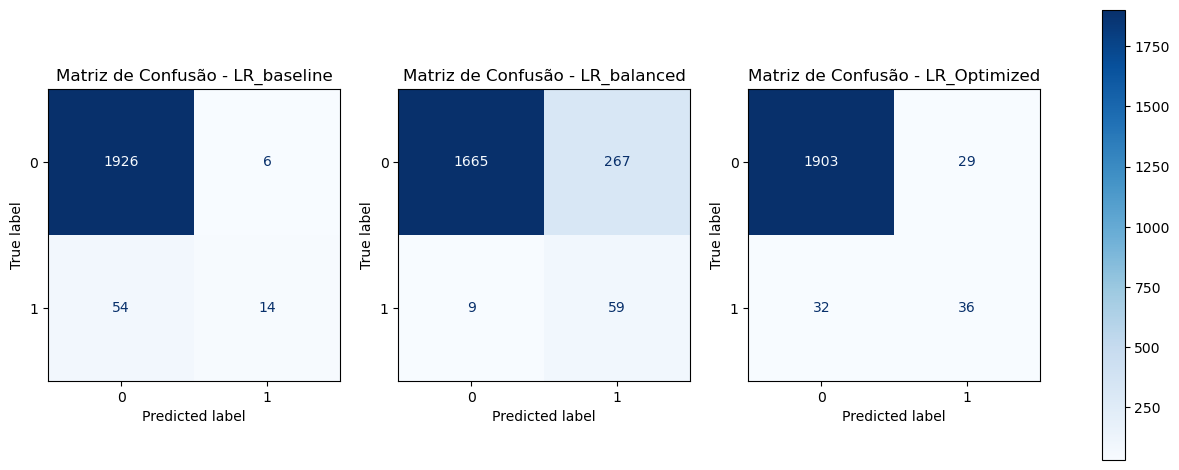

In [23]:
fig, ax = plt.subplots(1,3,figsize=(16, 9))
images = []
for i,modelo in enumerate(pipelines_resultados):
    disp = ConfusionMatrixDisplay(confusion_matrix=pipelines_resultados[modelo][-1])
    disp.plot(cmap='Blues', ax=ax[i], colorbar = False)
    ax[i].set_title(f'Matriz de Confusão - {modelo}')
    images.append(ax[i].images[0])

fig.colorbar(images[-1], ax=ax, location='right', shrink=0.65)

Even though we had 63 correct predictions, our model had about the same amount of misses as the baseline model.

The cost of a false positive and a false negative for the company may be diferent, and it may be the decisive method to determine which one to use.

Anyway, we will try another model to check whether we will have better results or not, since our logistic regressor is a simpler one.

# XGBoost vs Random Forest

Now, we will do a quick comparison between both models through Grid Search, and the best found parameters will be used later in optuna

In [24]:
#Creating the pre-processor part.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_continuas),
        ('cat', OrdinalEncoder(categories=[['L', 'M', 'H']]), features_categoricas)
    ])

# Creating the main pipeline:
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', sampler), # Trata o desbalanceamento
    ('classifier', XGBClassifier()) 
])

#Configuring searchgridCV - Note: you may use the RandomSearchCV now to do a faster analysis, and then perform a GridSearch to tune the best model you found.
param_grid = [
    # Random Forest
    {
        'classifier': [RandomForestClassifier()],
        'classifier__n_estimators': [100,150,200],
        'classifier__max_depth': [1,2,5,10],
        'classifier__min_samples_leaf':[1,3,5],
        'classifier__random_state':[42]
    },
    # XGBoost
    {
        'classifier': [XGBClassifier()],
        'classifier__n_estimators': [50,100, 200],
        'classifier__learning_rate': [0.01,0.05, 0.1,0.2],
        'classifier__max_depth': [2,3,5],
        'classifier__random_state':[42]
    },
]

#building the grid search model
grid_search = GridSearchCV(
    pipe, 
    param_grid, 
    cv=5, 
    scoring='matthews_corrcoef', # F1-score
    n_jobs=-1
)

# 7. Executing the model
grid_search.fit(x_train, y_train)

# 8. Final Evaluation
y_pred = grid_search.predict(x_test)

print(f"Best Model: {grid_search.best_params_}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

#pipelines_resultados['Grid'] = [pipe,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = scores,return_train_score=True),classification_report(y_test,pipe.predict(x_test)),confusion_matrix(y_test,pipe.predict(x_test))]


Best Model: {'classifier': RandomForestClassifier(), 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 150, 'classifier__random_state': 42}

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.92      0.68      0.78        68

    accuracy                           0.99      2000
   macro avg       0.95      0.84      0.89      2000
weighted avg       0.99      0.99      0.99      2000



In [25]:
str(grid_search.best_params_['classifier'])[:-2]

'RandomForestClassifier'

In [26]:
pipelines_resultados[modelo := str(grid_search.best_params_['classifier'])[:-2]] = [grid_search,grid_search.fit(x_train,y_train),grid_search.predict(x_test),cross_validate(grid_search, x_train, y_train, cv=cv, scoring = scores,return_train_score=True),classification_report(y_test,grid_search.predict(x_test)),confusion_matrix(y_test,grid_search.predict(x_test))]

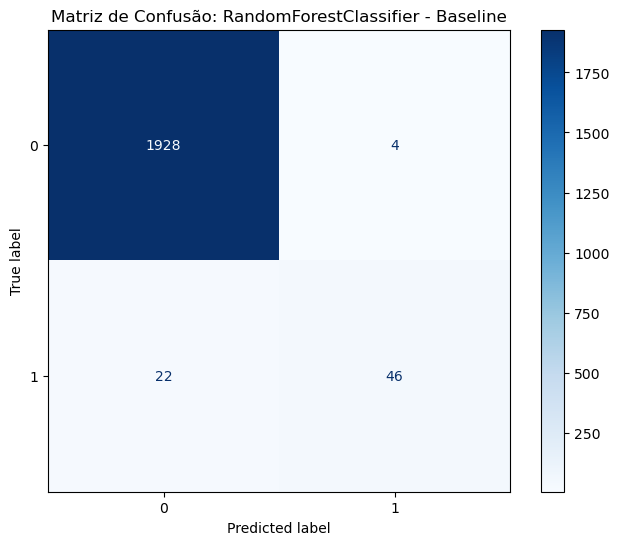

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=pipelines_resultados[modelo][-1])

disp.plot(cmap='Blues', ax=ax)
plt.title(f"Matriz de Confusão: {modelo} - Baseline")
plt.show()

## IMPROVEMENT ANALYSIS

So our Random Forest Classifier performed much better than our best logistic Regression Model, and it was better than XGBoost in the Grid Search.

With 46 correct failure predictions, and 26 misslabelling, starts to have a nice performance and value to the business. Now let's further tune it with Optuna and check the results


## RFC Tuning - Optuna

NOw with some hyperparameters tuned, we will perform furhter tuning through Optuna


Still, this script may take a while, so you can do parallel work while it runs

In [28]:
grid_search.best_params_['classifier']

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
# ============================================================
# BLOCO 1 — Preprocessor (igual ao seu pipeline atual)
# ============================================================
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), features_continuas),
    ('cat', OrdinalEncoder(), features_categoricas)
])

# ============================================================
# BLOCO 2 — Função objetivo
# O Optuna chama esta função N vezes, cada vez sugerindo
# valores diferentes para os hiperparâmetros.
# O objetivo é MAXIMIZAR o F1-weighted.
# ============================================================
def objective(trial):

    # Hiperparâmetros do RFC — o Optuna sugere os valores
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 150),
        'criterion':         trial.suggest_categorical('criterion',['gini', 'entropy', 'log_loss']),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':        trial.suggest_categorical('max_features',['sqrt', 'log2', None]),
        'ccp_alpha':  trial.suggest_float('ccp_alpha', 0, 0.05)
    }

    use_max_depth = trial.suggest_categorical('use_max_depth', [True, False])
    max_depth = trial.suggest_int('max_depth', 1, 50) if use_max_depth else None
    
    # Monta o pipeline com os parâmetros sugeridos
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            **params,
            max_depth = max_depth,
            random_state=42,
            class_weight = 'balanced'
        ))
    ])

    # Cross-validation estratificado — mantém proporção das classes
    cv = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipe, x_train, y_train,
        cv=cv,
        scoring='matthews_corrcoef',
        n_jobs=-1
    )

    return scores.mean()

# ============================================================
# BLOCO 3 — Execução do estudo
# O pruner cancela tentativas ruins antes de terminar,
# economizando tempo computacional
# ============================================================

In [30]:
sampler_optuna  = optuna.samplers.TPESampler(seed=42)   # Bayesiano
pruner_optuna   = optuna.pruners.MedianPruner()         # Poda tentativas ruins

study = optuna.create_study(
    direction='maximize',           # Queremos maximizar o F1
    sampler=sampler_optuna,
    pruner=pruner_optuna
)

# n_trials = número de combinações testadas
# 100 tentativas já costuma convergir bem para XGBoost
study.optimize(objective, n_trials=800, show_progress_bar=True, n_jobs = -1)


[I 2026-03-09 10:40:19,553] A new study created in memory with name: no-name-6d0bf7bc-c24d-4573-b46b-a0e2dc6cc095
Best trial: 1. Best value: 0.554044:   0%|          | 1/800 [00:04<58:32,  4.40s/it]

[I 2026-03-09 10:40:23,946] Trial 1 finished with value: 0.5540438794729041 and parameters: {'n_estimators': 127, 'criterion': 'log_loss', 'min_samples_split': 15, 'min_samples_leaf': 14, 'max_features': 'log2', 'ccp_alpha': 0.012627038399976276, 'use_max_depth': False}. Best is trial 1 with value: 0.5540438794729041.


Best trial: 1. Best value: 0.554044:   0%|          | 2/800 [00:07<49:42,  3.74s/it]

[I 2026-03-09 10:40:27,218] Trial 0 finished with value: 0.5120487988808043 and parameters: {'n_estimators': 82, 'criterion': 'log_loss', 'min_samples_split': 17, 'min_samples_leaf': 8, 'max_features': 'log2', 'ccp_alpha': 0.03477483500188494, 'use_max_depth': True, 'max_depth': 46}. Best is trial 1 with value: 0.5540438794729041.


Best trial: 7. Best value: 0.573867:   0%|          | 3/800 [00:13<59:49,  4.50s/it]

[I 2026-03-09 10:40:32,631] Trial 7 finished with value: 0.57386706529928 and parameters: {'n_estimators': 72, 'criterion': 'entropy', 'min_samples_split': 29, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'ccp_alpha': 0.008924920647142792, 'use_max_depth': True, 'max_depth': 18}. Best is trial 7 with value: 0.57386706529928.


Best trial: 3. Best value: 0.670222:   1%|          | 6/800 [00:13<18:25,  1.39s/it]

[I 2026-03-09 10:40:33,020] Trial 5 finished with value: 0.34940681428362197 and parameters: {'n_estimators': 92, 'criterion': 'gini', 'min_samples_split': 14, 'min_samples_leaf': 7, 'max_features': 'log2', 'ccp_alpha': 0.03834552107663196, 'use_max_depth': False}. Best is trial 7 with value: 0.57386706529928.
[I 2026-03-09 10:40:33,114] Trial 2 finished with value: 0.5078161821745466 and parameters: {'n_estimators': 65, 'criterion': 'entropy', 'min_samples_split': 19, 'min_samples_leaf': 7, 'max_features': 'log2', 'ccp_alpha': 0.03806919930589089, 'use_max_depth': False}. Best is trial 7 with value: 0.57386706529928.
[I 2026-03-09 10:40:33,170] Trial 3 finished with value: 0.6702224507567756 and parameters: {'n_estimators': 129, 'criterion': 'entropy', 'min_samples_split': 28, 'min_samples_leaf': 11, 'max_features': 'sqrt', 'ccp_alpha': 0.003965350710507915, 'use_max_depth': True, 'max_depth': 18}. Best is trial 3 with value: 0.6702224507567756.


Best trial: 3. Best value: 0.670222:   1%|          | 7/800 [00:15<18:18,  1.39s/it]

[I 2026-03-09 10:40:34,537] Trial 6 finished with value: 0.4526457611343655 and parameters: {'n_estimators': 84, 'criterion': 'entropy', 'min_samples_split': 16, 'min_samples_leaf': 7, 'max_features': 'log2', 'ccp_alpha': 0.04729330772813398, 'use_max_depth': True, 'max_depth': 47}. Best is trial 3 with value: 0.6702224507567756.
[I 2026-03-09 10:40:34,620] Trial 4 finished with value: 0.5975496782767629 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 16, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.007634982832562337, 'use_max_depth': False}. Best is trial 3 with value: 0.6702224507567756.


Best trial: 3. Best value: 0.670222:   1%|          | 9/800 [00:18<20:02,  1.52s/it]

[I 2026-03-09 10:40:37,927] Trial 8 finished with value: 0.5453163649520121 and parameters: {'n_estimators': 83, 'criterion': 'entropy', 'min_samples_split': 17, 'min_samples_leaf': 11, 'max_features': None, 'ccp_alpha': 0.04810583595404365, 'use_max_depth': True, 'max_depth': 14}. Best is trial 3 with value: 0.6702224507567756.


Best trial: 3. Best value: 0.670222:   1%|▏         | 10/800 [00:19<18:41,  1.42s/it]

[I 2026-03-09 10:40:39,028] Trial 9 finished with value: 0.5395718817786122 and parameters: {'n_estimators': 66, 'criterion': 'entropy', 'min_samples_split': 28, 'min_samples_leaf': 9, 'max_features': 'log2', 'ccp_alpha': 0.02302627425858605, 'use_max_depth': True, 'max_depth': 35}. Best is trial 3 with value: 0.6702224507567756.


Best trial: 3. Best value: 0.670222:   1%|▏         | 11/800 [00:26<35:58,  2.74s/it]

[I 2026-03-09 10:40:45,617] Trial 10 finished with value: 0.5588818616768889 and parameters: {'n_estimators': 135, 'criterion': 'entropy', 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.026432938062124656, 'use_max_depth': True, 'max_depth': 17}. Best is trial 3 with value: 0.6702224507567756.


Best trial: 3. Best value: 0.670222:   2%|▏         | 12/800 [00:28<33:36,  2.56s/it]

[I 2026-03-09 10:40:47,688] Trial 11 finished with value: 0.4755508438977698 and parameters: {'n_estimators': 110, 'criterion': 'entropy', 'min_samples_split': 20, 'min_samples_leaf': 15, 'max_features': 'log2', 'ccp_alpha': 0.04324385103397382, 'use_max_depth': True, 'max_depth': 11}. Best is trial 3 with value: 0.6702224507567756.


Best trial: 3. Best value: 0.670222:   2%|▏         | 13/800 [00:28<26:49,  2.05s/it]

[I 2026-03-09 10:40:48,387] Trial 12 finished with value: 0.3278954523705789 and parameters: {'n_estimators': 119, 'criterion': 'entropy', 'min_samples_split': 29, 'min_samples_leaf': 17, 'max_features': 'sqrt', 'ccp_alpha': 0.0370506301115612, 'use_max_depth': True, 'max_depth': 2}. Best is trial 3 with value: 0.6702224507567756.


Best trial: 3. Best value: 0.670222:   2%|▏         | 14/800 [00:30<24:06,  1.84s/it]

[I 2026-03-09 10:40:49,708] Trial 13 finished with value: 0.4679770593708116 and parameters: {'n_estimators': 65, 'criterion': 'entropy', 'min_samples_split': 13, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.044590325724867555, 'use_max_depth': False}. Best is trial 3 with value: 0.6702224507567756.


Best trial: 3. Best value: 0.670222:   2%|▏         | 15/800 [00:31<23:21,  1.78s/it]

[I 2026-03-09 10:40:51,354] Trial 14 finished with value: 0.4493291326848758 and parameters: {'n_estimators': 109, 'criterion': 'log_loss', 'min_samples_split': 11, 'min_samples_leaf': 14, 'max_features': 'sqrt', 'ccp_alpha': 0.03984708336331799, 'use_max_depth': False}. Best is trial 3 with value: 0.6702224507567756.


Best trial: 3. Best value: 0.670222:   2%|▏         | 16/800 [00:33<22:20,  1.71s/it]

[I 2026-03-09 10:40:52,885] Trial 15 finished with value: 0.49425155029276124 and parameters: {'n_estimators': 90, 'criterion': 'gini', 'min_samples_split': 23, 'min_samples_leaf': 8, 'max_features': 'log2', 'ccp_alpha': 0.014203771547801792, 'use_max_depth': True, 'max_depth': 9}. Best is trial 3 with value: 0.6702224507567756.


Best trial: 3. Best value: 0.670222:   2%|▏         | 17/800 [00:38<35:20,  2.71s/it]

[I 2026-03-09 10:40:57,983] Trial 16 finished with value: 0.5446561554458131 and parameters: {'n_estimators': 120, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 14, 'max_features': None, 'ccp_alpha': 0.042133041051047954, 'use_max_depth': True, 'max_depth': 6}. Best is trial 3 with value: 0.6702224507567756.


Best trial: 3. Best value: 0.670222:   2%|▏         | 18/800 [00:39<29:25,  2.26s/it]

[I 2026-03-09 10:40:59,178] Trial 17 finished with value: 0.33137400384117177 and parameters: {'n_estimators': 148, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'ccp_alpha': 0.0018972422023042154, 'use_max_depth': True, 'max_depth': 2}. Best is trial 3 with value: 0.6702224507567756.


Best trial: 3. Best value: 0.670222:   2%|▏         | 19/800 [00:41<26:36,  2.04s/it]

[I 2026-03-09 10:41:00,710] Trial 18 finished with value: 0.6352255170233345 and parameters: {'n_estimators': 115, 'criterion': 'gini', 'min_samples_split': 23, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'ccp_alpha': 6.440502192086054e-05, 'use_max_depth': False}. Best is trial 3 with value: 0.6702224507567756.


Best trial: 3. Best value: 0.670222:   2%|▎         | 20/800 [00:42<24:43,  1.90s/it]

[I 2026-03-09 10:41:02,280] Trial 19 finished with value: 0.5633158980623184 and parameters: {'n_estimators': 117, 'criterion': 'gini', 'min_samples_split': 24, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'ccp_alpha': 0.003172340630462544, 'use_max_depth': False}. Best is trial 3 with value: 0.6702224507567756.


Best trial: 3. Best value: 0.670222:   3%|▎         | 21/800 [00:44<25:27,  1.96s/it]

[I 2026-03-09 10:41:04,380] Trial 20 finished with value: 0.6577232541625868 and parameters: {'n_estimators': 146, 'criterion': 'gini', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002766252383632409, 'use_max_depth': False}. Best is trial 3 with value: 0.6702224507567756.


Best trial: 3. Best value: 0.670222:   3%|▎         | 22/800 [00:46<25:23,  1.96s/it]

[I 2026-03-09 10:41:06,331] Trial 21 finished with value: 0.6329783435935765 and parameters: {'n_estimators': 149, 'criterion': 'gini', 'min_samples_split': 24, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'ccp_alpha': 0.0009646752253025075, 'use_max_depth': False}. Best is trial 3 with value: 0.6702224507567756.


Best trial: 22. Best value: 0.782377:   3%|▎         | 23/800 [00:48<25:31,  1.97s/it]

[I 2026-03-09 10:41:08,334] Trial 22 finished with value: 0.7823765107792231 and parameters: {'n_estimators': 149, 'criterion': 'gini', 'min_samples_split': 23, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0005417799157880539, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   3%|▎         | 24/800 [00:50<25:40,  1.98s/it]

[I 2026-03-09 10:41:10,349] Trial 23 finished with value: 0.7127152674841866 and parameters: {'n_estimators': 145, 'criterion': 'gini', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0020809596300189895, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   3%|▎         | 25/800 [00:53<27:55,  2.16s/it]

[I 2026-03-09 10:41:12,918] Trial 24 finished with value: 0.6006546947139668 and parameters: {'n_estimators': 148, 'criterion': 'gini', 'min_samples_split': 24, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'ccp_alpha': 0.002216531647800703, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   3%|▎         | 26/800 [00:55<27:08,  2.10s/it]

[I 2026-03-09 10:41:14,896] Trial 25 finished with value: 0.6696191359615824 and parameters: {'n_estimators': 102, 'criterion': 'gini', 'min_samples_split': 24, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002566133617388034, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   3%|▎         | 27/800 [00:57<26:05,  2.03s/it]

[I 2026-03-09 10:41:16,735] Trial 26 finished with value: 0.6372968911447136 and parameters: {'n_estimators': 144, 'criterion': 'gini', 'min_samples_split': 25, 'min_samples_leaf': 19, 'max_features': 'sqrt', 'ccp_alpha': 0.001113395483841793, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   4%|▎         | 28/800 [00:59<25:25,  1.98s/it]

[I 2026-03-09 10:41:18,597] Trial 27 finished with value: 0.43474312761653455 and parameters: {'n_estimators': 141, 'criterion': 'gini', 'min_samples_split': 25, 'min_samples_leaf': 17, 'max_features': 'sqrt', 'ccp_alpha': 0.018398587294833815, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   4%|▎         | 29/800 [01:01<25:44,  2.00s/it]

[I 2026-03-09 10:41:20,665] Trial 28 finished with value: 0.6843144362988411 and parameters: {'n_estimators': 150, 'criterion': 'gini', 'min_samples_split': 26, 'min_samples_leaf': 12, 'max_features': 'sqrt', 'ccp_alpha': 0.0006184103229876807, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   4%|▍         | 30/800 [01:03<25:33,  1.99s/it]

[I 2026-03-09 10:41:22,626] Trial 29 finished with value: 0.5265258111410439 and parameters: {'n_estimators': 137, 'criterion': 'gini', 'min_samples_split': 8, 'min_samples_leaf': 12, 'max_features': 'sqrt', 'ccp_alpha': 0.0072418402174248666, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   4%|▍         | 31/800 [01:05<26:10,  2.04s/it]

[I 2026-03-09 10:41:24,791] Trial 30 finished with value: 0.44088886351723566 and parameters: {'n_estimators': 138, 'criterion': 'gini', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.018228791453682038, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   4%|▍         | 32/800 [01:07<25:33,  2.00s/it]

[I 2026-03-09 10:41:26,684] Trial 31 finished with value: 0.5309299727533741 and parameters: {'n_estimators': 138, 'criterion': 'gini', 'min_samples_split': 26, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.007784336170883878, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   4%|▍         | 33/800 [01:09<27:24,  2.14s/it]

[I 2026-03-09 10:41:29,165] Trial 32 finished with value: 0.43798275661684416 and parameters: {'n_estimators': 136, 'criterion': 'gini', 'min_samples_split': 27, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.019986747981523004, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   4%|▍         | 34/800 [01:12<28:22,  2.22s/it]

[I 2026-03-09 10:41:31,575] Trial 33 finished with value: 0.43008765541261534 and parameters: {'n_estimators': 137, 'criterion': 'gini', 'min_samples_split': 27, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.021130667530795566, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   4%|▍         | 35/800 [01:14<27:52,  2.19s/it]

[I 2026-03-09 10:41:33,675] Trial 34 finished with value: 0.5402521814886769 and parameters: {'n_estimators': 136, 'criterion': 'log_loss', 'min_samples_split': 27, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.01769822891054335, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   4%|▍         | 36/800 [01:16<27:28,  2.16s/it]

[I 2026-03-09 10:41:35,768] Trial 35 finished with value: 0.613835576702 and parameters: {'n_estimators': 132, 'criterion': 'log_loss', 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.006881176326034624, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   5%|▍         | 37/800 [01:21<39:28,  3.10s/it]

[I 2026-03-09 10:41:41,081] Trial 36 finished with value: 0.5768925306383932 and parameters: {'n_estimators': 128, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': None, 'ccp_alpha': 0.00758034242488816, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   5%|▍         | 38/800 [01:23<35:14,  2.77s/it]

[I 2026-03-09 10:41:43,084] Trial 37 finished with value: 0.5615396367333504 and parameters: {'n_estimators': 51, 'criterion': 'log_loss', 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': None, 'ccp_alpha': 0.03060673286632566, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   5%|▍         | 39/800 [01:26<36:03,  2.84s/it]

[I 2026-03-09 10:41:46,084] Trial 38 finished with value: 0.6304471660746127 and parameters: {'n_estimators': 129, 'criterion': 'log_loss', 'min_samples_split': 27, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0064265012910896075, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   5%|▌         | 40/800 [01:28<33:18,  2.63s/it]

[I 2026-03-09 10:41:48,219] Trial 39 finished with value: 0.5526519921380904 and parameters: {'n_estimators': 129, 'criterion': 'log_loss', 'min_samples_split': 21, 'min_samples_leaf': 12, 'max_features': 'sqrt', 'ccp_alpha': 0.010965287375168912, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   5%|▌         | 41/800 [01:30<30:47,  2.43s/it]

[I 2026-03-09 10:41:50,198] Trial 40 finished with value: 0.49153264127947244 and parameters: {'n_estimators': 128, 'criterion': 'log_loss', 'min_samples_split': 21, 'min_samples_leaf': 11, 'max_features': 'sqrt', 'ccp_alpha': 0.03144145019572067, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   5%|▌         | 42/800 [01:35<39:59,  3.17s/it]

[I 2026-03-09 10:41:55,074] Trial 41 finished with value: 0.5604890041340227 and parameters: {'n_estimators': 128, 'criterion': 'log_loss', 'min_samples_split': 21, 'min_samples_leaf': 13, 'max_features': None, 'ccp_alpha': 0.011783627618292318, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   5%|▌         | 43/800 [01:40<46:59,  3.72s/it]

[I 2026-03-09 10:42:00,096] Trial 42 finished with value: 0.562247535299286 and parameters: {'n_estimators': 127, 'criterion': 'log_loss', 'min_samples_split': 20, 'min_samples_leaf': 12, 'max_features': None, 'ccp_alpha': 0.011205583586569881, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   6%|▌         | 45/800 [01:46<39:53,  3.17s/it]

[I 2026-03-09 10:42:06,335] Trial 43 finished with value: 0.5619742787305904 and parameters: {'n_estimators': 128, 'criterion': 'log_loss', 'min_samples_split': 30, 'min_samples_leaf': 12, 'max_features': None, 'ccp_alpha': 0.012271735915239949, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.
[I 2026-03-09 10:42:06,455] Trial 44 finished with value: 0.3555932466617274 and parameters: {'n_estimators': 53, 'criterion': 'gini', 'min_samples_split': 30, 'min_samples_leaf': 12, 'max_features': 'sqrt', 'ccp_alpha': 0.030324959543581, 'use_max_depth': True, 'max_depth': 29}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   6%|▌         | 46/800 [01:48<34:29,  2.74s/it]

[I 2026-03-09 10:42:08,204] Trial 45 finished with value: 0.4991244299541229 and parameters: {'n_estimators': 127, 'criterion': 'gini', 'min_samples_split': 30, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'ccp_alpha': 0.012201729040647254, 'use_max_depth': True, 'max_depth': 28}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   6%|▌         | 47/800 [01:50<30:24,  2.42s/it]

[I 2026-03-09 10:42:09,878] Trial 46 finished with value: 0.4967990262194315 and parameters: {'n_estimators': 123, 'criterion': 'gini', 'min_samples_split': 30, 'min_samples_leaf': 12, 'max_features': 'sqrt', 'ccp_alpha': 0.011455147982783341, 'use_max_depth': True, 'max_depth': 29}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   6%|▌         | 48/800 [01:52<28:34,  2.28s/it]

[I 2026-03-09 10:42:11,823] Trial 47 finished with value: 0.4986362873283199 and parameters: {'n_estimators': 142, 'criterion': 'gini', 'min_samples_split': 18, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'ccp_alpha': 0.012883646287197138, 'use_max_depth': True, 'max_depth': 29}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   6%|▌         | 49/800 [01:54<27:24,  2.19s/it]

[I 2026-03-09 10:42:13,805] Trial 48 finished with value: 0.5982608926060631 and parameters: {'n_estimators': 142, 'criterion': 'gini', 'min_samples_split': 30, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0037379973365183946, 'use_max_depth': True, 'max_depth': 26}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   6%|▋         | 50/800 [01:56<26:39,  2.13s/it]

[I 2026-03-09 10:42:15,790] Trial 49 finished with value: 0.5670963675579275 and parameters: {'n_estimators': 142, 'criterion': 'gini', 'min_samples_split': 30, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.004813013327924095, 'use_max_depth': True, 'max_depth': 28}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   6%|▋         | 51/800 [01:59<29:18,  2.35s/it]

[I 2026-03-09 10:42:18,641] Trial 50 finished with value: 0.5637784868932249 and parameters: {'n_estimators': 144, 'criterion': 'gini', 'min_samples_split': 30, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.004845703595054554, 'use_max_depth': True, 'max_depth': 26}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   6%|▋         | 52/800 [02:01<28:32,  2.29s/it]

[I 2026-03-09 10:42:20,808] Trial 51 finished with value: 0.5608739804442211 and parameters: {'n_estimators': 144, 'criterion': 'gini', 'min_samples_split': 18, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.005070598902659285, 'use_max_depth': True, 'max_depth': 27}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   7%|▋         | 53/800 [02:02<25:08,  2.02s/it]

[I 2026-03-09 10:42:22,199] Trial 52 finished with value: 0.5694840434284627 and parameters: {'n_estimators': 98, 'criterion': 'gini', 'min_samples_split': 14, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.004612545484011745, 'use_max_depth': True, 'max_depth': 24}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   7%|▋         | 54/800 [02:04<26:02,  2.09s/it]

[I 2026-03-09 10:42:24,465] Trial 53 finished with value: 0.7009972114827179 and parameters: {'n_estimators': 143, 'criterion': 'entropy', 'min_samples_split': 17, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.004891869245527683, 'use_max_depth': True, 'max_depth': 22}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   7%|▋         | 55/800 [02:07<26:15,  2.11s/it]

[I 2026-03-09 10:42:26,623] Trial 54 finished with value: 0.6941456199471924 and parameters: {'n_estimators': 108, 'criterion': 'entropy', 'min_samples_split': 18, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.004990141310614831, 'use_max_depth': True, 'max_depth': 38}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   7%|▋         | 56/800 [02:09<25:50,  2.08s/it]

[I 2026-03-09 10:42:28,638] Trial 55 finished with value: 0.714480030561294 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 14, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0046962238702314, 'use_max_depth': True, 'max_depth': 38}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   7%|▋         | 57/800 [02:11<26:10,  2.11s/it]

[I 2026-03-09 10:42:30,821] Trial 56 finished with value: 0.6828874644521499 and parameters: {'n_estimators': 107, 'criterion': 'entropy', 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00513016329987786, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 22. Best value: 0.782377:   7%|▋         | 58/800 [02:13<27:38,  2.24s/it]

[I 2026-03-09 10:42:33,339] Trial 57 finished with value: 0.6821970828414348 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_features': 'log2', 'ccp_alpha': 0.004869517898913726, 'use_max_depth': False}. Best is trial 22 with value: 0.7823765107792231.


Best trial: 58. Best value: 0.83204:   7%|▋         | 59/800 [02:16<28:54,  2.34s/it] 

[I 2026-03-09 10:42:35,927] Trial 58 finished with value: 0.8320402075841078 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 5.3224252534291266e-05, 'use_max_depth': False}. Best is trial 58 with value: 0.8320402075841078.


Best trial: 58. Best value: 0.83204:   8%|▊         | 60/800 [02:18<27:59,  2.27s/it]

[I 2026-03-09 10:42:38,032] Trial 59 finished with value: 0.8305581863129048 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.00021896135114812484, 'use_max_depth': False}. Best is trial 58 with value: 0.8320402075841078.


Best trial: 58. Best value: 0.83204:   8%|▊         | 61/800 [02:20<27:41,  2.25s/it]

[I 2026-03-09 10:42:40,231] Trial 60 finished with value: 0.8147683032646693 and parameters: {'n_estimators': 108, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0025880142337569314, 'use_max_depth': False}. Best is trial 58 with value: 0.8320402075841078.


Best trial: 58. Best value: 0.83204:   8%|▊         | 62/800 [02:22<24:56,  2.03s/it]

[I 2026-03-09 10:42:41,747] Trial 61 finished with value: 0.7715759109368214 and parameters: {'n_estimators': 76, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_features': 'log2', 'ccp_alpha': 1.3273433579971358e-05, 'use_max_depth': True, 'max_depth': 37}. Best is trial 58 with value: 0.8320402075841078.


Best trial: 58. Best value: 0.83204:   8%|▊         | 63/800 [02:25<28:11,  2.30s/it]

[I 2026-03-09 10:42:44,665] Trial 62 finished with value: 0.5597929163656037 and parameters: {'n_estimators': 150, 'criterion': 'entropy', 'min_samples_split': 16, 'min_samples_leaf': 10, 'max_features': 'log2', 'ccp_alpha': 0.01493908704018404, 'use_max_depth': True, 'max_depth': 42}. Best is trial 58 with value: 0.8320402075841078.


Best trial: 58. Best value: 0.83204:   8%|▊         | 64/800 [02:27<27:19,  2.23s/it]

[I 2026-03-09 10:42:46,731] Trial 63 finished with value: 0.579797628510345 and parameters: {'n_estimators': 104, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.009838414294209471, 'use_max_depth': True, 'max_depth': 39}. Best is trial 58 with value: 0.8320402075841078.


Best trial: 58. Best value: 0.83204:   8%|▊         | 65/800 [02:31<33:12,  2.71s/it]

[I 2026-03-09 10:42:50,564] Trial 64 finished with value: 0.580231752141064 and parameters: {'n_estimators': 150, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.00937087130129687, 'use_max_depth': True, 'max_depth': 39}. Best is trial 58 with value: 0.8320402075841078.


Best trial: 58. Best value: 0.83204:   8%|▊         | 66/800 [02:32<30:26,  2.49s/it]

[I 2026-03-09 10:42:52,542] Trial 65 finished with value: 0.8199905509784263 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 16, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.00018299277762446123, 'use_max_depth': True, 'max_depth': 38}. Best is trial 58 with value: 0.8320402075841078.


Best trial: 58. Best value: 0.83204:   8%|▊         | 67/800 [02:34<26:57,  2.21s/it]

[I 2026-03-09 10:42:54,086] Trial 66 finished with value: 0.5664027085808254 and parameters: {'n_estimators': 79, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.01490746414260701, 'use_max_depth': True, 'max_depth': 40}. Best is trial 58 with value: 0.8320402075841078.


Best trial: 58. Best value: 0.83204:   8%|▊         | 68/800 [02:36<25:26,  2.09s/it]

[I 2026-03-09 10:42:55,895] Trial 67 finished with value: 0.5840011832427396 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.009318889154934753, 'use_max_depth': True, 'max_depth': 41}. Best is trial 58 with value: 0.8320402075841078.


Best trial: 68. Best value: 0.836409:   9%|▊         | 69/800 [02:38<24:43,  2.03s/it]

[I 2026-03-09 10:42:57,790] Trial 68 finished with value: 0.8364091109170694 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.00027573834455177305, 'use_max_depth': False}. Best is trial 68 with value: 0.8364091109170694.


Best trial: 68. Best value: 0.836409:   9%|▉         | 70/800 [02:40<23:54,  1.96s/it]

[I 2026-03-09 10:42:59,606] Trial 69 finished with value: 0.5857295551180899 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.009366387631764297, 'use_max_depth': False}. Best is trial 68 with value: 0.8364091109170694.


Best trial: 68. Best value: 0.836409:   9%|▉         | 71/800 [02:42<26:40,  2.20s/it]

[I 2026-03-09 10:43:02,328] Trial 70 finished with value: 0.5845359947649795 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.00967528531306712, 'use_max_depth': False}. Best is trial 68 with value: 0.8364091109170694.


Best trial: 68. Best value: 0.836409:   9%|▉         | 72/800 [02:44<25:41,  2.12s/it]

[I 2026-03-09 10:43:04,266] Trial 71 finished with value: 0.8351669206907728 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0006275324975096699, 'use_max_depth': False}. Best is trial 68 with value: 0.8364091109170694.


Best trial: 68. Best value: 0.836409:   9%|▉         | 73/800 [02:47<29:05,  2.40s/it]

[I 2026-03-09 10:43:07,340] Trial 72 finished with value: 0.8348259609355615 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.00015156508905920507, 'use_max_depth': False}. Best is trial 68 with value: 0.8364091109170694.


Best trial: 73. Best value: 0.838157:   9%|▉         | 74/800 [02:49<26:22,  2.18s/it]

[I 2026-03-09 10:43:08,998] Trial 73 finished with value: 0.8381574184425274 and parameters: {'n_estimators': 78, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 3.6078306547665645e-05, 'use_max_depth': True, 'max_depth': 34}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:   9%|▉         | 75/800 [02:51<25:23,  2.10s/it]

[I 2026-03-09 10:43:10,916] Trial 74 finished with value: 0.8307370165018595 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 6.345856273700518e-05, 'use_max_depth': True, 'max_depth': 50}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  10%|▉         | 76/800 [02:53<24:49,  2.06s/it]

[I 2026-03-09 10:43:12,875] Trial 75 finished with value: 0.8305531103983714 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.00040178894239737003, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  10%|▉         | 77/800 [02:55<24:20,  2.02s/it]

[I 2026-03-09 10:43:14,806] Trial 76 finished with value: 0.8244334661396981 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.00021221295173906566, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  10%|▉         | 78/800 [02:57<25:01,  2.08s/it]

[I 2026-03-09 10:43:17,027] Trial 77 finished with value: 0.8244334661396981 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.00025156991743909956, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  10%|▉         | 79/800 [02:59<24:04,  2.00s/it]

[I 2026-03-09 10:43:18,854] Trial 78 finished with value: 0.83278292076879 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.000537277888609862, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  10%|█         | 80/800 [03:01<25:00,  2.08s/it]

[I 2026-03-09 10:43:21,126] Trial 79 finished with value: 0.8244334661396981 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0002999270120070351, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  10%|█         | 81/800 [03:04<28:34,  2.38s/it]

[I 2026-03-09 10:43:24,204] Trial 80 finished with value: 0.8274441976311215 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0016531698240613325, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  10%|█         | 82/800 [03:06<26:26,  2.21s/it]

[I 2026-03-09 10:43:26,004] Trial 81 finished with value: 0.8266571923467145 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0020449862551233148, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  10%|█         | 83/800 [03:08<25:09,  2.11s/it]

[I 2026-03-09 10:43:27,871] Trial 82 finished with value: 0.8258741935775138 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0014681029641721577, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  10%|█         | 84/800 [03:10<24:39,  2.07s/it]

[I 2026-03-09 10:43:29,849] Trial 83 finished with value: 0.8280435388088485 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0014024316821056489, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  11%|█         | 85/800 [03:12<25:15,  2.12s/it]

[I 2026-03-09 10:43:32,092] Trial 84 finished with value: 0.8148872884565741 and parameters: {'n_estimators': 113, 'criterion': 'entropy', 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.001849008495322638, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  11%|█         | 86/800 [03:14<23:42,  1.99s/it]

[I 2026-03-09 10:43:33,789] Trial 85 finished with value: 0.8073389524975092 and parameters: {'n_estimators': 85, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.001883834558438149, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  11%|█         | 87/800 [03:15<22:35,  1.90s/it]

[I 2026-03-09 10:43:35,468] Trial 86 finished with value: 0.8095624292623612 and parameters: {'n_estimators': 85, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.0017556603624598328, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  11%|█         | 88/800 [03:18<24:21,  2.05s/it]

[I 2026-03-09 10:43:37,873] Trial 87 finished with value: 0.7883941792519998 and parameters: {'n_estimators': 83, 'criterion': 'entropy', 'min_samples_split': 7, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.002417106947158109, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  11%|█         | 89/800 [03:20<24:50,  2.10s/it]

[I 2026-03-09 10:43:40,080] Trial 88 finished with value: 0.7870945214682206 and parameters: {'n_estimators': 84, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.0024083077703682607, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  11%|█▏        | 90/800 [03:22<23:20,  1.97s/it]

[I 2026-03-09 10:43:41,765] Trial 89 finished with value: 0.7625230275059298 and parameters: {'n_estimators': 81, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.003010853401761069, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  11%|█▏        | 91/800 [03:23<22:14,  1.88s/it]

[I 2026-03-09 10:43:43,436] Trial 90 finished with value: 0.7499042829739182 and parameters: {'n_estimators': 84, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.0034482798667426194, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  12%|█▏        | 92/800 [03:25<21:26,  1.82s/it]

[I 2026-03-09 10:43:45,098] Trial 91 finished with value: 0.750109924697686 and parameters: {'n_estimators': 82, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.003330232755102681, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  12%|█▏        | 93/800 [03:27<21:00,  1.78s/it]

[I 2026-03-09 10:43:46,801] Trial 92 finished with value: 0.7593817207343339 and parameters: {'n_estimators': 83, 'criterion': 'entropy', 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.003311074004831673, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  12%|█▏        | 94/800 [03:29<22:03,  1.87s/it]

[I 2026-03-09 10:43:48,891] Trial 93 finished with value: 0.7605652961871245 and parameters: {'n_estimators': 104, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.0032719221277148695, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  12%|█▏        | 95/800 [03:31<22:37,  1.93s/it]

[I 2026-03-09 10:43:50,935] Trial 94 finished with value: 0.7708230346106123 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.003271273380265595, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  12%|█▏        | 96/800 [03:33<24:29,  2.09s/it]

[I 2026-03-09 10:43:53,391] Trial 95 finished with value: 0.7594152912753737 and parameters: {'n_estimators': 103, 'criterion': 'entropy', 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.003373212973902938, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  12%|█▏        | 97/800 [03:36<26:52,  2.29s/it]

[I 2026-03-09 10:43:56,175] Trial 96 finished with value: 0.7376595417953649 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0037856678671116324, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  12%|█▏        | 98/800 [03:38<26:06,  2.23s/it]

[I 2026-03-09 10:43:58,268] Trial 97 finished with value: 0.6311915097374556 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.006074072721572286, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  12%|█▏        | 99/800 [03:40<25:44,  2.20s/it]

[I 2026-03-09 10:44:00,403] Trial 98 finished with value: 0.6083532072397854 and parameters: {'n_estimators': 104, 'criterion': 'entropy', 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.006585165016657909, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  12%|█▎        | 100/800 [03:42<25:20,  2.17s/it]

[I 2026-03-09 10:44:02,503] Trial 99 finished with value: 0.6192147726287669 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.00628057169690441, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  13%|█▎        | 101/800 [03:44<24:38,  2.11s/it]

[I 2026-03-09 10:44:04,481] Trial 100 finished with value: 0.6323800731035146 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.006082715825121473, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  13%|█▎        | 102/800 [03:46<24:07,  2.07s/it]

[I 2026-03-09 10:44:06,460] Trial 101 finished with value: 0.6037957441166091 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.006647438636239175, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  13%|█▎        | 103/800 [03:48<23:51,  2.05s/it]

[I 2026-03-09 10:44:08,466] Trial 102 finished with value: 0.6099489502095963 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0065616399557211795, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  13%|█▎        | 104/800 [03:51<27:02,  2.33s/it]

[I 2026-03-09 10:44:11,437] Trial 103 finished with value: 0.6173218684825524 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.006279697088983569, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  13%|█▎        | 105/800 [03:54<26:20,  2.27s/it]

[I 2026-03-09 10:44:13,584] Trial 104 finished with value: 0.6108704802720184 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.006465783266001106, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  13%|█▎        | 106/800 [03:56<25:26,  2.20s/it]

[I 2026-03-09 10:44:15,612] Trial 105 finished with value: 0.8346004430567837 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0011667068777343383, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  13%|█▎        | 107/800 [03:58<24:49,  2.15s/it]

[I 2026-03-09 10:44:17,646] Trial 106 finished with value: 0.8370707942357911 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0010692260320846335, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  14%|█▎        | 108/800 [04:00<24:29,  2.12s/it]

[I 2026-03-09 10:44:19,706] Trial 107 finished with value: 0.8327405191971511 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.000991646869965751, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 73. Best value: 0.838157:  14%|█▎        | 109/800 [04:02<24:01,  2.09s/it]

[I 2026-03-09 10:44:21,699] Trial 108 finished with value: 0.8375048084220713 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0013754495112141044, 'use_max_depth': False}. Best is trial 73 with value: 0.8381574184425274.


Best trial: 109. Best value: 0.839211:  14%|█▍        | 110/800 [04:04<23:17,  2.03s/it]

[I 2026-03-09 10:44:23,589] Trial 109 finished with value: 0.8392113889266829 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0014074935515278073, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  14%|█▍        | 111/800 [04:06<23:47,  2.07s/it]

[I 2026-03-09 10:44:25,762] Trial 110 finished with value: 0.8265503503453842 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0014900315085131226, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  14%|█▍        | 112/800 [04:08<25:12,  2.20s/it]

[I 2026-03-09 10:44:28,261] Trial 111 finished with value: 0.6857536771005815 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 5, 'min_samples_leaf': 16, 'max_features': 'log2', 'ccp_alpha': 0.0015143804509588886, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  14%|█▍        | 113/800 [04:10<23:55,  2.09s/it]

[I 2026-03-09 10:44:30,096] Trial 112 finished with value: 0.8267362179618006 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0010239638968250612, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  14%|█▍        | 114/800 [04:14<29:56,  2.62s/it]

[I 2026-03-09 10:44:33,952] Trial 113 finished with value: 0.809580640979424 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': None, 'ccp_alpha': 0.001179589117135347, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  14%|█▍        | 115/800 [04:17<30:24,  2.66s/it]

[I 2026-03-09 10:44:36,718] Trial 114 finished with value: 0.5469841013000166 and parameters: {'n_estimators': 68, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': None, 'ccp_alpha': 0.0493596583218565, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  14%|█▍        | 116/800 [04:20<31:00,  2.72s/it]

[I 2026-03-09 10:44:39,562] Trial 115 finished with value: 0.5784971402753369 and parameters: {'n_estimators': 69, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': None, 'ccp_alpha': 0.008154914743039364, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  15%|█▍        | 117/800 [04:24<37:36,  3.30s/it]

[I 2026-03-09 10:44:44,239] Trial 116 finished with value: 0.8191202245829116 and parameters: {'n_estimators': 67, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': None, 'ccp_alpha': 0.0007366769907008998, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  15%|█▍        | 118/800 [04:29<42:40,  3.75s/it]

[I 2026-03-09 10:44:49,047] Trial 117 finished with value: 0.8254663201582677 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': None, 'ccp_alpha': 0.0011833430454173143, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  15%|█▍        | 119/800 [04:32<41:17,  3.64s/it]

[I 2026-03-09 10:44:52,410] Trial 118 finished with value: 0.8238394373397113 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.0011548382243125092, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  15%|█▌        | 120/800 [04:34<33:10,  2.93s/it]

[I 2026-03-09 10:44:53,681] Trial 119 finished with value: 0.5889855490171745 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00826268497140962, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  15%|█▌        | 121/800 [04:36<32:26,  2.87s/it]

[I 2026-03-09 10:44:56,402] Trial 120 finished with value: 0.5767574454869732 and parameters: {'n_estimators': 69, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.008283421159120355, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  15%|█▌        | 122/800 [04:39<32:05,  2.84s/it]

[I 2026-03-09 10:44:59,171] Trial 121 finished with value: 0.5962122790293167 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.008083101638327813, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  15%|█▌        | 123/800 [04:41<29:06,  2.58s/it]

[I 2026-03-09 10:45:01,154] Trial 122 finished with value: 0.503531828391536 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.035153371488826315, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  16%|█▌        | 124/800 [04:43<26:54,  2.39s/it]

[I 2026-03-09 10:45:03,097] Trial 123 finished with value: 0.5114576812670036 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.03466794796654532, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  16%|█▌        | 125/800 [04:45<25:36,  2.28s/it]

[I 2026-03-09 10:45:05,106] Trial 124 finished with value: 0.7301596837276637 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.004176281863083281, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  16%|█▌        | 126/800 [04:47<24:36,  2.19s/it]

[I 2026-03-09 10:45:07,100] Trial 125 finished with value: 0.726876741143401 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.004095745173508574, 'use_max_depth': True, 'max_depth': 50}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  16%|█▌        | 127/800 [04:48<21:27,  1.91s/it]

[I 2026-03-09 10:45:08,365] Trial 126 finished with value: 0.5444748750106707 and parameters: {'n_estimators': 61, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.026476159914855815, 'use_max_depth': True, 'max_depth': 49}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  16%|█▌        | 128/800 [04:50<21:54,  1.96s/it]

[I 2026-03-09 10:45:10,422] Trial 127 finished with value: 0.5407213232861972 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.026773957823693812, 'use_max_depth': True, 'max_depth': 50}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  16%|█▌        | 129/800 [04:52<22:02,  1.97s/it]

[I 2026-03-09 10:45:12,428] Trial 128 finished with value: 0.8124291146394915 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0024490489093546, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  16%|█▋        | 130/800 [04:56<26:11,  2.35s/it]

[I 2026-03-09 10:45:15,646] Trial 129 finished with value: 0.5491279867553662 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.023977899512995095, 'use_max_depth': True, 'max_depth': 44}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  16%|█▋        | 131/800 [04:58<25:03,  2.25s/it]

[I 2026-03-09 10:45:17,667] Trial 130 finished with value: 0.826483407431562 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.00021579019851901096, 'use_max_depth': True, 'max_depth': 49}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  16%|█▋        | 132/800 [05:00<25:21,  2.28s/it]

[I 2026-03-09 10:45:20,015] Trial 131 finished with value: 0.826483407431562 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.00013743974869431027, 'use_max_depth': True, 'max_depth': 50}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  17%|█▋        | 133/800 [05:02<25:34,  2.30s/it]

[I 2026-03-09 10:45:22,368] Trial 132 finished with value: 0.8269452129147588 and parameters: {'n_estimators': 106, 'criterion': 'entropy', 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 6.992026926121822e-05, 'use_max_depth': True, 'max_depth': 45}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  17%|█▋        | 134/800 [05:05<25:28,  2.30s/it]

[I 2026-03-09 10:45:24,651] Trial 133 finished with value: 0.5424161110488543 and parameters: {'n_estimators': 112, 'criterion': 'entropy', 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.026220197145921553, 'use_max_depth': True, 'max_depth': 45}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  17%|█▋        | 135/800 [05:06<23:19,  2.10s/it]

[I 2026-03-09 10:45:26,308] Trial 134 finished with value: 0.8049851771097907 and parameters: {'n_estimators': 79, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.002527932228524827, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  17%|█▋        | 136/800 [05:09<23:56,  2.16s/it]

[I 2026-03-09 10:45:28,615] Trial 135 finished with value: 0.8120980803688715 and parameters: {'n_estimators': 112, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0024408402045991984, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  17%|█▋        | 137/800 [05:13<30:13,  2.74s/it]

[I 2026-03-09 10:45:32,684] Trial 136 finished with value: 0.8342798597930359 and parameters: {'n_estimators': 111, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 4.242161376767162e-05, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  17%|█▋        | 138/800 [05:13<23:40,  2.15s/it]

[I 2026-03-09 10:45:33,447] Trial 137 finished with value: 0.8296703516089954 and parameters: {'n_estimators': 78, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 4.9006662491351957e-05, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  17%|█▋        | 139/800 [05:15<23:00,  2.09s/it]

[I 2026-03-09 10:45:35,405] Trial 138 finished with value: 0.8302658963532782 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.00018687319464280816, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  18%|█▊        | 140/800 [05:17<22:28,  2.04s/it]

[I 2026-03-09 10:45:37,344] Trial 139 finished with value: 0.8302037735972636 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 4.541635031403883e-05, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  18%|█▊        | 141/800 [05:19<20:55,  1.90s/it]

[I 2026-03-09 10:45:38,927] Trial 140 finished with value: 0.756682028141124 and parameters: {'n_estimators': 79, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 8, 'max_features': 'log2', 'ccp_alpha': 0.0024720335077162985, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  18%|█▊        | 142/800 [05:21<21:07,  1.93s/it]

[I 2026-03-09 10:45:40,905] Trial 141 finished with value: 0.8152096876123192 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 16, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0023580133724850293, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  18%|█▊        | 143/800 [05:23<21:11,  1.94s/it]

[I 2026-03-09 10:45:42,857] Trial 142 finished with value: 0.8028354906254873 and parameters: {'n_estimators': 95, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.002605627068389681, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  18%|█▊        | 144/800 [05:25<21:22,  1.95s/it]

[I 2026-03-09 10:45:44,861] Trial 143 finished with value: 0.833333264199842 and parameters: {'n_estimators': 95, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0008527190715532688, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  18%|█▊        | 145/800 [05:28<24:53,  2.28s/it]

[I 2026-03-09 10:45:47,902] Trial 144 finished with value: 0.7870102493198918 and parameters: {'n_estimators': 93, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_features': 'log2', 'ccp_alpha': 0.000999686854626519, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  18%|█▊        | 146/800 [05:30<25:04,  2.30s/it]

[I 2026-03-09 10:45:50,247] Trial 145 finished with value: 0.8197098142553114 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0021108034531312748, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  18%|█▊        | 147/800 [05:32<23:32,  2.16s/it]

[I 2026-03-09 10:45:52,089] Trial 146 finished with value: 0.7663987066606534 and parameters: {'n_estimators': 93, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 'log2', 'ccp_alpha': 0.0020859654187855743, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  18%|█▊        | 148/800 [05:34<24:11,  2.23s/it]

[I 2026-03-09 10:45:54,464] Trial 147 finished with value: 0.8040930581700018 and parameters: {'n_estimators': 118, 'criterion': 'log_loss', 'min_samples_split': 16, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.002223352873081732, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  19%|█▊        | 149/800 [05:36<23:13,  2.14s/it]

[I 2026-03-09 10:45:56,402] Trial 148 finished with value: 0.8316417702991217 and parameters: {'n_estimators': 93, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0011148610957479902, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 109. Best value: 0.839211:  19%|█▉        | 150/800 [05:38<22:35,  2.08s/it]

[I 2026-03-09 10:45:58,358] Trial 149 finished with value: 0.8344210637265477 and parameters: {'n_estimators': 92, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0012352495090555953, 'use_max_depth': False}. Best is trial 109 with value: 0.8392113889266829.


Best trial: 150. Best value: 0.84103:  19%|█▉        | 151/800 [05:40<21:58,  2.03s/it] 

[I 2026-03-09 10:46:00,263] Trial 150 finished with value: 0.8410303023656787 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0012412820160506645, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  19%|█▉        | 152/800 [05:43<23:53,  2.21s/it]

[I 2026-03-09 10:46:02,897] Trial 151 finished with value: 0.8392613015466659 and parameters: {'n_estimators': 92, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0012079085060953422, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  19%|█▉        | 153/800 [05:46<25:45,  2.39s/it]

[I 2026-03-09 10:46:05,704] Trial 152 finished with value: 0.8383818621043146 and parameters: {'n_estimators': 120, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0014152512472038064, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  19%|█▉        | 154/800 [05:47<23:57,  2.23s/it]

[I 2026-03-09 10:46:07,547] Trial 153 finished with value: 0.7345885783334432 and parameters: {'n_estimators': 90, 'criterion': 'log_loss', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00408129220956997, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  19%|█▉        | 155/800 [05:49<22:45,  2.12s/it]

[I 2026-03-09 10:46:09,406] Trial 154 finished with value: 0.7521691179529517 and parameters: {'n_estimators': 90, 'criterion': 'log_loss', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0038648006055234394, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  20%|█▉        | 156/800 [05:52<22:56,  2.14s/it]

[I 2026-03-09 10:46:11,596] Trial 155 finished with value: 0.7488014714462716 and parameters: {'n_estimators': 106, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.003804219305628219, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  20%|█▉        | 157/800 [05:53<21:40,  2.02s/it]

[I 2026-03-09 10:46:13,350] Trial 156 finished with value: 0.7497078538012032 and parameters: {'n_estimators': 90, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0038177985918769917, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  20%|█▉        | 158/800 [05:55<21:17,  1.99s/it]

[I 2026-03-09 10:46:15,261] Trial 157 finished with value: 0.7460832150573415 and parameters: {'n_estimators': 91, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.003902384253463916, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  20%|█▉        | 159/800 [05:57<21:05,  1.97s/it]

[I 2026-03-09 10:46:17,189] Trial 158 finished with value: 0.7396151432600757 and parameters: {'n_estimators': 91, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0040739853448470715, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  20%|██        | 160/800 [06:01<26:12,  2.46s/it]

[I 2026-03-09 10:46:20,784] Trial 159 finished with value: 0.7244821393281791 and parameters: {'n_estimators': 122, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.004207142617642976, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  20%|██        | 161/800 [06:03<24:22,  2.29s/it]

[I 2026-03-09 10:46:22,682] Trial 160 finished with value: 0.7437938019051429 and parameters: {'n_estimators': 97, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.003778476688681465, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  20%|██        | 162/800 [06:04<21:30,  2.02s/it]

[I 2026-03-09 10:46:24,084] Trial 161 finished with value: 0.7679913278353594 and parameters: {'n_estimators': 74, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0034698276717628597, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  20%|██        | 163/800 [06:06<20:25,  1.92s/it]

[I 2026-03-09 10:46:25,777] Trial 162 finished with value: 0.6049396891981788 and parameters: {'n_estimators': 86, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 19, 'max_features': 'log2', 'ccp_alpha': 0.005215329221573989, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  20%|██        | 164/800 [06:08<22:07,  2.09s/it]

[I 2026-03-09 10:46:28,244] Trial 163 finished with value: 0.6750273511425555 and parameters: {'n_estimators': 122, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.005305977060882063, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  21%|██        | 165/800 [06:10<20:01,  1.89s/it]

[I 2026-03-09 10:46:29,686] Trial 164 finished with value: 0.831230572444706 and parameters: {'n_estimators': 74, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.0016623288089526347, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  21%|██        | 166/800 [06:11<19:31,  1.85s/it]

[I 2026-03-09 10:46:31,428] Trial 165 finished with value: 0.6581171356666823 and parameters: {'n_estimators': 86, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.005317277386470361, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  21%|██        | 167/800 [06:13<19:23,  1.84s/it]

[I 2026-03-09 10:46:33,235] Trial 166 finished with value: 0.6579772399605842 and parameters: {'n_estimators': 86, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.005491126650808423, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  21%|██        | 168/800 [06:16<22:02,  2.09s/it]

[I 2026-03-09 10:46:35,921] Trial 167 finished with value: 0.8315262200838611 and parameters: {'n_estimators': 86, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.001272526705141245, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  21%|██        | 169/800 [06:18<22:15,  2.12s/it]

[I 2026-03-09 10:46:38,099] Trial 168 finished with value: 0.8368266227142281 and parameters: {'n_estimators': 98, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0010975869535501267, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  21%|██▏       | 170/800 [06:21<23:24,  2.23s/it]

[I 2026-03-09 10:46:40,586] Trial 169 finished with value: 0.8337031796153975 and parameters: {'n_estimators': 125, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0013982900074928258, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  21%|██▏       | 171/800 [06:23<22:37,  2.16s/it]

[I 2026-03-09 10:46:42,585] Trial 170 finished with value: 0.8331242582551373 and parameters: {'n_estimators': 98, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0012953359231190785, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  22%|██▏       | 172/800 [06:25<22:08,  2.12s/it]

[I 2026-03-09 10:46:44,599] Trial 171 finished with value: 0.8340859515847506 and parameters: {'n_estimators': 98, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0012132852455863164, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  22%|██▏       | 173/800 [06:27<21:47,  2.09s/it]

[I 2026-03-09 10:46:46,617] Trial 172 finished with value: 0.8315070087141956 and parameters: {'n_estimators': 98, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0010037762983831596, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  22%|██▏       | 174/800 [06:29<23:51,  2.29s/it]

[I 2026-03-09 10:46:49,360] Trial 173 finished with value: 0.8368108967262866 and parameters: {'n_estimators': 132, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0009803666125040842, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  22%|██▏       | 175/800 [06:32<26:17,  2.52s/it]

[I 2026-03-09 10:46:52,450] Trial 174 finished with value: 0.837998642060477 and parameters: {'n_estimators': 98, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0011657581770247894, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  22%|██▏       | 176/800 [06:35<26:28,  2.55s/it]

[I 2026-03-09 10:46:55,048] Trial 175 finished with value: 0.839205600478568 and parameters: {'n_estimators': 125, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0011138586778254625, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  22%|██▏       | 177/800 [06:37<24:11,  2.33s/it]

[I 2026-03-09 10:46:56,878] Trial 176 finished with value: 0.8246711365523038 and parameters: {'n_estimators': 98, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0017744673450607695, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  22%|██▏       | 178/800 [06:39<25:07,  2.42s/it]

[I 2026-03-09 10:46:59,515] Trial 177 finished with value: 0.8321520450611843 and parameters: {'n_estimators': 131, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0012659623045495141, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  22%|██▏       | 179/800 [06:41<23:40,  2.29s/it]

[I 2026-03-09 10:47:01,490] Trial 178 finished with value: 0.8349377435181976 and parameters: {'n_estimators': 98, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.001236909536016152, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  22%|██▎       | 180/800 [06:44<24:29,  2.37s/it]

[I 2026-03-09 10:47:04,051] Trial 179 finished with value: 0.8313856952931886 and parameters: {'n_estimators': 126, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.00141351915758068, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  23%|██▎       | 181/800 [06:47<27:46,  2.69s/it]

[I 2026-03-09 10:47:07,493] Trial 180 finished with value: 0.8293700688384478 and parameters: {'n_estimators': 130, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0016460231860108622, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  23%|██▎       | 182/800 [06:50<26:49,  2.60s/it]

[I 2026-03-09 10:47:09,895] Trial 181 finished with value: 0.4663860541129114 and parameters: {'n_estimators': 119, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.045345908670081064, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  23%|██▎       | 183/800 [06:52<24:09,  2.35s/it]

[I 2026-03-09 10:47:11,649] Trial 182 finished with value: 0.8302189307481552 and parameters: {'n_estimators': 92, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0018981251014896074, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  23%|██▎       | 184/800 [06:54<23:40,  2.31s/it]

[I 2026-03-09 10:47:13,851] Trial 183 finished with value: 0.7848125887054511 and parameters: {'n_estimators': 120, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0029766458252991944, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  23%|██▎       | 185/800 [06:56<23:49,  2.33s/it]

[I 2026-03-09 10:47:16,224] Trial 184 finished with value: 0.796271200695267 and parameters: {'n_estimators': 124, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0028522532788901704, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  23%|██▎       | 186/800 [06:59<23:58,  2.34s/it]

[I 2026-03-09 10:47:18,609] Trial 185 finished with value: 0.7829856463088318 and parameters: {'n_estimators': 120, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0029659227723874046, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  23%|██▎       | 187/800 [07:01<24:53,  2.44s/it]

[I 2026-03-09 10:47:21,266] Trial 186 finished with value: 0.7805756822591341 and parameters: {'n_estimators': 131, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0028794990462352368, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  24%|██▎       | 188/800 [07:05<29:30,  2.89s/it]

[I 2026-03-09 10:47:25,220] Trial 187 finished with value: 0.7828357357667175 and parameters: {'n_estimators': 134, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0028564176401061772, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 150. Best value: 0.84103:  24%|██▎       | 189/800 [07:08<28:47,  2.83s/it]

[I 2026-03-09 10:47:27,894] Trial 188 finished with value: 0.7856474536745073 and parameters: {'n_estimators': 133, 'criterion': 'entropy', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.002924983070027802, 'use_max_depth': False}. Best is trial 150 with value: 0.8410303023656787.


Best trial: 189. Best value: 0.842594:  24%|██▍       | 190/800 [07:10<26:02,  2.56s/it]

[I 2026-03-09 10:47:29,838] Trial 189 finished with value: 0.8425938088639306 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 1.2323237141059675e-05, 'use_max_depth': False}. Best is trial 189 with value: 0.8425938088639306.


Best trial: 189. Best value: 0.842594:  24%|██▍       | 191/800 [07:12<26:10,  2.58s/it]

[I 2026-03-09 10:47:32,454] Trial 190 finished with value: 0.7733446112387039 and parameters: {'n_estimators': 133, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.002906686261527799, 'use_max_depth': False}. Best is trial 189 with value: 0.8425938088639306.


Best trial: 189. Best value: 0.842594:  24%|██▍       | 192/800 [07:14<21:51,  2.16s/it]

[I 2026-03-09 10:47:33,629] Trial 191 finished with value: 0.7721268674576565 and parameters: {'n_estimators': 61, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.003014579294857055, 'use_max_depth': False}. Best is trial 189 with value: 0.8425938088639306.


Best trial: 189. Best value: 0.842594:  24%|██▍       | 193/800 [07:16<23:44,  2.35s/it]

[I 2026-03-09 10:47:36,419] Trial 192 finished with value: 0.8384924675247378 and parameters: {'n_estimators': 140, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 1.545988786911417e-05, 'use_max_depth': False}. Best is trial 189 with value: 0.8425938088639306.


Best trial: 193. Best value: 0.847763:  24%|██▍       | 194/800 [07:19<24:14,  2.40s/it]

[I 2026-03-09 10:47:38,931] Trial 193 finished with value: 0.847763070971393 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00015547378183753866, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  24%|██▍       | 195/800 [07:21<24:34,  2.44s/it]

[I 2026-03-09 10:47:41,467] Trial 194 finished with value: 0.847763070971393 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00023286047512286796, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  24%|██▍       | 196/800 [07:24<26:11,  2.60s/it]

[I 2026-03-09 10:47:44,448] Trial 195 finished with value: 0.8389581311706578 and parameters: {'n_estimators': 139, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0001983141478015401, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  25%|██▍       | 197/800 [07:27<26:38,  2.65s/it]

[I 2026-03-09 10:47:47,215] Trial 196 finished with value: 0.8389581311706578 and parameters: {'n_estimators': 139, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00014767463599790718, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  25%|██▍       | 198/800 [07:29<24:29,  2.44s/it]

[I 2026-03-09 10:47:49,168] Trial 197 finished with value: 0.8359331102767302 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 5.130628118441374e-05, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  25%|██▍       | 199/800 [07:31<23:00,  2.30s/it]

[I 2026-03-09 10:47:51,129] Trial 198 finished with value: 0.847763070971393 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 7.810575150361452e-05, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  25%|██▌       | 200/800 [07:34<25:14,  2.52s/it]

[I 2026-03-09 10:47:54,180] Trial 199 finished with value: 0.8301261501268984 and parameters: {'n_estimators': 139, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.000154783361182646, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  25%|██▌       | 201/800 [07:37<26:51,  2.69s/it]

[I 2026-03-09 10:47:57,262] Trial 200 finished with value: 0.8359331102767302 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00037552840683625433, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  25%|██▌       | 202/800 [07:39<24:38,  2.47s/it]

[I 2026-03-09 10:47:59,223] Trial 201 finished with value: 0.847763070971393 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0006025643842690292, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  25%|██▌       | 203/800 [07:41<23:03,  2.32s/it]

[I 2026-03-09 10:48:01,183] Trial 202 finished with value: 0.8419523772574453 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 8.603683709331106e-06, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  26%|██▌       | 204/800 [07:44<24:30,  2.47s/it]

[I 2026-03-09 10:48:03,994] Trial 203 finished with value: 0.8384924675247378 and parameters: {'n_estimators': 140, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.00015435941769757582, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  26%|██▌       | 205/800 [07:47<25:33,  2.58s/it]

[I 2026-03-09 10:48:06,828] Trial 204 finished with value: 0.8361124890516975 and parameters: {'n_estimators': 140, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.00026622771864604476, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  26%|██▌       | 206/800 [07:50<26:14,  2.65s/it]

[I 2026-03-09 10:48:09,649] Trial 205 finished with value: 0.8361124890516975 and parameters: {'n_estimators': 135, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0003034706847021661, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  26%|██▌       | 207/800 [07:53<29:34,  2.99s/it]

[I 2026-03-09 10:48:13,445] Trial 206 finished with value: 0.8346089193848218 and parameters: {'n_estimators': 140, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.00030609969182378836, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  26%|██▌       | 208/800 [07:57<30:03,  3.05s/it]

[I 2026-03-09 10:48:16,618] Trial 207 finished with value: 0.8361124890516975 and parameters: {'n_estimators': 140, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.00017143599947685631, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  26%|██▌       | 209/800 [07:59<29:00,  2.94s/it]

[I 2026-03-09 10:48:19,321] Trial 208 finished with value: 0.8346089193848218 and parameters: {'n_estimators': 139, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 6.0237442179363254e-05, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  26%|██▋       | 210/800 [08:02<28:20,  2.88s/it]

[I 2026-03-09 10:48:22,059] Trial 209 finished with value: 0.8384924675247378 and parameters: {'n_estimators': 140, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.00014317671558117248, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  26%|██▋       | 211/800 [08:05<27:54,  2.84s/it]

[I 2026-03-09 10:48:24,806] Trial 210 finished with value: 0.8384924675247378 and parameters: {'n_estimators': 140, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 3.0355665380595433e-05, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  26%|██▋       | 212/800 [08:09<31:13,  3.19s/it]

[I 2026-03-09 10:48:28,798] Trial 211 finished with value: 0.8209032783611911 and parameters: {'n_estimators': 140, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0017517009877057845, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  27%|██▋       | 213/800 [08:12<30:01,  3.07s/it]

[I 2026-03-09 10:48:31,592] Trial 212 finished with value: 0.8178932630029669 and parameters: {'n_estimators': 137, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0020276408213756574, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  27%|██▋       | 214/800 [08:14<29:07,  2.98s/it]

[I 2026-03-09 10:48:34,376] Trial 213 finished with value: 0.8178932630029669 and parameters: {'n_estimators': 139, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.002104119569340624, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  27%|██▋       | 215/800 [08:17<28:49,  2.96s/it]

[I 2026-03-09 10:48:37,270] Trial 214 finished with value: 0.8178932630029669 and parameters: {'n_estimators': 146, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0020476365823391667, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  27%|██▋       | 216/800 [08:20<27:57,  2.87s/it]

[I 2026-03-09 10:48:39,942] Trial 215 finished with value: 0.8270001418227926 and parameters: {'n_estimators': 136, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0016208210643771878, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  27%|██▋       | 217/800 [08:24<30:29,  3.14s/it]

[I 2026-03-09 10:48:43,699] Trial 216 finished with value: 0.8213093324447055 and parameters: {'n_estimators': 144, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0019566448084733156, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  27%|██▋       | 218/800 [08:27<30:41,  3.16s/it]

[I 2026-03-09 10:48:46,931] Trial 217 finished with value: 0.8123534199748195 and parameters: {'n_estimators': 147, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.0018163613934957757, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  27%|██▋       | 219/800 [08:30<29:36,  3.06s/it]

[I 2026-03-09 10:48:49,734] Trial 218 finished with value: 0.8189886932627839 and parameters: {'n_estimators': 142, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.001821958704065821, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  28%|██▊       | 220/800 [08:33<29:09,  3.02s/it]

[I 2026-03-09 10:48:52,656] Trial 219 finished with value: 0.8085762781879302 and parameters: {'n_estimators': 147, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.0020411986524250018, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  28%|██▊       | 221/800 [08:35<28:39,  2.97s/it]

[I 2026-03-09 10:48:55,525] Trial 220 finished with value: 0.8344924721137486 and parameters: {'n_estimators': 143, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0018259203209727525, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  28%|██▊       | 222/800 [08:39<29:49,  3.10s/it]

[I 2026-03-09 10:48:58,900] Trial 221 finished with value: 0.83521382321907 and parameters: {'n_estimators': 147, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.0011402282417499877, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  28%|██▊       | 223/800 [08:42<31:05,  3.23s/it]

[I 2026-03-09 10:49:02,460] Trial 222 finished with value: 0.8367173928859457 and parameters: {'n_estimators': 144, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.001046255880251568, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  28%|██▊       | 224/800 [08:45<30:07,  3.14s/it]

[I 2026-03-09 10:49:05,380] Trial 223 finished with value: 0.83521382321907 and parameters: {'n_estimators': 146, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.0011837897010378558, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  28%|██▊       | 225/800 [08:48<29:07,  3.04s/it]

[I 2026-03-09 10:49:08,180] Trial 224 finished with value: 0.5647638521355562 and parameters: {'n_estimators': 146, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.016568663717510444, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  28%|██▊       | 226/800 [08:51<28:26,  2.97s/it]

[I 2026-03-09 10:49:11,008] Trial 225 finished with value: 0.8351452084753382 and parameters: {'n_estimators': 142, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.000996221041219098, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  28%|██▊       | 227/800 [08:54<27:45,  2.91s/it]

[I 2026-03-09 10:49:13,758] Trial 226 finished with value: 0.8358071028270742 and parameters: {'n_estimators': 138, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.000989981807278662, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  28%|██▊       | 228/800 [08:58<31:57,  3.35s/it]

[I 2026-03-09 10:49:18,151] Trial 227 finished with value: 0.8407751553007419 and parameters: {'n_estimators': 143, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0008290981855764169, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  29%|██▊       | 229/800 [09:01<30:03,  3.16s/it]

[I 2026-03-09 10:49:20,855] Trial 228 finished with value: 0.8412308435605991 and parameters: {'n_estimators': 137, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0008258385851861792, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  29%|██▉       | 230/800 [09:03<28:33,  3.01s/it]

[I 2026-03-09 10:49:23,508] Trial 229 finished with value: 0.8389581311706578 and parameters: {'n_estimators': 136, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 7.290652770650975e-07, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  29%|██▉       | 231/800 [09:06<27:35,  2.91s/it]

[I 2026-03-09 10:49:26,192] Trial 230 finished with value: 0.8389581311706578 and parameters: {'n_estimators': 137, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 4.1442765182577335e-06, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  29%|██▉       | 232/800 [09:09<27:07,  2.86s/it]

[I 2026-03-09 10:49:28,952] Trial 231 finished with value: 0.8389581311706578 and parameters: {'n_estimators': 141, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00012068251441174352, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  29%|██▉       | 233/800 [09:13<30:11,  3.20s/it]

[I 2026-03-09 10:49:32,918] Trial 232 finished with value: 0.8394173582975387 and parameters: {'n_estimators': 136, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0008646645555961614, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  29%|██▉       | 234/800 [09:16<28:40,  3.04s/it]

[I 2026-03-09 10:49:35,596] Trial 233 finished with value: 0.8394173582975387 and parameters: {'n_estimators': 136, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009313172234268735, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  29%|██▉       | 235/800 [09:18<27:20,  2.90s/it]

[I 2026-03-09 10:49:38,181] Trial 234 finished with value: 0.8389581311706578 and parameters: {'n_estimators': 136, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 7.126407118898106e-05, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  30%|██▉       | 236/800 [09:24<35:33,  3.78s/it]

[I 2026-03-09 10:49:44,010] Trial 235 finished with value: 0.8389581311706578 and parameters: {'n_estimators': 136, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0002012518318910945, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.
[I 2026-03-09 10:49:44,012] Trial 236 finished with value: 0.8389581311706578 and parameters: {'n_estimators': 141, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0002035895743885887, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  30%|██▉       | 238/800 [09:27<24:59,  2.67s/it]

[I 2026-03-09 10:49:46,754] Trial 237 finished with value: 0.8389581311706578 and parameters: {'n_estimators': 137, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0001524575304157109, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  30%|██▉       | 239/800 [09:30<27:13,  2.91s/it]

[I 2026-03-09 10:49:50,399] Trial 238 finished with value: 0.8389581311706578 and parameters: {'n_estimators': 136, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00021603210377936564, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  30%|███       | 240/800 [09:33<26:33,  2.85s/it]

[I 2026-03-09 10:49:53,064] Trial 239 finished with value: 0.8389581311706578 and parameters: {'n_estimators': 136, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00010177455766620269, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  30%|███       | 241/800 [09:36<27:02,  2.90s/it]

[I 2026-03-09 10:49:56,114] Trial 240 finished with value: 0.8389581311706578 and parameters: {'n_estimators': 137, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00012676649831577368, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  30%|███       | 242/800 [09:39<26:35,  2.86s/it]

[I 2026-03-09 10:49:58,863] Trial 241 finished with value: 0.8389581311706578 and parameters: {'n_estimators': 137, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 1.4248963459557677e-05, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  30%|███       | 243/800 [09:41<25:53,  2.79s/it]

[I 2026-03-09 10:50:01,477] Trial 242 finished with value: 0.8389581311706578 and parameters: {'n_estimators': 136, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00023214934219840887, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  30%|███       | 244/800 [09:46<29:55,  3.23s/it]

[I 2026-03-09 10:50:05,782] Trial 243 finished with value: 0.4910758455757156 and parameters: {'n_estimators': 135, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.04067993626087527, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  31%|███       | 245/800 [09:48<26:49,  2.90s/it]

[I 2026-03-09 10:50:07,892] Trial 244 finished with value: 0.8371446459075973 and parameters: {'n_estimators': 135, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 3.404527592177427e-05, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  31%|███       | 246/800 [09:51<26:17,  2.85s/it]

[I 2026-03-09 10:50:10,611] Trial 245 finished with value: 0.8371446459075973 and parameters: {'n_estimators': 135, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 4.7683021281021755e-05, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  31%|███       | 247/800 [09:53<25:59,  2.82s/it]

[I 2026-03-09 10:50:13,371] Trial 246 finished with value: 0.8389581311706578 and parameters: {'n_estimators': 137, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 8.781167543307929e-05, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  31%|███       | 248/800 [09:56<25:50,  2.81s/it]

[I 2026-03-09 10:50:16,153] Trial 247 finished with value: 0.5530878143553923 and parameters: {'n_estimators': 135, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.021018687991590002, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  31%|███       | 249/800 [09:59<27:14,  2.97s/it]

[I 2026-03-09 10:50:19,479] Trial 248 finished with value: 0.8412308435605991 and parameters: {'n_estimators': 138, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 2.9402625284789916e-05, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  31%|███▏      | 250/800 [10:03<28:09,  3.07s/it]

[I 2026-03-09 10:50:22,811] Trial 249 finished with value: 0.8394173582975387 and parameters: {'n_estimators': 135, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0007009620112251962, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  31%|███▏      | 251/800 [10:05<27:08,  2.97s/it]

[I 2026-03-09 10:50:25,530] Trial 250 finished with value: 0.8301261501268984 and parameters: {'n_estimators': 135, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0008494940138209689, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  32%|███▏      | 252/800 [10:08<26:22,  2.89s/it]

[I 2026-03-09 10:50:28,232] Trial 251 finished with value: 0.8281786588502839 and parameters: {'n_estimators': 134, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0008452072263232551, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  32%|███▏      | 253/800 [10:11<25:45,  2.82s/it]

[I 2026-03-09 10:50:30,909] Trial 252 finished with value: 0.8281786588502839 and parameters: {'n_estimators': 134, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009908834349892368, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  32%|███▏      | 254/800 [10:14<25:29,  2.80s/it]

[I 2026-03-09 10:50:33,660] Trial 253 finished with value: 0.8281786588502839 and parameters: {'n_estimators': 138, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009552629337734092, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  32%|███▏      | 255/800 [10:17<28:06,  3.10s/it]

[I 2026-03-09 10:50:37,434] Trial 254 finished with value: 0.5544633603522559 and parameters: {'n_estimators': 133, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.021053355497918213, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  32%|███▏      | 256/800 [10:20<26:59,  2.98s/it]

[I 2026-03-09 10:50:40,136] Trial 255 finished with value: 0.8327107697279836 and parameters: {'n_estimators': 133, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0008522098641236672, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  32%|███▏      | 257/800 [10:23<26:32,  2.93s/it]

[I 2026-03-09 10:50:42,968] Trial 256 finished with value: 0.8281786588502839 and parameters: {'n_estimators': 138, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00103916672159479, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  32%|███▏      | 258/800 [10:25<25:26,  2.82s/it]

[I 2026-03-09 10:50:45,504] Trial 257 finished with value: 0.831218072992264 and parameters: {'n_estimators': 133, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.001062313974750666, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  32%|███▏      | 259/800 [10:28<24:54,  2.76s/it]

[I 2026-03-09 10:50:48,149] Trial 258 finished with value: 0.7102580166877421 and parameters: {'n_estimators': 138, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 13, 'max_features': 'log2', 'ccp_alpha': 0.002387235185010558, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  32%|███▎      | 260/800 [10:32<26:40,  2.96s/it]

[I 2026-03-09 10:50:51,574] Trial 259 finished with value: 0.8006889191465927 and parameters: {'n_estimators': 142, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.002446897426877632, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  33%|███▎      | 261/800 [10:35<27:57,  3.11s/it]

[I 2026-03-09 10:50:55,038] Trial 260 finished with value: 0.8052427808599577 and parameters: {'n_estimators': 138, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.002502958471925197, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  33%|███▎      | 262/800 [10:38<26:44,  2.98s/it]

[I 2026-03-09 10:50:57,719] Trial 261 finished with value: 0.6901814658611518 and parameters: {'n_estimators': 142, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 15, 'max_features': 'log2', 'ccp_alpha': 0.0026287842015105907, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  33%|███▎      | 263/800 [10:41<26:31,  2.96s/it]

[I 2026-03-09 10:51:00,632] Trial 262 finished with value: 0.8062811876633176 and parameters: {'n_estimators': 142, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0024252453067025595, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  33%|███▎      | 264/800 [10:43<25:27,  2.85s/it]

[I 2026-03-09 10:51:03,223] Trial 263 finished with value: 0.6897155727278914 and parameters: {'n_estimators': 137, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 15, 'max_features': 'log2', 'ccp_alpha': 0.0024203145126853623, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  33%|███▎      | 265/800 [10:46<25:34,  2.87s/it]

[I 2026-03-09 10:51:06,131] Trial 264 finished with value: 0.8196438349693771 and parameters: {'n_estimators': 143, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0021407271267339443, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  33%|███▎      | 266/800 [10:53<36:07,  4.06s/it]

[I 2026-03-09 10:51:12,975] Trial 265 finished with value: 0.7883388266382876 and parameters: {'n_estimators': 143, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.0025661434724432533, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  33%|███▎      | 267/800 [10:56<33:01,  3.72s/it]

[I 2026-03-09 10:51:15,894] Trial 266 finished with value: 0.8066803798445217 and parameters: {'n_estimators': 143, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0024723681100622175, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  34%|███▎      | 268/800 [11:01<38:06,  4.30s/it]

[I 2026-03-09 10:51:21,549] Trial 267 finished with value: 0.8148844145082874 and parameters: {'n_estimators': 142, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.002231554628381664, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  34%|███▎      | 269/800 [11:08<42:34,  4.81s/it]

[I 2026-03-09 10:51:27,551] Trial 268 finished with value: 0.700139205576892 and parameters: {'n_estimators': 142, 'criterion': 'gini', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.001893738575912721, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  34%|███▍      | 270/800 [11:13<45:09,  5.11s/it]

[I 2026-03-09 10:51:33,371] Trial 269 finished with value: 0.8190637096966095 and parameters: {'n_estimators': 141, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.0019386582207489796, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  34%|███▍      | 271/800 [11:18<44:26,  5.04s/it]

[I 2026-03-09 10:51:38,244] Trial 270 finished with value: 0.694797033724796 and parameters: {'n_estimators': 137, 'criterion': 'gini', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.0020522568429377, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  34%|███▍      | 272/800 [11:24<46:07,  5.24s/it]

[I 2026-03-09 10:51:43,956] Trial 271 finished with value: 0.7076910209739009 and parameters: {'n_estimators': 130, 'criterion': 'gini', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.0017551473352720136, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  34%|███▍      | 273/800 [11:29<46:42,  5.32s/it]

[I 2026-03-09 10:51:49,449] Trial 272 finished with value: 0.8208322196342968 and parameters: {'n_estimators': 141, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': None, 'ccp_alpha': 0.0013592809360995467, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  34%|███▍      | 274/800 [11:32<39:51,  4.55s/it]

[I 2026-03-09 10:51:52,198] Trial 273 finished with value: 0.8274253496607618 and parameters: {'n_estimators': 139, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.001409208549774057, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  34%|███▍      | 275/800 [11:33<29:43,  3.40s/it]

[I 2026-03-09 10:51:52,909] Trial 274 finished with value: 0.7580790833858484 and parameters: {'n_estimators': 94, 'criterion': 'gini', 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'log2', 'ccp_alpha': 0.0012651573400927329, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  34%|███▍      | 276/800 [11:36<29:11,  3.34s/it]

[I 2026-03-09 10:51:56,121] Trial 275 finished with value: 0.82025099951928 and parameters: {'n_estimators': 139, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0011312840219304516, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  35%|███▍      | 277/800 [11:40<29:57,  3.44s/it]

[I 2026-03-09 10:51:59,786] Trial 276 finished with value: 0.8076422927432266 and parameters: {'n_estimators': 139, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'log2', 'ccp_alpha': 0.0011122825066836807, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  35%|███▍      | 278/800 [11:42<26:47,  3.08s/it]

[I 2026-03-09 10:52:02,033] Trial 277 finished with value: 0.8225977615073652 and parameters: {'n_estimators': 138, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0010669099279148565, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  35%|███▍      | 279/800 [11:44<24:06,  2.78s/it]

[I 2026-03-09 10:52:04,098] Trial 278 finished with value: 0.8225977615073652 and parameters: {'n_estimators': 129, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0011230836658420364, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  35%|███▌      | 280/800 [11:46<23:03,  2.66s/it]

[I 2026-03-09 10:52:06,491] Trial 279 finished with value: 0.82025099951928 and parameters: {'n_estimators': 139, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0009870331280190429, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  35%|███▌      | 281/800 [11:48<19:26,  2.25s/it]

[I 2026-03-09 10:52:07,777] Trial 280 finished with value: 0.8141099679633694 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0009541347886198448, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  35%|███▌      | 282/800 [11:49<17:26,  2.02s/it]

[I 2026-03-09 10:52:09,268] Trial 281 finished with value: 0.8158364293150877 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0008460973412833857, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  35%|███▌      | 283/800 [11:53<22:02,  2.56s/it]

[I 2026-03-09 10:52:13,073] Trial 282 finished with value: 0.8331851458255307 and parameters: {'n_estimators': 138, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 5.713179150859511e-05, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  36%|███▌      | 284/800 [11:55<20:30,  2.38s/it]

[I 2026-03-09 10:52:15,059] Trial 283 finished with value: 0.8281383378009901 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 1.0910813238481931e-05, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  36%|███▌      | 285/800 [11:57<19:11,  2.24s/it]

[I 2026-03-09 10:52:16,948] Trial 284 finished with value: 0.8281383378009901 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 1.0048210260526935e-05, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  36%|███▌      | 286/800 [11:59<18:18,  2.14s/it]

[I 2026-03-09 10:52:18,857] Trial 285 finished with value: 0.8289710470646037 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 3.836929004184526e-05, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  36%|███▌      | 287/800 [12:01<17:51,  2.09s/it]

[I 2026-03-09 10:52:20,832] Trial 286 finished with value: 0.8289710470646037 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 6.025733504613038e-05, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  36%|███▌      | 288/800 [12:03<17:32,  2.06s/it]

[I 2026-03-09 10:52:22,809] Trial 287 finished with value: 0.8355291676422443 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 1.0579461948229704e-05, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  36%|███▌      | 289/800 [12:05<18:48,  2.21s/it]

[I 2026-03-09 10:52:25,372] Trial 288 finished with value: 0.731345740577448 and parameters: {'n_estimators': 132, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 11, 'max_features': 'log2', 'ccp_alpha': 7.72868838225656e-05, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  36%|███▋      | 290/800 [12:09<21:46,  2.56s/it]

[I 2026-03-09 10:52:28,759] Trial 289 finished with value: 0.7241811007868034 and parameters: {'n_estimators': 136, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 9, 'max_features': 'log2', 'ccp_alpha': 0.0034307584850745317, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  36%|███▋      | 291/800 [12:12<23:12,  2.73s/it]

[I 2026-03-09 10:52:31,900] Trial 290 finished with value: 0.7513140031890666 and parameters: {'n_estimators': 136, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.003407592213481991, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  36%|███▋      | 292/800 [12:15<23:22,  2.76s/it]

[I 2026-03-09 10:52:34,715] Trial 291 finished with value: 0.832034338343969 and parameters: {'n_estimators': 136, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 6.634480214463396e-05, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  37%|███▋      | 293/800 [12:17<23:01,  2.72s/it]

[I 2026-03-09 10:52:37,355] Trial 292 finished with value: 0.7567530507493002 and parameters: {'n_estimators': 131, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0034251671712336963, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  37%|███▋      | 294/800 [12:20<23:02,  2.73s/it]

[I 2026-03-09 10:52:40,106] Trial 293 finished with value: 0.7613681702428633 and parameters: {'n_estimators': 135, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0032665519163354406, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  37%|███▋      | 295/800 [12:23<22:27,  2.67s/it]

[I 2026-03-09 10:52:42,628] Trial 294 finished with value: 0.709942671645519 and parameters: {'n_estimators': 131, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 11, 'max_features': 'log2', 'ccp_alpha': 0.003312199135980642, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  37%|███▋      | 296/800 [12:26<25:25,  3.03s/it]

[I 2026-03-09 10:52:46,492] Trial 295 finished with value: 0.7558510983275393 and parameters: {'n_estimators': 135, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0033942671345498126, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  37%|███▋      | 297/800 [12:29<24:45,  2.95s/it]

[I 2026-03-09 10:52:49,268] Trial 296 finished with value: 0.7473804755893889 and parameters: {'n_estimators': 136, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0035284916363629046, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  37%|███▋      | 298/800 [12:32<24:41,  2.95s/it]

[I 2026-03-09 10:52:52,219] Trial 297 finished with value: 0.7602293698913151 and parameters: {'n_estimators': 145, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0032938682030909166, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  37%|███▋      | 299/800 [12:35<24:06,  2.89s/it]

[I 2026-03-09 10:52:54,961] Trial 298 finished with value: 0.8334860544930747 and parameters: {'n_estimators': 134, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0016965467946015484, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  38%|███▊      | 300/800 [12:38<23:40,  2.84s/it]

[I 2026-03-09 10:52:57,688] Trial 299 finished with value: 0.8354335457696891 and parameters: {'n_estimators': 133, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0017046222354651964, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  38%|███▊      | 301/800 [12:42<26:12,  3.15s/it]

[I 2026-03-09 10:53:01,562] Trial 300 finished with value: 0.8365358480482004 and parameters: {'n_estimators': 145, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0015305391138329982, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  38%|███▊      | 302/800 [12:44<25:41,  3.10s/it]

[I 2026-03-09 10:53:04,531] Trial 301 finished with value: 0.5758582191368549 and parameters: {'n_estimators': 133, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.013108510523702986, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  38%|███▊      | 303/800 [12:46<22:08,  2.67s/it]

[I 2026-03-09 10:53:06,213] Trial 302 finished with value: 0.5335188167465021 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.02887472161896253, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  38%|███▊      | 304/800 [12:48<20:05,  2.43s/it]

[I 2026-03-09 10:53:08,080] Trial 303 finished with value: 0.832304106461206 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.001644120328645934, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  38%|███▊      | 305/800 [12:50<18:37,  2.26s/it]

[I 2026-03-09 10:53:09,933] Trial 304 finished with value: 0.8349452454715722 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0017514891294316845, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  38%|███▊      | 306/800 [12:52<17:34,  2.13s/it]

[I 2026-03-09 10:53:11,779] Trial 305 finished with value: 0.8312118654342777 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.00165161278034304, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  38%|███▊      | 307/800 [12:54<17:24,  2.12s/it]

[I 2026-03-09 10:53:13,860] Trial 306 finished with value: 0.839020772519038 and parameters: {'n_estimators': 101, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0011507562801096167, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  38%|███▊      | 308/800 [12:58<21:34,  2.63s/it]

[I 2026-03-09 10:53:17,683] Trial 307 finished with value: 0.8431433130400392 and parameters: {'n_estimators': 140, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0009340773406185528, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  39%|███▊      | 309/800 [13:00<19:43,  2.41s/it]

[I 2026-03-09 10:53:19,585] Trial 308 finished with value: 0.839020772519038 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0010502617900599836, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  39%|███▉      | 310/800 [13:01<18:08,  2.22s/it]

[I 2026-03-09 10:53:21,361] Trial 309 finished with value: 0.8327683982868629 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0009389644173390772, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  39%|███▉      | 311/800 [13:04<18:19,  2.25s/it]

[I 2026-03-09 10:53:23,675] Trial 310 finished with value: 0.8276606938043689 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.001191401271169441, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 193. Best value: 0.847763:  39%|███▉      | 312/800 [13:06<19:22,  2.38s/it]

[I 2026-03-09 10:53:26,369] Trial 311 finished with value: 0.8308697887683807 and parameters: {'n_estimators': 101, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009147951616454204, 'use_max_depth': False}. Best is trial 193 with value: 0.847763070971393.


Best trial: 312. Best value: 0.847808:  39%|███▉      | 313/800 [13:08<18:15,  2.25s/it]

[I 2026-03-09 10:53:28,314] Trial 312 finished with value: 0.8478075554154406 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0008729186591645328, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  39%|███▉      | 314/800 [13:11<19:56,  2.46s/it]

[I 2026-03-09 10:53:31,268] Trial 313 finished with value: 0.8412308435605991 and parameters: {'n_estimators': 140, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0008961613226746045, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  39%|███▉      | 315/800 [13:14<21:05,  2.61s/it]

[I 2026-03-09 10:53:34,217] Trial 314 finished with value: 0.8305598731721959 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009376258393375728, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  40%|███▉      | 316/800 [13:16<19:58,  2.48s/it]

[I 2026-03-09 10:53:36,386] Trial 315 finished with value: 0.83429200062515 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0009777380580956792, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  40%|███▉      | 317/800 [13:18<18:27,  2.29s/it]

[I 2026-03-09 10:53:38,251] Trial 316 finished with value: 0.8329657835821731 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0009006204083090971, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  40%|███▉      | 318/800 [13:20<17:25,  2.17s/it]

[I 2026-03-09 10:53:40,131] Trial 317 finished with value: 0.8070977090871218 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0025411271713331116, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  40%|███▉      | 319/800 [13:22<16:46,  2.09s/it]

[I 2026-03-09 10:53:42,046] Trial 318 finished with value: 0.8098869070855886 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0024866606475998907, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  40%|████      | 320/800 [13:24<16:12,  2.03s/it]

[I 2026-03-09 10:53:43,920] Trial 319 finished with value: 0.8181195899462163 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0023621239772943186, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  40%|████      | 321/800 [13:26<15:49,  1.98s/it]

[I 2026-03-09 10:53:45,799] Trial 320 finished with value: 0.7993039840047972 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0027087040257983146, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  40%|████      | 322/800 [13:28<16:33,  2.08s/it]

[I 2026-03-09 10:53:48,092] Trial 321 finished with value: 0.7822296455596605 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 22, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.002644259979555388, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  40%|████      | 323/800 [13:31<17:59,  2.26s/it]

[I 2026-03-09 10:53:50,796] Trial 322 finished with value: 0.8062361923203336 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.002526239056174456, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  40%|████      | 324/800 [13:33<17:05,  2.15s/it]

[I 2026-03-09 10:53:52,696] Trial 323 finished with value: 0.8098618212195228 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.002523458147236438, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  41%|████      | 325/800 [13:34<16:15,  2.05s/it]

[I 2026-03-09 10:53:54,516] Trial 324 finished with value: 0.8077756156185865 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0025170136724723016, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  41%|████      | 326/800 [13:36<15:45,  1.99s/it]

[I 2026-03-09 10:53:56,373] Trial 325 finished with value: 0.8295885077448243 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0018502345369670525, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  41%|████      | 327/800 [13:38<15:45,  2.00s/it]

[I 2026-03-09 10:53:58,382] Trial 326 finished with value: 0.8146360929046396 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.002284968041866056, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  41%|████      | 328/800 [13:40<15:38,  1.99s/it]

[I 2026-03-09 10:54:00,344] Trial 327 finished with value: 0.7175118785137633 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0044039570799256555, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  41%|████      | 329/800 [13:42<15:30,  1.98s/it]

[I 2026-03-09 10:54:02,289] Trial 328 finished with value: 0.8277983492352378 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0019678241254473938, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  41%|████▏     | 330/800 [13:45<18:17,  2.34s/it]

[I 2026-03-09 10:54:05,459] Trial 329 finished with value: 0.7983026123117174 and parameters: {'n_estimators': 98, 'criterion': 'entropy', 'min_samples_split': 19, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0019297059402445375, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  41%|████▏     | 331/800 [13:47<17:13,  2.20s/it]

[I 2026-03-09 10:54:07,361] Trial 330 finished with value: 0.7297097018424537 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.004272016905425451, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  42%|████▏     | 332/800 [13:49<16:33,  2.12s/it]

[I 2026-03-09 10:54:09,301] Trial 331 finished with value: 0.8263751152949661 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0017493499656082124, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  42%|████▏     | 333/800 [13:51<16:08,  2.07s/it]

[I 2026-03-09 10:54:11,259] Trial 332 finished with value: 0.7202995884902106 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.004370057276691894, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  42%|████▏     | 334/800 [13:53<15:51,  2.04s/it]

[I 2026-03-09 10:54:13,222] Trial 333 finished with value: 0.7109971260405622 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.004565813069983222, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  42%|████▏     | 335/800 [13:58<22:56,  2.96s/it]

[I 2026-03-09 10:54:18,323] Trial 335 finished with value: 0.8394173582975387 and parameters: {'n_estimators': 140, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0010960068230559824, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.
[I 2026-03-09 10:54:18,324] Trial 334 finished with value: 0.7050224946805719 and parameters: {'n_estimators': 98, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0046984234474733285, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  42%|████▏     | 337/800 [14:02<18:55,  2.45s/it]

[I 2026-03-09 10:54:22,048] Trial 336 finished with value: 0.5607694120163522 and parameters: {'n_estimators': 139, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0188934834570922, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  42%|████▏     | 338/800 [14:04<17:45,  2.31s/it]

[I 2026-03-09 10:54:23,908] Trial 337 finished with value: 0.8446233647790008 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.000982766761618241, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  42%|████▏     | 339/800 [14:06<16:46,  2.18s/it]

[I 2026-03-09 10:54:25,749] Trial 338 finished with value: 0.8478075554154406 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009227260288012373, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  42%|████▎     | 340/800 [14:09<18:25,  2.40s/it]

[I 2026-03-09 10:54:28,741] Trial 339 finished with value: 0.8388670271766262 and parameters: {'n_estimators': 149, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0010762852098179564, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  43%|████▎     | 341/800 [14:12<19:18,  2.52s/it]

[I 2026-03-09 10:54:31,575] Trial 340 finished with value: 0.8394173582975387 and parameters: {'n_estimators': 140, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009248748463347535, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  43%|████▎     | 342/800 [14:13<17:18,  2.27s/it]

[I 2026-03-09 10:54:33,198] Trial 341 finished with value: 0.7493672438909442 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'log2', 'ccp_alpha': 0.000974191301037156, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  43%|████▎     | 343/800 [14:18<23:37,  3.10s/it]

[I 2026-03-09 10:54:38,349] Trial 343 finished with value: 0.8111201583469446 and parameters: {'n_estimators': 140, 'criterion': 'entropy', 'min_samples_split': 17, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0011394362488257315, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  43%|████▎     | 344/800 [14:19<18:43,  2.46s/it]

[I 2026-03-09 10:54:39,268] Trial 342 finished with value: 0.8403107407215924 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0010708608977271568, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  43%|████▎     | 345/800 [14:22<18:19,  2.42s/it]

[I 2026-03-09 10:54:41,570] Trial 344 finished with value: 0.517545195309915 and parameters: {'n_estimators': 115, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.03459570127929418, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  43%|████▎     | 346/800 [14:23<16:40,  2.20s/it]

[I 2026-03-09 10:54:43,268] Trial 345 finished with value: 0.8434401795117346 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0009394249787607996, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  43%|████▎     | 347/800 [14:25<14:53,  1.97s/it]

[I 2026-03-09 10:54:44,696] Trial 346 finished with value: 0.7749225394383977 and parameters: {'n_estimators': 88, 'criterion': 'gini', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0010806773119158078, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  44%|████▎     | 348/800 [14:26<13:45,  1.83s/it]

[I 2026-03-09 10:54:46,181] Trial 347 finished with value: 0.3598398504664198 and parameters: {'n_estimators': 88, 'criterion': 'gini', 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_features': 'log2', 'ccp_alpha': 0.03202603481857387, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  44%|████▎     | 349/800 [14:28<13:37,  1.81s/it]

[I 2026-03-09 10:54:47,956] Trial 348 finished with value: 0.8389204672091289 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0014647321689812247, 'use_max_depth': True, 'max_depth': 15}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  44%|████▍     | 350/800 [14:29<12:56,  1.72s/it]

[I 2026-03-09 10:54:49,480] Trial 349 finished with value: 0.7461095185289313 and parameters: {'n_estimators': 88, 'criterion': 'gini', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.001615558348407514, 'use_max_depth': True, 'max_depth': 14}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  44%|████▍     | 351/800 [14:31<12:55,  1.73s/it]

[I 2026-03-09 10:54:51,202] Trial 350 finished with value: 0.6528604460255347 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 18, 'max_features': 'log2', 'ccp_alpha': 0.0032330256107539184, 'use_max_depth': True, 'max_depth': 16}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  44%|████▍     | 352/800 [14:34<15:36,  2.09s/it]

[I 2026-03-09 10:54:54,139] Trial 351 finished with value: 0.35488027036836034 and parameters: {'n_estimators': 87, 'criterion': 'gini', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.036695318564863834, 'use_max_depth': True, 'max_depth': 15}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  44%|████▍     | 353/800 [14:35<13:23,  1.80s/it]

[I 2026-03-09 10:54:55,261] Trial 352 finished with value: 0.7381678930563 and parameters: {'n_estimators': 84, 'criterion': 'gini', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0017700625953941456, 'use_max_depth': True, 'max_depth': 16}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  44%|████▍     | 354/800 [14:37<13:19,  1.79s/it]

[I 2026-03-09 10:54:57,044] Trial 353 finished with value: 0.775970522440927 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0030819463911179843, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  44%|████▍     | 355/800 [14:39<12:40,  1.71s/it]

[I 2026-03-09 10:54:58,557] Trial 354 finished with value: 0.6893463159434872 and parameters: {'n_estimators': 82, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 17, 'max_features': 'log2', 'ccp_alpha': 0.0019642093081640817, 'use_max_depth': True, 'max_depth': 15}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  44%|████▍     | 356/800 [14:40<12:40,  1.71s/it]

[I 2026-03-09 10:55:00,278] Trial 355 finished with value: 0.7629344628379902 and parameters: {'n_estimators': 85, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0032378716320097304, 'use_max_depth': True, 'max_depth': 17}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  45%|████▍     | 357/800 [14:42<12:43,  1.72s/it]

[I 2026-03-09 10:55:02,026] Trial 356 finished with value: 0.7580471506135377 and parameters: {'n_estimators': 85, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.003559917374621734, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  45%|████▍     | 358/800 [14:44<12:46,  1.73s/it]

[I 2026-03-09 10:55:03,783] Trial 357 finished with value: 0.7922397096892024 and parameters: {'n_estimators': 84, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0024812843061351297, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  45%|████▍     | 359/800 [14:46<13:01,  1.77s/it]

[I 2026-03-09 10:55:05,637] Trial 358 finished with value: 0.7622091013940567 and parameters: {'n_estimators': 84, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0032725371215667548, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  45%|████▌     | 360/800 [14:51<19:56,  2.72s/it]

[I 2026-03-09 10:55:10,572] Trial 359 finished with value: 0.7505206033094542 and parameters: {'n_estimators': 84, 'criterion': 'entropy', 'min_samples_split': 29, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0031658825736084247, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.
[I 2026-03-09 10:55:10,576] Trial 360 finished with value: 0.7682903383211586 and parameters: {'n_estimators': 85, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0031534279608373514, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  45%|████▌     | 362/800 [14:51<11:20,  1.55s/it]

[I 2026-03-09 10:55:10,953] Trial 361 finished with value: 0.5592147692421837 and parameters: {'n_estimators': 81, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.01636663408889569, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  45%|████▌     | 363/800 [14:54<13:56,  1.91s/it]

[I 2026-03-09 10:55:13,969] Trial 362 finished with value: 0.7577004147134593 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0033216064083704993, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  46%|████▌     | 364/800 [14:56<13:40,  1.88s/it]

[I 2026-03-09 10:55:15,761] Trial 363 finished with value: 0.8455052549081596 and parameters: {'n_estimators': 86, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009156796707017571, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  46%|████▌     | 365/800 [14:58<13:36,  1.88s/it]

[I 2026-03-09 10:55:17,625] Trial 364 finished with value: 0.8462224757487398 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009814152733147886, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  46%|████▌     | 366/800 [14:59<13:37,  1.88s/it]

[I 2026-03-09 10:55:19,527] Trial 365 finished with value: 0.8462224757487398 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0008865624252840134, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  46%|████▌     | 367/800 [15:01<13:37,  1.89s/it]

[I 2026-03-09 10:55:21,423] Trial 366 finished with value: 0.8462224757487398 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009181586964871164, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  46%|████▌     | 368/800 [15:03<13:31,  1.88s/it]

[I 2026-03-09 10:55:23,273] Trial 367 finished with value: 0.5506109189966575 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.023570827376725723, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  46%|████▌     | 369/800 [15:06<15:03,  2.10s/it]

[I 2026-03-09 10:55:25,893] Trial 368 finished with value: 0.8445439128839551 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0011321092037915304, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  46%|████▋     | 370/800 [15:08<14:45,  2.06s/it]

[I 2026-03-09 10:55:27,869] Trial 369 finished with value: 0.8322182689291138 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009143889102245977, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  46%|████▋     | 371/800 [15:10<14:23,  2.01s/it]

[I 2026-03-09 10:55:29,768] Trial 370 finished with value: 0.7663516147970966 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 28, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.001011108572422118, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  46%|████▋     | 372/800 [15:12<14:11,  1.99s/it]

[I 2026-03-09 10:55:31,707] Trial 371 finished with value: 0.8315522259658944 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009527244337376303, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  47%|████▋     | 373/800 [15:13<13:41,  1.92s/it]

[I 2026-03-09 10:55:33,479] Trial 372 finished with value: 0.45044407784902163 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0471318198155875, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  47%|████▋     | 374/800 [15:15<13:22,  1.88s/it]

[I 2026-03-09 10:55:35,265] Trial 373 finished with value: 0.8286638098236855 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009190147499280722, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  47%|████▋     | 375/800 [15:17<13:12,  1.86s/it]

[I 2026-03-09 10:55:37,078] Trial 374 finished with value: 0.8286638098236855 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0007226227069508267, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  47%|████▋     | 376/800 [15:19<12:58,  1.84s/it]

[I 2026-03-09 10:55:38,851] Trial 375 finished with value: 0.8322575719886577 and parameters: {'n_estimators': 86, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 2.6923699515509332e-05, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  47%|████▋     | 377/800 [15:21<14:40,  2.08s/it]

[I 2026-03-09 10:55:41,505] Trial 376 finished with value: 0.8286638098236855 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009604851046746281, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  47%|████▋     | 378/800 [15:24<15:13,  2.17s/it]

[I 2026-03-09 10:55:43,870] Trial 377 finished with value: 0.4743001407247318 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.043523926062184526, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  47%|████▋     | 379/800 [15:25<13:51,  1.98s/it]

[I 2026-03-09 10:55:45,404] Trial 378 finished with value: 0.8263216757653036 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0019501818568056764, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  48%|████▊     | 380/800 [15:27<13:19,  1.90s/it]

[I 2026-03-09 10:55:47,138] Trial 379 finished with value: 0.8322182689291138 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 6.77914613530611e-05, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  48%|████▊     | 381/800 [15:29<12:59,  1.86s/it]

[I 2026-03-09 10:55:48,894] Trial 380 finished with value: 0.8185180472754048 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.002252256580485345, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  48%|████▊     | 382/800 [15:31<13:04,  1.88s/it]

[I 2026-03-09 10:55:50,810] Trial 381 finished with value: 0.823691303546683 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0020860878532222285, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  48%|████▊     | 383/800 [15:33<13:06,  1.89s/it]

[I 2026-03-09 10:55:52,716] Trial 382 finished with value: 0.8142002496450906 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.002026499698172886, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  48%|████▊     | 384/800 [15:35<13:03,  1.88s/it]

[I 2026-03-09 10:55:54,598] Trial 383 finished with value: 0.8128196267136581 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.002059812971857324, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  48%|████▊     | 385/800 [15:37<14:05,  2.04s/it]

[I 2026-03-09 10:55:56,991] Trial 384 finished with value: 0.8114942392521317 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0021027164659812086, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  48%|████▊     | 386/800 [15:39<14:28,  2.10s/it]

[I 2026-03-09 10:55:59,238] Trial 385 finished with value: 0.8142002496450905 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0020547732293049784, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  48%|████▊     | 387/800 [15:41<13:43,  1.99s/it]

[I 2026-03-09 10:56:00,986] Trial 386 finished with value: 0.8097677779004133 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.002116085437136931, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  48%|████▊     | 388/800 [15:43<13:00,  1.90s/it]

[I 2026-03-09 10:56:02,651] Trial 387 finished with value: 0.8192270475594956 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0018641164383524538, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  49%|████▊     | 389/800 [15:45<13:02,  1.91s/it]

[I 2026-03-09 10:56:04,579] Trial 388 finished with value: 0.8067961195505293 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0021818250417406483, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  49%|████▉     | 390/800 [15:46<12:37,  1.85s/it]

[I 2026-03-09 10:56:06,291] Trial 389 finished with value: 0.8158165198046213 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0019317271704665253, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  49%|████▉     | 391/800 [15:48<12:26,  1.82s/it]

[I 2026-03-09 10:56:08,061] Trial 390 finished with value: 0.7926854947120601 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_features': 'log2', 'ccp_alpha': 4.873174934631199e-06, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  49%|████▉     | 392/800 [15:50<12:24,  1.82s/it]

[I 2026-03-09 10:56:09,890] Trial 391 finished with value: 0.8427396515324006 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 2.1753075434314617e-05, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  49%|████▉     | 393/800 [15:52<12:31,  1.85s/it]

[I 2026-03-09 10:56:11,779] Trial 392 finished with value: 0.8298647991527085 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 8.957883042682972e-05, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  49%|████▉     | 394/800 [15:55<14:56,  2.21s/it]

[I 2026-03-09 10:56:14,840] Trial 393 finished with value: 0.8286160475687998 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0008028673772138863, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  49%|████▉     | 395/800 [15:57<13:57,  2.07s/it]

[I 2026-03-09 10:56:16,577] Trial 394 finished with value: 0.83203471398661 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00012546113595595748, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  50%|████▉     | 396/800 [15:58<13:30,  2.01s/it]

[I 2026-03-09 10:56:18,441] Trial 395 finished with value: 0.8341662224430397 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 1.7307881549829813e-05, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  50%|████▉     | 397/800 [16:00<12:11,  1.81s/it]

[I 2026-03-09 10:56:19,807] Trial 396 finished with value: 0.7842627742414293 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'ccp_alpha': 5.0739707255926625e-05, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  50%|████▉     | 398/800 [16:01<11:28,  1.71s/it]

[I 2026-03-09 10:56:21,277] Trial 397 finished with value: 0.8136580846175622 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0007567645566008958, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  50%|████▉     | 399/800 [16:03<11:55,  1.78s/it]

[I 2026-03-09 10:56:23,230] Trial 398 finished with value: 0.8340442310806997 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 7.688955156354523e-05, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  50%|█████     | 400/800 [16:05<11:21,  1.70s/it]

[I 2026-03-09 10:56:24,746] Trial 399 finished with value: 0.7569040943102785 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 25, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0008055730280876789, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  50%|█████     | 401/800 [16:06<11:01,  1.66s/it]

[I 2026-03-09 10:56:26,295] Trial 400 finished with value: 0.7772599806652922 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 25, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0008278531323834905, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  50%|█████     | 402/800 [16:08<11:07,  1.68s/it]

[I 2026-03-09 10:56:28,016] Trial 401 finished with value: 0.8195781421513835 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 2.4959076045532155e-05, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  50%|█████     | 403/800 [16:10<12:34,  1.90s/it]

[I 2026-03-09 10:56:30,433] Trial 402 finished with value: 0.8205673257814178 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0011089097663257363, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  50%|█████     | 404/800 [16:12<12:17,  1.86s/it]

[I 2026-03-09 10:56:32,211] Trial 403 finished with value: 0.8280709010913838 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0010207676150752762, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  51%|█████     | 405/800 [16:16<16:10,  2.46s/it]

[I 2026-03-09 10:56:36,053] Trial 404 finished with value: 0.81881832529545 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'ccp_alpha': 0.0012358771108906181, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  51%|█████     | 406/800 [16:20<18:43,  2.85s/it]

[I 2026-03-09 10:56:39,827] Trial 405 finished with value: 0.5684238215851963 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'ccp_alpha': 0.010435416821647399, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  51%|█████     | 407/800 [16:22<16:49,  2.57s/it]

[I 2026-03-09 10:56:41,739] Trial 406 finished with value: 0.8288645785045332 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.001291269839413277, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  51%|█████     | 408/800 [16:27<21:15,  3.25s/it]

[I 2026-03-09 10:56:46,578] Trial 407 finished with value: 0.8207102282719569 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': None, 'ccp_alpha': 0.0013638598541382747, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  51%|█████     | 409/800 [16:29<19:04,  2.93s/it]

[I 2026-03-09 10:56:48,758] Trial 408 finished with value: 0.8212837766141334 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.001465383966221827, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  51%|█████▏    | 410/800 [16:32<20:42,  3.19s/it]

[I 2026-03-09 10:56:52,543] Trial 409 finished with value: 0.8097129491560475 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': None, 'ccp_alpha': 0.0014445171038858645, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  51%|█████▏    | 411/800 [16:37<22:16,  3.43s/it]

[I 2026-03-09 10:56:56,561] Trial 410 finished with value: 0.7101594962124573 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': None, 'ccp_alpha': 0.004293798359045553, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  52%|█████▏    | 412/800 [16:39<19:31,  3.02s/it]

[I 2026-03-09 10:56:58,610] Trial 411 finished with value: 0.7768367641265428 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.0028020411795428597, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  52%|█████▏    | 413/800 [16:41<18:28,  2.86s/it]

[I 2026-03-09 10:57:01,111] Trial 412 finished with value: 0.7209710074662482 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.004119971761512479, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  52%|█████▏    | 414/800 [16:42<15:14,  2.37s/it]

[I 2026-03-09 10:57:02,314] Trial 413 finished with value: 0.7922757093960104 and parameters: {'n_estimators': 53, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.002919729250389, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  52%|█████▏    | 415/800 [16:44<14:44,  2.30s/it]

[I 2026-03-09 10:57:04,457] Trial 414 finished with value: 0.7422692951029308 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0038703959461537808, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  52%|█████▏    | 416/800 [16:47<14:22,  2.24s/it]

[I 2026-03-09 10:57:06,578] Trial 415 finished with value: 0.7966367564692505 and parameters: {'n_estimators': 104, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0027445915168289215, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  52%|█████▏    | 417/800 [16:48<13:42,  2.15s/it]

[I 2026-03-09 10:57:08,504] Trial 416 finished with value: 0.7361378730148744 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.003966212530684121, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  52%|█████▏    | 418/800 [16:50<12:45,  2.00s/it]

[I 2026-03-09 10:57:10,169] Trial 417 finished with value: 0.738705637260874 and parameters: {'n_estimators': 82, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.003862048230424419, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  52%|█████▏    | 419/800 [16:52<12:06,  1.91s/it]

[I 2026-03-09 10:57:11,853] Trial 418 finished with value: 0.786962632731707 and parameters: {'n_estimators': 82, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0029730874378665465, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  52%|█████▎    | 420/800 [16:54<12:00,  1.90s/it]

[I 2026-03-09 10:57:13,721] Trial 419 finished with value: 0.7857950280556344 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.002993285857271977, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  53%|█████▎    | 421/800 [16:56<11:58,  1.89s/it]

[I 2026-03-09 10:57:15,612] Trial 420 finished with value: 0.8078916204966313 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0025582990435420727, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  53%|█████▎    | 422/800 [16:58<13:36,  2.16s/it]

[I 2026-03-09 10:57:18,380] Trial 421 finished with value: 0.7900313066182217 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.002771102108180391, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  53%|█████▎    | 423/800 [17:00<13:01,  2.07s/it]

[I 2026-03-09 10:57:20,261] Trial 422 finished with value: 0.5512157144950711 and parameters: {'n_estimators': 81, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.022144294239947855, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  53%|█████▎    | 424/800 [17:02<12:38,  2.02s/it]

[I 2026-03-09 10:57:22,145] Trial 423 finished with value: 0.8473467458640345 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 1.526383909504596e-05, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  53%|█████▎    | 425/800 [17:04<12:15,  1.96s/it]

[I 2026-03-09 10:57:23,974] Trial 424 finished with value: 0.8218053005805946 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0020234429960056155, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  53%|█████▎    | 426/800 [17:05<11:21,  1.82s/it]

[I 2026-03-09 10:57:25,474] Trial 425 finished with value: 0.7115098502232475 and parameters: {'n_estimators': 85, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 14, 'max_features': 'log2', 'ccp_alpha': 1.9932562226235686e-05, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  53%|█████▎    | 427/800 [17:07<11:19,  1.82s/it]

[I 2026-03-09 10:57:27,296] Trial 426 finished with value: 0.8304617528122522 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0017574975632528725, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  54%|█████▎    | 428/800 [17:09<11:15,  1.82s/it]

[I 2026-03-09 10:57:29,098] Trial 427 finished with value: 0.826978022619421 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00183903115572853, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  54%|█████▎    | 429/800 [17:11<11:05,  1.79s/it]

[I 2026-03-09 10:57:30,838] Trial 428 finished with value: 0.8286206608017792 and parameters: {'n_estimators': 86, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0017475138849407175, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  54%|█████▍    | 430/800 [17:13<11:57,  1.94s/it]

[I 2026-03-09 10:57:33,107] Trial 429 finished with value: 0.8338026306772809 and parameters: {'n_estimators': 85, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0014770818329413798, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  54%|█████▍    | 431/800 [17:16<13:04,  2.13s/it]

[I 2026-03-09 10:57:35,684] Trial 430 finished with value: 0.8267592770517853 and parameters: {'n_estimators': 86, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0017661632842935313, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  54%|█████▍    | 432/800 [17:17<12:15,  2.00s/it]

[I 2026-03-09 10:57:37,375] Trial 431 finished with value: 0.7034211255433431 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 14, 'max_features': 'log2', 'ccp_alpha': 0.0008072446277189345, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  54%|█████▍    | 433/800 [17:19<11:47,  1.93s/it]

[I 2026-03-09 10:57:39,146] Trial 432 finished with value: 0.8447606050370062 and parameters: {'n_estimators': 86, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 2.7343345204213182e-05, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  54%|█████▍    | 434/800 [17:21<11:41,  1.92s/it]

[I 2026-03-09 10:57:41,040] Trial 433 finished with value: 0.8478075554154406 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009096147475312793, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  54%|█████▍    | 435/800 [17:23<11:24,  1.87s/it]

[I 2026-03-09 10:57:42,812] Trial 434 finished with value: 0.8478075554154406 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0008703969618316963, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  55%|█████▍    | 436/800 [17:25<11:16,  1.86s/it]

[I 2026-03-09 10:57:44,633] Trial 435 finished with value: 0.8313045506378642 and parameters: {'n_estimators': 86, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 3.693544302486255e-05, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  55%|█████▍    | 437/800 [17:26<11:13,  1.86s/it]

[I 2026-03-09 10:57:46,481] Trial 436 finished with value: 0.8294910653748038 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0008296467682309314, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  55%|█████▍    | 438/800 [17:29<11:43,  1.94s/it]

[I 2026-03-09 10:57:48,621] Trial 437 finished with value: 0.8271726566911894 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0006635900553133364, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  55%|█████▍    | 439/800 [17:32<13:31,  2.25s/it]

[I 2026-03-09 10:57:51,590] Trial 438 finished with value: 0.8294910653748038 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0008942578396295259, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  55%|█████▌    | 440/800 [17:33<12:47,  2.13s/it]

[I 2026-03-09 10:57:53,452] Trial 439 finished with value: 0.8318548817587768 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0008223014406891209, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  55%|█████▌    | 441/800 [17:35<12:05,  2.02s/it]

[I 2026-03-09 10:57:55,211] Trial 440 finished with value: 0.8289861419542499 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 5.813831767097807e-05, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  55%|█████▌    | 442/800 [17:37<11:46,  1.97s/it]

[I 2026-03-09 10:57:57,079] Trial 441 finished with value: 0.8289861419542499 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 9.6931994606958e-06, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  55%|█████▌    | 443/800 [17:39<11:36,  1.95s/it]

[I 2026-03-09 10:57:58,970] Trial 442 finished with value: 0.8271726566911894 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0006989046836231887, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  56%|█████▌    | 444/800 [17:41<11:35,  1.95s/it]

[I 2026-03-09 10:58:00,928] Trial 443 finished with value: 0.8289861419542499 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.00010691506106609164, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  56%|█████▌    | 445/800 [17:43<11:25,  1.93s/it]

[I 2026-03-09 10:58:02,809] Trial 444 finished with value: 0.8289861419542499 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 4.017688061706305e-05, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  56%|█████▌    | 446/800 [17:45<12:22,  2.10s/it]

[I 2026-03-09 10:58:05,290] Trial 445 finished with value: 0.8318548817587768 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 7.234238990047712e-05, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  56%|█████▌    | 447/800 [17:48<13:14,  2.25s/it]

[I 2026-03-09 10:58:07,902] Trial 446 finished with value: 0.8358577163437599 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00017900844480228428, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 312. Best value: 0.847808:  56%|█████▌    | 448/800 [17:50<12:47,  2.18s/it]

[I 2026-03-09 10:58:09,915] Trial 447 finished with value: 0.8337262078873304 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00031797015063514725, 'use_max_depth': False}. Best is trial 312 with value: 0.8478075554154406.


Best trial: 448. Best value: 0.849577:  56%|█████▌    | 449/800 [17:52<12:15,  2.10s/it]

[I 2026-03-09 10:58:11,813] Trial 448 finished with value: 0.8495765562344533 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0001075034410691531, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  56%|█████▋    | 450/800 [17:54<11:49,  2.03s/it]

[I 2026-03-09 10:58:13,686] Trial 449 finished with value: 0.8455777450450219 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 1.0860008395495576e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  56%|█████▋    | 451/800 [17:56<11:40,  2.01s/it]

[I 2026-03-09 10:58:15,645] Trial 450 finished with value: 0.8495765562344533 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 4.152753468867701e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  56%|█████▋    | 452/800 [17:58<12:23,  2.14s/it]

[I 2026-03-09 10:58:18,083] Trial 451 finished with value: 0.8286820013620833 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0018666025106932262, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  57%|█████▋    | 453/800 [18:00<11:50,  2.05s/it]

[I 2026-03-09 10:58:19,928] Trial 452 finished with value: 0.8309150192776051 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0017097728521032586, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  57%|█████▋    | 454/800 [18:02<11:22,  1.97s/it]

[I 2026-03-09 10:58:21,716] Trial 453 finished with value: 0.7210456076285869 and parameters: {'n_estimators': 83, 'criterion': 'gini', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.001806538779748322, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  57%|█████▋    | 455/800 [18:04<12:16,  2.13s/it]

[I 2026-03-09 10:58:24,234] Trial 454 finished with value: 0.8291619891183442 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0018827432154364574, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  57%|█████▋    | 456/800 [18:06<11:00,  1.92s/it]

[I 2026-03-09 10:58:25,659] Trial 455 finished with value: 0.505066998685312 and parameters: {'n_estimators': 83, 'criterion': 'gini', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.01396075766364995, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  57%|█████▋    | 457/800 [18:07<10:24,  1.82s/it]

[I 2026-03-09 10:58:27,249] Trial 456 finished with value: 0.3726986733595109 and parameters: {'n_estimators': 83, 'criterion': 'gini', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.028728579909944083, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  57%|█████▋    | 458/800 [18:09<10:34,  1.85s/it]

[I 2026-03-09 10:58:29,177] Trial 457 finished with value: 0.7245049069905305 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0018818166290533464, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  57%|█████▋    | 459/800 [18:11<10:19,  1.82s/it]

[I 2026-03-09 10:58:30,910] Trial 458 finished with value: 0.7278451297991937 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0017479382035888225, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  57%|█████▊    | 460/800 [18:13<10:39,  1.88s/it]

[I 2026-03-09 10:58:32,941] Trial 459 finished with value: 0.833586603470374 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0017992472288616665, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  58%|█████▊    | 461/800 [18:15<10:22,  1.84s/it]

[I 2026-03-09 10:58:34,666] Trial 460 finished with value: 0.7337192067331159 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0016051285947876156, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  58%|█████▊    | 462/800 [18:17<11:05,  1.97s/it]

[I 2026-03-09 10:58:36,943] Trial 461 finished with value: 0.8294372506546279 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0014103464334353877, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  58%|█████▊    | 463/800 [18:20<12:35,  2.24s/it]

[I 2026-03-09 10:58:39,821] Trial 462 finished with value: 0.8296440377488238 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 1.0163040336619696e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  58%|█████▊    | 464/800 [18:22<12:17,  2.19s/it]

[I 2026-03-09 10:58:41,908] Trial 463 finished with value: 0.8302110839253924 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0011131992483167587, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  58%|█████▊    | 465/800 [18:24<11:48,  2.11s/it]

[I 2026-03-09 10:58:43,836] Trial 464 finished with value: 0.8296440377488238 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 3.351277661502519e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  58%|█████▊    | 466/800 [18:26<11:36,  2.09s/it]

[I 2026-03-09 10:58:45,859] Trial 465 finished with value: 0.8315522259658944 and parameters: {'n_estimators': 98, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009850720612843756, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  58%|█████▊    | 467/800 [18:28<11:30,  2.07s/it]

[I 2026-03-09 10:58:47,894] Trial 466 finished with value: 0.5478939099789498 and parameters: {'n_estimators': 98, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.025393356720679057, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  58%|█████▊    | 468/800 [18:29<10:40,  1.93s/it]

[I 2026-03-09 10:58:49,491] Trial 467 finished with value: 0.6684067065326289 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 19, 'max_features': 'log2', 'ccp_alpha': 0.0010958575725858164, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  59%|█████▊    | 469/800 [18:31<10:32,  1.91s/it]

[I 2026-03-09 10:58:51,367] Trial 468 finished with value: 0.783589275586051 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 8, 'max_features': 'log2', 'ccp_alpha': 5.7024350261388187e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  59%|█████▉    | 470/800 [18:34<11:36,  2.11s/it]

[I 2026-03-09 10:58:53,939] Trial 469 finished with value: 0.8396005755246865 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 8.071495036081854e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  59%|█████▉    | 471/800 [18:36<12:10,  2.22s/it]

[I 2026-03-09 10:58:56,415] Trial 470 finished with value: 0.8338743609732963 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 4.3037686077031166e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  59%|█████▉    | 472/800 [18:38<10:46,  1.97s/it]

[I 2026-03-09 10:58:57,808] Trial 471 finished with value: 0.49631064333385966 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.03924479148359877, 'use_max_depth': True, 'max_depth': 5}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  59%|█████▉    | 473/800 [18:40<10:25,  1.91s/it]

[I 2026-03-09 10:58:59,584] Trial 472 finished with value: 0.7485730879783863 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 8, 'max_features': 'log2', 'ccp_alpha': 0.0026830872547208232, 'use_max_depth': True, 'max_depth': 11}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  59%|█████▉    | 474/800 [18:41<10:20,  1.90s/it]

[I 2026-03-09 10:59:01,462] Trial 473 finished with value: 0.7808024955811985 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0028629219809241085, 'use_max_depth': True, 'max_depth': 11}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  59%|█████▉    | 475/800 [18:43<10:18,  1.90s/it]

[I 2026-03-09 10:59:03,362] Trial 474 finished with value: 0.7828142464639383 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.002714028141984776, 'use_max_depth': True, 'max_depth': 20}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  60%|█████▉    | 476/800 [18:45<09:19,  1.73s/it]

[I 2026-03-09 10:59:04,682] Trial 475 finished with value: 0.6463718663165346 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0024565717635522764, 'use_max_depth': True, 'max_depth': 5}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  60%|█████▉    | 477/800 [18:46<08:42,  1.62s/it]

[I 2026-03-09 10:59:06,041] Trial 476 finished with value: 0.6424320823054932 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0027647963735420965, 'use_max_depth': True, 'max_depth': 5}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  60%|█████▉    | 478/800 [18:47<08:13,  1.53s/it]

[I 2026-03-09 10:59:07,379] Trial 477 finished with value: 0.6454061822373127 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0028071646684810075, 'use_max_depth': True, 'max_depth': 5}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  60%|█████▉    | 479/800 [18:50<09:40,  1.81s/it]

[I 2026-03-09 10:59:09,825] Trial 478 finished with value: 0.7924630020812043 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0027497525990553898, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  60%|██████    | 480/800 [18:52<10:36,  1.99s/it]

[I 2026-03-09 10:59:12,241] Trial 479 finished with value: 0.8042116697016028 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0026007565824947227, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  60%|██████    | 481/800 [18:54<10:17,  1.94s/it]

[I 2026-03-09 10:59:14,052] Trial 480 finished with value: 0.6652525660987587 and parameters: {'n_estimators': 86, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.005513774849530657, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  60%|██████    | 482/800 [18:56<10:06,  1.91s/it]

[I 2026-03-09 10:59:15,890] Trial 481 finished with value: 0.7989467794995585 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.002726299151662402, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  60%|██████    | 483/800 [18:58<10:01,  1.90s/it]

[I 2026-03-09 10:59:17,767] Trial 482 finished with value: 0.8320405322869187 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0009438947579828605, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  60%|██████    | 484/800 [19:00<09:51,  1.87s/it]

[I 2026-03-09 10:59:19,579] Trial 483 finished with value: 0.8045892428643249 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 6, 'max_features': 'log2', 'ccp_alpha': 0.0009766700221540865, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  61%|██████    | 485/800 [19:01<09:44,  1.86s/it]

[I 2026-03-09 10:59:21,398] Trial 484 finished with value: 0.8294910653748038 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0009901510675147164, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  61%|██████    | 486/800 [19:03<09:41,  1.85s/it]

[I 2026-03-09 10:59:23,239] Trial 485 finished with value: 0.8294910653748038 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0009852508982363369, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  61%|██████    | 487/800 [19:06<10:50,  2.08s/it]

[I 2026-03-09 10:59:25,838] Trial 486 finished with value: 0.8361851567974167 and parameters: {'n_estimators': 103, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0010842431426780262, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  61%|██████    | 488/800 [19:08<11:38,  2.24s/it]

[I 2026-03-09 10:59:28,464] Trial 487 finished with value: 0.8326963973053317 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.00103147808982526, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  61%|██████    | 489/800 [19:10<11:00,  2.12s/it]

[I 2026-03-09 10:59:30,310] Trial 488 finished with value: 0.6705514521206377 and parameters: {'n_estimators': 101, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 20, 'max_features': 'log2', 'ccp_alpha': 0.0010480508061597716, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  61%|██████▏   | 490/800 [19:12<10:30,  2.04s/it]

[I 2026-03-09 10:59:32,143] Trial 489 finished with value: 0.8289653696693811 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0011225533361293636, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  61%|██████▏   | 491/800 [19:14<10:25,  2.02s/it]

[I 2026-03-09 10:59:34,139] Trial 490 finished with value: 0.8378412984938008 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.001010384065810038, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  62%|██████▏   | 492/800 [19:16<10:07,  1.97s/it]

[I 2026-03-09 10:59:35,994] Trial 491 finished with value: 0.8268025623057393 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009872357520292778, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  62%|██████▏   | 493/800 [19:18<10:00,  1.96s/it]

[I 2026-03-09 10:59:37,910] Trial 492 finished with value: 0.7212713329268363 and parameters: {'n_estimators': 101, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 13, 'max_features': 'log2', 'ccp_alpha': 0.001026592344020799, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  62%|██████▏   | 494/800 [19:23<15:06,  2.96s/it]

[I 2026-03-09 10:59:43,206] Trial 493 finished with value: 0.8322182689291138 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0010344742120923583, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.
[I 2026-03-09 10:59:43,207] Trial 494 finished with value: 0.8322182689291138 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 1.8536778715511033e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  62%|██████▏   | 496/800 [19:24<08:34,  1.69s/it]

[I 2026-03-09 10:59:43,625] Trial 495 finished with value: 0.8322182689291138 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 7.12150779378605e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  62%|██████▏   | 497/800 [19:27<10:11,  2.02s/it]

[I 2026-03-09 10:59:46,642] Trial 496 finished with value: 0.8322182689291138 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 6.087926193233712e-06, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  62%|██████▏   | 498/800 [19:28<09:41,  1.92s/it]

[I 2026-03-09 10:59:48,309] Trial 497 finished with value: 0.6794195110923731 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 16, 'max_features': 'log2', 'ccp_alpha': 0.0019023350689808213, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  62%|██████▏   | 499/800 [19:30<09:46,  1.95s/it]

[I 2026-03-09 10:59:50,316] Trial 498 finished with value: 0.8322182689291138 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 4.261339065647716e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  62%|██████▎   | 500/800 [19:32<09:32,  1.91s/it]

[I 2026-03-09 10:59:52,126] Trial 499 finished with value: 0.7451676698163368 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.003818329484826971, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  63%|██████▎   | 501/800 [19:34<09:27,  1.90s/it]

[I 2026-03-09 10:59:53,989] Trial 500 finished with value: 0.8322182689291138 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 5.043739205637008e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  63%|██████▎   | 502/800 [19:36<09:10,  1.85s/it]

[I 2026-03-09 10:59:55,716] Trial 502 finished with value: 0.8431884206263989 and parameters: {'n_estimators': 85, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 1.9517968351254796e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  63%|██████▎   | 503/800 [19:38<09:54,  2.00s/it]

[I 2026-03-09 10:59:58,090] Trial 501 finished with value: 0.8327812926164215 and parameters: {'n_estimators': 85, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 3.269772851779304e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  63%|██████▎   | 504/800 [19:41<10:49,  2.19s/it]

[I 2026-03-09 11:00:00,746] Trial 503 finished with value: 0.7454290633742309 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.003853813023835965, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  63%|██████▎   | 505/800 [19:42<09:59,  2.03s/it]

[I 2026-03-09 11:00:02,395] Trial 504 finished with value: 0.8130149158096484 and parameters: {'n_estimators': 85, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0018944768850574778, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  63%|██████▎   | 506/800 [19:44<09:50,  2.01s/it]

[I 2026-03-09 11:00:04,346] Trial 505 finished with value: 0.7294495206534679 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.004252994195488881, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  63%|██████▎   | 507/800 [19:46<09:37,  1.97s/it]

[I 2026-03-09 11:00:06,230] Trial 506 finished with value: 0.7197784425343303 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 9, 'max_features': 'log2', 'ccp_alpha': 0.0036559750307028627, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  64%|██████▎   | 508/800 [19:48<09:03,  1.86s/it]

[I 2026-03-09 11:00:07,840] Trial 507 finished with value: 0.7622412761889943 and parameters: {'n_estimators': 85, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 9, 'max_features': 'log2', 'ccp_alpha': 0.0020306882295958715, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  64%|██████▎   | 509/800 [19:49<08:02,  1.66s/it]

[I 2026-03-09 11:00:09,020] Trial 508 finished with value: 0.820818002599217 and parameters: {'n_estimators': 61, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0020401243108170127, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  64%|██████▍   | 510/800 [19:51<07:53,  1.63s/it]

[I 2026-03-09 11:00:10,590] Trial 509 finished with value: 0.8224947231488131 and parameters: {'n_estimators': 78, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0019561622563109412, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  64%|██████▍   | 511/800 [19:52<07:57,  1.65s/it]

[I 2026-03-09 11:00:12,290] Trial 510 finished with value: 0.8149239946747229 and parameters: {'n_estimators': 85, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0019108564374104363, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  64%|██████▍   | 512/800 [19:57<12:17,  2.56s/it]

[I 2026-03-09 11:00:16,971] Trial 511 finished with value: 0.7869904335038964 and parameters: {'n_estimators': 80, 'criterion': 'entropy', 'min_samples_split': 19, 'min_samples_leaf': 3, 'max_features': None, 'ccp_alpha': 0.0017942986460373865, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  64%|██████▍   | 513/800 [19:58<10:50,  2.27s/it]

[I 2026-03-09 11:00:18,554] Trial 512 finished with value: 0.8147945758148184 and parameters: {'n_estimators': 81, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.00192694436599882, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  64%|██████▍   | 514/800 [20:02<12:19,  2.59s/it]

[I 2026-03-09 11:00:21,888] Trial 513 finished with value: 0.7999220741361048 and parameters: {'n_estimators': 85, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': None, 'ccp_alpha': 0.0022038017603742454, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  64%|██████▍   | 515/800 [20:05<13:07,  2.76s/it]

[I 2026-03-09 11:00:25,059] Trial 514 finished with value: 0.8102555814101994 and parameters: {'n_estimators': 81, 'criterion': 'entropy', 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': None, 'ccp_alpha': 0.00191946201347828, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  64%|██████▍   | 516/800 [20:07<11:21,  2.40s/it]

[I 2026-03-09 11:00:26,616] Trial 515 finished with value: 0.44590176635567513 and parameters: {'n_estimators': 78, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0499362324857154, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  65%|██████▍   | 517/800 [20:10<13:25,  2.85s/it]

[I 2026-03-09 11:00:30,498] Trial 516 finished with value: 0.8065823315703393 and parameters: {'n_estimators': 80, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': None, 'ccp_alpha': 0.0019125920034718299, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  65%|██████▍   | 518/800 [20:14<14:40,  3.12s/it]

[I 2026-03-09 11:00:34,264] Trial 517 finished with value: 0.8112846197220862 and parameters: {'n_estimators': 83, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': None, 'ccp_alpha': 0.0017890220259421492, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  65%|██████▍   | 519/800 [20:18<15:13,  3.25s/it]

[I 2026-03-09 11:00:37,822] Trial 518 finished with value: 0.8288171613799067 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'ccp_alpha': 0.001190597563619379, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  65%|██████▌   | 520/800 [20:19<13:00,  2.79s/it]

[I 2026-03-09 11:00:39,531] Trial 519 finished with value: 0.8375765246561173 and parameters: {'n_estimators': 83, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 5.666751949202196e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  65%|██████▌   | 521/800 [20:21<11:45,  2.53s/it]

[I 2026-03-09 11:00:41,453] Trial 520 finished with value: 0.833333264199842 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0009518657228406814, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  65%|██████▌   | 522/800 [20:23<10:53,  2.35s/it]

[I 2026-03-09 11:00:43,382] Trial 521 finished with value: 0.8382929551761664 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 3.9443905247891196e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  65%|██████▌   | 523/800 [20:26<10:38,  2.30s/it]

[I 2026-03-09 11:00:45,584] Trial 522 finished with value: 0.560231613875748 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.019739271401868798, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  66%|██████▌   | 524/800 [20:28<11:04,  2.41s/it]

[I 2026-03-09 11:00:48,237] Trial 523 finished with value: 0.8359498219068435 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0008187815662274313, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  66%|██████▌   | 525/800 [20:30<10:21,  2.26s/it]

[I 2026-03-09 11:00:50,150] Trial 524 finished with value: 0.7980594306151247 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 23, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 2.817657065424758e-06, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  66%|██████▌   | 526/800 [20:32<09:38,  2.11s/it]

[I 2026-03-09 11:00:51,915] Trial 525 finished with value: 0.5179823517010649 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 23, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0332039585459092, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  66%|██████▌   | 527/800 [20:34<09:21,  2.06s/it]

[I 2026-03-09 11:00:53,847] Trial 526 finished with value: 0.8304236849153903 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0007822740926232488, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  66%|██████▌   | 528/800 [20:36<09:10,  2.02s/it]

[I 2026-03-09 11:00:55,795] Trial 527 finished with value: 0.8340442310806997 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 3.8101259532958946e-06, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  66%|██████▌   | 529/800 [20:38<09:10,  2.03s/it]

[I 2026-03-09 11:00:57,836] Trial 528 finished with value: 0.8359331102767302 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 5.808332295917417e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  66%|██████▋   | 530/800 [20:40<08:50,  1.96s/it]

[I 2026-03-09 11:00:59,647] Trial 529 finished with value: 0.8305719980407561 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0008841147712907208, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  66%|██████▋   | 531/800 [20:42<09:32,  2.13s/it]

[I 2026-03-09 11:01:02,151] Trial 530 finished with value: 0.8315522259658944 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.000956039999968621, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  66%|██████▋   | 532/800 [20:45<10:19,  2.31s/it]

[I 2026-03-09 11:01:04,901] Trial 531 finished with value: 0.8340442310806997 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 5.715585895718948e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  67%|██████▋   | 533/800 [20:47<10:12,  2.29s/it]

[I 2026-03-09 11:01:07,150] Trial 532 finished with value: 0.8359331102767302 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009250571762415896, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  67%|██████▋   | 534/800 [20:49<09:41,  2.19s/it]

[I 2026-03-09 11:01:09,083] Trial 533 finished with value: 0.4764535697289172 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.04159284796222703, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  67%|██████▋   | 535/800 [20:51<09:36,  2.18s/it]

[I 2026-03-09 11:01:11,243] Trial 534 finished with value: 0.7833094842147473 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00297503457210975, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  67%|██████▋   | 536/800 [20:53<09:16,  2.11s/it]

[I 2026-03-09 11:01:13,191] Trial 535 finished with value: 0.7684170073844444 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0032695985855217035, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  67%|██████▋   | 537/800 [20:55<09:03,  2.07s/it]

[I 2026-03-09 11:01:15,159] Trial 536 finished with value: 0.7811001292107791 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0030829311498263806, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  67%|██████▋   | 538/800 [20:57<08:36,  1.97s/it]

[I 2026-03-09 11:01:16,906] Trial 537 finished with value: 0.7623139487456323 and parameters: {'n_estimators': 86, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.003437347623398685, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  67%|██████▋   | 539/800 [21:00<10:11,  2.34s/it]

[I 2026-03-09 11:01:20,115] Trial 538 finished with value: 0.5556074867061256 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 26, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.016658163143717847, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  68%|██████▊   | 540/800 [21:02<09:44,  2.25s/it]

[I 2026-03-09 11:01:22,139] Trial 539 finished with value: 0.576601445104266 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.01156414726277452, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  68%|██████▊   | 541/800 [21:04<09:26,  2.19s/it]

[I 2026-03-09 11:01:24,183] Trial 540 finished with value: 0.5710276426573122 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.016155528690448676, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  68%|██████▊   | 542/800 [21:07<09:42,  2.26s/it]

[I 2026-03-09 11:01:26,612] Trial 541 finished with value: 0.7943834363634463 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0026913568230728787, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  68%|██████▊   | 543/800 [21:08<08:57,  2.09s/it]

[I 2026-03-09 11:01:28,310] Trial 542 finished with value: 0.7647681397699899 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.0031307783939164024, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  68%|██████▊   | 544/800 [21:10<08:12,  1.92s/it]

[I 2026-03-09 11:01:29,842] Trial 543 finished with value: 0.783745152439671 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.002768249437536885, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  68%|██████▊   | 545/800 [21:11<07:20,  1.73s/it]

[I 2026-03-09 11:01:31,120] Trial 544 finished with value: 0.8007316599384786 and parameters: {'n_estimators': 86, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.0015199416240670358, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  68%|██████▊   | 546/800 [21:13<07:03,  1.67s/it]

[I 2026-03-09 11:01:32,640] Trial 545 finished with value: 0.816011010354027 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0015277993714313087, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  68%|██████▊   | 547/800 [21:15<07:50,  1.86s/it]

[I 2026-03-09 11:01:34,945] Trial 546 finished with value: 0.6775379213951578 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.005056111197590495, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  68%|██████▊   | 548/800 [21:17<07:48,  1.86s/it]

[I 2026-03-09 11:01:36,812] Trial 547 finished with value: 0.8178145542361437 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0014716677977043157, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  69%|██████▊   | 549/800 [21:19<07:50,  1.87s/it]

[I 2026-03-09 11:01:38,717] Trial 548 finished with value: 0.6664173408338578 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.005233401981538182, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  69%|██████▉   | 550/800 [21:21<07:54,  1.90s/it]

[I 2026-03-09 11:01:40,669] Trial 549 finished with value: 0.8302935743574081 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0014439341135693373, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  69%|██████▉   | 551/800 [21:22<07:50,  1.89s/it]

[I 2026-03-09 11:01:42,546] Trial 550 finished with value: 0.8452669830689129 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0012007633806363778, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  69%|██████▉   | 552/800 [21:24<07:45,  1.88s/it]

[I 2026-03-09 11:01:44,387] Trial 551 finished with value: 0.8288655862391336 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0016249381169480596, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  69%|██████▉   | 553/800 [21:26<07:42,  1.87s/it]

[I 2026-03-09 11:01:46,256] Trial 552 finished with value: 0.8298647991527085 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0011894517402669517, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  69%|██████▉   | 554/800 [21:28<07:57,  1.94s/it]

[I 2026-03-09 11:01:48,354] Trial 553 finished with value: 0.8360456603194749 and parameters: {'n_estimators': 106, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0011721296596141002, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  69%|██████▉   | 555/800 [21:31<08:35,  2.10s/it]

[I 2026-03-09 11:01:50,826] Trial 554 finished with value: 0.8298647991527085 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0008545239670034848, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  70%|██████▉   | 556/800 [21:33<08:59,  2.21s/it]

[I 2026-03-09 11:01:53,291] Trial 555 finished with value: 0.8298647991527085 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 2.706378445324468e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  70%|██████▉   | 557/800 [21:35<08:25,  2.08s/it]

[I 2026-03-09 11:01:55,074] Trial 556 finished with value: 0.8098052954051592 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 17, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 2.5767343274434925e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  70%|██████▉   | 558/800 [21:37<08:03,  2.00s/it]

[I 2026-03-09 11:01:56,883] Trial 557 finished with value: 0.8298647991527085 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0008824041026882751, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  70%|██████▉   | 559/800 [21:39<07:48,  1.94s/it]

[I 2026-03-09 11:01:58,695] Trial 558 finished with value: 0.8292884898994207 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.000880902245522965, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  70%|███████   | 560/800 [21:41<07:42,  1.93s/it]

[I 2026-03-09 11:02:00,581] Trial 559 finished with value: 0.8292884898994207 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0009021700352441831, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  70%|███████   | 561/800 [21:42<07:31,  1.89s/it]

[I 2026-03-09 11:02:02,388] Trial 560 finished with value: 0.8182536928484803 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.002418163533785645, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  70%|███████   | 562/800 [21:44<07:26,  1.88s/it]

[I 2026-03-09 11:02:04,227] Trial 561 finished with value: 0.8195686134896288 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0023218115299203624, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  70%|███████   | 563/800 [21:47<08:01,  2.03s/it]

[I 2026-03-09 11:02:06,622] Trial 562 finished with value: 0.8212148843779864 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.002361568865023438, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  70%|███████   | 564/800 [21:49<08:22,  2.13s/it]

[I 2026-03-09 11:02:08,985] Trial 563 finished with value: 0.81338884689047 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0025183565682432183, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  71%|███████   | 565/800 [21:51<07:52,  2.01s/it]

[I 2026-03-09 11:02:10,719] Trial 564 finished with value: 0.82048069195136 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0022500839673255182, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  71%|███████   | 566/800 [21:52<07:36,  1.95s/it]

[I 2026-03-09 11:02:12,518] Trial 565 finished with value: 0.8149610313010776 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0024907879176178306, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  71%|███████   | 567/800 [21:54<07:25,  1.91s/it]

[I 2026-03-09 11:02:14,343] Trial 566 finished with value: 0.8212148843779864 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.002352590135353036, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  71%|███████   | 568/800 [21:56<07:13,  1.87s/it]

[I 2026-03-09 11:02:16,116] Trial 567 finished with value: 0.8064877056170431 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0024591703648218924, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  71%|███████   | 569/800 [21:58<06:59,  1.81s/it]

[I 2026-03-09 11:02:17,802] Trial 568 finished with value: 0.7049713515176826 and parameters: {'n_estimators': 87, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 12, 'max_features': 'log2', 'ccp_alpha': 0.002460442550582232, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  71%|███████▏  | 570/800 [22:00<06:53,  1.80s/it]

[I 2026-03-09 11:02:19,562] Trial 569 finished with value: 0.817233312939518 and parameters: {'n_estimators': 84, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.002237982604629528, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  71%|███████▏  | 571/800 [22:02<07:07,  1.87s/it]

[I 2026-03-09 11:02:21,586] Trial 570 finished with value: 0.74212660426931 and parameters: {'n_estimators': 88, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.003924294198393434, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  72%|███████▏  | 572/800 [22:04<07:53,  2.08s/it]

[I 2026-03-09 11:02:24,157] Trial 571 finished with value: 0.8194969718156676 and parameters: {'n_estimators': 84, 'criterion': 'gini', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 8.362276186069632e-07, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  72%|███████▏  | 573/800 [22:06<07:13,  1.91s/it]

[I 2026-03-09 11:02:25,686] Trial 572 finished with value: 0.5835458209320862 and parameters: {'n_estimators': 94, 'criterion': 'gini', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.003985270370047216, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  72%|███████▏  | 574/800 [22:08<07:13,  1.92s/it]

[I 2026-03-09 11:02:27,624] Trial 573 finished with value: 0.8264069788191447 and parameters: {'n_estimators': 94, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009843806000975038, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  72%|███████▏  | 575/800 [22:09<06:53,  1.84s/it]

[I 2026-03-09 11:02:29,266] Trial 574 finished with value: 0.7578602052940435 and parameters: {'n_estimators': 84, 'criterion': 'log_loss', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0036132810126219303, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  72%|███████▏  | 576/800 [22:11<06:47,  1.82s/it]

[I 2026-03-09 11:02:31,043] Trial 575 finished with value: 0.7500638784387217 and parameters: {'n_estimators': 84, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0036050946229797837, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  72%|███████▏  | 577/800 [22:13<06:34,  1.77s/it]

[I 2026-03-09 11:02:32,691] Trial 576 finished with value: 0.594855521546759 and parameters: {'n_estimators': 94, 'criterion': 'gini', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0036165369006000425, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  72%|███████▏  | 578/800 [22:15<06:43,  1.82s/it]

[I 2026-03-09 11:02:34,632] Trial 577 finished with value: 0.7356297823018854 and parameters: {'n_estimators': 94, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.004042926448081502, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  72%|███████▏  | 579/800 [22:16<06:31,  1.77s/it]

[I 2026-03-09 11:02:36,294] Trial 578 finished with value: 0.7994917330775237 and parameters: {'n_estimators': 94, 'criterion': 'gini', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009427040946856741, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  72%|███████▎  | 580/800 [22:19<07:13,  1.97s/it]

[I 2026-03-09 11:02:38,724] Trial 579 finished with value: 0.8292587207708797 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 8.450971298513965e-06, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  73%|███████▎  | 581/800 [22:21<07:43,  2.12s/it]

[I 2026-03-09 11:02:41,191] Trial 580 finished with value: 0.5033912398658515 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.03724396572053099, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  73%|███████▎  | 582/800 [22:23<07:26,  2.05s/it]

[I 2026-03-09 11:02:43,080] Trial 581 finished with value: 0.8322762757230636 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.001030559543212984, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  73%|███████▎  | 583/800 [22:25<07:15,  2.00s/it]

[I 2026-03-09 11:02:44,980] Trial 582 finished with value: 0.8300486562990188 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 2.5522455560213888e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  73%|███████▎  | 584/800 [22:27<07:06,  1.97s/it]

[I 2026-03-09 11:02:46,882] Trial 583 finished with value: 0.83118703875982 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0010953868897670548, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  73%|███████▎  | 585/800 [22:29<07:01,  1.96s/it]

[I 2026-03-09 11:02:48,802] Trial 584 finished with value: 0.8271773656902334 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0010375348356235093, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  73%|███████▎  | 586/800 [22:31<06:54,  1.94s/it]

[I 2026-03-09 11:02:50,696] Trial 585 finished with value: 0.536636394621826 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.02740674843221354, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  73%|███████▎  | 587/800 [22:32<06:46,  1.91s/it]

[I 2026-03-09 11:02:52,525] Trial 586 finished with value: 0.8417088715100303 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 5.080666443371955e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  74%|███████▎  | 588/800 [22:35<07:20,  2.08s/it]

[I 2026-03-09 11:02:55,009] Trial 587 finished with value: 0.8349620444643988 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0013297594014394785, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  74%|███████▎  | 589/800 [22:37<07:31,  2.14s/it]

[I 2026-03-09 11:02:57,286] Trial 588 finished with value: 0.8317678046016725 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.001447001063226381, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  74%|███████▍  | 590/800 [22:39<07:10,  2.05s/it]

[I 2026-03-09 11:02:59,131] Trial 589 finished with value: 0.8339779405054754 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0015183460882010878, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  74%|███████▍  | 591/800 [22:41<06:48,  1.96s/it]

[I 2026-03-09 11:03:00,868] Trial 590 finished with value: 0.7815950253574981 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_features': 'log2', 'ccp_alpha': 0.0014354159402203543, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  74%|███████▍  | 592/800 [22:43<06:38,  1.91s/it]

[I 2026-03-09 11:03:02,685] Trial 591 finished with value: 0.8336439922775091 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0014594875086976506, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  74%|███████▍  | 593/800 [22:44<06:32,  1.90s/it]

[I 2026-03-09 11:03:04,542] Trial 592 finished with value: 0.8285111731146368 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.0015693152731208735, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  74%|███████▍  | 594/800 [22:46<06:25,  1.87s/it]

[I 2026-03-09 11:03:06,359] Trial 593 finished with value: 0.8169281871742249 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.0018736623477812963, 'use_max_depth': True, 'max_depth': 33}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  74%|███████▍  | 595/800 [22:48<06:20,  1.86s/it]

[I 2026-03-09 11:03:08,179] Trial 594 finished with value: 0.8339609152879233 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.001518438182292209, 'use_max_depth': True, 'max_depth': 33}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  74%|███████▍  | 596/800 [22:50<06:48,  2.00s/it]

[I 2026-03-09 11:03:10,505] Trial 595 finished with value: 0.8201060455687378 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0018583926995194605, 'use_max_depth': True, 'max_depth': 31}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  75%|███████▍  | 597/800 [22:53<07:33,  2.23s/it]

[I 2026-03-09 11:03:13,290] Trial 596 finished with value: 0.8265826823345276 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0016687449415731974, 'use_max_depth': True, 'max_depth': 32}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  75%|███████▍  | 598/800 [22:55<07:26,  2.21s/it]

[I 2026-03-09 11:03:15,449] Trial 597 finished with value: 0.8243563773913838 and parameters: {'n_estimators': 109, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.0017514293859503347, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  75%|███████▍  | 599/800 [22:57<07:03,  2.11s/it]

[I 2026-03-09 11:03:17,318] Trial 598 finished with value: 0.8316994246064997 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.0008396794220546886, 'use_max_depth': True, 'max_depth': 32}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  75%|███████▌  | 600/800 [22:59<06:55,  2.08s/it]

[I 2026-03-09 11:03:19,329] Trial 599 finished with value: 0.8425938088639306 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 5.062825261678679e-06, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  75%|███████▌  | 601/800 [23:01<06:56,  2.09s/it]

[I 2026-03-09 11:03:21,443] Trial 600 finished with value: 0.8391268146233257 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0007901126095820531, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  75%|███████▌  | 602/800 [23:03<06:47,  2.06s/it]

[I 2026-03-09 11:03:23,437] Trial 601 finished with value: 0.8391268146233257 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0007085054606764288, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  75%|███████▌  | 603/800 [23:05<06:44,  2.05s/it]

[I 2026-03-09 11:03:25,472] Trial 602 finished with value: 0.8391268146233257 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0007407767508061772, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  76%|███████▌  | 604/800 [23:08<07:37,  2.33s/it]

[I 2026-03-09 11:03:28,460] Trial 603 finished with value: 0.8233241246207177 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0007823624175276566, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  76%|███████▌  | 605/800 [23:10<07:18,  2.25s/it]

[I 2026-03-09 11:03:30,511] Trial 604 finished with value: 0.838412264295891 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 7.367625703572273e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  76%|███████▌  | 606/800 [23:12<06:18,  1.95s/it]

[I 2026-03-09 11:03:31,761] Trial 605 finished with value: 0.8393262864960527 and parameters: {'n_estimators': 71, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0007582380208569748, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  76%|███████▌  | 607/800 [23:14<06:16,  1.95s/it]

[I 2026-03-09 11:03:33,721] Trial 606 finished with value: 0.8413882989393167 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.000713316927976579, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  76%|███████▌  | 608/800 [23:16<06:14,  1.95s/it]

[I 2026-03-09 11:03:35,669] Trial 607 finished with value: 0.8315522259658944 and parameters: {'n_estimators': 98, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 5.7041063298586396e-06, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  76%|███████▌  | 609/800 [23:18<06:14,  1.96s/it]

[I 2026-03-09 11:03:37,659] Trial 608 finished with value: 0.8293083490084199 and parameters: {'n_estimators': 101, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 2.372263210356392e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  76%|███████▋  | 610/800 [23:20<06:18,  1.99s/it]

[I 2026-03-09 11:03:39,730] Trial 609 finished with value: 0.8180569876165902 and parameters: {'n_estimators': 104, 'criterion': 'entropy', 'min_samples_split': 18, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 3.9345610230252976e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  76%|███████▋  | 611/800 [23:22<06:08,  1.95s/it]

[I 2026-03-09 11:03:41,554] Trial 610 finished with value: 0.8393496097685794 and parameters: {'n_estimators': 85, 'criterion': 'entropy', 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 7.00416604161899e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  76%|███████▋  | 612/800 [23:25<07:16,  2.32s/it]

[I 2026-03-09 11:03:44,754] Trial 611 finished with value: 0.8293083490084199 and parameters: {'n_estimators': 101, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 8.087790788654867e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  77%|███████▋  | 613/800 [23:27<06:57,  2.23s/it]

[I 2026-03-09 11:03:46,785] Trial 612 finished with value: 0.783869230317807 and parameters: {'n_estimators': 101, 'criterion': 'entropy', 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.003021567291570041, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  77%|███████▋  | 614/800 [23:29<06:30,  2.10s/it]

[I 2026-03-09 11:03:48,566] Trial 613 finished with value: 0.7861762364363396 and parameters: {'n_estimators': 85, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.002985545550639866, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  77%|███████▋  | 615/800 [23:30<06:08,  1.99s/it]

[I 2026-03-09 11:03:50,310] Trial 614 finished with value: 0.8000090233939958 and parameters: {'n_estimators': 85, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0026101044663704243, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  77%|███████▋  | 616/800 [23:33<06:29,  2.12s/it]

[I 2026-03-09 11:03:52,709] Trial 615 finished with value: 0.45990774805905615 and parameters: {'n_estimators': 104, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.04616345701628111, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  77%|███████▋  | 617/800 [23:34<06:06,  2.00s/it]

[I 2026-03-09 11:03:54,448] Trial 616 finished with value: 0.7775178485440801 and parameters: {'n_estimators': 86, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0030031814940308646, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  77%|███████▋  | 618/800 [23:35<04:49,  1.59s/it]

[I 2026-03-09 11:03:55,076] Trial 617 finished with value: 0.778441638946202 and parameters: {'n_estimators': 51, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0030518102641809994, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  77%|███████▋  | 619/800 [23:37<04:54,  1.62s/it]

[I 2026-03-09 11:03:56,786] Trial 618 finished with value: 0.780973363094862 and parameters: {'n_estimators': 82, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.002869763507768339, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  78%|███████▊  | 620/800 [23:39<05:42,  1.90s/it]

[I 2026-03-09 11:03:59,342] Trial 619 finished with value: 0.7086126095275225 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 13, 'max_features': 'log2', 'ccp_alpha': 0.002931983458141363, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  78%|███████▊  | 621/800 [23:42<06:10,  2.07s/it]

[I 2026-03-09 11:04:01,800] Trial 620 finished with value: 0.7987463582606487 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0026037679799483264, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  78%|███████▊  | 622/800 [23:44<05:56,  2.00s/it]

[I 2026-03-09 11:04:03,647] Trial 621 finished with value: 0.7975208330368547 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.002678977251436951, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  78%|███████▊  | 623/800 [23:45<05:46,  1.96s/it]

[I 2026-03-09 11:04:05,506] Trial 622 finished with value: 0.6874251246669709 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.004991383451536163, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  78%|███████▊  | 624/800 [23:47<05:26,  1.86s/it]

[I 2026-03-09 11:04:07,125] Trial 623 finished with value: 0.8143793957504375 and parameters: {'n_estimators': 82, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.002042949874422024, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  78%|███████▊  | 625/800 [23:49<05:11,  1.78s/it]

[I 2026-03-09 11:04:08,727] Trial 624 finished with value: 0.7875349707697249 and parameters: {'n_estimators': 82, 'criterion': 'entropy', 'min_samples_split': 21, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0020068256746101805, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  78%|███████▊  | 626/800 [23:50<05:11,  1.79s/it]

[I 2026-03-09 11:04:10,542] Trial 625 finished with value: 0.8204338329999226 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0018937209436591632, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  78%|███████▊  | 627/800 [23:53<05:31,  1.91s/it]

[I 2026-03-09 11:04:12,742] Trial 626 finished with value: 0.8260090473260012 and parameters: {'n_estimators': 113, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0018323662862434233, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  78%|███████▊  | 628/800 [23:55<06:07,  2.14s/it]

[I 2026-03-09 11:04:15,389] Trial 627 finished with value: 0.7051452130313487 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0047238071466476576, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  79%|███████▊  | 629/800 [23:58<06:50,  2.40s/it]

[I 2026-03-09 11:04:18,410] Trial 628 finished with value: 0.8210708707152354 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0016731444340191224, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  79%|███████▉  | 630/800 [24:01<06:49,  2.41s/it]

[I 2026-03-09 11:04:20,841] Trial 629 finished with value: 0.8206946944022699 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0017508122313964376, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  79%|███████▉  | 631/800 [24:03<06:15,  2.22s/it]

[I 2026-03-09 11:04:22,632] Trial 630 finished with value: 0.8222473182629828 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0018789879762593285, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  79%|███████▉  | 632/800 [24:04<05:57,  2.13s/it]

[I 2026-03-09 11:04:24,540] Trial 631 finished with value: 0.8206946944022699 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0017763270670602634, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  79%|███████▉  | 633/800 [24:06<05:46,  2.08s/it]

[I 2026-03-09 11:04:26,498] Trial 632 finished with value: 0.8357965418271507 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0015961892154689357, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  79%|███████▉  | 634/800 [24:08<05:04,  1.84s/it]

[I 2026-03-09 11:04:27,773] Trial 633 finished with value: 0.836401851113767 and parameters: {'n_estimators': 63, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0010696174930768815, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  79%|███████▉  | 635/800 [24:09<04:57,  1.80s/it]

[I 2026-03-09 11:04:29,496] Trial 634 finished with value: 0.554624857787289 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 16, 'max_features': 'log2', 'ccp_alpha': 0.009047693152517458, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  80%|███████▉  | 636/800 [24:13<06:23,  2.34s/it]

[I 2026-03-09 11:04:33,080] Trial 635 finished with value: 0.8291321218067723 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.001142930813159677, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  80%|███████▉  | 637/800 [24:17<08:03,  2.97s/it]

[I 2026-03-09 11:04:37,512] Trial 636 finished with value: 0.8355337623946713 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.0009350219592680888, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  80%|███████▉  | 638/800 [24:21<08:27,  3.13s/it]

[I 2026-03-09 11:04:41,041] Trial 637 finished with value: 0.8355337623946713 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.0009921165296910004, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  80%|███████▉  | 639/800 [24:22<07:03,  2.63s/it]

[I 2026-03-09 11:04:42,492] Trial 638 finished with value: 0.8320755677076317 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009012476211666075, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  80%|████████  | 640/800 [24:26<08:01,  3.01s/it]

[I 2026-03-09 11:04:46,388] Trial 639 finished with value: 0.5743410319240342 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.007726186330300259, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  80%|████████  | 641/800 [24:31<09:04,  3.42s/it]

[I 2026-03-09 11:04:50,784] Trial 640 finished with value: 0.5733419374932026 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.008776891073225341, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  80%|████████  | 642/800 [24:35<09:47,  3.72s/it]

[I 2026-03-09 11:04:55,185] Trial 641 finished with value: 0.8347857227795927 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': None, 'ccp_alpha': 0.0008545778744096758, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  80%|████████  | 643/800 [24:37<08:02,  3.07s/it]

[I 2026-03-09 11:04:56,745] Trial 642 finished with value: 0.838274548246031 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 2.306199023045677e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  80%|████████  | 644/800 [24:40<08:22,  3.22s/it]

[I 2026-03-09 11:05:00,319] Trial 643 finished with value: 0.5971442749612215 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': None, 'ccp_alpha': 0.007042515946299811, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  81%|████████  | 645/800 [24:42<07:31,  2.91s/it]

[I 2026-03-09 11:05:02,498] Trial 644 finished with value: 0.809268312395708 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 6, 'max_features': 'log2', 'ccp_alpha': 1.794870480071591e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  81%|████████  | 646/800 [24:45<07:15,  2.83s/it]

[I 2026-03-09 11:05:05,140] Trial 645 finished with value: 0.8247916662426678 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 1.861759214874191e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  81%|████████  | 647/800 [24:47<06:31,  2.56s/it]

[I 2026-03-09 11:05:07,075] Trial 646 finished with value: 0.8247916662426678 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 3.1720519094043765e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  81%|████████  | 648/800 [24:49<05:59,  2.37s/it]

[I 2026-03-09 11:05:08,986] Trial 647 finished with value: 0.8262262803303232 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0007566521117259182, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  81%|████████  | 649/800 [24:51<05:33,  2.21s/it]

[I 2026-03-09 11:05:10,837] Trial 648 finished with value: 0.8331387930472038 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0008366293956387752, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  81%|████████▏ | 650/800 [24:53<05:17,  2.12s/it]

[I 2026-03-09 11:05:12,745] Trial 649 finished with value: 0.8348259609355615 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 3.5922830744241836e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  81%|████████▏ | 651/800 [24:55<05:08,  2.07s/it]

[I 2026-03-09 11:05:14,699] Trial 650 finished with value: 0.8342958010425194 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 9.081428377451439e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  82%|████████▏ | 652/800 [24:57<04:57,  2.01s/it]

[I 2026-03-09 11:05:16,568] Trial 651 finished with value: 0.8306501116517073 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0008578661271919756, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  82%|████████▏ | 653/800 [24:59<05:05,  2.08s/it]

[I 2026-03-09 11:05:18,805] Trial 652 finished with value: 0.5527862997456552 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.022164820835685065, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  82%|████████▏ | 654/800 [25:02<06:00,  2.47s/it]

[I 2026-03-09 11:05:22,191] Trial 653 finished with value: 0.8478075554154406 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0008890990976808475, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  82%|████████▏ | 655/800 [25:04<05:10,  2.14s/it]

[I 2026-03-09 11:05:23,574] Trial 654 finished with value: 0.8478075554154406 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009141184502518753, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  82%|████████▏ | 656/800 [25:05<04:59,  2.08s/it]

[I 2026-03-09 11:05:25,503] Trial 655 finished with value: 0.45606820541669185 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.048307254669121176, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  82%|████████▏ | 657/800 [25:07<04:42,  1.97s/it]

[I 2026-03-09 11:05:27,227] Trial 656 finished with value: 0.436330200662676 and parameters: {'n_estimators': 93, 'criterion': 'gini', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.022070074048515242, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  82%|████████▏ | 658/800 [25:09<04:18,  1.82s/it]

[I 2026-03-09 11:05:28,680] Trial 657 finished with value: 0.5893204716686355 and parameters: {'n_estimators': 85, 'criterion': 'gini', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0037993051505505362, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  82%|████████▏ | 659/800 [25:10<04:12,  1.79s/it]

[I 2026-03-09 11:05:30,406] Trial 658 finished with value: 0.6991925809944564 and parameters: {'n_estimators': 94, 'criterion': 'gini', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0021621780148694987, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  82%|████████▎ | 660/800 [25:12<03:56,  1.69s/it]

[I 2026-03-09 11:05:31,855] Trial 659 finished with value: 0.5153474864160099 and parameters: {'n_estimators': 85, 'criterion': 'gini', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.012694699906610759, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  83%|████████▎ | 661/800 [25:13<03:47,  1.64s/it]

[I 2026-03-09 11:05:33,378] Trial 660 finished with value: 0.7005901117965677 and parameters: {'n_estimators': 86, 'criterion': 'gini', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0021796217998624945, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  83%|████████▎ | 662/800 [25:16<04:20,  1.89s/it]

[I 2026-03-09 11:05:35,840] Trial 661 finished with value: 0.7359833039333462 and parameters: {'n_estimators': 86, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.004052010338602158, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  83%|████████▎ | 663/800 [25:18<04:29,  1.96s/it]

[I 2026-03-09 11:05:37,992] Trial 662 finished with value: 0.6002868342018548 and parameters: {'n_estimators': 94, 'criterion': 'gini', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.003630530404458667, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  83%|████████▎ | 664/800 [25:19<04:08,  1.82s/it]

[I 2026-03-09 11:05:39,488] Trial 663 finished with value: 0.5860540489542982 and parameters: {'n_estimators': 86, 'criterion': 'gini', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.003914839728943419, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  83%|████████▎ | 665/800 [25:21<04:05,  1.82s/it]

[I 2026-03-09 11:05:41,291] Trial 664 finished with value: 0.7171334730471985 and parameters: {'n_estimators': 86, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00442683471916501, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  83%|████████▎ | 666/800 [25:23<04:01,  1.80s/it]

[I 2026-03-09 11:05:43,058] Trial 665 finished with value: 0.796271299185279 and parameters: {'n_estimators': 86, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0025636114284308138, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  83%|████████▎ | 667/800 [25:25<03:59,  1.80s/it]

[I 2026-03-09 11:05:44,864] Trial 666 finished with value: 0.7577155622864309 and parameters: {'n_estimators': 86, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.003596711362189308, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  84%|████████▎ | 668/800 [25:26<03:50,  1.74s/it]

[I 2026-03-09 11:05:46,467] Trial 667 finished with value: 0.7746289358349738 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0030124647706057765, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  84%|████████▎ | 669/800 [25:28<03:39,  1.68s/it]

[I 2026-03-09 11:05:47,993] Trial 668 finished with value: 0.7280425232634753 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.004478478372162778, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  84%|████████▍ | 670/800 [25:29<03:25,  1.58s/it]

[I 2026-03-09 11:05:49,356] Trial 669 finished with value: 0.6434026967881097 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 18, 'max_features': 'sqrt', 'ccp_alpha': 0.0028139522378523322, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  84%|████████▍ | 671/800 [25:32<03:48,  1.78s/it]

[I 2026-03-09 11:05:51,570] Trial 670 finished with value: 0.5192418816470601 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.024364303154085304, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  84%|████████▍ | 672/800 [25:33<03:39,  1.71s/it]

[I 2026-03-09 11:05:53,151] Trial 671 finished with value: 0.7970886265556097 and parameters: {'n_estimators': 56, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.002609902321720126, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  84%|████████▍ | 673/800 [25:35<03:48,  1.80s/it]

[I 2026-03-09 11:05:55,153] Trial 672 finished with value: 0.8036455307321134 and parameters: {'n_estimators': 98, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0025795869605906093, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  84%|████████▍ | 674/800 [25:36<03:09,  1.50s/it]

[I 2026-03-09 11:05:55,963] Trial 673 finished with value: 0.8068538540843005 and parameters: {'n_estimators': 56, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0018012170595152197, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  84%|████████▍ | 675/800 [25:38<03:12,  1.54s/it]

[I 2026-03-09 11:05:57,589] Trial 674 finished with value: 0.4985168553650615 and parameters: {'n_estimators': 98, 'criterion': 'entropy', 'min_samples_split': 16, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.03032800505568268, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  84%|████████▍ | 676/800 [25:40<03:29,  1.69s/it]

[I 2026-03-09 11:05:59,632] Trial 675 finished with value: 0.827734096186722 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00174155731625844, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  85%|████████▍ | 677/800 [25:42<03:41,  1.80s/it]

[I 2026-03-09 11:06:01,696] Trial 676 finished with value: 0.8339351580771566 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.001698629536815148, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  85%|████████▍ | 678/800 [25:44<03:45,  1.85s/it]

[I 2026-03-09 11:06:03,651] Trial 677 finished with value: 0.7265730323304842 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 11, 'max_features': 'log2', 'ccp_alpha': 0.0016474033573459755, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  85%|████████▍ | 679/800 [25:46<03:51,  1.91s/it]

[I 2026-03-09 11:06:05,718] Trial 678 finished with value: 0.840827420788328 and parameters: {'n_estimators': 98, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0014344237013895209, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  85%|████████▌ | 680/800 [25:49<04:28,  2.24s/it]

[I 2026-03-09 11:06:08,721] Trial 679 finished with value: 0.8306044453266961 and parameters: {'n_estimators': 98, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.001624802660972962, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  85%|████████▌ | 681/800 [25:50<04:08,  2.08s/it]

[I 2026-03-09 11:06:10,440] Trial 680 finished with value: 0.8292228670221605 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.001550332118471042, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  85%|████████▌ | 682/800 [25:52<03:54,  1.98s/it]

[I 2026-03-09 11:06:12,192] Trial 681 finished with value: 0.5221303548877028 and parameters: {'n_estimators': 90, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.030262361450143556, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  85%|████████▌ | 683/800 [25:54<03:43,  1.91s/it]

[I 2026-03-09 11:06:13,933] Trial 682 finished with value: 0.7651338658965202 and parameters: {'n_estimators': 90, 'criterion': 'log_loss', 'min_samples_split': 28, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0014072487217668677, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  86%|████████▌ | 684/800 [25:56<03:36,  1.87s/it]

[I 2026-03-09 11:06:15,699] Trial 683 finished with value: 0.8368738316414482 and parameters: {'n_estimators': 90, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0013229990195305148, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  86%|████████▌ | 685/800 [25:58<03:34,  1.87s/it]

[I 2026-03-09 11:06:17,568] Trial 684 finished with value: 0.8388517659452397 and parameters: {'n_estimators': 93, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0011010725575021614, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  86%|████████▌ | 686/800 [25:58<02:35,  1.37s/it]

[I 2026-03-09 11:06:17,762] Trial 685 finished with value: 0.28489095325340064 and parameters: {'n_estimators': 83, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0009235853101309478, 'use_max_depth': True, 'max_depth': 1}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  86%|████████▌ | 687/800 [25:59<02:15,  1.19s/it]

[I 2026-03-09 11:06:18,563] Trial 686 finished with value: 0.28489095325340064 and parameters: {'n_estimators': 83, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0009181223869506957, 'use_max_depth': True, 'max_depth': 1}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  86%|████████▌ | 688/800 [26:01<02:40,  1.44s/it]

[I 2026-03-09 11:06:20,556] Trial 687 finished with value: 0.8366219555748209 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0009314320228606293, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  86%|████████▌ | 689/800 [26:03<03:00,  1.62s/it]

[I 2026-03-09 11:06:22,608] Trial 688 finished with value: 0.8062468435810712 and parameters: {'n_estimators': 93, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0009447561735063613, 'use_max_depth': True, 'max_depth': 8}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  86%|████████▋ | 690/800 [26:05<03:33,  1.94s/it]

[I 2026-03-09 11:06:25,297] Trial 689 finished with value: 0.8322182689291138 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009974304789756847, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  86%|████████▋ | 691/800 [26:07<03:26,  1.90s/it]

[I 2026-03-09 11:06:27,084] Trial 690 finished with value: 0.8050688749105886 and parameters: {'n_estimators': 92, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0008302058063559558, 'use_max_depth': True, 'max_depth': 8}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  86%|████████▋ | 692/800 [26:08<02:45,  1.53s/it]

[I 2026-03-09 11:06:27,766] Trial 691 finished with value: 0.28494571874810865 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0008496756614555502, 'use_max_depth': True, 'max_depth': 1}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  87%|████████▋ | 693/800 [26:08<02:11,  1.23s/it]

[I 2026-03-09 11:06:28,280] Trial 692 finished with value: 0.29175809496994365 and parameters: {'n_estimators': 75, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.000834892443435495, 'use_max_depth': True, 'max_depth': 1}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  87%|████████▋ | 694/800 [26:10<02:29,  1.41s/it]

[I 2026-03-09 11:06:30,133] Trial 693 finished with value: 0.7717792026416164 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 29, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009713474557562444, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  87%|████████▋ | 695/800 [26:12<02:43,  1.55s/it]

[I 2026-03-09 11:06:32,016] Trial 694 finished with value: 0.47603767424576326 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.044168245807003764, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  87%|████████▋ | 696/800 [26:14<02:53,  1.66s/it]

[I 2026-03-09 11:06:33,938] Trial 695 finished with value: 0.8097437661884879 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0023893796016887497, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  87%|████████▋ | 697/800 [26:16<03:02,  1.77s/it]

[I 2026-03-09 11:06:35,954] Trial 696 finished with value: 0.8065774286027858 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.002532853353466219, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  87%|████████▋ | 698/800 [26:18<03:07,  1.84s/it]

[I 2026-03-09 11:06:37,941] Trial 697 finished with value: 0.8126659805479848 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0023887317152085897, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  87%|████████▋ | 699/800 [26:22<04:03,  2.41s/it]

[I 2026-03-09 11:06:41,688] Trial 698 finished with value: 0.8140450963035468 and parameters: {'n_estimators': 122, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0024271832005794093, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  88%|████████▊ | 700/800 [26:24<03:48,  2.28s/it]

[I 2026-03-09 11:06:43,678] Trial 699 finished with value: 0.847763070971393 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 1.582449165650349e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  88%|████████▊ | 701/800 [26:26<03:54,  2.37s/it]

[I 2026-03-09 11:06:46,258] Trial 700 finished with value: 0.8110525962088501 and parameters: {'n_estimators': 127, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.002541988306817907, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  88%|████████▊ | 702/800 [26:28<03:41,  2.26s/it]

[I 2026-03-09 11:06:48,250] Trial 701 finished with value: 0.8121983616978901 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0024723866184003275, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  88%|████████▊ | 703/800 [26:30<03:31,  2.18s/it]

[I 2026-03-09 11:06:50,233] Trial 702 finished with value: 0.8109245638647653 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.002581278254157794, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  88%|████████▊ | 704/800 [26:32<03:19,  2.08s/it]

[I 2026-03-09 11:06:52,095] Trial 703 finished with value: 0.7224545973191954 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_features': 'log2', 'ccp_alpha': 0.003201798069753611, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  88%|████████▊ | 705/800 [26:34<03:10,  2.01s/it]

[I 2026-03-09 11:06:53,933] Trial 704 finished with value: 0.7811931806239479 and parameters: {'n_estimators': 88, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0032524400653247913, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  88%|████████▊ | 706/800 [26:37<03:27,  2.21s/it]

[I 2026-03-09 11:06:56,597] Trial 705 finished with value: 0.7872415949281603 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0030308029355429734, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  88%|████████▊ | 707/800 [26:39<03:22,  2.18s/it]

[I 2026-03-09 11:06:58,701] Trial 706 finished with value: 0.6590685254582014 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0056547535686110265, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  88%|████████▊ | 708/800 [26:41<03:15,  2.12s/it]

[I 2026-03-09 11:07:00,701] Trial 707 finished with value: 0.5674036571582146 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.01515701394323222, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  89%|████████▊ | 709/800 [26:43<03:08,  2.08s/it]

[I 2026-03-09 11:07:02,670] Trial 708 finished with value: 0.6318520697108221 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0061534717817500195, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  89%|████████▉ | 710/800 [26:45<03:04,  2.05s/it]

[I 2026-03-09 11:07:04,656] Trial 709 finished with value: 0.8359331102767302 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 3.582002952477268e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  89%|████████▉ | 711/800 [26:46<02:56,  1.98s/it]

[I 2026-03-09 11:07:06,482] Trial 710 finished with value: 0.8341662224430397 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 8.373608871309443e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  89%|████████▉ | 712/800 [26:48<02:50,  1.94s/it]

[I 2026-03-09 11:07:08,332] Trial 711 finished with value: 0.8341662224430397 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 2.6486495512597686e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  89%|████████▉ | 713/800 [26:50<02:47,  1.92s/it]

[I 2026-03-09 11:07:10,210] Trial 712 finished with value: 0.83203471398661 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 3.386341385189294e-06, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  89%|████████▉ | 714/800 [26:54<03:29,  2.44s/it]

[I 2026-03-09 11:07:13,864] Trial 713 finished with value: 0.8341662224430397 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0006779157523832078, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  89%|████████▉ | 715/800 [26:55<02:58,  2.09s/it]

[I 2026-03-09 11:07:15,149] Trial 714 finished with value: 0.5607374355727976 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.018509064668449142, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  90%|████████▉ | 716/800 [26:57<02:50,  2.03s/it]

[I 2026-03-09 11:07:17,033] Trial 715 finished with value: 0.8454853621140406 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00020479472321542245, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  90%|████████▉ | 717/800 [26:59<02:49,  2.04s/it]

[I 2026-03-09 11:07:19,091] Trial 716 finished with value: 0.8495765562344533 and parameters: {'n_estimators': 101, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.00012492089974348609, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  90%|████████▉ | 718/800 [27:01<02:43,  1.99s/it]

[I 2026-03-09 11:07:20,965] Trial 717 finished with value: 0.8454853621140406 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0007620892796929219, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  90%|████████▉ | 719/800 [27:03<02:43,  2.02s/it]

[I 2026-03-09 11:07:23,053] Trial 718 finished with value: 0.8427396515324006 and parameters: {'n_estimators': 91, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 4.650127001176209e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  90%|█████████ | 720/800 [27:05<02:42,  2.03s/it]

[I 2026-03-09 11:07:25,115] Trial 719 finished with value: 0.8489834751645402 and parameters: {'n_estimators': 101, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 9.192491059752095e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  90%|█████████ | 721/800 [27:08<02:53,  2.20s/it]

[I 2026-03-09 11:07:27,706] Trial 720 finished with value: 0.8489834751645402 and parameters: {'n_estimators': 101, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 2.7777279470270736e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  90%|█████████ | 722/800 [27:10<03:02,  2.35s/it]

[I 2026-03-09 11:07:30,392] Trial 721 finished with value: 0.825413655848685 and parameters: {'n_estimators': 101, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.001697166647710586, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  90%|█████████ | 723/800 [27:12<02:50,  2.22s/it]

[I 2026-03-09 11:07:32,319] Trial 722 finished with value: 0.8210708707152354 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0016775549203216587, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  90%|█████████ | 724/800 [27:14<02:41,  2.13s/it]

[I 2026-03-09 11:07:34,232] Trial 723 finished with value: 0.8467813647413547 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 1.1283551376489558e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  91%|█████████ | 725/800 [27:16<02:36,  2.09s/it]

[I 2026-03-09 11:07:36,243] Trial 724 finished with value: 0.835366354920543 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.001692587817019483, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  91%|█████████ | 726/800 [27:18<02:33,  2.07s/it]

[I 2026-03-09 11:07:38,262] Trial 725 finished with value: 0.833586603470374 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0016844782937255735, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  91%|█████████ | 727/800 [27:20<02:31,  2.07s/it]

[I 2026-03-09 11:07:40,334] Trial 726 finished with value: 0.8495765562344533 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 1.3539157667514698e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  91%|█████████ | 728/800 [27:22<02:31,  2.11s/it]

[I 2026-03-09 11:07:42,529] Trial 727 finished with value: 0.8328459980308437 and parameters: {'n_estimators': 104, 'criterion': 'entropy', 'min_samples_split': 13, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.001652744908105927, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  91%|█████████ | 729/800 [27:26<02:51,  2.41s/it]

[I 2026-03-09 11:07:45,641] Trial 728 finished with value: 0.8384704082888793 and parameters: {'n_estimators': 105, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 2.5541489108123162e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  91%|█████████▏| 730/800 [27:28<02:42,  2.31s/it]

[I 2026-03-09 11:07:47,736] Trial 729 finished with value: 0.5800287818177103 and parameters: {'n_estimators': 101, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.010395889105900273, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  91%|█████████▏| 731/800 [27:30<02:33,  2.22s/it]

[I 2026-03-09 11:07:49,749] Trial 730 finished with value: 0.8403785965059499 and parameters: {'n_estimators': 103, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 8.666466342376663e-07, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  92%|█████████▏| 732/800 [27:32<02:30,  2.22s/it]

[I 2026-03-09 11:07:51,944] Trial 731 finished with value: 0.8351772297138914 and parameters: {'n_estimators': 107, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 1.2279398906452296e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  92%|█████████▏| 733/800 [27:34<02:24,  2.16s/it]

[I 2026-03-09 11:07:53,974] Trial 732 finished with value: 0.8296911700518215 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.0007694638036565512, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  92%|█████████▏| 734/800 [27:36<02:20,  2.13s/it]

[I 2026-03-09 11:07:56,021] Trial 733 finished with value: 0.830437760065035 and parameters: {'n_estimators': 101, 'criterion': 'entropy', 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.0007441304629999463, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  92%|█████████▏| 735/800 [27:38<02:16,  2.10s/it]

[I 2026-03-09 11:07:58,076] Trial 734 finished with value: 0.8402943451871663 and parameters: {'n_estimators': 101, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 7.828355999775266e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  92%|█████████▏| 736/800 [27:41<02:35,  2.43s/it]

[I 2026-03-09 11:08:01,233] Trial 735 finished with value: 0.8369259238255051 and parameters: {'n_estimators': 103, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 2.5017236014944683e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  92%|█████████▏| 737/800 [27:43<02:29,  2.38s/it]

[I 2026-03-09 11:08:03,514] Trial 736 finished with value: 0.843884480738077 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 7.24867521981005e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  92%|█████████▏| 738/800 [27:46<02:23,  2.31s/it]

[I 2026-03-09 11:08:05,670] Trial 737 finished with value: 0.8382421108602183 and parameters: {'n_estimators': 108, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 3.347846389496054e-06, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  92%|█████████▏| 739/800 [27:48<02:15,  2.22s/it]

[I 2026-03-09 11:08:07,666] Trial 738 finished with value: 0.8439289947559552 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 7.700289308492408e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  92%|█████████▎| 740/800 [27:50<02:09,  2.16s/it]

[I 2026-03-09 11:08:09,700] Trial 739 finished with value: 0.8420208065388846 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.00010659241847135021, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  93%|█████████▎| 741/800 [27:52<02:06,  2.15s/it]

[I 2026-03-09 11:08:11,817] Trial 740 finished with value: 0.8420208065388846 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 3.988758483629461e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  93%|█████████▎| 742/800 [27:54<02:03,  2.13s/it]

[I 2026-03-09 11:08:13,902] Trial 741 finished with value: 0.8420208065388846 and parameters: {'n_estimators': 103, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0008977623849453913, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  93%|█████████▎| 743/800 [27:57<02:15,  2.38s/it]

[I 2026-03-09 11:08:16,879] Trial 742 finished with value: 0.8434203391613391 and parameters: {'n_estimators': 103, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 6.930468068398327e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  93%|█████████▎| 744/800 [27:59<02:08,  2.29s/it]

[I 2026-03-09 11:08:18,955] Trial 743 finished with value: 0.8420208065388846 and parameters: {'n_estimators': 107, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 4.41141385037646e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  93%|█████████▎| 745/800 [28:01<02:03,  2.25s/it]

[I 2026-03-09 11:08:21,101] Trial 744 finished with value: 0.8458134837882605 and parameters: {'n_estimators': 104, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0009273439264954757, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  93%|█████████▎| 746/800 [28:04<02:09,  2.41s/it]

[I 2026-03-09 11:08:23,877] Trial 745 finished with value: 0.7896826684951835 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 7, 'max_features': 'log2', 'ccp_alpha': 0.0011370579771202778, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  93%|█████████▎| 747/800 [28:06<02:02,  2.32s/it]

[I 2026-03-09 11:08:25,993] Trial 746 finished with value: 0.8002598479625072 and parameters: {'n_estimators': 107, 'criterion': 'entropy', 'min_samples_split': 22, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0010016769363400595, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  94%|█████████▎| 748/800 [28:08<01:58,  2.27s/it]

[I 2026-03-09 11:08:28,146] Trial 747 finished with value: 0.8360456603194749 and parameters: {'n_estimators': 106, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0010805505025758449, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  94%|█████████▎| 749/800 [28:10<01:53,  2.22s/it]

[I 2026-03-09 11:08:30,264] Trial 748 finished with value: 0.8330572447176054 and parameters: {'n_estimators': 105, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0012107682262687052, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  94%|█████████▍| 750/800 [28:14<02:11,  2.62s/it]

[I 2026-03-09 11:08:33,819] Trial 749 finished with value: 0.8277462077883289 and parameters: {'n_estimators': 105, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0015809628778958849, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  94%|█████████▍| 751/800 [28:16<02:02,  2.50s/it]

[I 2026-03-09 11:08:36,036] Trial 750 finished with value: 0.8277462077883289 and parameters: {'n_estimators': 106, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0014808123474709385, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  94%|█████████▍| 752/800 [28:18<01:54,  2.38s/it]

[I 2026-03-09 11:08:38,149] Trial 751 finished with value: 0.8340421007997417 and parameters: {'n_estimators': 105, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0016685358071176202, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  94%|█████████▍| 753/800 [28:20<01:46,  2.27s/it]

[I 2026-03-09 11:08:40,166] Trial 752 finished with value: 0.835281567957939 and parameters: {'n_estimators': 104, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0017391036908714005, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  94%|█████████▍| 754/800 [28:22<01:44,  2.26s/it]

[I 2026-03-09 11:08:42,399] Trial 753 finished with value: 0.828790553974988 and parameters: {'n_estimators': 106, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0018166836098725183, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  94%|█████████▍| 755/800 [28:24<01:39,  2.22s/it]

[I 2026-03-09 11:08:44,505] Trial 754 finished with value: 0.8223389659185397 and parameters: {'n_estimators': 105, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0019231553838060292, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  94%|█████████▍| 756/800 [28:27<01:38,  2.24s/it]

[I 2026-03-09 11:08:46,808] Trial 755 finished with value: 0.8236572593572684 and parameters: {'n_estimators': 106, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0019744948503444422, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  95%|█████████▍| 757/800 [28:30<01:49,  2.54s/it]

[I 2026-03-09 11:08:50,040] Trial 756 finished with value: 0.8283329553482326 and parameters: {'n_estimators': 109, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0018899368159989492, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  95%|█████████▍| 758/800 [28:32<01:40,  2.39s/it]

[I 2026-03-09 11:08:52,070] Trial 757 finished with value: 0.8207370893508323 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0019982119414528885, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  95%|█████████▍| 759/800 [28:34<01:33,  2.29s/it]

[I 2026-03-09 11:08:54,138] Trial 758 finished with value: 0.8254707446203287 and parameters: {'n_estimators': 104, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0020285659167610434, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  95%|█████████▌| 760/800 [28:36<01:27,  2.18s/it]

[I 2026-03-09 11:08:56,048] Trial 759 finished with value: 0.8224211557539882 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0019737700660485582, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  95%|█████████▌| 761/800 [28:38<01:23,  2.13s/it]

[I 2026-03-09 11:08:58,069] Trial 760 finished with value: 0.8127896259848313 and parameters: {'n_estimators': 101, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0021575077548889677, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  95%|█████████▌| 762/800 [28:40<01:19,  2.09s/it]

[I 2026-03-09 11:09:00,076] Trial 761 finished with value: 0.8151279993074566 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.0021796914272672933, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  95%|█████████▌| 763/800 [28:45<01:49,  2.97s/it]

[I 2026-03-09 11:09:05,088] Trial 762 finished with value: 0.8008974836525289 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': None, 'ccp_alpha': 0.0022518638300271392, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  96%|█████████▌| 764/800 [28:49<02:01,  3.38s/it]

[I 2026-03-09 11:09:09,435] Trial 763 finished with value: 0.7640430576783426 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.0033112199544199647, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  96%|█████████▌| 765/800 [28:51<01:44,  2.98s/it]

[I 2026-03-09 11:09:11,482] Trial 764 finished with value: 0.7618492958830965 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.003296587586460218, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  96%|█████████▌| 766/800 [28:55<01:51,  3.27s/it]

[I 2026-03-09 11:09:15,428] Trial 765 finished with value: 0.7690812818047081 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.0031761013093680253, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  96%|█████████▌| 767/800 [28:59<01:55,  3.50s/it]

[I 2026-03-09 11:09:19,447] Trial 766 finished with value: 0.766371159499718 and parameters: {'n_estimators': 100, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.0032433214518592037, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  96%|█████████▌| 768/800 [29:05<02:08,  4.01s/it]

[I 2026-03-09 11:09:24,660] Trial 767 finished with value: 0.8303739167259587 and parameters: {'n_estimators': 101, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.0008650058486562033, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  96%|█████████▌| 769/800 [29:07<01:45,  3.40s/it]

[I 2026-03-09 11:09:26,629] Trial 768 finished with value: 0.7604888572339767 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0033204801929837147, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  96%|█████████▋| 770/800 [29:11<01:47,  3.58s/it]

[I 2026-03-09 11:09:30,627] Trial 769 finished with value: 0.7674430330030642 and parameters: {'n_estimators': 98, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.003299650817465735, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  96%|█████████▋| 771/800 [29:13<01:29,  3.09s/it]

[I 2026-03-09 11:09:32,566] Trial 770 finished with value: 0.847763070971393 and parameters: {'n_estimators': 98, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009158676529321396, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  96%|█████████▋| 772/800 [29:15<01:17,  2.77s/it]

[I 2026-03-09 11:09:34,606] Trial 771 finished with value: 0.8315522259658944 and parameters: {'n_estimators': 98, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009136130061771027, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  97%|█████████▋| 773/800 [29:18<01:16,  2.85s/it]

[I 2026-03-09 11:09:37,633] Trial 772 finished with value: 0.5124535369071345 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0360563076633525, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  97%|█████████▋| 774/800 [29:20<01:09,  2.66s/it]

[I 2026-03-09 11:09:39,844] Trial 773 finished with value: 0.5144213589544646 and parameters: {'n_estimators': 103, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.03537553048402126, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  97%|█████████▋| 775/800 [29:22<01:00,  2.43s/it]

[I 2026-03-09 11:09:41,756] Trial 774 finished with value: 0.8296440377488238 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0008325895912719152, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  97%|█████████▋| 776/800 [29:24<00:55,  2.31s/it]

[I 2026-03-09 11:09:43,783] Trial 775 finished with value: 0.8315716583216588 and parameters: {'n_estimators': 98, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.0007980949200791876, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  97%|█████████▋| 777/800 [29:26<00:52,  2.27s/it]

[I 2026-03-09 11:09:45,950] Trial 776 finished with value: 0.521110486681535 and parameters: {'n_estimators': 103, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.033365728738169155, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  97%|█████████▋| 778/800 [29:28<00:47,  2.17s/it]

[I 2026-03-09 11:09:47,902] Trial 777 finished with value: 0.515634246672317 and parameters: {'n_estimators': 98, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.035547188392982904, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  97%|█████████▋| 779/800 [29:30<00:44,  2.14s/it]

[I 2026-03-09 11:09:49,953] Trial 778 finished with value: 0.8410666767859685 and parameters: {'n_estimators': 103, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0009385137903008652, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  98%|█████████▊| 780/800 [29:33<00:46,  2.35s/it]

[I 2026-03-09 11:09:52,780] Trial 779 finished with value: 0.8327405191971511 and parameters: {'n_estimators': 98, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0009534491191783602, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  98%|█████████▊| 781/800 [29:35<00:44,  2.34s/it]

[I 2026-03-09 11:09:55,115] Trial 780 finished with value: 0.839020772519038 and parameters: {'n_estimators': 98, 'criterion': 'entropy', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0010106960307638534, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  98%|█████████▊| 782/800 [29:37<00:40,  2.26s/it]

[I 2026-03-09 11:09:57,184] Trial 781 finished with value: 0.810961462067157 and parameters: {'n_estimators': 103, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 6, 'max_features': 'log2', 'ccp_alpha': 0.0008451878234906538, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  98%|█████████▊| 783/800 [29:39<00:37,  2.21s/it]

[I 2026-03-09 11:09:59,295] Trial 782 finished with value: 0.8309837621105234 and parameters: {'n_estimators': 103, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 1.0297203383213198e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  98%|█████████▊| 784/800 [29:41<00:34,  2.16s/it]

[I 2026-03-09 11:10:01,322] Trial 783 finished with value: 0.7205646761593646 and parameters: {'n_estimators': 103, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 13, 'max_features': 'log2', 'ccp_alpha': 0.0009912958115763585, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  98%|█████████▊| 785/800 [29:43<00:32,  2.14s/it]

[I 2026-03-09 11:10:03,409] Trial 784 finished with value: 0.8318548817587768 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.000862098006129129, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  98%|█████████▊| 786/800 [29:45<00:29,  2.13s/it]

[I 2026-03-09 11:10:05,529] Trial 785 finished with value: 0.8318548817587768 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0009243779368130229, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  98%|█████████▊| 787/800 [29:48<00:30,  2.31s/it]

[I 2026-03-09 11:10:08,249] Trial 786 finished with value: 0.8255189563530274 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.0008573132755068274, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  98%|█████████▊| 788/800 [29:51<00:28,  2.40s/it]

[I 2026-03-09 11:10:10,863] Trial 787 finished with value: 0.8396547837568611 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0008429149083440428, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  99%|█████████▊| 789/800 [29:53<00:25,  2.29s/it]

[I 2026-03-09 11:10:12,882] Trial 788 finished with value: 0.8180569876165902 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 18, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0008803174068116169, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  99%|█████████▉| 790/800 [29:55<00:21,  2.18s/it]

[I 2026-03-09 11:10:14,817] Trial 789 finished with value: 0.49359517966955047 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.03835921312748997, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  99%|█████████▉| 791/800 [29:57<00:19,  2.13s/it]

[I 2026-03-09 11:10:16,837] Trial 790 finished with value: 0.837702111095743 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0009082935809734508, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  99%|█████████▉| 792/800 [29:59<00:17,  2.19s/it]

[I 2026-03-09 11:10:19,147] Trial 791 finished with value: 0.8383525203403299 and parameters: {'n_estimators': 111, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0008685299168331519, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  99%|█████████▉| 793/800 [30:01<00:14,  2.11s/it]

[I 2026-03-09 11:10:21,090] Trial 792 finished with value: 0.847763070971393 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 2.1470243949836517e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  99%|█████████▉| 794/800 [30:03<00:12,  2.09s/it]

[I 2026-03-09 11:10:23,095] Trial 793 finished with value: 0.7005426836592374 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.004723661438449834, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577:  99%|█████████▉| 795/800 [30:06<00:11,  2.36s/it]

[I 2026-03-09 11:10:26,108] Trial 794 finished with value: 0.847763070971393 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 2.3173684391116048e-05, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577: 100%|█████████▉| 796/800 [30:08<00:08,  2.14s/it]

[I 2026-03-09 11:10:27,732] Trial 795 finished with value: 0.7939269480392867 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.002374458909903756, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577: 100%|█████████▉| 797/800 [30:09<00:05,  1.94s/it]

[I 2026-03-09 11:10:29,205] Trial 796 finished with value: 0.7911220434440387 and parameters: {'n_estimators': 97, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0022957493191056774, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577: 100%|█████████▉| 798/800 [30:11<00:03,  1.94s/it]

[I 2026-03-09 11:10:31,144] Trial 797 finished with value: 0.7100418230912583 and parameters: {'n_estimators': 96, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'ccp_alpha': 0.0045233400565617525, 'use_max_depth': True, 'max_depth': 24}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577: 100%|█████████▉| 799/800 [30:13<00:01,  1.92s/it]

[I 2026-03-09 11:10:33,011] Trial 798 finished with value: 0.7101958480716749 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.004623579223117902, 'use_max_depth': False}. Best is trial 448 with value: 0.8495765562344533.


Best trial: 448. Best value: 0.849577: 100%|██████████| 800/800 [30:15<00:00,  2.27s/it]

[I 2026-03-09 11:10:35,207] Trial 799 finished with value: 0.558780943912041 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.020157260080443447, 'use_max_depth': True, 'max_depth': 35}. Best is trial 448 with value: 0.8495765562344533.


In [31]:
study.best_params

{'n_estimators': 94,
 'criterion': 'entropy',
 'min_samples_split': 10,
 'min_samples_leaf': 2,
 'max_features': 'log2',
 'ccp_alpha': 0.0001075034410691531,
 'use_max_depth': False}

In [32]:
optuna.visualization.plot_optimization_history(study)

In [33]:
optuna.visualization.plot_parallel_coordinate(study)

In [34]:
optuna.visualization.plot_slice(study,params = ['n_estimators','criterion','min_samples_split','min_samples_leaf','max_features','ccp_alpha','use_max_depth','max_depth'])

In [35]:
optuna.visualization.plot_param_importances(study)

# RFC model upgraded

In [36]:
# ================================== Define Classifier ==============================
params = {k:v for k,v in study.best_params.items() if k != 'use_max_depth'}
params
classifier = RandomForestClassifier(
                                **params,
                                class_weight = 'balanced',
                                random_state = 42
                                )
             
# ================================ Define Pipeline ==================================


pipe = Pipeline(steps = [
    ('Preprocessor',preprocessor),
    #('Oversampler', sampler),
    ('Classifier',classifier)])



pipelines_resultados['RFC_Optimized'] = [pipe,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = scores,return_train_score=True),classification_report(y_test,pipe.predict(x_test)),confusion_matrix(y_test,pipe.predict(x_test))]

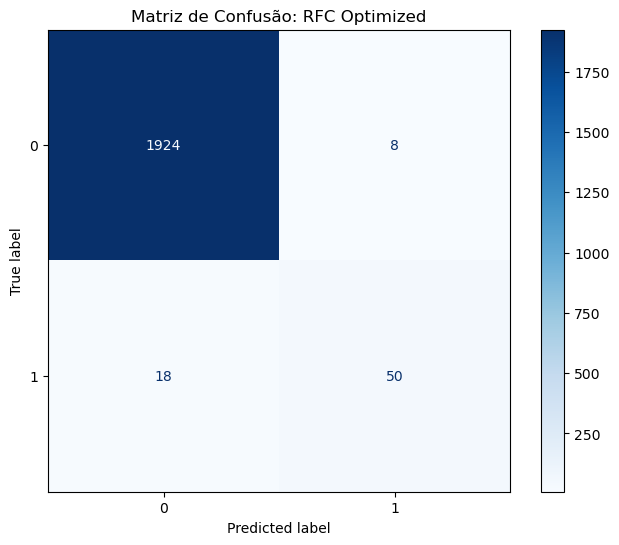

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=pipelines_resultados['RFC_Optimized'][-1])

disp.plot(cmap='Blues', ax=ax)
plt.title(f"Matriz de Confusão: RFC Optimized")
plt.show()

## Results analysis

Our model is now further improved, with 50 correct predictions against 46 from before, and the 26 misslabellign still stands for now

We will also check the relevance of oversamplers against the native function of class weight from RFC, also using optuna

In [38]:
def objective(trial):

    # Hiperparâmetros do RFC — o Optuna sugere os valores
    sampler_name = trial.suggest_categorical(
    'samplers', ['no_sampler','random','smote', 'borderline','svmsmote','balanced_weight'])
    
    sampling_strategy = trial.suggest_float('sampling_strategy', 0.05, 0.33)
    k_neighbors = trial.suggest_int('k_neighbors',2,10)

    samplers = {
        'no_sampler':     'passthrough',
        'balanced_weight': 'passthrough',  # ou trate via class_weight
        'random':         RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42),
        'smote':          SMOTE(sampling_strategy=sampling_strategy, k_neighbors=k_neighbors, random_state=42),
        'borderline':     BorderlineSMOTE(sampling_strategy=sampling_strategy, k_neighbors=k_neighbors, random_state=42),
        'svmsmote':       SVMSMOTE(sampling_strategy=sampling_strategy, k_neighbors=k_neighbors, random_state=42),
    }
   
    sampler = samplers[sampler_name]
    
    use_class_weight = "balanced" if sampler_name == "balanced_weight" else None

    
 
    # Monta o pipeline com os parâmetros sugeridos
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('sampler',sampler),
        ('classifier', RandomForestClassifier(
            **params,
            random_state=42,
            class_weight = use_class_weight
        ))
    ])

    # Cross-validation estratificado — mantém proporção das classes
    cv = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipe, x_train, y_train,
        cv=cv,
        scoring='matthews_corrcoef',
        n_jobs=-1
    )

    return scores.mean()

# ============================================================
# BLOCO 3 — Execução do estudo
# O pruner cancela tentativas ruins antes de terminar,
# economizando tempo computacional
# ============================================================

In [39]:
sampler_optuna  = optuna.samplers.TPESampler(seed=42)   # Bayesiano
pruner_optuna   = optuna.pruners.MedianPruner()         # Poda tentativas ruins

study = optuna.create_study(
    direction='maximize',           # Queremos maximizar o F1
    sampler=sampler_optuna,
    pruner=pruner_optuna
)

# n_trials = número de combinações testadas
# 100 tentativas já costuma convergir bem para XGBoost
study.optimize(objective, n_trials=500, show_progress_bar=True, n_jobs = -1)

[I 2026-03-09 11:10:58,868] A new study created in memory with name: no-name-022440a8-67cf-4eed-8477-68655756336d
Best trial: 4. Best value: 0.849577:   0%|          | 1/500 [00:03<26:50,  3.23s/it]

[I 2026-03-09 11:11:02,094] Trial 4 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.05295552592172056, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   0%|          | 2/500 [00:12<55:43,  6.71s/it]

[I 2026-03-09 11:11:11,245] Trial 7 finished with value: 0.8169673258469796 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.17151896285007898, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   1%|          | 3/500 [00:13<32:37,  3.94s/it]

[I 2026-03-09 11:11:11,882] Trial 0 finished with value: 0.8125713302090386 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.22089325069834126, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   1%|          | 4/500 [00:15<27:52,  3.37s/it]

[I 2026-03-09 11:11:14,380] Trial 1 finished with value: 0.8487971499884257 and parameters: {'samplers': 'random', 'sampling_strategy': 0.10620742605385469, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   1%|          | 5/500 [00:15<18:31,  2.24s/it]

[I 2026-03-09 11:11:14,627] Trial 2 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3040352491067684, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   1%|▏         | 7/500 [00:17<10:42,  1.30s/it]

[I 2026-03-09 11:11:15,747] Trial 5 finished with value: 0.8293715229431837 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.06768920537904322, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.
[I 2026-03-09 11:11:15,900] Trial 3 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.05719775766449118, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   2%|▏         | 8/500 [00:18<10:50,  1.32s/it]

[I 2026-03-09 11:11:17,257] Trial 6 finished with value: 0.8271130349928151 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.27678614721539024, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   2%|▏         | 9/500 [00:19<09:43,  1.19s/it]

[I 2026-03-09 11:11:18,165] Trial 8 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.2828083355584462, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   2%|▏         | 10/500 [00:22<14:01,  1.72s/it]

[I 2026-03-09 11:11:21,062] Trial 9 finished with value: 0.816779009615119 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.20946591160683764, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   2%|▏         | 11/500 [00:24<14:32,  1.78s/it]

[I 2026-03-09 11:11:22,996] Trial 10 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1941283327414553, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   2%|▏         | 12/500 [00:26<14:50,  1.83s/it]

[I 2026-03-09 11:11:24,917] Trial 11 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.15500454162287003, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   3%|▎         | 13/500 [00:27<14:56,  1.84s/it]

[I 2026-03-09 11:11:26,797] Trial 12 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.31765471991878763, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   3%|▎         | 14/500 [00:31<18:04,  2.23s/it]

[I 2026-03-09 11:11:29,934] Trial 13 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.09546701963083572, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   3%|▎         | 15/500 [00:33<17:27,  2.16s/it]

[I 2026-03-09 11:11:31,928] Trial 14 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.30612957707072935, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   3%|▎         | 16/500 [00:35<19:11,  2.38s/it]

[I 2026-03-09 11:11:34,812] Trial 15 finished with value: 0.8204092846407621 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.31356618487013116, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   3%|▎         | 17/500 [00:38<19:00,  2.36s/it]

[I 2026-03-09 11:11:37,132] Trial 16 finished with value: 0.8372511264449478 and parameters: {'samplers': 'random', 'sampling_strategy': 0.23297607293056805, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   4%|▎         | 18/500 [00:40<17:57,  2.24s/it]

[I 2026-03-09 11:11:39,077] Trial 17 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.31727340878870725, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   4%|▍         | 19/500 [00:42<17:10,  2.14s/it]

[I 2026-03-09 11:11:41,002] Trial 18 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.31790275890083713, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   4%|▍         | 20/500 [00:44<16:38,  2.08s/it]

[I 2026-03-09 11:11:42,937] Trial 19 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3169639075864944, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   4%|▍         | 21/500 [00:46<18:38,  2.34s/it]

[I 2026-03-09 11:11:45,853] Trial 20 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.11885824550896744, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   4%|▍         | 22/500 [00:48<17:47,  2.23s/it]

[I 2026-03-09 11:11:47,865] Trial 21 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2557766291825924, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   5%|▍         | 23/500 [00:50<17:01,  2.14s/it]

[I 2026-03-09 11:11:49,789] Trial 22 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.24102193127472193, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   5%|▍         | 24/500 [00:52<16:32,  2.09s/it]

[I 2026-03-09 11:11:51,745] Trial 23 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.25574053709094074, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   5%|▌         | 25/500 [00:54<16:06,  2.03s/it]

[I 2026-03-09 11:11:53,657] Trial 24 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.12482171488007923, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   5%|▌         | 26/500 [00:56<15:45,  2.00s/it]

[I 2026-03-09 11:11:55,566] Trial 25 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.14232366179081476, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   5%|▌         | 27/500 [00:58<15:41,  1.99s/it]

[I 2026-03-09 11:11:57,541] Trial 26 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1420253597614668, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   6%|▌         | 28/500 [01:02<20:13,  2.57s/it]

[I 2026-03-09 11:12:01,463] Trial 27 finished with value: 0.8134406240801728 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.1326902274753666, 'k_neighbors': 6}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   6%|▌         | 29/500 [01:04<19:34,  2.49s/it]

[I 2026-03-09 11:12:03,787] Trial 28 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.24685540914669452, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   6%|▌         | 30/500 [01:06<18:16,  2.33s/it]

[I 2026-03-09 11:12:05,741] Trial 29 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.15169459942097416, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   6%|▌         | 31/500 [01:09<19:56,  2.55s/it]

[I 2026-03-09 11:12:08,787] Trial 30 finished with value: 0.8349442460671624 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.1409267169937856, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   6%|▋         | 32/500 [01:13<22:35,  2.90s/it]

[I 2026-03-09 11:12:12,505] Trial 31 finished with value: 0.8325691555831084 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.1571952901091121, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   7%|▋         | 33/500 [01:17<23:42,  3.05s/it]

[I 2026-03-09 11:12:15,886] Trial 32 finished with value: 0.828050137964295 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.1873004483333175, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   7%|▋         | 34/500 [01:20<24:46,  3.19s/it]

[I 2026-03-09 11:12:19,421] Trial 33 finished with value: 0.8245335899543504 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.19358936774420063, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   7%|▋         | 35/500 [01:24<25:28,  3.29s/it]

[I 2026-03-09 11:12:22,931] Trial 34 finished with value: 0.828050137964295 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.18726883284875762, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   7%|▋         | 36/500 [01:26<22:54,  2.96s/it]

[I 2026-03-09 11:12:25,141] Trial 35 finished with value: 0.8354117285262872 and parameters: {'samplers': 'random', 'sampling_strategy': 0.19813524947012237, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   7%|▋         | 37/500 [01:28<21:18,  2.76s/it]

[I 2026-03-09 11:12:27,420] Trial 36 finished with value: 0.8358758540335928 and parameters: {'samplers': 'random', 'sampling_strategy': 0.1975888773307189, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   8%|▊         | 38/500 [01:31<22:05,  2.87s/it]

[I 2026-03-09 11:12:30,557] Trial 37 finished with value: 0.8105744859933357 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.20123361693922975, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   8%|▊         | 39/500 [01:34<21:45,  2.83s/it]

[I 2026-03-09 11:12:33,298] Trial 38 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1810615127521955, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   8%|▊         | 40/500 [01:37<21:06,  2.75s/it]

[I 2026-03-09 11:12:35,867] Trial 39 finished with value: 0.8408358175760972 and parameters: {'samplers': 'random', 'sampling_strategy': 0.18924125153968724, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   8%|▊         | 41/500 [01:38<19:05,  2.49s/it]

[I 2026-03-09 11:12:37,762] Trial 40 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.21049431991851436, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   8%|▊         | 42/500 [01:40<18:08,  2.38s/it]

[I 2026-03-09 11:12:39,859] Trial 41 finished with value: 0.8444137836172252 and parameters: {'samplers': 'random', 'sampling_strategy': 0.08728022196910254, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   9%|▊         | 43/500 [01:43<17:26,  2.29s/it]

[I 2026-03-09 11:12:41,952] Trial 42 finished with value: 0.8432894543437787 and parameters: {'samplers': 'random', 'sampling_strategy': 0.08417823324502267, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   9%|▉         | 44/500 [01:45<17:09,  2.26s/it]

[I 2026-03-09 11:12:44,133] Trial 43 finished with value: 0.8311829227606505 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.07422066800645352, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   9%|▉         | 45/500 [01:47<16:58,  2.24s/it]

[I 2026-03-09 11:12:46,329] Trial 44 finished with value: 0.8378099894954516 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.08076168707891573, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   9%|▉         | 46/500 [01:50<18:10,  2.40s/it]

[I 2026-03-09 11:12:49,104] Trial 45 finished with value: 0.8365660135936348 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.07996644234805117, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:   9%|▉         | 47/500 [01:52<18:51,  2.50s/it]

[I 2026-03-09 11:12:51,836] Trial 46 finished with value: 0.8364196084357995 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.07251011145250284, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  10%|▉         | 48/500 [01:55<17:57,  2.38s/it]

[I 2026-03-09 11:12:53,954] Trial 47 finished with value: 0.8415572199352019 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.08093851574477653, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  10%|▉         | 49/500 [01:57<17:36,  2.34s/it]

[I 2026-03-09 11:12:56,197] Trial 48 finished with value: 0.8404704210437655 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.07401592059567431, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  10%|█         | 50/500 [02:00<19:26,  2.59s/it]

[I 2026-03-09 11:12:59,369] Trial 49 finished with value: 0.7883791431256427 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.28762436765594984, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  10%|█         | 51/500 [02:03<20:48,  2.78s/it]

[I 2026-03-09 11:13:02,588] Trial 50 finished with value: 0.7998588565426987 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.2905586973620859, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  10%|█         | 52/500 [02:06<21:20,  2.86s/it]

[I 2026-03-09 11:13:05,619] Trial 51 finished with value: 0.8285754182311528 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.052147005911560074, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  11%|█         | 53/500 [02:10<22:44,  3.05s/it]

[I 2026-03-09 11:13:09,137] Trial 52 finished with value: 0.7898074191792173 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.2920990689252469, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  11%|█         | 54/500 [02:12<20:43,  2.79s/it]

[I 2026-03-09 11:13:11,308] Trial 53 finished with value: 0.841525203172911 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.057046323004893186, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  11%|█         | 55/500 [02:14<19:15,  2.60s/it]

[I 2026-03-09 11:13:13,455] Trial 54 finished with value: 0.821545420488823 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.05255513134676865, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  11%|█         | 56/500 [02:16<18:06,  2.45s/it]

[I 2026-03-09 11:13:15,558] Trial 55 finished with value: 0.8265020835096575 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.05327141911583452, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  11%|█▏        | 57/500 [02:18<16:59,  2.30s/it]

[I 2026-03-09 11:13:17,521] Trial 56 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.052901279814328905, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  12%|█▏        | 58/500 [02:20<16:09,  2.19s/it]

[I 2026-03-09 11:13:19,461] Trial 57 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.055066369542200955, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  12%|█▏        | 59/500 [02:23<17:39,  2.40s/it]

[I 2026-03-09 11:13:22,349] Trial 58 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3288734071616079, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  12%|█▏        | 60/500 [02:25<16:54,  2.31s/it]

[I 2026-03-09 11:13:24,431] Trial 59 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.30275573053889027, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  12%|█▏        | 61/500 [02:27<16:06,  2.20s/it]

[I 2026-03-09 11:13:26,386] Trial 60 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32826225856024227, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  12%|█▏        | 62/500 [02:29<15:19,  2.10s/it]

[I 2026-03-09 11:13:28,246] Trial 61 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32484778843653783, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  13%|█▎        | 63/500 [02:31<14:49,  2.04s/it]

[I 2026-03-09 11:13:30,134] Trial 62 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32666951489486695, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  13%|█▎        | 64/500 [02:33<14:33,  2.00s/it]

[I 2026-03-09 11:13:32,065] Trial 63 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2708688330389003, 'k_neighbors': 6}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  13%|█▎        | 65/500 [02:35<14:24,  1.99s/it]

[I 2026-03-09 11:13:34,016] Trial 64 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3282812052886857, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  13%|█▎        | 66/500 [02:37<14:32,  2.01s/it]

[I 2026-03-09 11:13:36,073] Trial 65 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32664620891130025, 'k_neighbors': 6}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  13%|█▎        | 67/500 [02:40<16:32,  2.29s/it]

[I 2026-03-09 11:13:39,036] Trial 66 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.27300350848344246, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  14%|█▎        | 68/500 [02:41<14:51,  2.06s/it]

[I 2026-03-09 11:13:40,562] Trial 67 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.27291827549247016, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  14%|█▍        | 69/500 [02:44<15:51,  2.21s/it]

[I 2026-03-09 11:13:43,103] Trial 68 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.26530157453232506, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  14%|█▍        | 70/500 [02:47<17:37,  2.46s/it]

[I 2026-03-09 11:13:46,152] Trial 69 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2668348895399881, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  14%|█▍        | 71/500 [02:49<17:53,  2.50s/it]

[I 2026-03-09 11:13:48,757] Trial 70 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2645948596975773, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  14%|█▍        | 72/500 [02:52<17:35,  2.47s/it]

[I 2026-03-09 11:13:51,126] Trial 71 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.30987339598429703, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  15%|█▍        | 73/500 [02:55<19:55,  2.80s/it]

[I 2026-03-09 11:13:54,705] Trial 72 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.10834487239335105, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  15%|█▍        | 74/500 [02:57<18:15,  2.57s/it]

[I 2026-03-09 11:13:56,753] Trial 73 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.31155978036588644, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  15%|█▌        | 75/500 [02:59<16:52,  2.38s/it]

[I 2026-03-09 11:13:58,694] Trial 74 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.308194561609119, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  15%|█▌        | 76/500 [03:01<16:16,  2.30s/it]

[I 2026-03-09 11:14:00,809] Trial 75 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.30834104518087596, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  15%|█▌        | 77/500 [03:03<15:30,  2.20s/it]

[I 2026-03-09 11:14:02,767] Trial 76 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3104177673064087, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  16%|█▌        | 78/500 [03:05<15:09,  2.16s/it]

[I 2026-03-09 11:14:04,824] Trial 77 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.31011842824891367, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  16%|█▌        | 79/500 [03:08<15:12,  2.17s/it]

[I 2026-03-09 11:14:07,017] Trial 78 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.11911332775356501, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  16%|█▌        | 80/500 [03:11<16:36,  2.37s/it]

[I 2026-03-09 11:14:09,866] Trial 79 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.11553776470714766, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  16%|█▌        | 81/500 [03:13<16:16,  2.33s/it]

[I 2026-03-09 11:14:12,101] Trial 80 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1117251606010347, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  16%|█▋        | 82/500 [03:15<15:27,  2.22s/it]

[I 2026-03-09 11:14:14,059] Trial 81 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1169879600152729, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  17%|█▋        | 83/500 [03:17<14:56,  2.15s/it]

[I 2026-03-09 11:14:16,049] Trial 82 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.10765765318415496, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  17%|█▋        | 84/500 [03:19<14:29,  2.09s/it]

[I 2026-03-09 11:14:18,001] Trial 83 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.16527986725991234, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  17%|█▋        | 85/500 [03:21<14:11,  2.05s/it]

[I 2026-03-09 11:14:19,962] Trial 84 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.16560655497169813, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  17%|█▋        | 86/500 [03:23<14:05,  2.04s/it]

[I 2026-03-09 11:14:21,976] Trial 85 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.16270105846397126, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  17%|█▋        | 87/500 [03:25<14:14,  2.07s/it]

[I 2026-03-09 11:14:24,111] Trial 86 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1572470736618009, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  18%|█▊        | 88/500 [03:28<16:03,  2.34s/it]

[I 2026-03-09 11:14:27,082] Trial 87 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.16522975792552957, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  18%|█▊        | 89/500 [03:30<15:07,  2.21s/it]

[I 2026-03-09 11:14:28,988] Trial 88 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.16795187011964588, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  18%|█▊        | 90/500 [03:32<14:30,  2.12s/it]

[I 2026-03-09 11:14:30,909] Trial 89 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1610288213284081, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  18%|█▊        | 91/500 [03:33<14:03,  2.06s/it]

[I 2026-03-09 11:14:32,831] Trial 90 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.16303264124973596, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  18%|█▊        | 92/500 [03:35<13:49,  2.03s/it]

[I 2026-03-09 11:14:34,798] Trial 91 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2173900797085167, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  19%|█▊        | 93/500 [03:37<13:37,  2.01s/it]

[I 2026-03-09 11:14:36,746] Trial 92 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2985005134438328, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  19%|█▉        | 94/500 [03:39<13:23,  1.98s/it]

[I 2026-03-09 11:14:38,654] Trial 93 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.22927070601842528, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  19%|█▉        | 95/500 [03:42<14:32,  2.15s/it]

[I 2026-03-09 11:14:41,216] Trial 94 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2999314196729974, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  19%|█▉        | 96/500 [03:44<15:15,  2.27s/it]

[I 2026-03-09 11:14:43,747] Trial 95 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2988765342484546, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  19%|█▉        | 97/500 [03:47<16:47,  2.50s/it]

[I 2026-03-09 11:14:46,791] Trial 96 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.22232898185744196, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  20%|█▉        | 98/500 [03:50<16:38,  2.48s/it]

[I 2026-03-09 11:14:49,236] Trial 97 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2232368054457493, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  20%|█▉        | 99/500 [03:52<15:12,  2.28s/it]

[I 2026-03-09 11:14:51,029] Trial 98 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.22976826061027442, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  20%|██        | 100/500 [03:54<14:36,  2.19s/it]

[I 2026-03-09 11:14:53,025] Trial 99 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.23345949102420183, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  20%|██        | 101/500 [03:56<14:05,  2.12s/it]

[I 2026-03-09 11:14:54,975] Trial 100 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.31740707623915804, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  20%|██        | 102/500 [03:59<16:43,  2.52s/it]

[I 2026-03-09 11:14:58,426] Trial 101 finished with value: 0.8430255533107562 and parameters: {'samplers': 'random', 'sampling_strategy': 0.3181803298116401, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  21%|██        | 103/500 [04:01<16:11,  2.45s/it]

[I 2026-03-09 11:15:00,702] Trial 102 finished with value: 0.8413225441837665 and parameters: {'samplers': 'random', 'sampling_strategy': 0.09665768980223086, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  21%|██        | 104/500 [04:04<16:00,  2.42s/it]

[I 2026-03-09 11:15:03,080] Trial 103 finished with value: 0.8377316954200179 and parameters: {'samplers': 'random', 'sampling_strategy': 0.3178494362892306, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  21%|██        | 105/500 [04:06<15:53,  2.41s/it]

[I 2026-03-09 11:15:05,467] Trial 104 finished with value: 0.8339534856009664 and parameters: {'samplers': 'random', 'sampling_strategy': 0.31830343783913745, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  21%|██        | 106/500 [04:08<15:44,  2.40s/it]

[I 2026-03-09 11:15:07,830] Trial 105 finished with value: 0.8384742084354059 and parameters: {'samplers': 'random', 'sampling_strategy': 0.2443344450190606, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  21%|██▏       | 107/500 [04:12<17:36,  2.69s/it]

[I 2026-03-09 11:15:11,197] Trial 106 finished with value: 0.8201600919274296 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.24352045958458957, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  22%|██▏       | 108/500 [04:16<19:44,  3.02s/it]

[I 2026-03-09 11:15:14,993] Trial 107 finished with value: 0.8477918092961938 and parameters: {'samplers': 'random', 'sampling_strategy': 0.09817896296008448, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  22%|██▏       | 109/500 [04:18<17:28,  2.68s/it]

[I 2026-03-09 11:15:16,881] Trial 108 finished with value: 0.8461001632750728 and parameters: {'samplers': 'random', 'sampling_strategy': 0.249339726646989, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  22%|██▏       | 110/500 [04:21<18:37,  2.87s/it]

[I 2026-03-09 11:15:20,179] Trial 109 finished with value: 0.8262908657661954 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.25553157560506307, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  22%|██▏       | 111/500 [04:24<19:25,  3.00s/it]

[I 2026-03-09 11:15:23,481] Trial 110 finished with value: 0.835420893448854 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.25113392142184493, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  22%|██▏       | 112/500 [04:27<19:54,  3.08s/it]

[I 2026-03-09 11:15:26,752] Trial 111 finished with value: 0.829468563902817 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.24780427716674305, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  23%|██▎       | 113/500 [04:32<22:30,  3.49s/it]

[I 2026-03-09 11:15:31,201] Trial 112 finished with value: 0.8215108347568868 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.25516282738966856, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  23%|██▎       | 114/500 [04:35<22:29,  3.50s/it]

[I 2026-03-09 11:15:34,709] Trial 113 finished with value: 0.8287193768923846 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.28159545369496786, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  23%|██▎       | 115/500 [04:38<20:36,  3.21s/it]

[I 2026-03-09 11:15:37,253] Trial 114 finished with value: 0.8203632123999935 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.17891203005578954, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  23%|██▎       | 116/500 [04:40<19:15,  3.01s/it]

[I 2026-03-09 11:15:39,790] Trial 115 finished with value: 0.8333402864854159 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.18130100010588862, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  23%|██▎       | 117/500 [04:43<18:56,  2.97s/it]

[I 2026-03-09 11:15:42,667] Trial 116 finished with value: 0.8288719665309445 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.2811926671518485, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  24%|██▎       | 118/500 [04:45<17:12,  2.70s/it]

[I 2026-03-09 11:15:44,746] Trial 117 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.179698811093906, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  24%|██▍       | 119/500 [04:48<17:55,  2.82s/it]

[I 2026-03-09 11:15:47,847] Trial 118 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.13353869516609201, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  24%|██▍       | 120/500 [04:50<16:00,  2.53s/it]

[I 2026-03-09 11:15:49,690] Trial 119 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.12615902668055157, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  24%|██▍       | 121/500 [04:52<14:46,  2.34s/it]

[I 2026-03-09 11:15:51,587] Trial 120 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.12958936609366303, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  24%|██▍       | 122/500 [04:54<13:59,  2.22s/it]

[I 2026-03-09 11:15:53,529] Trial 121 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.13918787605779753, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  25%|██▍       | 123/500 [04:56<13:24,  2.13s/it]

[I 2026-03-09 11:15:55,463] Trial 122 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.12939346477618302, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  25%|██▍       | 124/500 [04:58<13:06,  2.09s/it]

[I 2026-03-09 11:15:57,459] Trial 123 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.13167186044285203, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  25%|██▌       | 125/500 [05:00<12:45,  2.04s/it]

[I 2026-03-09 11:15:59,373] Trial 124 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.14761610262848485, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  25%|██▌       | 126/500 [05:03<14:50,  2.38s/it]

[I 2026-03-09 11:16:02,553] Trial 125 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.12852612707642905, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  25%|██▌       | 127/500 [05:05<14:17,  2.30s/it]

[I 2026-03-09 11:16:04,664] Trial 126 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.14740284571977166, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  26%|██▌       | 128/500 [05:07<13:28,  2.17s/it]

[I 2026-03-09 11:16:06,539] Trial 127 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.13573299014070034, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  26%|██▌       | 129/500 [05:09<13:03,  2.11s/it]

[I 2026-03-09 11:16:08,505] Trial 128 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1504975187797027, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  26%|██▌       | 130/500 [05:11<12:34,  2.04s/it]

[I 2026-03-09 11:16:10,381] Trial 129 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.14620712366381103, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  26%|██▌       | 131/500 [05:13<12:18,  2.00s/it]

[I 2026-03-09 11:16:12,295] Trial 130 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.14890749348260102, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  26%|██▋       | 132/500 [05:15<12:07,  1.98s/it]

[I 2026-03-09 11:16:14,213] Trial 131 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1409388960827616, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  27%|██▋       | 133/500 [05:17<11:59,  1.96s/it]

[I 2026-03-09 11:16:16,124] Trial 132 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.06565166714807616, 'k_neighbors': 6}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  27%|██▋       | 134/500 [05:20<14:11,  2.33s/it]

[I 2026-03-09 11:16:19,314] Trial 133 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.15064295629219895, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  27%|██▋       | 135/500 [05:22<13:06,  2.16s/it]

[I 2026-03-09 11:16:21,070] Trial 134 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.06811951241665669, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  27%|██▋       | 136/500 [05:24<12:43,  2.10s/it]

[I 2026-03-09 11:16:23,031] Trial 135 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2022769176600253, 'k_neighbors': 6}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  27%|██▋       | 137/500 [05:26<12:32,  2.07s/it]

[I 2026-03-09 11:16:25,048] Trial 136 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.20526957007860336, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  28%|██▊       | 138/500 [05:28<12:16,  2.03s/it]

[I 2026-03-09 11:16:26,994] Trial 137 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.20045547405711422, 'k_neighbors': 6}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  28%|██▊       | 139/500 [05:30<12:06,  2.01s/it]

[I 2026-03-09 11:16:28,952] Trial 138 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2088331899087707, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  28%|██▊       | 140/500 [05:32<11:54,  1.98s/it]

[I 2026-03-09 11:16:30,865] Trial 139 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2130323454296424, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  28%|██▊       | 141/500 [05:34<12:38,  2.11s/it]

[I 2026-03-09 11:16:33,282] Trial 140 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.28776103319060464, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  28%|██▊       | 142/500 [05:37<14:30,  2.43s/it]

[I 2026-03-09 11:16:36,455] Trial 141 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.20387217161288812, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  29%|██▊       | 143/500 [05:39<14:01,  2.36s/it]

[I 2026-03-09 11:16:38,639] Trial 142 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.28769354525913604, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  29%|██▉       | 144/500 [05:41<13:28,  2.27s/it]

[I 2026-03-09 11:16:40,703] Trial 143 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.28852191196172217, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  29%|██▉       | 145/500 [05:43<13:10,  2.23s/it]

[I 2026-03-09 11:16:42,835] Trial 144 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.12149877754732742, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  29%|██▉       | 146/500 [05:46<12:55,  2.19s/it]

[I 2026-03-09 11:16:44,937] Trial 145 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.12175290082102605, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  29%|██▉       | 147/500 [05:48<12:41,  2.16s/it]

[I 2026-03-09 11:16:47,008] Trial 146 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3227919666868773, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  30%|██▉       | 148/500 [05:52<16:30,  2.81s/it]

[I 2026-03-09 11:16:51,353] Trial 147 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.23713686764651992, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  30%|██▉       | 149/500 [05:54<14:25,  2.47s/it]

[I 2026-03-09 11:16:53,014] Trial 148 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.23623394259250152, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  30%|███       | 150/500 [05:56<13:30,  2.32s/it]

[I 2026-03-09 11:16:54,981] Trial 149 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.26083550239307257, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  30%|███       | 151/500 [05:58<12:51,  2.21s/it]

[I 2026-03-09 11:16:56,951] Trial 150 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.12223816538301545, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  30%|███       | 152/500 [06:00<12:26,  2.15s/it]

[I 2026-03-09 11:16:58,943] Trial 151 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2603773987844565, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  31%|███       | 153/500 [06:02<13:41,  2.37s/it]

[I 2026-03-09 11:17:01,830] Trial 152 finished with value: 0.8009285178398113 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.23807950325118954, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  31%|███       | 154/500 [06:06<15:58,  2.77s/it]

[I 2026-03-09 11:17:05,536] Trial 153 finished with value: 0.7935044441680486 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.26000757802465235, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  31%|███       | 155/500 [06:10<17:32,  3.05s/it]

[I 2026-03-09 11:17:09,250] Trial 154 finished with value: 0.8106498640170001 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.2340142869824307, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  31%|███       | 156/500 [06:12<15:36,  2.72s/it]

[I 2026-03-09 11:17:11,199] Trial 155 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2638958515864792, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  31%|███▏      | 157/500 [06:15<15:34,  2.73s/it]

[I 2026-03-09 11:17:13,934] Trial 156 finished with value: 0.8265874581188916 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.17413175786621823, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  32%|███▏      | 158/500 [06:17<14:12,  2.49s/it]

[I 2026-03-09 11:17:15,885] Trial 157 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.08733184875640476, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  32%|███▏      | 159/500 [06:19<14:34,  2.57s/it]

[I 2026-03-09 11:17:18,620] Trial 158 finished with value: 0.8066427404067917 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.17294050118981952, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  32%|███▏      | 160/500 [06:23<16:13,  2.86s/it]

[I 2026-03-09 11:17:22,164] Trial 159 finished with value: 0.8172864484200479 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.15613402161016632, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  32%|███▏      | 161/500 [06:28<19:23,  3.43s/it]

[I 2026-03-09 11:17:26,927] Trial 160 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.13775625391722418, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  32%|███▏      | 162/500 [06:31<19:24,  3.45s/it]

[I 2026-03-09 11:17:30,405] Trial 161 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.17219929103805076, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  33%|███▎      | 163/500 [06:35<20:10,  3.59s/it]

[I 2026-03-09 11:17:34,326] Trial 162 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1731957537095579, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  33%|███▎      | 164/500 [06:41<23:47,  4.25s/it]

[I 2026-03-09 11:17:40,124] Trial 163 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1725603037687548, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  33%|███▎      | 165/500 [06:45<23:47,  4.26s/it]

[I 2026-03-09 11:17:44,406] Trial 164 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.10284911044264133, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  33%|███▎      | 166/500 [06:49<23:30,  4.22s/it]

[I 2026-03-09 11:17:48,548] Trial 165 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.15817310207358215, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  33%|███▎      | 167/500 [06:53<23:18,  4.20s/it]

[I 2026-03-09 11:17:52,681] Trial 166 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.157661862478054, 'k_neighbors': 6}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  34%|███▎      | 168/500 [06:59<25:57,  4.69s/it]

[I 2026-03-09 11:17:58,525] Trial 167 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.19360165469071317, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  34%|███▍      | 169/500 [07:04<26:11,  4.75s/it]

[I 2026-03-09 11:18:03,398] Trial 168 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.30399829795671385, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  34%|███▍      | 170/500 [07:08<25:01,  4.55s/it]

[I 2026-03-09 11:18:07,491] Trial 169 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.18877219547644847, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  34%|███▍      | 171/500 [07:12<24:05,  4.39s/it]

[I 2026-03-09 11:18:11,524] Trial 170 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1558675895819844, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  34%|███▍      | 172/500 [07:16<22:22,  4.09s/it]

[I 2026-03-09 11:18:14,926] Trial 171 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3035459256342829, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  35%|███▍      | 173/500 [07:20<23:27,  4.30s/it]

[I 2026-03-09 11:18:19,715] Trial 172 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.30498525839690543, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  35%|███▍      | 174/500 [07:25<23:32,  4.33s/it]

[I 2026-03-09 11:18:24,120] Trial 173 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.2751936623623283, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  35%|███▌      | 175/500 [07:30<24:30,  4.52s/it]

[I 2026-03-09 11:18:29,085] Trial 174 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.19333174597766772, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  35%|███▌      | 176/500 [07:32<21:06,  3.91s/it]

[I 2026-03-09 11:18:31,567] Trial 175 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.3041997976253026, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  35%|███▌      | 177/500 [07:37<21:57,  4.08s/it]

[I 2026-03-09 11:18:36,039] Trial 176 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.14221850814712858, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  36%|███▌      | 178/500 [07:41<21:42,  4.04s/it]

[I 2026-03-09 11:18:40,002] Trial 177 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2713583341785987, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  36%|███▌      | 179/500 [07:45<21:56,  4.10s/it]

[I 2026-03-09 11:18:44,233] Trial 178 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.3141931345720687, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  36%|███▌      | 180/500 [07:48<20:48,  3.90s/it]

[I 2026-03-09 11:18:47,669] Trial 179 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32058389846357455, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  36%|███▌      | 181/500 [07:53<21:54,  4.12s/it]

[I 2026-03-09 11:18:52,304] Trial 180 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.3142957272443412, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  36%|███▋      | 182/500 [07:57<21:32,  4.07s/it]

[I 2026-03-09 11:18:56,244] Trial 181 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.19496666990422112, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  37%|███▋      | 183/500 [08:01<21:10,  4.01s/it]

[I 2026-03-09 11:19:00,111] Trial 182 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.29558656075974454, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  37%|███▋      | 184/500 [08:04<20:12,  3.84s/it]

[I 2026-03-09 11:19:03,548] Trial 183 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1430296723783443, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  37%|███▋      | 185/500 [08:08<20:32,  3.91s/it]

[I 2026-03-09 11:19:07,645] Trial 184 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32187645783546565, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  37%|███▋      | 186/500 [08:12<20:46,  3.97s/it]

[I 2026-03-09 11:19:11,731] Trial 185 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.31490889961306556, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  37%|███▋      | 187/500 [08:17<21:44,  4.17s/it]

[I 2026-03-09 11:19:16,382] Trial 186 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.29513954872810816, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  38%|███▊      | 188/500 [08:21<21:39,  4.16s/it]

[I 2026-03-09 11:19:20,511] Trial 187 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2170504958425646, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  38%|███▊      | 189/500 [08:26<22:21,  4.31s/it]

[I 2026-03-09 11:19:25,192] Trial 188 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.056797597578998674, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  38%|███▊      | 190/500 [08:29<20:50,  4.03s/it]

[I 2026-03-09 11:19:28,574] Trial 189 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.05744713449302691, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  38%|███▊      | 191/500 [08:34<21:21,  4.15s/it]

[I 2026-03-09 11:19:32,983] Trial 190 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.06416351464792455, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  38%|███▊      | 192/500 [08:37<19:27,  3.79s/it]

[I 2026-03-09 11:19:35,941] Trial 191 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.0631540835288601, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  39%|███▊      | 193/500 [08:40<19:30,  3.81s/it]

[I 2026-03-09 11:19:39,815] Trial 192 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.21722708899595194, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  39%|███▉      | 194/500 [08:44<19:04,  3.74s/it]

[I 2026-03-09 11:19:43,382] Trial 193 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.05759059505210246, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  39%|███▉      | 195/500 [08:48<19:30,  3.84s/it]

[I 2026-03-09 11:19:47,446] Trial 194 finished with value: 0.8367806639347755 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.06001655284575311, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  39%|███▉      | 196/500 [08:53<20:30,  4.05s/it]

[I 2026-03-09 11:19:51,982] Trial 195 finished with value: 0.8276010570799095 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.06446306804472393, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  39%|███▉      | 197/500 [08:56<19:51,  3.93s/it]

[I 2026-03-09 11:19:55,653] Trial 196 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.06144191105777853, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  40%|███▉      | 198/500 [09:00<19:36,  3.90s/it]

[I 2026-03-09 11:19:59,466] Trial 197 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.05024499268380889, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  40%|███▉      | 199/500 [09:04<19:42,  3.93s/it]

[I 2026-03-09 11:20:03,459] Trial 198 finished with value: 0.8367806639347755 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.059947959152629064, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  40%|████      | 200/500 [09:08<19:39,  3.93s/it]

[I 2026-03-09 11:20:07,404] Trial 199 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.05306451936173256, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  40%|████      | 201/500 [09:13<20:31,  4.12s/it]

[I 2026-03-09 11:20:11,945] Trial 200 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.05173268964093862, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  40%|████      | 202/500 [09:16<19:54,  4.01s/it]

[I 2026-03-09 11:20:15,712] Trial 201 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.050863593149461886, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  41%|████      | 203/500 [09:21<20:34,  4.16s/it]

[I 2026-03-09 11:20:20,207] Trial 202 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2519317908130226, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  41%|████      | 204/500 [09:25<19:55,  4.04s/it]

[I 2026-03-09 11:20:23,975] Trial 203 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.050056222827529695, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  41%|████      | 205/500 [09:29<20:36,  4.19s/it]

[I 2026-03-09 11:20:28,523] Trial 204 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2429586899521214, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  41%|████      | 206/500 [09:33<19:56,  4.07s/it]

[I 2026-03-09 11:20:32,308] Trial 205 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2260178943375045, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  41%|████▏     | 207/500 [09:37<19:47,  4.05s/it]

[I 2026-03-09 11:20:36,304] Trial 206 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1842269210530675, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  42%|████▏     | 208/500 [09:40<18:55,  3.89s/it]

[I 2026-03-09 11:20:39,833] Trial 207 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.07077274692056834, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  42%|████▏     | 209/500 [09:44<18:35,  3.83s/it]

[I 2026-03-09 11:20:43,524] Trial 208 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32974450595749616, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  42%|████▏     | 210/500 [09:48<18:23,  3.80s/it]

[I 2026-03-09 11:20:47,258] Trial 209 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.0718764165022392, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  42%|████▏     | 211/500 [09:51<17:54,  3.72s/it]

[I 2026-03-09 11:20:50,785] Trial 210 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3275382771974774, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  42%|████▏     | 212/500 [09:56<18:34,  3.87s/it]

[I 2026-03-09 11:20:55,007] Trial 211 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.24170166247950142, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  43%|████▎     | 213/500 [09:59<18:07,  3.79s/it]

[I 2026-03-09 11:20:58,605] Trial 212 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32287359099644175, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  43%|████▎     | 214/500 [10:04<18:48,  3.94s/it]

[I 2026-03-09 11:21:02,923] Trial 213 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3230178443302811, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  43%|████▎     | 215/500 [10:08<18:47,  3.95s/it]

[I 2026-03-09 11:21:06,893] Trial 214 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1534467038084004, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  43%|████▎     | 216/500 [10:11<18:31,  3.91s/it]

[I 2026-03-09 11:21:10,710] Trial 215 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32338598009362834, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  43%|████▎     | 217/500 [10:15<18:09,  3.85s/it]

[I 2026-03-09 11:21:14,421] Trial 216 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.326966953992603, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  44%|████▎     | 218/500 [10:19<17:53,  3.81s/it]

[I 2026-03-09 11:21:18,123] Trial 217 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.0909866492063084, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  44%|████▍     | 219/500 [10:22<17:06,  3.65s/it]

[I 2026-03-09 11:21:21,416] Trial 218 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3109830551511553, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  44%|████▍     | 220/500 [10:26<16:54,  3.62s/it]

[I 2026-03-09 11:21:24,965] Trial 219 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3225921319551525, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  44%|████▍     | 221/500 [10:29<16:53,  3.63s/it]

[I 2026-03-09 11:21:28,622] Trial 220 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.25572570170543263, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  44%|████▍     | 222/500 [10:33<16:54,  3.65s/it]

[I 2026-03-09 11:21:32,309] Trial 221 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3074288702045299, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  45%|████▍     | 223/500 [10:37<16:48,  3.64s/it]

[I 2026-03-09 11:21:35,933] Trial 222 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.11358396538953328, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  45%|████▍     | 224/500 [10:40<17:01,  3.70s/it]

[I 2026-03-09 11:21:39,773] Trial 223 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.11082210856609544, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  45%|████▌     | 225/500 [10:45<17:30,  3.82s/it]

[I 2026-03-09 11:21:43,870] Trial 224 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3125010964521668, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  45%|████▌     | 226/500 [10:48<16:58,  3.72s/it]

[I 2026-03-09 11:21:47,351] Trial 225 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.11287182815810272, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  45%|████▌     | 227/500 [10:52<16:44,  3.68s/it]

[I 2026-03-09 11:21:50,937] Trial 226 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.25535156491731653, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  46%|████▌     | 228/500 [10:55<16:14,  3.58s/it]

[I 2026-03-09 11:21:54,295] Trial 227 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.25466773633981593, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  46%|████▌     | 229/500 [10:59<16:19,  3.61s/it]

[I 2026-03-09 11:21:57,980] Trial 228 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1353905602240158, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  46%|████▌     | 230/500 [11:02<16:22,  3.64s/it]

[I 2026-03-09 11:22:01,683] Trial 229 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.07771338308684658, 'k_neighbors': 6}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  46%|████▌     | 231/500 [11:06<16:35,  3.70s/it]

[I 2026-03-09 11:22:05,529] Trial 230 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.31810406025700033, 'k_neighbors': 6}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  46%|████▋     | 232/500 [11:10<16:28,  3.69s/it]

[I 2026-03-09 11:22:09,195] Trial 231 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.31774585880092504, 'k_neighbors': 6}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  47%|████▋     | 233/500 [11:13<16:18,  3.66s/it]

[I 2026-03-09 11:22:12,792] Trial 232 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3167410760439947, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  47%|████▋     | 234/500 [11:17<16:08,  3.64s/it]

[I 2026-03-09 11:22:16,383] Trial 233 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3167986682004124, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  47%|████▋     | 235/500 [11:21<16:05,  3.64s/it]

[I 2026-03-09 11:22:20,033] Trial 234 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3189167540108944, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  47%|████▋     | 236/500 [11:24<16:09,  3.67s/it]

[I 2026-03-09 11:22:23,781] Trial 235 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.318065708815792, 'k_neighbors': 6}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  47%|████▋     | 237/500 [11:31<20:05,  4.58s/it]

[I 2026-03-09 11:22:30,485] Trial 236 finished with value: 0.811128155104701 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.317253098483058, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  48%|████▊     | 238/500 [11:35<18:40,  4.28s/it]

[I 2026-03-09 11:22:34,048] Trial 237 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3181187134281205, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  48%|████▊     | 239/500 [11:38<17:59,  4.14s/it]

[I 2026-03-09 11:22:37,856] Trial 238 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1447461481243657, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  48%|████▊     | 240/500 [11:46<21:39,  5.00s/it]

[I 2026-03-09 11:22:44,863] Trial 239 finished with value: 0.8180178830676872 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.32869325362485885, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  48%|████▊     | 241/500 [11:52<23:43,  5.50s/it]

[I 2026-03-09 11:22:51,520] Trial 240 finished with value: 0.8329525547163515 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.3282725039836433, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  48%|████▊     | 242/500 [11:56<21:02,  4.89s/it]

[I 2026-03-09 11:22:55,013] Trial 241 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3266797376867127, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  49%|████▊     | 243/500 [11:59<19:28,  4.55s/it]

[I 2026-03-09 11:22:58,746] Trial 242 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32794497535440237, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  49%|████▉     | 244/500 [12:06<22:09,  5.19s/it]

[I 2026-03-09 11:23:05,450] Trial 243 finished with value: 0.8211668558430505 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.32670186135425006, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  49%|████▉     | 245/500 [12:10<19:56,  4.69s/it]

[I 2026-03-09 11:23:08,970] Trial 244 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3283224289513523, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  49%|████▉     | 246/500 [12:13<18:39,  4.41s/it]

[I 2026-03-09 11:23:12,713] Trial 245 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3277056446542039, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  49%|████▉     | 247/500 [12:17<18:07,  4.30s/it]

[I 2026-03-09 11:23:16,754] Trial 246 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32878028691417294, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  50%|████▉     | 248/500 [12:21<16:50,  4.01s/it]

[I 2026-03-09 11:23:20,104] Trial 247 finished with value: 0.838658951392557 and parameters: {'samplers': 'random', 'sampling_strategy': 0.21084887041180347, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  50%|████▉     | 249/500 [12:25<16:28,  3.94s/it]

[I 2026-03-09 11:23:23,865] Trial 248 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3287001867167123, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  50%|█████     | 250/500 [12:28<15:56,  3.83s/it]

[I 2026-03-09 11:23:27,431] Trial 249 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.24628345668994564, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  50%|█████     | 251/500 [12:32<16:25,  3.96s/it]

[I 2026-03-09 11:23:31,692] Trial 250 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.21060938996211706, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  50%|█████     | 252/500 [12:37<16:39,  4.03s/it]

[I 2026-03-09 11:23:35,903] Trial 251 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.16687944671052488, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  51%|█████     | 253/500 [12:41<17:36,  4.28s/it]

[I 2026-03-09 11:23:40,758] Trial 252 finished with value: 0.8326332262098011 and parameters: {'samplers': 'random', 'sampling_strategy': 0.20926921436547938, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  51%|█████     | 254/500 [12:45<16:38,  4.06s/it]

[I 2026-03-09 11:23:44,305] Trial 253 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.10347955212839985, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  51%|█████     | 255/500 [12:50<18:08,  4.44s/it]

[I 2026-03-09 11:23:49,646] Trial 254 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.15251964891815303, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  51%|█████     | 256/500 [12:53<16:33,  4.07s/it]

[I 2026-03-09 11:23:52,847] Trial 255 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.30946632223765413, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  51%|█████▏    | 257/500 [12:57<16:01,  3.96s/it]

[I 2026-03-09 11:23:56,543] Trial 256 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.16268326723637475, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  52%|█████▏    | 258/500 [13:01<15:25,  3.82s/it]

[I 2026-03-09 11:24:00,051] Trial 257 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3082029991614721, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  52%|█████▏    | 259/500 [13:04<15:02,  3.75s/it]

[I 2026-03-09 11:24:03,602] Trial 258 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3000636697581239, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  52%|█████▏    | 260/500 [13:09<15:44,  3.93s/it]

[I 2026-03-09 11:24:07,986] Trial 259 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3110662061254644, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  52%|█████▏    | 261/500 [13:12<15:31,  3.90s/it]

[I 2026-03-09 11:24:11,796] Trial 260 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3082767245698098, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  52%|█████▏    | 262/500 [13:17<15:42,  3.96s/it]

[I 2026-03-09 11:24:15,908] Trial 261 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3100368682635395, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  53%|█████▎    | 263/500 [13:20<15:11,  3.85s/it]

[I 2026-03-09 11:24:19,488] Trial 262 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.30999860297549425, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  53%|█████▎    | 264/500 [13:25<15:48,  4.02s/it]

[I 2026-03-09 11:24:23,917] Trial 263 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.13831313532757383, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  53%|█████▎    | 265/500 [13:29<15:52,  4.05s/it]

[I 2026-03-09 11:24:28,040] Trial 264 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2666954325968249, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  53%|█████▎    | 266/500 [13:33<15:54,  4.08s/it]

[I 2026-03-09 11:24:32,179] Trial 265 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.18596648649313788, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  53%|█████▎    | 267/500 [13:37<16:05,  4.15s/it]

[I 2026-03-09 11:24:36,482] Trial 266 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1784173517150947, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  54%|█████▎    | 268/500 [13:41<15:21,  3.97s/it]

[I 2026-03-09 11:24:40,046] Trial 267 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.13839415276206773, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  54%|█████▍    | 269/500 [13:45<15:21,  3.99s/it]

[I 2026-03-09 11:24:44,076] Trial 268 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1884529998879147, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  54%|█████▍    | 270/500 [13:49<15:28,  4.04s/it]

[I 2026-03-09 11:24:48,226] Trial 269 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1278025737674986, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  54%|█████▍    | 271/500 [13:53<15:13,  3.99s/it]

[I 2026-03-09 11:24:52,106] Trial 270 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.12691620006233492, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  54%|█████▍    | 272/500 [13:57<15:24,  4.06s/it]

[I 2026-03-09 11:24:56,318] Trial 271 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.19850533876872534, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  55%|█████▍    | 273/500 [14:01<15:32,  4.11s/it]

[I 2026-03-09 11:25:00,538] Trial 272 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.18580847925214353, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  55%|█████▍    | 274/500 [14:05<15:25,  4.10s/it]

[I 2026-03-09 11:25:04,614] Trial 273 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2793946379877744, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  55%|█████▌    | 275/500 [14:09<15:14,  4.06s/it]

[I 2026-03-09 11:25:08,598] Trial 274 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.12508754704422842, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  55%|█████▌    | 276/500 [14:13<15:22,  4.12s/it]

[I 2026-03-09 11:25:12,837] Trial 275 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32102100641875936, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  55%|█████▌    | 277/500 [14:18<15:21,  4.13s/it]

[I 2026-03-09 11:25:17,012] Trial 276 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.19998447456438717, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  56%|█████▌    | 278/500 [14:22<15:11,  4.11s/it]

[I 2026-03-09 11:25:21,049] Trial 277 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.14912430974353755, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  56%|█████▌    | 279/500 [14:26<14:56,  4.06s/it]

[I 2026-03-09 11:25:24,990] Trial 278 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.14977652703558314, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  56%|█████▌    | 280/500 [14:30<14:43,  4.02s/it]

[I 2026-03-09 11:25:28,918] Trial 279 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.14845659215350243, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  56%|█████▌    | 281/500 [14:34<14:46,  4.05s/it]

[I 2026-03-09 11:25:33,046] Trial 280 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2807529152948839, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  56%|█████▋    | 282/500 [14:39<16:08,  4.44s/it]

[I 2026-03-09 11:25:38,412] Trial 281 finished with value: 0.8198334329512276 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.23108773368930746, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  57%|█████▋    | 283/500 [14:44<16:54,  4.68s/it]

[I 2026-03-09 11:25:43,615] Trial 282 finished with value: 0.8274439686950502 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.1427263675015958, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  57%|█████▋    | 284/500 [14:50<17:34,  4.88s/it]

[I 2026-03-09 11:25:48,994] Trial 283 finished with value: 0.8231706232322353 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.1441475685379913, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  57%|█████▋    | 285/500 [14:54<16:43,  4.67s/it]

[I 2026-03-09 11:25:53,151] Trial 284 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.24017479840524264, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  57%|█████▋    | 286/500 [14:59<17:44,  4.98s/it]

[I 2026-03-09 11:25:58,855] Trial 285 finished with value: 0.8183343620480232 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.2289864198970068, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  57%|█████▋    | 287/500 [15:04<16:47,  4.73s/it]

[I 2026-03-09 11:26:03,011] Trial 286 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.229530609255426, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  58%|█████▊    | 288/500 [15:10<18:03,  5.11s/it]

[I 2026-03-09 11:26:09,001] Trial 287 finished with value: 0.8221968777240307 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.23156769235723776, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  58%|█████▊    | 289/500 [15:15<18:27,  5.25s/it]

[I 2026-03-09 11:26:14,581] Trial 288 finished with value: 0.8367952765191344 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.24800426445840346, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  58%|█████▊    | 290/500 [15:19<16:31,  4.72s/it]

[I 2026-03-09 11:26:18,064] Trial 289 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3209492306227468, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  58%|█████▊    | 291/500 [15:23<15:34,  4.47s/it]

[I 2026-03-09 11:26:21,952] Trial 290 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3220901772331834, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  58%|█████▊    | 292/500 [15:26<14:24,  4.16s/it]

[I 2026-03-09 11:26:25,388] Trial 291 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2935964084542149, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  59%|█████▊    | 293/500 [15:30<14:03,  4.07s/it]

[I 2026-03-09 11:26:29,252] Trial 292 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.25051665879077384, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  59%|█████▉    | 294/500 [15:33<13:18,  3.87s/it]

[I 2026-03-09 11:26:32,674] Trial 293 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2503730115275403, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  59%|█████▉    | 295/500 [15:37<13:13,  3.87s/it]

[I 2026-03-09 11:26:36,531] Trial 294 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32300732778886093, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  59%|█████▉    | 296/500 [15:41<13:19,  3.92s/it]

[I 2026-03-09 11:26:40,561] Trial 295 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2510529958507153, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  59%|█████▉    | 297/500 [15:45<13:29,  3.99s/it]

[I 2026-03-09 11:26:44,704] Trial 296 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3216471564717154, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  60%|█████▉    | 298/500 [15:49<13:26,  3.99s/it]

[I 2026-03-09 11:26:48,708] Trial 297 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.30093468656367384, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  60%|█████▉    | 299/500 [15:53<13:17,  3.97s/it]

[I 2026-03-09 11:26:52,617] Trial 298 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.22147643946291123, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  60%|██████    | 300/500 [15:59<14:52,  4.46s/it]

[I 2026-03-09 11:26:58,239] Trial 299 finished with value: 0.8132253288431325 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.2996201899158357, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  60%|██████    | 301/500 [16:04<15:28,  4.66s/it]

[I 2026-03-09 11:27:03,369] Trial 300 finished with value: 0.8206268479322569 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.13320542075936412, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  60%|██████    | 302/500 [16:08<14:44,  4.47s/it]

[I 2026-03-09 11:27:07,389] Trial 301 finished with value: 0.8398132869441448 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.055890176917060524, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  61%|██████    | 303/500 [16:12<14:11,  4.32s/it]

[I 2026-03-09 11:27:11,368] Trial 302 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.22091797497683507, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  61%|██████    | 304/500 [16:17<14:46,  4.52s/it]

[I 2026-03-09 11:27:16,364] Trial 303 finished with value: 0.8215961638600521 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.13237531971580432, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  61%|██████    | 305/500 [16:22<14:52,  4.57s/it]

[I 2026-03-09 11:27:21,047] Trial 304 finished with value: 0.8303061464998457 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.11764057616498651, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  61%|██████    | 306/500 [16:26<14:28,  4.48s/it]

[I 2026-03-09 11:27:25,312] Trial 305 finished with value: 0.8403415569853396 and parameters: {'samplers': 'random', 'sampling_strategy': 0.16164191437037592, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  61%|██████▏   | 307/500 [16:31<15:02,  4.68s/it]

[I 2026-03-09 11:27:30,452] Trial 306 finished with value: 0.8071654587239198 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.13461474912264387, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  62%|██████▏   | 308/500 [16:35<14:33,  4.55s/it]

[I 2026-03-09 11:27:34,698] Trial 307 finished with value: 0.837711711348418 and parameters: {'samplers': 'random', 'sampling_strategy': 0.26069093196006154, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  62%|██████▏   | 309/500 [16:40<14:06,  4.43s/it]

[I 2026-03-09 11:27:38,861] Trial 308 finished with value: 0.8330855082007274 and parameters: {'samplers': 'random', 'sampling_strategy': 0.15947485366692704, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  62%|██████▏   | 310/500 [16:43<13:24,  4.24s/it]

[I 2026-03-09 11:27:42,640] Trial 309 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.26087624562459066, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  62%|██████▏   | 311/500 [16:47<13:04,  4.15s/it]

[I 2026-03-09 11:27:46,600] Trial 310 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2595143133100419, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  62%|██████▏   | 312/500 [16:52<13:18,  4.25s/it]

[I 2026-03-09 11:27:51,068] Trial 311 finished with value: 0.841000872461646 and parameters: {'samplers': 'random', 'sampling_strategy': 0.11907134085982773, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  63%|██████▎   | 313/500 [16:55<12:45,  4.10s/it]

[I 2026-03-09 11:27:54,795] Trial 312 finished with value: 0.836305971377475 and parameters: {'samplers': 'random', 'sampling_strategy': 0.1688433588555059, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  63%|██████▎   | 314/500 [16:59<12:19,  3.97s/it]

[I 2026-03-09 11:27:58,488] Trial 313 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2594892850115589, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  63%|██████▎   | 315/500 [17:03<12:00,  3.90s/it]

[I 2026-03-09 11:28:02,209] Trial 314 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3141604185225061, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  63%|██████▎   | 316/500 [17:07<11:47,  3.85s/it]

[I 2026-03-09 11:28:05,946] Trial 315 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.316518917984102, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  63%|██████▎   | 317/500 [17:10<11:40,  3.83s/it]

[I 2026-03-09 11:28:09,736] Trial 316 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.178557168978521, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  64%|██████▎   | 318/500 [17:14<11:29,  3.79s/it]

[I 2026-03-09 11:28:13,413] Trial 317 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1805529725142761, 'k_neighbors': 6}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  64%|██████▍   | 319/500 [17:18<11:21,  3.77s/it]

[I 2026-03-09 11:28:17,128] Trial 318 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1931435609802252, 'k_neighbors': 6}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  64%|██████▍   | 320/500 [17:22<11:33,  3.85s/it]

[I 2026-03-09 11:28:21,189] Trial 319 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32363859008963813, 'k_neighbors': 6}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  64%|██████▍   | 321/500 [17:25<11:15,  3.78s/it]

[I 2026-03-09 11:28:24,773] Trial 320 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3299198274202404, 'k_neighbors': 6}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  64%|██████▍   | 322/500 [17:29<11:03,  3.73s/it]

[I 2026-03-09 11:28:28,395] Trial 321 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.17837649577158654, 'k_neighbors': 6}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  65%|██████▍   | 323/500 [17:33<10:56,  3.71s/it]

[I 2026-03-09 11:28:32,068] Trial 322 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.31447064062828106, 'k_neighbors': 6}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  65%|██████▍   | 324/500 [17:36<10:34,  3.61s/it]

[I 2026-03-09 11:28:35,435] Trial 323 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.15544234099163748, 'k_neighbors': 6}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  65%|██████▌   | 325/500 [17:40<10:43,  3.68s/it]

[I 2026-03-09 11:28:39,286] Trial 324 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3297115281965481, 'k_neighbors': 6}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  65%|██████▌   | 326/500 [17:44<10:37,  3.66s/it]

[I 2026-03-09 11:28:42,916] Trial 325 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.270872273753647, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  65%|██████▌   | 327/500 [17:47<10:41,  3.71s/it]

[I 2026-03-09 11:28:46,728] Trial 326 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.27096879147016684, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  66%|██████▌   | 328/500 [17:51<10:28,  3.65s/it]

[I 2026-03-09 11:28:50,244] Trial 327 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.0677376247162938, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  66%|██████▌   | 329/500 [17:55<10:38,  3.73s/it]

[I 2026-03-09 11:28:54,168] Trial 328 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2694194516969302, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  66%|██████▌   | 330/500 [17:59<10:34,  3.73s/it]

[I 2026-03-09 11:28:57,890] Trial 329 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.09792203317272301, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  66%|██████▌   | 331/500 [18:03<10:42,  3.80s/it]

[I 2026-03-09 11:29:01,863] Trial 330 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.15523125250761868, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  66%|██████▋   | 332/500 [18:06<10:35,  3.78s/it]

[I 2026-03-09 11:29:05,597] Trial 331 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.060432341551876156, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  67%|██████▋   | 333/500 [18:10<10:30,  3.78s/it]

[I 2026-03-09 11:29:09,362] Trial 332 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.05441334704984878, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  67%|██████▋   | 334/500 [18:14<10:21,  3.74s/it]

[I 2026-03-09 11:29:13,030] Trial 333 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.30507334731631924, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  67%|██████▋   | 335/500 [18:17<10:12,  3.71s/it]

[I 2026-03-09 11:29:16,668] Trial 334 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.05732125298174028, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  67%|██████▋   | 336/500 [18:21<10:23,  3.80s/it]

[I 2026-03-09 11:29:20,673] Trial 335 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.09277432212363781, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  67%|██████▋   | 337/500 [18:25<10:35,  3.90s/it]

[I 2026-03-09 11:29:24,813] Trial 336 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.08313768795016452, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  68%|██████▊   | 338/500 [18:29<10:06,  3.74s/it]

[I 2026-03-09 11:29:28,194] Trial 337 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.09160552271739736, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  68%|██████▊   | 339/500 [18:33<10:01,  3.74s/it]

[I 2026-03-09 11:29:31,909] Trial 338 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.08530391546607516, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  68%|██████▊   | 340/500 [18:37<10:17,  3.86s/it]

[I 2026-03-09 11:29:36,063] Trial 339 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.05492920233306973, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  68%|██████▊   | 341/500 [18:41<10:12,  3.85s/it]

[I 2026-03-09 11:29:39,901] Trial 340 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.08107895263491802, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  68%|██████▊   | 342/500 [18:45<10:26,  3.96s/it]

[I 2026-03-09 11:29:44,117] Trial 341 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.23791945720445748, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  69%|██████▊   | 343/500 [18:48<09:52,  3.78s/it]

[I 2026-03-09 11:29:47,456] Trial 342 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32315538987145315, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  69%|██████▉   | 344/500 [18:52<09:40,  3.72s/it]

[I 2026-03-09 11:29:51,057] Trial 343 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3223843536987703, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  69%|██████▉   | 345/500 [18:55<09:20,  3.62s/it]

[I 2026-03-09 11:29:54,424] Trial 344 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.23995391646760578, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  69%|██████▉   | 346/500 [18:59<09:29,  3.70s/it]

[I 2026-03-09 11:29:58,308] Trial 345 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.20598222672350727, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  69%|██████▉   | 347/500 [19:03<09:22,  3.68s/it]

[I 2026-03-09 11:30:01,938] Trial 346 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.290336090510806, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  70%|██████▉   | 348/500 [19:06<09:22,  3.70s/it]

[I 2026-03-09 11:30:05,689] Trial 347 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2419149715792633, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  70%|██████▉   | 349/500 [19:10<09:16,  3.69s/it]

[I 2026-03-09 11:30:09,352] Trial 348 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.28651288487359516, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  70%|███████   | 350/500 [19:14<09:22,  3.75s/it]

[I 2026-03-09 11:30:13,249] Trial 349 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.322306637312997, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  70%|███████   | 351/500 [19:17<08:48,  3.55s/it]

[I 2026-03-09 11:30:16,322] Trial 350 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.20420742422790417, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  70%|███████   | 352/500 [19:21<08:51,  3.59s/it]

[I 2026-03-09 11:30:20,014] Trial 351 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3176105418224445, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  71%|███████   | 353/500 [19:27<10:59,  4.49s/it]

[I 2026-03-09 11:30:26,580] Trial 352 finished with value: 0.8174933273923622 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.21522502770051458, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  71%|███████   | 354/500 [19:33<11:46,  4.84s/it]

[I 2026-03-09 11:30:32,246] Trial 353 finished with value: 0.8399636894461799 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.14171266043596353, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  71%|███████   | 355/500 [19:39<12:37,  5.23s/it]

[I 2026-03-09 11:30:38,378] Trial 354 finished with value: 0.8222967915737724 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.24468572063256755, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  71%|███████   | 356/500 [19:45<12:59,  5.41s/it]

[I 2026-03-09 11:30:44,230] Trial 355 finished with value: 0.8267326379448021 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.10639537145442751, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  71%|███████▏  | 357/500 [19:51<13:37,  5.71s/it]

[I 2026-03-09 11:30:50,640] Trial 356 finished with value: 0.83167970003449 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.21629733945980908, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  72%|███████▏  | 358/500 [19:55<12:01,  5.08s/it]

[I 2026-03-09 11:30:54,259] Trial 357 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.31899312679581315, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  72%|███████▏  | 359/500 [20:01<12:34,  5.35s/it]

[I 2026-03-09 11:31:00,215] Trial 358 finished with value: 0.8127804963462593 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.3139922126119312, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  72%|███████▏  | 360/500 [20:05<11:25,  4.89s/it]

[I 2026-03-09 11:31:04,056] Trial 359 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.14077452350563052, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  72%|███████▏  | 361/500 [20:08<10:29,  4.53s/it]

[I 2026-03-09 11:31:07,740] Trial 360 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3129059659360968, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  72%|███████▏  | 362/500 [20:12<10:06,  4.40s/it]

[I 2026-03-09 11:31:11,820] Trial 361 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3124917356639508, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  73%|███████▎  | 363/500 [20:19<11:15,  4.93s/it]

[I 2026-03-09 11:31:17,982] Trial 362 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3144978781056634, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  73%|███████▎  | 364/500 [20:24<11:23,  5.03s/it]

[I 2026-03-09 11:31:23,257] Trial 363 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3130702620078299, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  73%|███████▎  | 365/500 [20:28<10:39,  4.74s/it]

[I 2026-03-09 11:31:27,301] Trial 364 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.16576401977937716, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  73%|███████▎  | 366/500 [20:33<10:32,  4.72s/it]

[I 2026-03-09 11:31:31,971] Trial 365 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.30446336563209087, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  73%|███████▎  | 367/500 [20:37<10:12,  4.60s/it]

[I 2026-03-09 11:31:36,312] Trial 366 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.14654678400969323, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  74%|███████▎  | 368/500 [20:41<10:04,  4.58s/it]

[I 2026-03-09 11:31:40,841] Trial 367 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.306761829325545, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  74%|███████▍  | 369/500 [20:45<09:37,  4.41s/it]

[I 2026-03-09 11:31:44,844] Trial 368 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.14823320341928706, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  74%|███████▍  | 370/500 [20:50<09:32,  4.41s/it]

[I 2026-03-09 11:31:49,252] Trial 369 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.05032721297675673, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  74%|███████▍  | 371/500 [20:55<09:50,  4.57s/it]

[I 2026-03-09 11:31:54,214] Trial 370 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.14792833667695185, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  74%|███████▍  | 372/500 [20:59<09:33,  4.48s/it]

[I 2026-03-09 11:31:58,474] Trial 371 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.19088074298741903, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  75%|███████▍  | 373/500 [21:04<09:38,  4.55s/it]

[I 2026-03-09 11:32:03,196] Trial 372 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.14620373923328192, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  75%|███████▍  | 374/500 [21:08<09:24,  4.48s/it]

[I 2026-03-09 11:32:07,505] Trial 373 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.19248150221646756, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  75%|███████▌  | 375/500 [21:13<09:26,  4.53s/it]

[I 2026-03-09 11:32:12,153] Trial 374 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1911100991979502, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  75%|███████▌  | 376/500 [21:17<09:02,  4.37s/it]

[I 2026-03-09 11:32:16,164] Trial 375 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.19296083623093455, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  75%|███████▌  | 377/500 [21:21<09:01,  4.40s/it]

[I 2026-03-09 11:32:20,633] Trial 376 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32475540853093277, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  76%|███████▌  | 378/500 [21:26<08:56,  4.40s/it]

[I 2026-03-09 11:32:25,011] Trial 377 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.19721087318374922, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  76%|███████▌  | 379/500 [21:31<09:29,  4.70s/it]

[I 2026-03-09 11:32:30,440] Trial 378 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.07429603435256951, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  76%|███████▌  | 380/500 [21:36<09:21,  4.68s/it]

[I 2026-03-09 11:32:35,058] Trial 379 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3243604611788272, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  76%|███████▌  | 381/500 [21:41<09:22,  4.73s/it]

[I 2026-03-09 11:32:39,907] Trial 380 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32962052967766153, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  76%|███████▋  | 382/500 [21:45<09:11,  4.67s/it]

[I 2026-03-09 11:32:44,453] Trial 381 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.12455875005731668, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  77%|███████▋  | 383/500 [21:50<08:59,  4.61s/it]

[I 2026-03-09 11:32:48,898] Trial 382 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3232645674047566, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  77%|███████▋  | 384/500 [21:54<08:54,  4.61s/it]

[I 2026-03-09 11:32:53,506] Trial 383 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3263764529393869, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  77%|███████▋  | 385/500 [21:58<08:33,  4.46s/it]

[I 2026-03-09 11:32:57,642] Trial 384 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.06460837385073573, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  77%|███████▋  | 386/500 [22:02<08:19,  4.38s/it]

[I 2026-03-09 11:33:01,836] Trial 385 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3241361722605045, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  77%|███████▋  | 387/500 [22:07<08:30,  4.52s/it]

[I 2026-03-09 11:33:06,668] Trial 386 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.29589028783448396, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  78%|███████▊  | 388/500 [22:12<08:32,  4.58s/it]

[I 2026-03-09 11:33:11,384] Trial 387 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.062722631982871, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  78%|███████▊  | 389/500 [22:17<08:25,  4.56s/it]

[I 2026-03-09 11:33:15,896] Trial 388 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.12651041245387262, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  78%|███████▊  | 390/500 [22:21<08:19,  4.54s/it]

[I 2026-03-09 11:33:20,385] Trial 389 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.06500609768558684, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  78%|███████▊  | 391/500 [22:26<08:31,  4.69s/it]

[I 2026-03-09 11:33:25,439] Trial 390 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2560150619545669, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  78%|███████▊  | 392/500 [22:31<08:26,  4.69s/it]

[I 2026-03-09 11:33:30,130] Trial 391 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.13284978203554812, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  79%|███████▊  | 393/500 [22:35<08:02,  4.51s/it]

[I 2026-03-09 11:33:34,202] Trial 392 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2552644492703731, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  79%|███████▉  | 394/500 [22:40<08:04,  4.57s/it]

[I 2026-03-09 11:33:38,908] Trial 393 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.13503402308841178, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  79%|███████▉  | 395/500 [22:44<07:57,  4.54s/it]

[I 2026-03-09 11:33:43,400] Trial 394 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.13652004334001036, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  79%|███████▉  | 396/500 [22:48<07:33,  4.36s/it]

[I 2026-03-09 11:33:47,314] Trial 395 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1539824211886299, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  79%|███████▉  | 397/500 [22:53<07:36,  4.44s/it]

[I 2026-03-09 11:33:51,947] Trial 396 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.15247713179158842, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  80%|███████▉  | 398/500 [22:57<07:30,  4.42s/it]

[I 2026-03-09 11:33:56,307] Trial 397 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2461203810016946, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  80%|███████▉  | 399/500 [23:02<07:34,  4.50s/it]

[I 2026-03-09 11:34:01,009] Trial 398 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.13616652666626047, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  80%|████████  | 400/500 [23:06<07:29,  4.50s/it]

[I 2026-03-09 11:34:05,507] Trial 399 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1733740938875035, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  80%|████████  | 401/500 [23:10<07:17,  4.42s/it]

[I 2026-03-09 11:34:09,736] Trial 400 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.16084331920552994, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  80%|████████  | 402/500 [23:15<07:27,  4.57s/it]

[I 2026-03-09 11:34:14,652] Trial 401 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.24595682312148087, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  81%|████████  | 403/500 [23:20<07:29,  4.63s/it]

[I 2026-03-09 11:34:19,427] Trial 402 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1599798904599405, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  81%|████████  | 404/500 [23:24<07:07,  4.45s/it]

[I 2026-03-09 11:34:23,469] Trial 403 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.17349745236201944, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  81%|████████  | 405/500 [23:29<07:08,  4.51s/it]

[I 2026-03-09 11:34:28,100] Trial 404 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.24615838330021536, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  81%|████████  | 406/500 [23:33<07:07,  4.55s/it]

[I 2026-03-09 11:34:32,736] Trial 405 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.31782613975867174, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  81%|████████▏ | 407/500 [23:38<06:56,  4.48s/it]

[I 2026-03-09 11:34:37,052] Trial 406 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.22528164572500875, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  82%|████████▏ | 408/500 [23:42<06:48,  4.44s/it]

[I 2026-03-09 11:34:41,388] Trial 407 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3200869200189365, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  82%|████████▏ | 409/500 [23:47<07:01,  4.63s/it]

[I 2026-03-09 11:34:46,479] Trial 408 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32980758565290735, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  82%|████████▏ | 410/500 [23:52<06:52,  4.58s/it]

[I 2026-03-09 11:34:50,939] Trial 409 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2655783868672511, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  82%|████████▏ | 411/500 [23:56<06:37,  4.47s/it]

[I 2026-03-09 11:34:55,134] Trial 410 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3007205927130603, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  82%|████████▏ | 412/500 [24:00<06:27,  4.40s/it]

[I 2026-03-09 11:34:59,390] Trial 411 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3199924955425527, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  83%|████████▎ | 413/500 [24:05<06:32,  4.51s/it]

[I 2026-03-09 11:35:04,152] Trial 412 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.319637943933179, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  83%|████████▎ | 414/500 [24:08<06:04,  4.24s/it]

[I 2026-03-09 11:35:07,763] Trial 413 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.30283127162731616, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  83%|████████▎ | 415/500 [24:13<06:11,  4.37s/it]

[I 2026-03-09 11:35:12,436] Trial 414 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3007795975035616, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  83%|████████▎ | 416/500 [24:18<06:21,  4.54s/it]

[I 2026-03-09 11:35:17,376] Trial 415 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3298599014902514, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  83%|████████▎ | 417/500 [24:23<06:15,  4.52s/it]

[I 2026-03-09 11:35:21,858] Trial 416 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.30435557040960665, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  84%|████████▎ | 418/500 [24:27<06:04,  4.45s/it]

[I 2026-03-09 11:35:26,126] Trial 417 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.30379042269061807, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  84%|████████▍ | 419/500 [24:31<05:58,  4.43s/it]

[I 2026-03-09 11:35:30,512] Trial 418 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.058192515631316485, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  84%|████████▍ | 420/500 [24:36<06:04,  4.56s/it]

[I 2026-03-09 11:35:35,370] Trial 419 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.30669418190655606, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  84%|████████▍ | 421/500 [24:41<06:00,  4.56s/it]

[I 2026-03-09 11:35:39,966] Trial 420 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.11628571080174, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  84%|████████▍ | 422/500 [24:45<05:41,  4.38s/it]

[I 2026-03-09 11:35:43,921] Trial 421 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.05792574206967389, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  85%|████████▍ | 423/500 [24:49<05:28,  4.26s/it]

[I 2026-03-09 11:35:47,899] Trial 422 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.27544377821505517, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  85%|████████▍ | 424/500 [24:52<05:11,  4.10s/it]

[I 2026-03-09 11:35:51,632] Trial 423 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.05637315510599152, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  85%|████████▌ | 425/500 [24:56<04:54,  3.93s/it]

[I 2026-03-09 11:35:55,142] Trial 424 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.23583991049538172, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  85%|████████▌ | 426/500 [24:59<04:43,  3.83s/it]

[I 2026-03-09 11:35:58,746] Trial 425 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.11736699521581825, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  85%|████████▌ | 427/500 [25:04<04:48,  3.96s/it]

[I 2026-03-09 11:36:03,000] Trial 426 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.30904777155690716, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  86%|████████▌ | 428/500 [25:08<04:51,  4.05s/it]

[I 2026-03-09 11:36:07,274] Trial 427 finished with value: 0.8380401583533998 and parameters: {'samplers': 'random', 'sampling_strategy': 0.14138878118906814, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  86%|████████▌ | 429/500 [25:13<05:12,  4.40s/it]

[I 2026-03-09 11:36:12,474] Trial 428 finished with value: 0.832472070374772 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.18546524858951732, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  86%|████████▌ | 430/500 [25:18<05:09,  4.42s/it]

[I 2026-03-09 11:36:16,941] Trial 429 finished with value: 0.8333861338753841 and parameters: {'samplers': 'random', 'sampling_strategy': 0.27539113042755164, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  86%|████████▌ | 431/500 [25:22<04:54,  4.27s/it]

[I 2026-03-09 11:36:20,857] Trial 430 finished with value: 0.8304189500637451 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.14147364970727477, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  86%|████████▋ | 432/500 [25:27<05:18,  4.68s/it]

[I 2026-03-09 11:36:26,506] Trial 431 finished with value: 0.828742789163988 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.31115555536118, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  87%|████████▋ | 433/500 [25:32<05:11,  4.65s/it]

[I 2026-03-09 11:36:31,059] Trial 432 finished with value: 0.8315664581285096 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.16822697021792732, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  87%|████████▋ | 434/500 [25:36<05:02,  4.59s/it]

[I 2026-03-09 11:36:35,516] Trial 433 finished with value: 0.8356136652224502 and parameters: {'samplers': 'random', 'sampling_strategy': 0.20857237838425055, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  87%|████████▋ | 435/500 [25:39<04:25,  4.09s/it]

[I 2026-03-09 11:36:38,456] Trial 434 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.10142272431939202, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  87%|████████▋ | 436/500 [25:44<04:30,  4.23s/it]

[I 2026-03-09 11:36:43,008] Trial 435 finished with value: 0.8358632657222138 and parameters: {'samplers': 'borderline', 'sampling_strategy': 0.16736017606540934, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  87%|████████▋ | 437/500 [25:47<04:15,  4.05s/it]

[I 2026-03-09 11:36:46,640] Trial 436 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.20009981679281968, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  88%|████████▊ | 438/500 [25:51<04:09,  4.03s/it]

[I 2026-03-09 11:36:50,617] Trial 437 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.16780850315134907, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  88%|████████▊ | 439/500 [25:55<04:02,  3.98s/it]

[I 2026-03-09 11:36:54,487] Trial 438 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1675913045541426, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  88%|████████▊ | 440/500 [25:59<03:47,  3.80s/it]

[I 2026-03-09 11:36:57,866] Trial 439 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.28365824526097305, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  88%|████████▊ | 441/500 [26:02<03:40,  3.74s/it]

[I 2026-03-09 11:37:01,478] Trial 440 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.20084531817309462, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  88%|████████▊ | 442/500 [26:06<03:35,  3.72s/it]

[I 2026-03-09 11:37:05,130] Trial 441 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.10985464503801419, 'k_neighbors': 7}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  89%|████████▊ | 443/500 [26:09<03:29,  3.67s/it]

[I 2026-03-09 11:37:08,701] Trial 442 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32415516028931946, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  89%|████████▉ | 444/500 [26:13<03:27,  3.71s/it]

[I 2026-03-09 11:37:12,490] Trial 443 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3164656505384974, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  89%|████████▉ | 445/500 [26:17<03:22,  3.69s/it]

[I 2026-03-09 11:37:16,132] Trial 444 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3149592270892893, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  89%|████████▉ | 446/500 [26:20<03:17,  3.66s/it]

[I 2026-03-09 11:37:19,713] Trial 445 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.315866504531851, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  89%|████████▉ | 447/500 [26:24<03:13,  3.64s/it]

[I 2026-03-09 11:37:23,318] Trial 446 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.10989238364998068, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  90%|████████▉ | 448/500 [26:28<03:13,  3.73s/it]

[I 2026-03-09 11:37:27,257] Trial 447 finished with value: 0.8216352745966049 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.05033712482026296, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  90%|████████▉ | 449/500 [26:32<03:08,  3.70s/it]

[I 2026-03-09 11:37:30,901] Trial 448 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.31538620211116714, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  90%|█████████ | 450/500 [26:35<03:04,  3.69s/it]

[I 2026-03-09 11:37:34,546] Trial 449 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32448491390178785, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  90%|█████████ | 451/500 [26:39<02:55,  3.59s/it]

[I 2026-03-09 11:37:37,898] Trial 450 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3141545822230327, 'k_neighbors': 9}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  90%|█████████ | 452/500 [26:42<02:56,  3.67s/it]

[I 2026-03-09 11:37:41,757] Trial 451 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.07045951350798976, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  91%|█████████ | 453/500 [26:46<02:52,  3.66s/it]

[I 2026-03-09 11:37:45,403] Trial 452 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.251932373577593, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  91%|█████████ | 454/500 [26:52<03:16,  4.28s/it]

[I 2026-03-09 11:37:51,118] Trial 453 finished with value: 0.7890924393305845 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.25209303868442207, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  91%|█████████ | 455/500 [26:55<03:02,  4.07s/it]

[I 2026-03-09 11:37:54,688] Trial 454 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2528016709383797, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  91%|█████████ | 456/500 [26:59<02:55,  3.98s/it]

[I 2026-03-09 11:37:58,479] Trial 455 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.25304659349610087, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  91%|█████████▏| 457/500 [27:03<02:48,  3.92s/it]

[I 2026-03-09 11:38:02,245] Trial 456 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.07082196533918513, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  92%|█████████▏| 458/500 [27:06<02:40,  3.81s/it]

[I 2026-03-09 11:38:05,805] Trial 457 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2921320471501862, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  92%|█████████▏| 459/500 [27:10<02:33,  3.75s/it]

[I 2026-03-09 11:38:09,417] Trial 458 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2509455979658444, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  92%|█████████▏| 460/500 [27:14<02:29,  3.73s/it]

[I 2026-03-09 11:38:13,103] Trial 459 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2645024456710262, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  92%|█████████▏| 461/500 [27:17<02:25,  3.73s/it]

[I 2026-03-09 11:38:16,816] Trial 460 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.15383092021728081, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  92%|█████████▏| 462/500 [27:21<02:20,  3.68s/it]

[I 2026-03-09 11:38:20,405] Trial 461 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.2926611278026257, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  93%|█████████▎| 463/500 [27:25<02:16,  3.69s/it]

[I 2026-03-09 11:38:24,088] Trial 462 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.15396549965465753, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  93%|█████████▎| 464/500 [27:28<02:13,  3.70s/it]

[I 2026-03-09 11:38:27,820] Trial 463 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.29150976924297317, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  93%|█████████▎| 465/500 [27:32<02:09,  3.71s/it]

[I 2026-03-09 11:38:31,545] Trial 464 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1526194047569722, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  93%|█████████▎| 466/500 [27:36<02:05,  3.70s/it]

[I 2026-03-09 11:38:35,216] Trial 465 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1526873155935243, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  93%|█████████▎| 467/500 [27:40<02:01,  3.69s/it]

[I 2026-03-09 11:38:38,892] Trial 466 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1579861366053052, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  94%|█████████▎| 468/500 [27:43<01:56,  3.63s/it]

[I 2026-03-09 11:38:42,378] Trial 467 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.18178172009039942, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  94%|█████████▍| 469/500 [27:47<01:54,  3.70s/it]

[I 2026-03-09 11:38:46,232] Trial 468 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.18352849468760796, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  94%|█████████▍| 470/500 [27:51<01:51,  3.71s/it]

[I 2026-03-09 11:38:49,978] Trial 469 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3297531561010782, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  94%|█████████▍| 471/500 [27:54<01:47,  3.69s/it]

[I 2026-03-09 11:38:53,623] Trial 470 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.13110531139351128, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  94%|█████████▍| 472/500 [27:58<01:42,  3.65s/it]

[I 2026-03-09 11:38:57,183] Trial 471 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.326109525509703, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  95%|█████████▍| 473/500 [28:02<01:42,  3.80s/it]

[I 2026-03-09 11:39:01,342] Trial 472 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32212101021487294, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  95%|█████████▍| 474/500 [28:05<01:35,  3.67s/it]

[I 2026-03-09 11:39:04,699] Trial 473 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1802327571334989, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  95%|█████████▌| 475/500 [28:09<01:31,  3.65s/it]

[I 2026-03-09 11:39:08,317] Trial 474 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32345907643446237, 'k_neighbors': 2}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  95%|█████████▌| 476/500 [28:13<01:27,  3.65s/it]

[I 2026-03-09 11:39:11,966] Trial 475 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.32947645363445155, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  95%|█████████▌| 477/500 [28:16<01:21,  3.54s/it]

[I 2026-03-09 11:39:15,223] Trial 476 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.3248130183676847, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  96%|█████████▌| 478/500 [28:20<01:20,  3.66s/it]

[I 2026-03-09 11:39:19,166] Trial 477 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.05007689039058378, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  96%|█████████▌| 479/500 [28:23<01:16,  3.67s/it]

[I 2026-03-09 11:39:22,850] Trial 478 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.22104724723841146, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  96%|█████████▌| 480/500 [28:27<01:12,  3.65s/it]

[I 2026-03-09 11:39:26,461] Trial 479 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.22163347860431254, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  96%|█████████▌| 481/500 [28:31<01:10,  3.68s/it]

[I 2026-03-09 11:39:30,227] Trial 480 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.22268280750491906, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  96%|█████████▋| 482/500 [28:35<01:09,  3.86s/it]

[I 2026-03-09 11:39:34,481] Trial 481 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.23397231823099163, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  97%|█████████▋| 483/500 [28:38<01:01,  3.63s/it]

[I 2026-03-09 11:39:37,594] Trial 482 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.23345764226256716, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  97%|█████████▋| 484/500 [28:42<00:58,  3.68s/it]

[I 2026-03-09 11:39:41,386] Trial 483 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.23622110906879829, 'k_neighbors': 4}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  97%|█████████▋| 485/500 [28:46<00:55,  3.72s/it]

[I 2026-03-09 11:39:45,166] Trial 484 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.23468149409195974, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  97%|█████████▋| 486/500 [28:50<00:54,  3.86s/it]

[I 2026-03-09 11:39:49,386] Trial 485 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.21935459244259087, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  97%|█████████▋| 487/500 [28:55<00:54,  4.22s/it]

[I 2026-03-09 11:39:54,441] Trial 486 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.23469650263691327, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  98%|█████████▊| 488/500 [29:00<00:51,  4.29s/it]

[I 2026-03-09 11:39:58,905] Trial 487 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.23298038088067335, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  98%|█████████▊| 489/500 [29:04<00:46,  4.26s/it]

[I 2026-03-09 11:40:03,086] Trial 488 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.24039605739432585, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  98%|█████████▊| 490/500 [29:10<00:49,  4.93s/it]

[I 2026-03-09 11:40:09,596] Trial 489 finished with value: 0.8290918922989087 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.3100403846845679, 'k_neighbors': 5}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  98%|█████████▊| 491/500 [29:14<00:40,  4.53s/it]

[I 2026-03-09 11:40:13,194] Trial 490 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.1449309109276095, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  98%|█████████▊| 492/500 [29:19<00:38,  4.79s/it]

[I 2026-03-09 11:40:18,573] Trial 491 finished with value: 0.8274522913916148 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.12190195631639697, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  99%|█████████▊| 493/500 [29:23<00:32,  4.60s/it]

[I 2026-03-09 11:40:22,748] Trial 492 finished with value: 0.8123166427694934 and parameters: {'samplers': 'no_sampler', 'sampling_strategy': 0.3194319975639164, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  99%|█████████▉| 494/500 [29:27<00:26,  4.35s/it]

[I 2026-03-09 11:40:26,503] Trial 493 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.12058362284387833, 'k_neighbors': 3}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  99%|█████████▉| 495/500 [29:33<00:23,  4.69s/it]

[I 2026-03-09 11:40:31,992] Trial 494 finished with value: 0.8327104149921996 and parameters: {'samplers': 'svmsmote', 'sampling_strategy': 0.12161355497136489, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  99%|█████████▉| 496/500 [29:38<00:19,  4.89s/it]

[I 2026-03-09 11:40:37,334] Trial 495 finished with value: 0.8332976833549545 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.12358067712198396, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577:  99%|█████████▉| 497/500 [29:44<00:15,  5.21s/it]

[I 2026-03-09 11:40:43,297] Trial 496 finished with value: 0.7966558510476889 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.31069673367271133, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577: 100%|█████████▉| 498/500 [29:49<00:10,  5.04s/it]

[I 2026-03-09 11:40:47,951] Trial 497 finished with value: 0.8242209646154037 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.140406958635929, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577: 100%|█████████▉| 499/500 [29:52<00:04,  4.43s/it]

[I 2026-03-09 11:40:50,951] Trial 498 finished with value: 0.8495765562344533 and parameters: {'samplers': 'balanced_weight', 'sampling_strategy': 0.12666701878893946, 'k_neighbors': 10}. Best is trial 4 with value: 0.8495765562344533.


Best trial: 4. Best value: 0.849577: 100%|██████████| 500/500 [29:57<00:00,  3.59s/it]

[I 2026-03-09 11:40:56,096] Trial 499 finished with value: 0.8251852819451901 and parameters: {'samplers': 'smote', 'sampling_strategy': 0.212085959701699, 'k_neighbors': 8}. Best is trial 4 with value: 0.8495765562344533.


In [40]:
study.best_params

{'samplers': 'balanced_weight',
 'sampling_strategy': 0.05295552592172056,
 'k_neighbors': 4}

In [41]:
sampler = dict(samplers)[study.best_params['samplers']] if dict(samplers)[study.best_params['samplers']]!= 'passthrough' else None
use_class_weight = 'balanced' if sampler == None else None

classifier = RandomForestClassifier(
                                **params,
                                class_weight = use_class_weight,
                                random_state = 42
                                )

             
# ================================ Define Pipeline ==================================


pipe = Pipeline(steps = [
    ('Preprocessor',preprocessor),
    ('sampler', sampler),
    ('Classifier',classifier)])



pipelines_resultados['RFC_Final'] = [pipe,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = scores,return_train_score=True),classification_report(y_test,pipe.predict(x_test)),confusion_matrix(y_test,pipe.predict(x_test))]

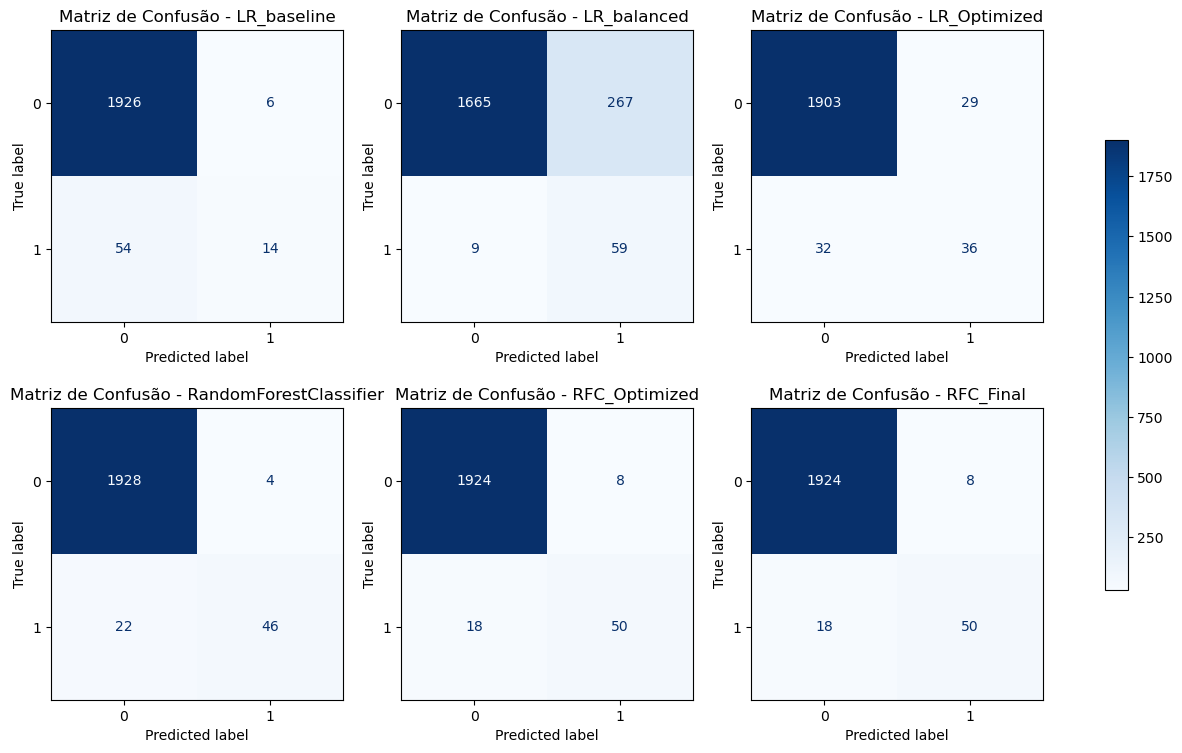

In [42]:
fig, ax = plt.subplots(2,3,figsize=(16, 9))
images = []
for i,modelo in enumerate(pipelines_resultados):
    if i < 3:
        disp = ConfusionMatrixDisplay(confusion_matrix=pipelines_resultados[modelo][-1])
        disp.plot(cmap='Blues', ax=ax[0][i], colorbar = False)
        ax[0][i].set_title(f'Matriz de Confusão - {modelo}')
        images.append(ax[0][i].images[0])
    else:
        disp = ConfusionMatrixDisplay(confusion_matrix=pipelines_resultados[modelo][-1])
        disp.plot(cmap='Blues', ax=ax[1][i-3], colorbar = False)
        ax[1][i-3].set_title(f'Matriz de Confusão - {modelo}')
        images.append(ax[0][i-3].images[0])

fig.colorbar(images[-1], ax=ax, location='right', shrink=0.65)

# RFC Analysis

## Baseline vs Hyperparameter Tuning vs Oversamplers tuning

The oversampler tunning did not yield different results, so we still stand with 50 correct predictions in a total of 68 real failures, and 26 misslabelling. In the next cell, we will compare all the 6 scores from our models until now.

In [136]:
for i, model in enumerate(pipelines_resultados):
    print(f" {model}\n {pipelines_resultados[model][4]}")

 LR_baseline
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.70      0.21      0.32        68

    accuracy                           0.97      2000
   macro avg       0.84      0.60      0.65      2000
weighted avg       0.96      0.97      0.96      2000

 LR_balanced
               precision    recall  f1-score   support

           0       0.99      0.86      0.92      1932
           1       0.18      0.87      0.30        68

    accuracy                           0.86      2000
   macro avg       0.59      0.86      0.61      2000
weighted avg       0.97      0.86      0.90      2000

 LR_Optimized
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      1932
           1       0.55      0.53      0.54        68

    accuracy                           0.97      2000
   macro avg       0.77      0.76      0.76      2000
weighted avg       0.97      0.

# XGBoost Classifier Comparison

Now, since the RFC yielded better results when tuned through optuna, we will just check if the XGBoost will also have an improvement, and if it would be our classificer of choice.

In [43]:
# ============================================================
# BLOCO 2 — Função objetivo
# O Optuna chama esta função N vezes, cada vez sugerindo
# valores diferentes para os hiperparâmetros.
# O objetivo é MAXIMIZAR o F1-weighted.
# ============================================================
def objective(trial):

    # Hiperparâmetros do XGBoost — o Optuna sugere os valores
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.9, log=True),
        'max_depth':         trial.suggest_int('max_depth', 2, 8),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 20),
        'gamma':             trial.suggest_float('gamma', 0, 1.0),
    }

    # Sampler — Optuna escolhe entre os três
    sampler_nome = trial.suggest_categorical(
        'sampler', ['SMOTE', 'BorderlineSMOTE']
    )
    sampler = SMOTE(random_state=42,sampling_strategy = 0.1) if sampler_nome == 'SMOTE' \
              else BorderlineSMOTE(random_state=42,sampling_strategy = 0.1)

    # Monta o pipeline com os parâmetros sugeridos
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('sampler', sampler),
        ('classifier', XGBClassifier(
            **params,
            objective='binary:logistic',
            #num_class=6,
            random_state=42,
            tree_method='hist',
            verbosity=0,        # Silencia logs do XGBoost
            eval_metric='logloss'
        ))
    ])

    # Cross-validation estratificado — mantém proporção das classes
    cv = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipe, x_train, y_train,
        cv=cv,
        scoring='matthews_corrcoef'
    )

    mean_score = scores.mean()
    
    # se retornar nan, penaliza o trial em vez de crashar
    if np.isnan(mean_score):
        return -1.0
    
    return mean_score

# ============================================================
# BLOCO 3 — Execução do estudo
# O pruner cancela tentativas ruins antes de terminar,
# economizando tempo computacional
# ============================================================
sampler_optuna  = optuna.samplers.TPESampler(seed=42)   # Bayesiano
pruner_optuna   = optuna.pruners.MedianPruner()         # Poda tentativas ruins

study = optuna.create_study(
    direction='maximize',           # Queremos maximizar o F1
    sampler=sampler_optuna,
    pruner=pruner_optuna
)

# n_trials = número de combinações testadas
# 100 tentativas já costuma convergir bem para XGBoost
study.optimize(objective, n_trials=100, show_progress_bar=True, n_jobs = -1)

# ============================================================
# BLOCO 4 — Resultados
# ============================================================
print(f"\nMelhor F1: {study.best_value:.4f}")
print(f"Melhores parâmetros:\n{study.best_params}")

# ============================================================
# BLOCO 5 — Treina o modelo final com os melhores parâmetros
# ============================================================
best = study.best_params

# Separa o sampler dos parâmetros do XGBoost
best_sampler = SMOTE(random_state=42,sampling_strategy = 0.1) if best['sampler'] == 'SMOTE' \
               else BorderlineSMOTE(random_state=42,sampling_strategy = 0.1)

best_xgb_params = {k: v for k, v in best.items() if k != 'sampler'}

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', best_sampler),
    ('classifier', XGBClassifier(
        **best_xgb_params,
        objective='binary:logistic',
        #num_class=6,
        random_state=42,
        tree_method='hist',
        eval_metric='logloss'
    ))
])

pipelines_resultados['XGBoost_baseline'] = [pipe,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = scores,return_train_score=True),classification_report(y_test,pipe.predict(x_test)),confusion_matrix(y_test,pipe.predict(x_test))]

[I 2026-03-09 11:41:14,949] A new study created in memory with name: no-name-6f3c1b71-ce4b-4ef3-8dbf-7e73bec11caf
Best trial: 0. Best value: 0.729427:   1%|          | 1/100 [00:19<31:43, 19.22s/it]

[I 2026-03-09 11:41:34,153] Trial 0 finished with value: 0.7294269169187619 and parameters: {'n_estimators': 361, 'learning_rate': 0.015035404709064889, 'max_depth': 2, 'subsample': 0.580644882896877, 'colsample_bytree': 0.5843617045936053, 'reg_alpha': 1.5457274478016476, 'reg_lambda': 0.7877031218517722, 'min_child_weight': 16, 'gamma': 0.17790789287029218, 'sampler': 'BorderlineSMOTE'}. Best is trial 0 with value: 0.7294269169187619.


Best trial: 0. Best value: 0.729427:   2%|▏         | 2/100 [00:19<13:13,  8.09s/it]

[I 2026-03-09 11:41:34,452] Trial 3 finished with value: 0.6989702287391817 and parameters: {'n_estimators': 244, 'learning_rate': 0.03192775399945042, 'max_depth': 4, 'subsample': 0.5432261863592396, 'colsample_bytree': 0.5169379870984905, 'reg_alpha': 0.00020687573517125382, 'reg_lambda': 3.2520172192794443, 'min_child_weight': 18, 'gamma': 0.4154144266236047, 'sampler': 'BorderlineSMOTE'}. Best is trial 0 with value: 0.7294269169187619.


Best trial: 0. Best value: 0.729427:   3%|▎         | 3/100 [00:22<09:23,  5.81s/it]

[I 2026-03-09 11:41:37,493] Trial 7 finished with value: 0.728765574662368 and parameters: {'n_estimators': 219, 'learning_rate': 0.010093545792475563, 'max_depth': 7, 'subsample': 0.6630440338013657, 'colsample_bytree': 0.6778328435260568, 'reg_alpha': 0.7036066191522558, 'reg_lambda': 0.011433466869026214, 'min_child_weight': 19, 'gamma': 0.8515107885988716, 'sampler': 'SMOTE'}. Best is trial 0 with value: 0.7294269169187619.


Best trial: 5. Best value: 0.754452:   4%|▍         | 4/100 [00:23<06:28,  4.04s/it]

[I 2026-03-09 11:41:38,897] Trial 5 finished with value: 0.7544520654180376 and parameters: {'n_estimators': 517, 'learning_rate': 0.13401080456318787, 'max_depth': 3, 'subsample': 0.7263519812122733, 'colsample_bytree': 0.5414750529184639, 'reg_alpha': 3.9753464397593357, 'reg_lambda': 0.2085430559026075, 'min_child_weight': 14, 'gamma': 0.7138048259576657, 'sampler': 'SMOTE'}. Best is trial 5 with value: 0.7544520654180376.


Best trial: 5. Best value: 0.754452:   5%|▌         | 5/100 [00:27<05:52,  3.72s/it]

[I 2026-03-09 11:41:42,014] Trial 4 finished with value: 0.6527960979123282 and parameters: {'n_estimators': 447, 'learning_rate': 0.49957714934161096, 'max_depth': 4, 'subsample': 0.5318015377807066, 'colsample_bytree': 0.9952968783873054, 'reg_alpha': 0.01666482305341285, 'reg_lambda': 0.0035141060627517347, 'min_child_weight': 18, 'gamma': 0.8950278865242882, 'sampler': 'BorderlineSMOTE'}. Best is trial 5 with value: 0.7544520654180376.


Best trial: 8. Best value: 0.773658:   6%|▌         | 6/100 [00:28<04:24,  2.82s/it]

[I 2026-03-09 11:41:43,106] Trial 8 finished with value: 0.7736578602635147 and parameters: {'n_estimators': 131, 'learning_rate': 0.055775404836639855, 'max_depth': 2, 'subsample': 0.6478381467659308, 'colsample_bytree': 0.8673718507742451, 'reg_alpha': 0.0001274955844751935, 'reg_lambda': 0.0039322334728921085, 'min_child_weight': 3, 'gamma': 0.10661250316868498, 'sampler': 'BorderlineSMOTE'}. Best is trial 8 with value: 0.7736578602635147.


Best trial: 8. Best value: 0.773658:   7%|▋         | 7/100 [00:28<03:16,  2.12s/it]

[I 2026-03-09 11:41:43,770] Trial 2 finished with value: 0.734097298440775 and parameters: {'n_estimators': 519, 'learning_rate': 0.1840524625023629, 'max_depth': 8, 'subsample': 0.6696048390355518, 'colsample_bytree': 0.623577941456436, 'reg_alpha': 4.39801249566214, 'reg_lambda': 2.5381274825645477, 'min_child_weight': 15, 'gamma': 0.422623531546898, 'sampler': 'SMOTE'}. Best is trial 8 with value: 0.7736578602635147.


Best trial: 6. Best value: 0.830781:   8%|▊         | 8/100 [00:37<06:19,  4.12s/it]

[I 2026-03-09 11:41:52,167] Trial 6 finished with value: 0.8307812884433573 and parameters: {'n_estimators': 560, 'learning_rate': 0.019177278946185025, 'max_depth': 3, 'subsample': 0.6100835028201453, 'colsample_bytree': 0.8279876829799101, 'reg_alpha': 0.10564057770617616, 'reg_lambda': 0.0009435359777508508, 'min_child_weight': 2, 'gamma': 0.055579778205269825, 'sampler': 'SMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:   9%|▉         | 9/100 [00:41<06:07,  4.04s/it]

[I 2026-03-09 11:41:56,042] Trial 1 finished with value: 0.8041717704220792 and parameters: {'n_estimators': 429, 'learning_rate': 0.10283490548164448, 'max_depth': 7, 'subsample': 0.5619203403247481, 'colsample_bytree': 0.7657528861694225, 'reg_alpha': 0.011340357793908875, 'reg_lambda': 6.355795940672666, 'min_child_weight': 5, 'gamma': 0.2850326759702546, 'sampler': 'SMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:  10%|█         | 10/100 [00:41<04:27,  2.97s/it]

[I 2026-03-09 11:41:56,616] Trial 14 finished with value: 0.7798137667226128 and parameters: {'n_estimators': 285, 'learning_rate': 0.3761332727167494, 'max_depth': 7, 'subsample': 0.9921785605516614, 'colsample_bytree': 0.6212732859468961, 'reg_alpha': 1.7040515333564041, 'reg_lambda': 0.0001461878984124274, 'min_child_weight': 4, 'gamma': 0.8307049592144268, 'sampler': 'BorderlineSMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:  11%|█         | 11/100 [00:42<03:15,  2.20s/it]

[I 2026-03-09 11:41:57,076] Trial 10 finished with value: 0.7414606215018339 and parameters: {'n_estimators': 418, 'learning_rate': 0.7788869618870007, 'max_depth': 5, 'subsample': 0.9646546860596843, 'colsample_bytree': 0.6063660448044694, 'reg_alpha': 0.00012935265932487264, 'reg_lambda': 2.329428919361223, 'min_child_weight': 9, 'gamma': 0.553017130038725, 'sampler': 'SMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:  12%|█▏        | 12/100 [00:44<03:20,  2.28s/it]

[I 2026-03-09 11:41:59,526] Trial 12 finished with value: 0.7053198771694567 and parameters: {'n_estimators': 206, 'learning_rate': 0.029092582391910204, 'max_depth': 4, 'subsample': 0.6391029671984017, 'colsample_bytree': 0.7799476553527988, 'reg_alpha': 0.00031987727456571634, 'reg_lambda': 0.036134843418383904, 'min_child_weight': 19, 'gamma': 0.06468261598109826, 'sampler': 'BorderlineSMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:  13%|█▎        | 13/100 [00:50<04:42,  3.25s/it]

[I 2026-03-09 11:42:05,020] Trial 11 finished with value: 0.7147343551603584 and parameters: {'n_estimators': 551, 'learning_rate': 0.5034066732226757, 'max_depth': 6, 'subsample': 0.9719439460261299, 'colsample_bytree': 0.9423511784427501, 'reg_alpha': 0.8038350070345919, 'reg_lambda': 0.0003371885743925233, 'min_child_weight': 16, 'gamma': 0.22447411438298048, 'sampler': 'BorderlineSMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:  14%|█▍        | 14/100 [00:50<03:28,  2.42s/it]

[I 2026-03-09 11:42:05,529] Trial 9 finished with value: 0.7047777451700221 and parameters: {'n_estimators': 588, 'learning_rate': 0.22928023672510406, 'max_depth': 2, 'subsample': 0.5070908049759115, 'colsample_bytree': 0.9448643345972473, 'reg_alpha': 0.06140527425224495, 'reg_lambda': 0.3906519196522749, 'min_child_weight': 14, 'gamma': 0.9673653052312301, 'sampler': 'BorderlineSMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:  15%|█▌        | 15/100 [00:59<06:04,  4.29s/it]

[I 2026-03-09 11:42:14,148] Trial 15 finished with value: 0.6666787231282028 and parameters: {'n_estimators': 323, 'learning_rate': 0.6012442607993685, 'max_depth': 7, 'subsample': 0.674533790210977, 'colsample_bytree': 0.6576011299667465, 'reg_alpha': 0.007121213156289659, 'reg_lambda': 0.0001045872383574177, 'min_child_weight': 16, 'gamma': 0.31480657049813465, 'sampler': 'SMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:  16%|█▌        | 16/100 [01:02<05:40,  4.05s/it]

[I 2026-03-09 11:42:17,648] Trial 13 finished with value: 0.7244029343946046 and parameters: {'n_estimators': 505, 'learning_rate': 0.12024250196752406, 'max_depth': 8, 'subsample': 0.8971029877779204, 'colsample_bytree': 0.6084678819310425, 'reg_alpha': 0.11363267267861588, 'reg_lambda': 0.00035267466800654405, 'min_child_weight': 20, 'gamma': 0.4127606234204514, 'sampler': 'BorderlineSMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:  17%|█▋        | 17/100 [01:05<05:16,  3.81s/it]

[I 2026-03-09 11:42:20,888] Trial 16 finished with value: 0.8126100269813008 and parameters: {'n_estimators': 558, 'learning_rate': 0.027758551973929135, 'max_depth': 2, 'subsample': 0.8507295573545375, 'colsample_bytree': 0.7519667967676869, 'reg_alpha': 0.005404421948811084, 'reg_lambda': 0.05385111809322093, 'min_child_weight': 5, 'gamma': 0.13962496073927078, 'sampler': 'SMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:  18%|█▊        | 18/100 [01:20<09:28,  6.93s/it]

[I 2026-03-09 11:42:35,105] Trial 21 finished with value: 0.8170882446715745 and parameters: {'n_estimators': 452, 'learning_rate': 0.06404123564404936, 'max_depth': 6, 'subsample': 0.8181801222770098, 'colsample_bytree': 0.7652206244636821, 'reg_alpha': 0.012962060013823766, 'reg_lambda': 0.0007290353355395852, 'min_child_weight': 1, 'gamma': 0.2721334678424342, 'sampler': 'SMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:  19%|█▉        | 19/100 [01:26<09:13,  6.83s/it]

[I 2026-03-09 11:42:41,671] Trial 17 finished with value: 0.8084874888090758 and parameters: {'n_estimators': 580, 'learning_rate': 0.025319811793209277, 'max_depth': 5, 'subsample': 0.8552774866439888, 'colsample_bytree': 0.8243190827688356, 'reg_alpha': 0.11068817126756739, 'reg_lambda': 0.0002145753268700911, 'min_child_weight': 9, 'gamma': 0.6300959176634964, 'sampler': 'SMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:  20%|██        | 20/100 [01:30<07:57,  5.97s/it]

[I 2026-03-09 11:42:45,642] Trial 19 finished with value: 0.782050866994725 and parameters: {'n_estimators': 575, 'learning_rate': 0.0780690646213624, 'max_depth': 6, 'subsample': 0.7705563785346051, 'colsample_bytree': 0.8137460095270449, 'reg_alpha': 0.032616790656785424, 'reg_lambda': 0.0002235174301522659, 'min_child_weight': 7, 'gamma': 0.2674515949297196, 'sampler': 'SMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:  21%|██        | 21/100 [01:33<06:28,  4.92s/it]

[I 2026-03-09 11:42:48,130] Trial 18 finished with value: 0.795958320558489 and parameters: {'n_estimators': 598, 'learning_rate': 0.05542893997594021, 'max_depth': 6, 'subsample': 0.8210798668228474, 'colsample_bytree': 0.7755296267158053, 'reg_alpha': 0.04092175938840662, 'reg_lambda': 0.00024723553221028805, 'min_child_weight': 7, 'gamma': 0.0037383649563771937, 'sampler': 'SMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:  22%|██▏       | 22/100 [01:34<04:56,  3.80s/it]

[I 2026-03-09 11:42:49,322] Trial 22 finished with value: 0.8001188924671191 and parameters: {'n_estimators': 447, 'learning_rate': 0.07255265523905485, 'max_depth': 5, 'subsample': 0.8283368230402791, 'colsample_bytree': 0.7766958688224456, 'reg_alpha': 0.11248264954935128, 'reg_lambda': 0.0009860418215541797, 'min_child_weight': 1, 'gamma': 0.008449554277965565, 'sampler': 'SMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:  23%|██▎       | 23/100 [01:36<04:08,  3.22s/it]

[I 2026-03-09 11:42:51,195] Trial 23 finished with value: 0.8178914076450234 and parameters: {'n_estimators': 429, 'learning_rate': 0.05996769788676149, 'max_depth': 5, 'subsample': 0.7952571979109233, 'colsample_bytree': 0.7760710899359967, 'reg_alpha': 0.002228444635761382, 'reg_lambda': 0.09080949841262162, 'min_child_weight': 1, 'gamma': 0.00797266024809578, 'sampler': 'SMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:  24%|██▍       | 24/100 [01:37<03:08,  2.49s/it]

[I 2026-03-09 11:42:51,959] Trial 20 finished with value: 0.794499332408771 and parameters: {'n_estimators': 596, 'learning_rate': 0.06970929719803927, 'max_depth': 6, 'subsample': 0.8259077877361319, 'colsample_bytree': 0.7707268994729645, 'reg_alpha': 0.01858246738035926, 'reg_lambda': 0.0010468388445393074, 'min_child_weight': 7, 'gamma': 0.28798617220995126, 'sampler': 'SMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:  25%|██▌       | 25/100 [01:37<02:32,  2.03s/it]

[I 2026-03-09 11:42:52,910] Trial 24 finished with value: 0.8112863430776259 and parameters: {'n_estimators': 600, 'learning_rate': 0.048641830850114004, 'max_depth': 3, 'subsample': 0.8172203693445674, 'colsample_bytree': 0.8349637152392546, 'reg_alpha': 0.004170803054499716, 'reg_lambda': 0.08164234223940303, 'min_child_weight': 1, 'gamma': 0.02399396901819459, 'sampler': 'SMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:  26%|██▌       | 26/100 [01:51<06:42,  5.43s/it]

[I 2026-03-09 11:43:06,303] Trial 25 finished with value: 0.8134921850058996 and parameters: {'n_estimators': 381, 'learning_rate': 0.06682431603998369, 'max_depth': 5, 'subsample': 0.8069406681144076, 'colsample_bytree': 0.8266046505239057, 'reg_alpha': 0.0021873255674352736, 'reg_lambda': 0.00149004289986873, 'min_child_weight': 1, 'gamma': 0.03549567793862862, 'sampler': 'SMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:  27%|██▋       | 27/100 [01:58<07:19,  6.02s/it]

[I 2026-03-09 11:43:13,698] Trial 27 finished with value: 0.8257614050416959 and parameters: {'n_estimators': 471, 'learning_rate': 0.0415633804661931, 'max_depth': 3, 'subsample': 0.757586629793828, 'colsample_bytree': 0.7032101929593284, 'reg_alpha': 0.0012540768298040155, 'reg_lambda': 0.0011922888874188215, 'min_child_weight': 1, 'gamma': 0.04738875328940015, 'sampler': 'SMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:  28%|██▊       | 28/100 [01:59<05:22,  4.47s/it]

[I 2026-03-09 11:43:14,552] Trial 30 finished with value: 0.8265028297750144 and parameters: {'n_estimators': 384, 'learning_rate': 0.04486790634982749, 'max_depth': 3, 'subsample': 0.7532437262086743, 'colsample_bytree': 0.6967434394522143, 'reg_alpha': 0.0015242867301303701, 'reg_lambda': 0.0013737447505993122, 'min_child_weight': 1, 'gamma': 0.1095723111529853, 'sampler': 'SMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 6. Best value: 0.830781:  29%|██▉       | 29/100 [02:00<03:58,  3.36s/it]

[I 2026-03-09 11:43:15,308] Trial 31 finished with value: 0.8276139816227575 and parameters: {'n_estimators': 389, 'learning_rate': 0.04289747604674224, 'max_depth': 3, 'subsample': 0.7542137151405621, 'colsample_bytree': 0.7050536477147596, 'reg_alpha': 0.001588835769373203, 'reg_lambda': 0.008781951900812551, 'min_child_weight': 1, 'gamma': 0.07599882855520898, 'sampler': 'SMOTE'}. Best is trial 6 with value: 0.8307812884433573.


Best trial: 32. Best value: 0.833072:  30%|███       | 30/100 [02:00<02:48,  2.41s/it]

[I 2026-03-09 11:43:15,502] Trial 32 finished with value: 0.8330718330274598 and parameters: {'n_estimators': 370, 'learning_rate': 0.016835768212775014, 'max_depth': 3, 'subsample': 0.7460553184222004, 'colsample_bytree': 0.7191920382234805, 'reg_alpha': 0.0019833328852566067, 'reg_lambda': 0.01236660541485504, 'min_child_weight': 2, 'gamma': 0.14879799807901736, 'sampler': 'SMOTE'}. Best is trial 32 with value: 0.8330718330274598.


Best trial: 32. Best value: 0.833072:  31%|███       | 31/100 [02:02<02:30,  2.18s/it]

[I 2026-03-09 11:43:17,143] Trial 28 finished with value: 0.8272141558774305 and parameters: {'n_estimators': 485, 'learning_rate': 0.018434701362226677, 'max_depth': 3, 'subsample': 0.7783352207640902, 'colsample_bytree': 0.7164547763792278, 'reg_alpha': 0.0019144210030713053, 'reg_lambda': 0.0014029542646533328, 'min_child_weight': 1, 'gamma': 0.15747627404420783, 'sampler': 'SMOTE'}. Best is trial 32 with value: 0.8330718330274598.


Best trial: 29. Best value: 0.838479:  32%|███▏      | 32/100 [02:03<02:14,  1.98s/it]

[I 2026-03-09 11:43:18,658] Trial 29 finished with value: 0.8384785919690732 and parameters: {'n_estimators': 485, 'learning_rate': 0.02291581087192391, 'max_depth': 3, 'subsample': 0.7614048921321894, 'colsample_bytree': 0.7087331964344676, 'reg_alpha': 0.0014999134038170025, 'reg_lambda': 0.08014705796293085, 'min_child_weight': 1, 'gamma': 0.11565198702386054, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  33%|███▎      | 33/100 [02:12<04:24,  3.95s/it]

[I 2026-03-09 11:43:27,215] Trial 26 finished with value: 0.8080583117731883 and parameters: {'n_estimators': 474, 'learning_rate': 0.05980456901968576, 'max_depth': 6, 'subsample': 0.7814015110132543, 'colsample_bytree': 0.7008147530346829, 'reg_alpha': 0.0018499225416209247, 'reg_lambda': 0.0012969877931991944, 'min_child_weight': 1, 'gamma': 0.0003402817226492577, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  34%|███▍      | 34/100 [02:21<05:59,  5.44s/it]

[I 2026-03-09 11:43:36,116] Trial 33 finished with value: 0.8231460530854768 and parameters: {'n_estimators': 481, 'learning_rate': 0.01748675723196405, 'max_depth': 3, 'subsample': 0.7314834004974616, 'colsample_bytree': 0.714550173659532, 'reg_alpha': 0.0008451113831500135, 'reg_lambda': 0.013758365078956386, 'min_child_weight': 2, 'gamma': 0.17488018835491492, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  35%|███▌      | 35/100 [02:23<04:48,  4.44s/it]

[I 2026-03-09 11:43:38,249] Trial 38 finished with value: 0.832851256257251 and parameters: {'n_estimators': 334, 'learning_rate': 0.01927410728565471, 'max_depth': 3, 'subsample': 0.7067618420447938, 'colsample_bytree': 0.7177891916704895, 'reg_alpha': 0.00047289245939364485, 'reg_lambda': 0.012859190347242448, 'min_child_weight': 4, 'gamma': 0.17908878706106884, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  36%|███▌      | 36/100 [02:23<03:23,  3.19s/it]

[I 2026-03-09 11:43:38,492] Trial 36 finished with value: 0.8203191179825238 and parameters: {'n_estimators': 371, 'learning_rate': 0.016262886800249277, 'max_depth': 3, 'subsample': 0.7088481298264295, 'colsample_bytree': 0.705795652593801, 'reg_alpha': 0.0007989070571161084, 'reg_lambda': 0.013112792397764373, 'min_child_weight': 3, 'gamma': 0.1479485143900064, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  37%|███▋      | 37/100 [02:25<03:03,  2.91s/it]

[I 2026-03-09 11:43:40,771] Trial 37 finished with value: 0.822230550899044 and parameters: {'n_estimators': 339, 'learning_rate': 0.01770688764471793, 'max_depth': 4, 'subsample': 0.6070921379457284, 'colsample_bytree': 0.7204316071254849, 'reg_alpha': 0.0004820242680755998, 'reg_lambda': 0.01433275318196823, 'min_child_weight': 3, 'gamma': 0.188341861756267, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  38%|███▊      | 38/100 [02:28<02:58,  2.87s/it]

[I 2026-03-09 11:43:43,556] Trial 34 finished with value: 0.8326722710628267 and parameters: {'n_estimators': 487, 'learning_rate': 0.01748850519482305, 'max_depth': 3, 'subsample': 0.7259811307879581, 'colsample_bytree': 0.7103460990593897, 'reg_alpha': 0.0006341863776562452, 'reg_lambda': 0.012369404922947509, 'min_child_weight': 3, 'gamma': 0.15748625789994875, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  39%|███▉      | 39/100 [02:29<02:17,  2.25s/it]

[I 2026-03-09 11:43:44,347] Trial 39 finished with value: 0.812988945015259 and parameters: {'n_estimators': 341, 'learning_rate': 0.015056133547528312, 'max_depth': 4, 'subsample': 0.5926372245653889, 'colsample_bytree': 0.727322139654706, 'reg_alpha': 0.0005563729606803175, 'reg_lambda': 0.011705434720580105, 'min_child_weight': 3, 'gamma': 0.19908498029661365, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  40%|████      | 40/100 [02:29<01:44,  1.74s/it]

[I 2026-03-09 11:43:44,869] Trial 35 finished with value: 0.835282975803163 and parameters: {'n_estimators': 486, 'learning_rate': 0.01726723172992355, 'max_depth': 3, 'subsample': 0.718268354860797, 'colsample_bytree': 0.6994062664096463, 'reg_alpha': 0.0005862989494126125, 'reg_lambda': 0.013400361951957523, 'min_child_weight': 3, 'gamma': 0.1832752723002875, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  41%|████      | 41/100 [02:38<03:50,  3.90s/it]

[I 2026-03-09 11:43:53,801] Trial 40 finished with value: 0.8281135993345068 and parameters: {'n_estimators': 347, 'learning_rate': 0.015738735268026646, 'max_depth': 4, 'subsample': 0.7123103432594882, 'colsample_bytree': 0.7282838039666046, 'reg_alpha': 0.0004801022510832307, 'reg_lambda': 0.012671115803510198, 'min_child_weight': 3, 'gamma': 0.2045266756151164, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  42%|████▏     | 42/100 [02:45<04:30,  4.67s/it]

[I 2026-03-09 11:44:00,290] Trial 45 finished with value: 0.7804682497208711 and parameters: {'n_estimators': 302, 'learning_rate': 0.01033564671974903, 'max_depth': 2, 'subsample': 0.6924493029026493, 'colsample_bytree': 0.650823240405783, 'reg_alpha': 0.00035849388607703915, 'reg_lambda': 0.0056849107572510705, 'min_child_weight': 5, 'gamma': 0.39592486550808353, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  43%|████▎     | 43/100 [02:46<03:19,  3.49s/it]

[I 2026-03-09 11:44:01,049] Trial 46 finished with value: 0.7806506841508077 and parameters: {'n_estimators': 300, 'learning_rate': 0.011327959663710375, 'max_depth': 2, 'subsample': 0.6961624215058967, 'colsample_bytree': 0.582724003535304, 'reg_alpha': 0.0002601406770591341, 'reg_lambda': 0.004576706966039195, 'min_child_weight': 5, 'gamma': 0.3522497703443307, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  44%|████▍     | 44/100 [02:46<02:31,  2.70s/it]

[I 2026-03-09 11:44:01,886] Trial 47 finished with value: 0.7857899712073844 and parameters: {'n_estimators': 314, 'learning_rate': 0.011463010340420717, 'max_depth': 2, 'subsample': 0.6948411024121461, 'colsample_bytree': 0.6543899426085693, 'reg_alpha': 0.0002615676286496089, 'reg_lambda': 0.0041155419459226895, 'min_child_weight': 5, 'gamma': 0.35806086323494396, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  45%|████▌     | 45/100 [02:47<01:53,  2.06s/it]

[I 2026-03-09 11:44:02,482] Trial 41 finished with value: 0.8258436834799601 and parameters: {'n_estimators': 338, 'learning_rate': 0.011840478286176242, 'max_depth': 4, 'subsample': 0.6029270817485134, 'colsample_bytree': 0.6543885296205852, 'reg_alpha': 0.0005372826857066017, 'reg_lambda': 0.015394628477567942, 'min_child_weight': 3, 'gamma': 0.19143428706073187, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  46%|████▌     | 46/100 [02:48<01:28,  1.64s/it]

[I 2026-03-09 11:44:03,134] Trial 42 finished with value: 0.8146007773227755 and parameters: {'n_estimators': 310, 'learning_rate': 0.011570378878137378, 'max_depth': 4, 'subsample': 0.5996237351344846, 'colsample_bytree': 0.875948288866899, 'reg_alpha': 0.0004321419094230133, 'reg_lambda': 0.005000466098135841, 'min_child_weight': 3, 'gamma': 0.3507561539393954, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  47%|████▋     | 47/100 [02:48<01:08,  1.30s/it]

[I 2026-03-09 11:44:03,636] Trial 43 finished with value: 0.8328177276247537 and parameters: {'n_estimators': 327, 'learning_rate': 0.010084439929867628, 'max_depth': 4, 'subsample': 0.5971276953796535, 'colsample_bytree': 0.6482345232202413, 'reg_alpha': 0.0003843609705082937, 'reg_lambda': 0.18350845444969544, 'min_child_weight': 5, 'gamma': 0.3802978940312773, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  48%|████▊     | 48/100 [02:50<01:08,  1.31s/it]

[I 2026-03-09 11:44:04,979] Trial 44 finished with value: 0.8344920031818595 and parameters: {'n_estimators': 304, 'learning_rate': 0.010393969097789292, 'max_depth': 4, 'subsample': 0.6977644672050133, 'colsample_bytree': 0.6567544002420213, 'reg_alpha': 0.377885329117292, 'reg_lambda': 0.19078205960688016, 'min_child_weight': 5, 'gamma': 0.36713546291139615, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  49%|████▉     | 49/100 [02:55<02:07,  2.50s/it]

[I 2026-03-09 11:44:10,268] Trial 48 finished with value: 0.7853905205880485 and parameters: {'n_estimators': 288, 'learning_rate': 0.011219120450780237, 'max_depth': 2, 'subsample': 0.7033880015481765, 'colsample_bytree': 0.6531183804998196, 'reg_alpha': 0.0002656463551162362, 'reg_lambda': 0.004606246860011817, 'min_child_weight': 5, 'gamma': 0.40501586047708826, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  90%|█████████ | 90/100 [05:48<00:55,  5.58s/it]

[I 2026-03-09 11:47:03,090] Trial 92 finished with value: 0.8135359394231998 and parameters: {'n_estimators': 489, 'learning_rate': 0.016666169672877713, 'max_depth': 2, 'subsample': 0.7451424458453179, 'colsample_bytree': 0.7653356269143912, 'reg_alpha': 0.0026912849116688797, 'reg_lambda': 0.017650406624521664, 'min_child_weight': 1, 'gamma': 0.2115338084686243, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  91%|█████████ | 91/100 [05:52<00:48,  5.36s/it]

[I 2026-03-09 11:47:07,921] Trial 93 finished with value: 0.8259058749169554 and parameters: {'n_estimators': 485, 'learning_rate': 0.012540341583929434, 'max_depth': 2, 'subsample': 0.8080874432494592, 'colsample_bytree': 0.7635214927040157, 'reg_alpha': 0.002434477800253838, 'reg_lambda': 0.01966552095975482, 'min_child_weight': 1, 'gamma': 0.21312579487514208, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  92%|█████████▏| 92/100 [06:04<00:58,  7.33s/it]

[I 2026-03-09 11:47:19,846] Trial 95 finished with value: 0.8222194276574003 and parameters: {'n_estimators': 492, 'learning_rate': 0.01687503157375606, 'max_depth': 2, 'subsample': 0.7497724656879111, 'colsample_bytree': 0.713731277630765, 'reg_alpha': 0.001532732784814106, 'reg_lambda': 0.019231672428321855, 'min_child_weight': 1, 'gamma': 0.21508584015222215, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  93%|█████████▎| 93/100 [06:05<00:37,  5.41s/it]

[I 2026-03-09 11:47:20,760] Trial 96 finished with value: 0.817916148049943 and parameters: {'n_estimators': 483, 'learning_rate': 0.016220576417392468, 'max_depth': 2, 'subsample': 0.7797809290231379, 'colsample_bytree': 0.7154930120141769, 'reg_alpha': 0.0014903371411020487, 'reg_lambda': 0.019049075327732302, 'min_child_weight': 1, 'gamma': 0.1860467412052592, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  94%|█████████▍| 94/100 [06:09<00:29,  4.88s/it]

[I 2026-03-09 11:47:24,432] Trial 89 finished with value: 0.8298630612264811 and parameters: {'n_estimators': 488, 'learning_rate': 0.01673454705690794, 'max_depth': 7, 'subsample': 0.7522159398199829, 'colsample_bytree': 0.7661874316554114, 'reg_alpha': 0.00034796385970642716, 'reg_lambda': 0.019439250717217374, 'min_child_weight': 4, 'gamma': 0.1608103865492962, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  95%|█████████▌| 95/100 [06:13<00:23,  4.70s/it]

[I 2026-03-09 11:47:28,721] Trial 94 finished with value: 0.82777458559364 and parameters: {'n_estimators': 491, 'learning_rate': 0.019594726594488725, 'max_depth': 4, 'subsample': 0.6903875299848216, 'colsample_bytree': 0.7095889488805944, 'reg_alpha': 0.00021858487947178565, 'reg_lambda': 0.009013126557582608, 'min_child_weight': 1, 'gamma': 0.21391058656658785, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  96%|█████████▌| 96/100 [06:19<00:20,  5.03s/it]

[I 2026-03-09 11:47:34,523] Trial 90 finished with value: 0.8244668886152204 and parameters: {'n_estimators': 489, 'learning_rate': 0.017191178316021637, 'max_depth': 7, 'subsample': 0.7453712128224528, 'colsample_bytree': 0.6925502820245999, 'reg_alpha': 0.002558617843811283, 'reg_lambda': 0.008066633866177647, 'min_child_weight': 1, 'gamma': 0.16389087531645136, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  98%|█████████▊| 98/100 [06:20<00:05,  2.66s/it]

[I 2026-03-09 11:47:35,297] Trial 91 finished with value: 0.8280985539473451 and parameters: {'n_estimators': 435, 'learning_rate': 0.01726699901964152, 'max_depth': 8, 'subsample': 0.749687457065961, 'colsample_bytree': 0.7652336971506444, 'reg_alpha': 0.00021154631209899857, 'reg_lambda': 0.007784626317041409, 'min_child_weight': 1, 'gamma': 0.16437472556436158, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.
[I 2026-03-09 11:47:35,417] Trial 98 finished with value: 0.828290459981727 and parameters: {'n_estimators': 475, 'learning_rate': 0.01062449538636623, 'max_depth': 3, 'subsample': 0.6182988633958649, 'colsample_bytree': 0.7097096541850167, 'reg_alpha': 0.0015123726720368263, 'reg_lambda': 1.2048524254097133, 'min_child_weight': 3, 'gamma': 0.3272062311663602, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479:  99%|█████████▉| 99/100 [06:21<00:02,  2.17s/it]

[I 2026-03-09 11:47:36,453] Trial 97 finished with value: 0.828293759757426 and parameters: {'n_estimators': 484, 'learning_rate': 0.012752265126410136, 'max_depth': 4, 'subsample': 0.8073783767276785, 'colsample_bytree': 0.713619852352003, 'reg_alpha': 0.00020086539217952813, 'reg_lambda': 0.0005524793371401575, 'min_child_weight': 3, 'gamma': 0.15561926665716075, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.


Best trial: 29. Best value: 0.838479: 100%|██████████| 100/100 [06:27<00:00,  3.87s/it]


[I 2026-03-09 11:47:42,142] Trial 99 finished with value: 0.8287701329696484 and parameters: {'n_estimators': 333, 'learning_rate': 0.010373652507675147, 'max_depth': 8, 'subsample': 0.7225197397662569, 'colsample_bytree': 0.7145740510408615, 'reg_alpha': 0.0005566574460961912, 'reg_lambda': 0.010245523573952099, 'min_child_weight': 3, 'gamma': 0.1786865914783095, 'sampler': 'SMOTE'}. Best is trial 29 with value: 0.8384785919690732.

Melhor F1: 0.8385
Melhores parâmetros:
{'n_estimators': 485, 'learning_rate': 0.02291581087192391, 'max_depth': 3, 'subsample': 0.7614048921321894, 'colsample_bytree': 0.7087331964344676, 'reg_alpha': 0.0014999134038170025, 'reg_lambda': 0.08014705796293085, 'min_child_weight': 1, 'gamma': 0.11565198702386054, 'sampler': 'SMOTE'}


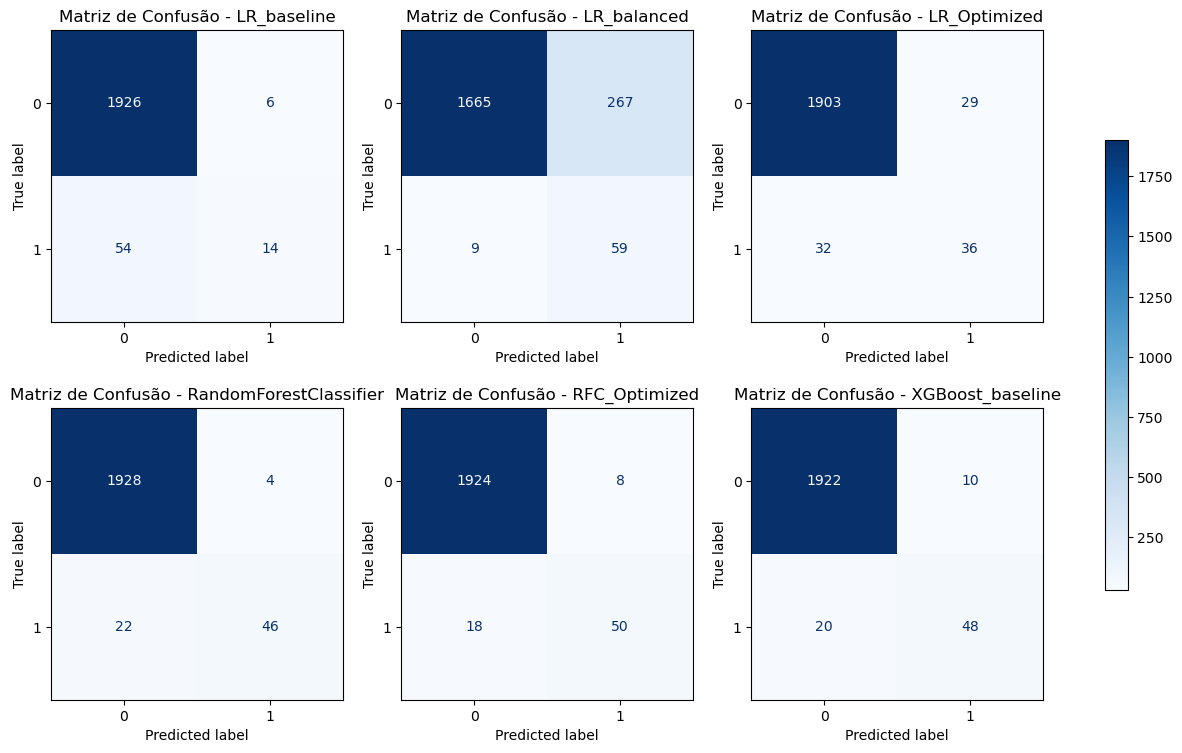

In [45]:
fig, ax = plt.subplots(2,3,figsize=(16, 9))
images = []
for i,modelo in enumerate(m for m in pipelines_resultados if m !='RFC_Final'):
    if i < 3:
        disp = ConfusionMatrixDisplay(confusion_matrix=pipelines_resultados[modelo][-1])
        disp.plot(cmap='Blues', ax=ax[0][i], colorbar = False)
        ax[0][i].set_title(f'Matriz de Confusão - {modelo}')
        images.append(ax[0][i].images[0])
    else:
        disp = ConfusionMatrixDisplay(confusion_matrix=pipelines_resultados[modelo][-1])
        disp.plot(cmap='Blues', ax=ax[1][i-3], colorbar = False)
        ax[1][i-3].set_title(f'Matriz de Confusão - {modelo}')
        images.append(ax[0][i-3].images[0])

fig.colorbar(images[-1], ax=ax, location='right', shrink=0.65)

## Results Analysis

Even though the XGBoost Classifier had a good performance, it is still not better than our RFC. So we will stick to for now.

# Last Step: Feature Analysis

Now, since we tested many kinds of classifiers, and tuned many parameters, let's now check if all of our features are good, and what can be simplified to not overwhelm our model of choice.

For instance, we created the feature 'Power', which is just the product of rotational speed and torque. For the Logistic Regression model, it was a good choice, because that kind of classifier do not look into these kind of interactions of the model. However, our ensemble models had this kind of built'in in their logic. So the 'Power' Feature may be actually hindering our classifiers performance.

Let's check our feature importances through a SHAP chart for BOth RFC and XGB

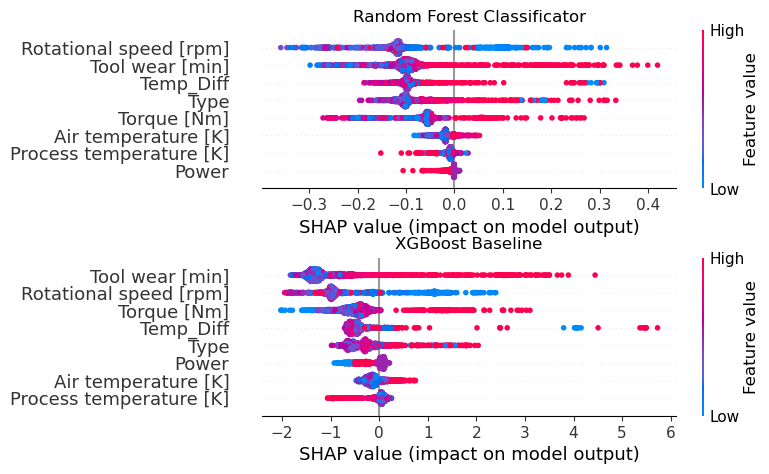

In [93]:
fig, ax = plt.subplots(2,1,figsize=(16,8))

explainer = shap.TreeExplainer(pipelines_resultados['RFC_Optimized'][1][1])
x_test_mod = pipe[0].fit_transform(x_test)

shap_values = explainer.shap_values(x_test_mod)

# Para classificação binária, pega a classe 1
plt.sca(ax[0])
shap.summary_plot(shap_values[:,:,1], x_test_mod,feature_names = list(X.columns), show = False)

explainer = shap.TreeExplainer(pipelines_resultados['XGBoost_baseline'][1][2])

shap_values = explainer.shap_values(x_test_mod)
plt.sca(ax[1])
# Para classificação binária, pega a classe 1
shap.summary_plot(shap_values, x_test_mod,feature_names = list(X.columns), show = False)
ax[1].set_title('XGBoost Baseline')
ax[0].set_title('Random Forest Classificator')


plt.show()

Let's try our top 3 models again, but this time, changing our dataset, removing unnecessary features. show by SHAP:

## Feature Analysis

As seen, both models have 3 features at a lower tier. So they will be dropped, and our models will be ran with the reduced features data and have their performance assessed once more.

In [95]:
X_new = X.drop(columns = ['Power','Air temperature [K]','Process temperature [K]'])

In [99]:
pipelines_resultados['RFC_Optimized'][0]

,steps,"[('Preprocessor', ...), ('Classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [104]:
pipelines_resultados['RFC_Optimized'][0].steps[0][1].transformers

[('num',
  StandardScaler(),
  ['Air temperature [K]',
   'Process temperature [K]',
   'Rotational speed [rpm]',
   'Tool wear [min]',
   'Torque [Nm]',
   'Temp_Diff',
   'Power']),
 ('cat', OrdinalEncoder(), ['Type'])]

In [113]:
features_continuas = X_new.drop(columns = 'Type').columns.tolist()
features_categoricas = ['Type']
x_train, x_test, y_train, y_test = train_test_split(X_new, Y, test_size=0.2, random_state=42,stratify = Y)

rfc_reduzido = clone(pipelines_resultados['RFC_Optimized'][0])
drop_colunas = ['Air temperature [K]', 'Process temperature [K]', 'Power']
rfc_reduzido.steps[0][1].transformers = [
    (name, transformer, [col for col in cols if col not in drop_colunas])
    for name, transformer, cols in rfc_reduzido.steps[0][1].transformers
]

pipelines_resultados['RFC_Reduced'] = [pipe := rfc_reduzido,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = scores,return_train_score=True),classification_report(y_test,pipe.predict(x_test)),confusion_matrix(y_test,pipe.predict(x_test))]


xgb_reduzido = clone(pipelines_resultados['XGBoost_baseline'][0])
drop_colunas = ['Air temperature [K]', 'Process temperature [K]', 'Power']
xgb_reduzido.steps[0][1].transformers = [
    (name, transformer, [col for col in cols if col not in drop_colunas])
    for name, transformer, cols in xgb_reduzido.steps[0][1].transformers]


pipelines_resultados['XGBoost_Reduced'] = [pipe := xgb_reduzido,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = scores,return_train_score=True),classification_report(y_test,pipe.predict(x_test)),confusion_matrix(y_test,pipe.predict(x_test))]


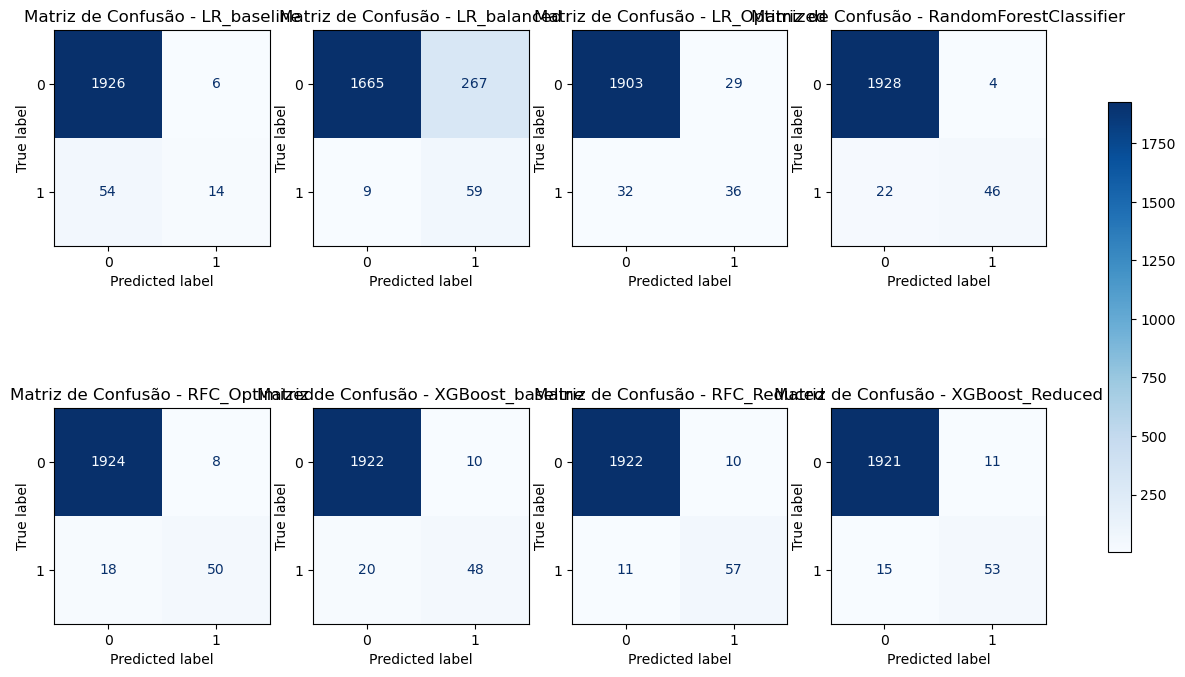

In [114]:
fig, ax = plt.subplots(2,4,figsize=(16, 9))
images = []
for i,modelo in enumerate(m for m in pipelines_resultados if m !='RFC_Final'):
    if i < 4:
        disp = ConfusionMatrixDisplay(confusion_matrix=pipelines_resultados[modelo][-1])
        disp.plot(cmap='Blues', ax=ax[0][i], colorbar = False)
        ax[0][i].set_title(f'Matriz de Confusão - {modelo}')
        images.append(ax[0][i].images[0])
    else:
        disp = ConfusionMatrixDisplay(confusion_matrix=pipelines_resultados[modelo][-1])
        disp.plot(cmap='Blues', ax=ax[1][i-4], colorbar = False)
        ax[1][i-4].set_title(f'Matriz de Confusão - {modelo}')
        images.append(ax[0][i-4].images[0])

fig.colorbar(images[-1], ax=ax, location='right', shrink=0.65)

## Feature Reduction Analysis

As predicted, our features that were removed improved our models' performance for both RFC and XGBoost. RFC reached an outstanding result of 57 correctly predicted failures, against only 21 misslabelling.

This shows that not only the pipeline fine tunning is needed, but also the features we are using must be carrefully selected.

In [ ]:
fig, ax = plt.subplots(2,1,figsize=(16,8))

explainer = shap.TreeExplainer(pipelines_resultados['RFC_Reduced'][1][1])
x_test_mod = pipe[0].fit_transform(x_test)

shap_values = explainer.shap_values(x_test_mod)

# Para classificação binária, pega a classe 1
plt.sca(ax[0])
shap.summary_plot(shap_values[:,:,1], x_test_mod,feature_names = list(X_new.columns), show = False)

explainer = shap.TreeExplainer(pipelines_resultados['XGBoost_Reduced'][1][2])

shap_values = explainer.shap_values(x_test_mod)
plt.sca(ax[1])
# Para classificação binária, pega a classe 1
shap.summary_plot(shap_values, x_test_mod,feature_names = list(X_new.columns), show = False)
ax[1].set_title('XGBoost Baseline')
ax[0].set_title('Random Forest Classificator')


plt.show()

# Last optimization

To finish our analysis, let's try a final tuning in our RFC, to check if it is possible to still improve our model.

We will tune our RFC hyperparameters, without oversamplers, just using class_weight='balanced'. Then, we will compare with our best result from our entire notebook, and draw conclusions

In [117]:
# ============================================================
# BLOCO 1 — Preprocessor (igual ao seu pipeline atual)
# ============================================================
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), features_continuas),
    ('cat', OrdinalEncoder(), features_categoricas)
])

# ============================================================
# BLOCO 2 — Função objetivo
# O Optuna chama esta função N vezes, cada vez sugerindo
# valores diferentes para os hiperparâmetros.
# O objetivo é MAXIMIZAR o F1-weighted.
# ============================================================
def objective(trial):

    # Hiperparâmetros do RFC — o Optuna sugere os valores
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 150),
        'criterion':         trial.suggest_categorical('criterion',['gini', 'entropy', 'log_loss']),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':        trial.suggest_categorical('max_features',['sqrt', 'log2', None]),
        'ccp_alpha':  trial.suggest_float('ccp_alpha', 0, 0.05)
    }

    use_max_depth = trial.suggest_categorical('use_max_depth', [True, False])
    max_depth = trial.suggest_int('max_depth', 1, 50) if use_max_depth else None
    
    # Monta o pipeline com os parâmetros sugeridos
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            **params,
            max_depth = max_depth,
            random_state=42,
            class_weight = 'balanced'
        ))
    ])

    # Cross-validation estratificado — mantém proporção das classes
    cv = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)
    scores = cross_val_score(
        pipe, x_train, y_train,
        cv=cv,
        scoring='matthews_corrcoef',
        n_jobs=-1
    )

    return scores.mean()

# ============================================================
# BLOCO 3 — Execução do estudo
# O pruner cancela tentativas ruins antes de terminar,
# economizando tempo computacional
# ============================================================

In [118]:
sampler_optuna  = optuna.samplers.TPESampler(seed=42)   # Bayesiano
pruner_optuna   = optuna.pruners.MedianPruner()         # Poda tentativas ruins

study = optuna.create_study(
    direction='maximize',           # Queremos maximizar o F1
    sampler=sampler_optuna,
    pruner=pruner_optuna
)

# n_trials = número de combinações testadas
# 100 tentativas já costuma convergir bem para XGBoost
study.optimize(objective, n_trials=800, show_progress_bar=True, n_jobs = -1)


[I 2026-03-09 15:08:04,946] A new study created in memory with name: no-name-f961c6d7-ccc2-472a-8894-527c68919fbe
Best trial: 3. Best value: 0.517869:   0%|          | 1/800 [00:11<2:33:49, 11.55s/it]

[I 2026-03-09 15:08:16,497] Trial 3 finished with value: 0.5178686992181094 and parameters: {'n_estimators': 54, 'criterion': 'gini', 'min_samples_split': 28, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.008406319406002878, 'use_max_depth': False}. Best is trial 3 with value: 0.5178686992181094.


Best trial: 2. Best value: 0.532916:   0%|          | 2/800 [00:13<1:21:30,  6.13s/it]

[I 2026-03-09 15:08:18,829] Trial 2 finished with value: 0.5329160219334164 and parameters: {'n_estimators': 105, 'criterion': 'log_loss', 'min_samples_split': 11, 'min_samples_leaf': 11, 'max_features': None, 'ccp_alpha': 0.015288619537162719, 'use_max_depth': False}. Best is trial 2 with value: 0.5329160219334164.


Best trial: 2. Best value: 0.532916:   0%|          | 3/800 [00:15<51:09,  3.85s/it]  

[I 2026-03-09 15:08:19,969] Trial 1 finished with value: 0.5188693799207197 and parameters: {'n_estimators': 99, 'criterion': 'entropy', 'min_samples_split': 20, 'min_samples_leaf': 11, 'max_features': 'sqrt', 'ccp_alpha': 0.023573861317302026, 'use_max_depth': False}. Best is trial 2 with value: 0.5329160219334164.


Best trial: 2. Best value: 0.532916:   0%|          | 4/800 [00:15<34:08,  2.57s/it]

[I 2026-03-09 15:08:20,584] Trial 5 finished with value: 0.343303433103767 and parameters: {'n_estimators': 76, 'criterion': 'gini', 'min_samples_split': 28, 'min_samples_leaf': 9, 'max_features': 'log2', 'ccp_alpha': 0.04777156001978768, 'use_max_depth': True, 'max_depth': 10}. Best is trial 2 with value: 0.5329160219334164.
[I 2026-03-09 15:08:20,646] Trial 6 finished with value: 0.3502552848347813 and parameters: {'n_estimators': 67, 'criterion': 'gini', 'min_samples_split': 19, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'ccp_alpha': 0.039741474361729485, 'use_max_depth': False}. Best is trial 2 with value: 0.5329160219334164.


Best trial: 2. Best value: 0.532916:   1%|          | 6/800 [00:16<18:53,  1.43s/it]

[I 2026-03-09 15:08:21,406] Trial 0 finished with value: 0.5207953079150438 and parameters: {'n_estimators': 74, 'criterion': 'log_loss', 'min_samples_split': 12, 'min_samples_leaf': 16, 'max_features': 'sqrt', 'ccp_alpha': 0.017193534001037014, 'use_max_depth': True, 'max_depth': 41}. Best is trial 2 with value: 0.5329160219334164.


Best trial: 2. Best value: 0.532916:   1%|          | 7/800 [00:18<22:03,  1.67s/it]

[I 2026-03-09 15:08:23,711] Trial 7 finished with value: 0.5142568034331045 and parameters: {'n_estimators': 103, 'criterion': 'entropy', 'min_samples_split': 22, 'min_samples_leaf': 6, 'max_features': None, 'ccp_alpha': 0.04955738652810461, 'use_max_depth': False}. Best is trial 2 with value: 0.5329160219334164.


Best trial: 2. Best value: 0.532916:   1%|          | 8/800 [00:20<21:56,  1.66s/it]

[I 2026-03-09 15:08:25,358] Trial 4 finished with value: 0.3404886934472111 and parameters: {'n_estimators': 142, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 9, 'max_features': 'log2', 'ccp_alpha': 0.04724909681092473, 'use_max_depth': False}. Best is trial 2 with value: 0.5329160219334164.


Best trial: 2. Best value: 0.532916:   1%|          | 9/800 [00:21<18:57,  1.44s/it]

[I 2026-03-09 15:08:26,245] Trial 8 finished with value: 0.5163396449374142 and parameters: {'n_estimators': 90, 'criterion': 'entropy', 'min_samples_split': 12, 'min_samples_leaf': 6, 'max_features': 'log2', 'ccp_alpha': 0.02353248509537749, 'use_max_depth': False}. Best is trial 2 with value: 0.5329160219334164.


Best trial: 2. Best value: 0.532916:   1%|▏         | 10/800 [00:22<17:49,  1.35s/it]

[I 2026-03-09 15:08:27,393] Trial 9 finished with value: 0.493650461624213 and parameters: {'n_estimators': 108, 'criterion': 'log_loss', 'min_samples_split': 22, 'min_samples_leaf': 18, 'max_features': 'log2', 'ccp_alpha': 0.02971069186575047, 'use_max_depth': True, 'max_depth': 31}. Best is trial 2 with value: 0.5329160219334164.


Best trial: 2. Best value: 0.532916:   1%|▏         | 11/800 [00:24<19:09,  1.46s/it]

[I 2026-03-09 15:08:29,099] Trial 10 finished with value: 0.3332800952831148 and parameters: {'n_estimators': 109, 'criterion': 'gini', 'min_samples_split': 18, 'min_samples_leaf': 7, 'max_features': None, 'ccp_alpha': 0.043350365499671285, 'use_max_depth': False}. Best is trial 2 with value: 0.5329160219334164.


Best trial: 2. Best value: 0.532916:   2%|▏         | 12/800 [00:26<22:06,  1.68s/it]

[I 2026-03-09 15:08:31,319] Trial 11 finished with value: 0.5169998496807974 and parameters: {'n_estimators': 131, 'criterion': 'log_loss', 'min_samples_split': 16, 'min_samples_leaf': 7, 'max_features': None, 'ccp_alpha': 0.045501985173992184, 'use_max_depth': False}. Best is trial 2 with value: 0.5329160219334164.


Best trial: 2. Best value: 0.532916:   2%|▏         | 13/800 [00:27<21:08,  1.61s/it]

[I 2026-03-09 15:08:32,764] Trial 12 finished with value: 0.39007359227721194 and parameters: {'n_estimators': 150, 'criterion': 'gini', 'min_samples_split': 23, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'ccp_alpha': 0.025861066402076617, 'use_max_depth': True, 'max_depth': 19}. Best is trial 2 with value: 0.5329160219334164.


Best trial: 13. Best value: 0.581563:   2%|▏         | 14/800 [00:29<19:43,  1.51s/it]

[I 2026-03-09 15:08:34,022] Trial 13 finished with value: 0.581562612728423 and parameters: {'n_estimators': 121, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 15, 'max_features': 'log2', 'ccp_alpha': 0.0028380171021417213, 'use_max_depth': False}. Best is trial 13 with value: 0.581562612728423.


Best trial: 13. Best value: 0.581563:   2%|▏         | 15/800 [00:30<17:48,  1.36s/it]

[I 2026-03-09 15:08:35,038] Trial 14 finished with value: 0.47815496434868726 and parameters: {'n_estimators': 93, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'ccp_alpha': 0.03835678645424967, 'use_max_depth': False}. Best is trial 13 with value: 0.581562612728423.


Best trial: 13. Best value: 0.581563:   2%|▏         | 16/800 [00:30<15:45,  1.21s/it]

[I 2026-03-09 15:08:35,885] Trial 15 finished with value: 0.564249406482132 and parameters: {'n_estimators': 77, 'criterion': 'log_loss', 'min_samples_split': 13, 'min_samples_leaf': 11, 'max_features': 'sqrt', 'ccp_alpha': 0.004461652668625649, 'use_max_depth': False}. Best is trial 13 with value: 0.581562612728423.


Best trial: 13. Best value: 0.581563:   2%|▏         | 17/800 [00:33<19:52,  1.52s/it]

[I 2026-03-09 15:08:38,143] Trial 16 finished with value: 0.5035242713676489 and parameters: {'n_estimators': 145, 'criterion': 'gini', 'min_samples_split': 25, 'min_samples_leaf': 8, 'max_features': None, 'ccp_alpha': 0.018795704157821128, 'use_max_depth': False}. Best is trial 13 with value: 0.581562612728423.


Best trial: 17. Best value: 0.586514:   2%|▏         | 18/800 [00:35<22:05,  1.70s/it]

[I 2026-03-09 15:08:40,245] Trial 17 finished with value: 0.5865143514373266 and parameters: {'n_estimators': 132, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 13, 'max_features': None, 'ccp_alpha': 0.0009353304043921949, 'use_max_depth': True, 'max_depth': 6}. Best is trial 17 with value: 0.5865143514373266.


Best trial: 17. Best value: 0.586514:   2%|▏         | 19/800 [00:38<28:12,  2.17s/it]

[I 2026-03-09 15:08:43,513] Trial 18 finished with value: 0.5365566546887337 and parameters: {'n_estimators': 133, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 14, 'max_features': None, 'ccp_alpha': 0.009898019068405903, 'use_max_depth': True, 'max_depth': 50}. Best is trial 17 with value: 0.5865143514373266.


Best trial: 17. Best value: 0.586514:   2%|▎         | 20/800 [00:40<26:56,  2.07s/it]

[I 2026-03-09 15:08:45,364] Trial 19 finished with value: 0.5333113386596007 and parameters: {'n_estimators': 81, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 15, 'max_features': None, 'ccp_alpha': 0.011367930272094613, 'use_max_depth': True, 'max_depth': 47}. Best is trial 17 with value: 0.5865143514373266.


Best trial: 17. Best value: 0.586514:   3%|▎         | 21/800 [00:43<29:29,  2.27s/it]

[I 2026-03-09 15:08:48,101] Trial 20 finished with value: 0.533765555218904 and parameters: {'n_estimators': 123, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 14, 'max_features': None, 'ccp_alpha': 0.012515058855855438, 'use_max_depth': True, 'max_depth': 46}. Best is trial 17 with value: 0.5865143514373266.


Best trial: 21. Best value: 0.61726:   3%|▎         | 22/800 [00:45<31:40,  2.44s/it] 

[I 2026-03-09 15:08:50,948] Trial 21 finished with value: 0.6172601683360801 and parameters: {'n_estimators': 131, 'criterion': 'log_loss', 'min_samples_split': 3, 'min_samples_leaf': 13, 'max_features': None, 'ccp_alpha': 0.0024580042671145303, 'use_max_depth': False}. Best is trial 21 with value: 0.6172601683360801.


Best trial: 22. Best value: 0.633668:   3%|▎         | 23/800 [00:48<32:52,  2.54s/it]

[I 2026-03-09 15:08:53,703] Trial 22 finished with value: 0.6336682296431402 and parameters: {'n_estimators': 129, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 13, 'max_features': None, 'ccp_alpha': 0.0009266672151763602, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   3%|▎         | 24/800 [00:51<33:53,  2.62s/it]

[I 2026-03-09 15:08:56,512] Trial 23 finished with value: 0.6169939968187002 and parameters: {'n_estimators': 126, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 14, 'max_features': 'log2', 'ccp_alpha': 0.0001686590045359114, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   3%|▎         | 25/800 [00:53<31:00,  2.40s/it]

[I 2026-03-09 15:08:58,403] Trial 24 finished with value: 0.6161972492038791 and parameters: {'n_estimators': 123, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 14, 'max_features': 'log2', 'ccp_alpha': 0.0003972192332245949, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   3%|▎         | 26/800 [00:54<24:55,  1.93s/it]

[I 2026-03-09 15:08:59,243] Trial 25 finished with value: 0.36848364516880205 and parameters: {'n_estimators': 123, 'criterion': 'entropy', 'min_samples_split': 7, 'min_samples_leaf': 14, 'max_features': 'log2', 'ccp_alpha': 4.477591630678429e-05, 'use_max_depth': True, 'max_depth': 3}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   3%|▎         | 27/800 [00:55<21:12,  1.65s/it]

[I 2026-03-09 15:09:00,218] Trial 26 finished with value: 0.30025782709670634 and parameters: {'n_estimators': 120, 'criterion': 'entropy', 'min_samples_split': 7, 'min_samples_leaf': 18, 'max_features': 'log2', 'ccp_alpha': 0.004679671062982603, 'use_max_depth': True, 'max_depth': 2}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   4%|▎         | 28/800 [00:56<18:18,  1.42s/it]

[I 2026-03-09 15:09:01,126] Trial 27 finished with value: 0.30662193021914735 and parameters: {'n_estimators': 122, 'criterion': 'entropy', 'min_samples_split': 6, 'min_samples_leaf': 20, 'max_features': 'log2', 'ccp_alpha': 0.0016219551180534034, 'use_max_depth': True, 'max_depth': 2}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   4%|▎         | 29/800 [00:57<16:31,  1.29s/it]

[I 2026-03-09 15:09:02,088] Trial 28 finished with value: 0.37244948682131646 and parameters: {'n_estimators': 119, 'criterion': 'entropy', 'min_samples_split': 6, 'min_samples_leaf': 20, 'max_features': 'log2', 'ccp_alpha': 0.0009743907397516995, 'use_max_depth': True, 'max_depth': 3}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   4%|▍         | 30/800 [00:57<14:12,  1.11s/it]

[I 2026-03-09 15:09:02,783] Trial 29 finished with value: 0.2713658655398996 and parameters: {'n_estimators': 119, 'criterion': 'entropy', 'min_samples_split': 5, 'min_samples_leaf': 20, 'max_features': 'log2', 'ccp_alpha': 0.00010413736341388039, 'use_max_depth': True, 'max_depth': 1}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   4%|▍         | 31/800 [00:58<13:24,  1.05s/it]

[I 2026-03-09 15:09:03,682] Trial 30 finished with value: 0.26328296447378374 and parameters: {'n_estimators': 120, 'criterion': 'log_loss', 'min_samples_split': 2, 'min_samples_leaf': 20, 'max_features': None, 'ccp_alpha': 0.0006434852504136, 'use_max_depth': True, 'max_depth': 1}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   4%|▍         | 32/800 [01:00<15:38,  1.22s/it]

[I 2026-03-09 15:09:05,305] Trial 31 finished with value: 0.534826281327648 and parameters: {'n_estimators': 118, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 20, 'max_features': 'log2', 'ccp_alpha': 0.0060795869566358865, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   4%|▍         | 33/800 [01:02<20:18,  1.59s/it]

[I 2026-03-09 15:09:07,763] Trial 32 finished with value: 0.5429603535365862 and parameters: {'n_estimators': 116, 'criterion': 'entropy', 'min_samples_split': 4, 'min_samples_leaf': 19, 'max_features': None, 'ccp_alpha': 0.005791439283824676, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   4%|▍         | 34/800 [01:05<24:38,  1.93s/it]

[I 2026-03-09 15:09:10,483] Trial 33 finished with value: 0.5368909447451647 and parameters: {'n_estimators': 117, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 20, 'max_features': None, 'ccp_alpha': 0.006291495779308908, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   4%|▍         | 35/800 [01:09<32:58,  2.59s/it]

[I 2026-03-09 15:09:14,597] Trial 34 finished with value: 0.5389732227270723 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 2, 'min_samples_leaf': 20, 'max_features': None, 'ccp_alpha': 0.0073394765572484385, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   4%|▍         | 36/800 [01:12<35:16,  2.77s/it]

[I 2026-03-09 15:09:17,805] Trial 35 finished with value: 0.5419221434807836 and parameters: {'n_estimators': 139, 'criterion': 'log_loss', 'min_samples_split': 2, 'min_samples_leaf': 17, 'max_features': None, 'ccp_alpha': 0.006870969109874937, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   5%|▍         | 37/800 [01:15<35:14,  2.77s/it]

[I 2026-03-09 15:09:20,577] Trial 36 finished with value: 0.5401518701869374 and parameters: {'n_estimators': 139, 'criterion': 'log_loss', 'min_samples_split': 2, 'min_samples_leaf': 17, 'max_features': None, 'ccp_alpha': 0.007856004339462985, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   5%|▍         | 38/800 [01:18<34:48,  2.74s/it]

[I 2026-03-09 15:09:23,249] Trial 37 finished with value: 0.5392877376785271 and parameters: {'n_estimators': 131, 'criterion': 'log_loss', 'min_samples_split': 2, 'min_samples_leaf': 17, 'max_features': None, 'ccp_alpha': 0.007011876194092239, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   5%|▍         | 39/800 [01:21<36:04,  2.84s/it]

[I 2026-03-09 15:09:26,324] Trial 38 finished with value: 0.546340514396841 and parameters: {'n_estimators': 135, 'criterion': 'log_loss', 'min_samples_split': 15, 'min_samples_leaf': 12, 'max_features': None, 'ccp_alpha': 0.006976950428749987, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   5%|▌         | 40/800 [01:25<42:08,  3.33s/it]

[I 2026-03-09 15:09:30,787] Trial 39 finished with value: 0.5463480991791698 and parameters: {'n_estimators': 140, 'criterion': 'log_loss', 'min_samples_split': 14, 'min_samples_leaf': 12, 'max_features': None, 'ccp_alpha': 0.0076186730460053274, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   5%|▌         | 41/800 [01:28<39:58,  3.16s/it]

[I 2026-03-09 15:09:33,559] Trial 40 finished with value: 0.5412886347719797 and parameters: {'n_estimators': 136, 'criterion': 'log_loss', 'min_samples_split': 15, 'min_samples_leaf': 12, 'max_features': None, 'ccp_alpha': 0.008479264334213296, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   5%|▌         | 42/800 [01:30<35:14,  2.79s/it]

[I 2026-03-09 15:09:35,475] Trial 41 finished with value: 0.5281399760532983 and parameters: {'n_estimators': 139, 'criterion': 'log_loss', 'min_samples_split': 13, 'min_samples_leaf': 13, 'max_features': 'log2', 'ccp_alpha': 0.014874717834700579, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   5%|▌         | 43/800 [01:32<31:18,  2.48s/it]

[I 2026-03-09 15:09:37,242] Trial 42 finished with value: 0.5300848675375212 and parameters: {'n_estimators': 137, 'criterion': 'log_loss', 'min_samples_split': 14, 'min_samples_leaf': 12, 'max_features': 'log2', 'ccp_alpha': 0.013610922327671316, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   6%|▌         | 44/800 [01:33<28:02,  2.23s/it]

[I 2026-03-09 15:09:38,874] Trial 43 finished with value: 0.5320931459539376 and parameters: {'n_estimators': 129, 'criterion': 'log_loss', 'min_samples_split': 14, 'min_samples_leaf': 12, 'max_features': 'log2', 'ccp_alpha': 0.014217769799227106, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   6%|▌         | 45/800 [01:35<25:38,  2.04s/it]

[I 2026-03-09 15:09:40,473] Trial 44 finished with value: 0.5298174332649459 and parameters: {'n_estimators': 128, 'criterion': 'log_loss', 'min_samples_split': 13, 'min_samples_leaf': 12, 'max_features': 'log2', 'ccp_alpha': 0.014514610755565238, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   6%|▌         | 46/800 [01:37<24:56,  1.98s/it]

[I 2026-03-09 15:09:42,323] Trial 45 finished with value: 0.5286371363692497 and parameters: {'n_estimators': 128, 'criterion': 'log_loss', 'min_samples_split': 14, 'min_samples_leaf': 12, 'max_features': 'log2', 'ccp_alpha': 0.015290967844934554, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   6%|▌         | 47/800 [01:39<27:07,  2.16s/it]

[I 2026-03-09 15:09:44,900] Trial 46 finished with value: 0.5297104059298615 and parameters: {'n_estimators': 126, 'criterion': 'log_loss', 'min_samples_split': 13, 'min_samples_leaf': 12, 'max_features': 'log2', 'ccp_alpha': 0.014491447001730124, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   6%|▌         | 48/800 [01:41<25:22,  2.03s/it]

[I 2026-03-09 15:09:46,614] Trial 47 finished with value: 0.5313406382117208 and parameters: {'n_estimators': 127, 'criterion': 'log_loss', 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_features': 'log2', 'ccp_alpha': 0.014555818195647718, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   6%|▌         | 49/800 [01:43<23:49,  1.90s/it]

[I 2026-03-09 15:09:48,235] Trial 48 finished with value: 0.530890533928845 and parameters: {'n_estimators': 128, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 11, 'max_features': 'log2', 'ccp_alpha': 0.014930561737228428, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 22. Best value: 0.633668:   6%|▋         | 50/800 [01:45<23:04,  1.85s/it]

[I 2026-03-09 15:09:49,948] Trial 49 finished with value: 0.5852036928613107 and parameters: {'n_estimators': 128, 'criterion': 'log_loss', 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_features': 'log2', 'ccp_alpha': 0.0034413139899953913, 'use_max_depth': False}. Best is trial 22 with value: 0.6336682296431402.


Best trial: 50. Best value: 0.650372:   6%|▋         | 51/800 [01:46<22:43,  1.82s/it]

[I 2026-03-09 15:09:51,709] Trial 50 finished with value: 0.6503715786752307 and parameters: {'n_estimators': 127, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2', 'ccp_alpha': 0.0031724445909412607, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   6%|▋         | 52/800 [01:48<22:48,  1.83s/it]

[I 2026-03-09 15:09:53,557] Trial 51 finished with value: 0.5715160177775844 and parameters: {'n_estimators': 146, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 16, 'max_features': 'sqrt', 'ccp_alpha': 0.003144293342365202, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   7%|▋         | 53/800 [01:50<22:48,  1.83s/it]

[I 2026-03-09 15:09:55,393] Trial 52 finished with value: 0.5837119988824307 and parameters: {'n_estimators': 147, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 16, 'max_features': 'sqrt', 'ccp_alpha': 0.0022240748719297558, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   7%|▋         | 54/800 [01:52<22:39,  1.82s/it]

[I 2026-03-09 15:09:57,192] Trial 53 finished with value: 0.5353181303296135 and parameters: {'n_estimators': 146, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'ccp_alpha': 0.003627285092004611, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   7%|▋         | 55/800 [01:54<25:55,  2.09s/it]

[I 2026-03-09 15:09:59,899] Trial 54 finished with value: 0.5347027071523376 and parameters: {'n_estimators': 149, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'ccp_alpha': 0.004023776626046404, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   7%|▋         | 56/800 [01:57<26:15,  2.12s/it]

[I 2026-03-09 15:10:02,081] Trial 55 finished with value: 0.5419779052076875 and parameters: {'n_estimators': 148, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0031499939242797454, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   7%|▋         | 57/800 [01:58<25:06,  2.03s/it]

[I 2026-03-09 15:10:03,903] Trial 56 finished with value: 0.5419108024970384 and parameters: {'n_estimators': 145, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0035322129037862584, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   7%|▋         | 58/800 [02:00<23:53,  1.93s/it]

[I 2026-03-09 15:10:05,613] Trial 57 finished with value: 0.5295898242103122 and parameters: {'n_estimators': 146, 'criterion': 'gini', 'min_samples_split': 9, 'min_samples_leaf': 16, 'max_features': 'sqrt', 'ccp_alpha': 0.0036766800026713444, 'use_max_depth': True, 'max_depth': 19}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   7%|▋         | 59/800 [02:02<23:35,  1.91s/it]

[I 2026-03-09 15:10:07,472] Trial 58 finished with value: 0.5504383144655547 and parameters: {'n_estimators': 145, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0023887041397434336, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   8%|▊         | 60/800 [02:03<21:21,  1.73s/it]

[I 2026-03-09 15:10:08,785] Trial 59 finished with value: 0.5789256877063587 and parameters: {'n_estimators': 110, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.00205899105443223, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   8%|▊         | 61/800 [02:06<23:05,  1.88s/it]

[I 2026-03-09 15:10:10,996] Trial 60 finished with value: 0.5264795194544567 and parameters: {'n_estimators': 111, 'criterion': 'gini', 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': None, 'ccp_alpha': 0.00982200387882124, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   8%|▊         | 62/800 [02:08<24:17,  1.97s/it]

[I 2026-03-09 15:10:13,206] Trial 61 finished with value: 0.5272242864935295 and parameters: {'n_estimators': 111, 'criterion': 'gini', 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': None, 'ccp_alpha': 0.009407474842097136, 'use_max_depth': True, 'max_depth': 18}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   8%|▊         | 63/800 [02:09<23:04,  1.88s/it]

[I 2026-03-09 15:10:14,848] Trial 62 finished with value: 0.5215566950284607 and parameters: {'n_estimators': 55, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': None, 'ccp_alpha': 0.03410287356491556, 'use_max_depth': True, 'max_depth': 21}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   8%|▊         | 64/800 [02:12<27:18,  2.23s/it]

[I 2026-03-09 15:10:17,898] Trial 63 finished with value: 0.5395562734710826 and parameters: {'n_estimators': 100, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': None, 'ccp_alpha': 0.010176771152076452, 'use_max_depth': True, 'max_depth': 20}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   8%|▊         | 65/800 [02:15<26:46,  2.19s/it]

[I 2026-03-09 15:10:19,988] Trial 64 finished with value: 0.536221205288292 and parameters: {'n_estimators': 99, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 13, 'max_features': None, 'ccp_alpha': 0.010648170963781591, 'use_max_depth': True, 'max_depth': 18}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   8%|▊         | 66/800 [02:17<27:41,  2.26s/it]

[I 2026-03-09 15:10:22,431] Trial 65 finished with value: 0.5399821622781601 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': None, 'ccp_alpha': 0.010128122410510036, 'use_max_depth': True, 'max_depth': 30}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   8%|▊         | 67/800 [02:19<27:04,  2.22s/it]

[I 2026-03-09 15:10:24,536] Trial 66 finished with value: 0.5183239008838225 and parameters: {'n_estimators': 103, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 14, 'max_features': None, 'ccp_alpha': 0.03482886957794269, 'use_max_depth': True, 'max_depth': 31}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   8%|▊         | 68/800 [02:20<23:03,  1.89s/it]

[I 2026-03-09 15:10:25,669] Trial 67 finished with value: 0.5378247891098134 and parameters: {'n_estimators': 50, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 14, 'max_features': None, 'ccp_alpha': 0.010093692651246813, 'use_max_depth': True, 'max_depth': 30}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   9%|▊         | 69/800 [02:22<22:26,  1.84s/it]

[I 2026-03-09 15:10:27,394] Trial 68 finished with value: 0.4856791024992365 and parameters: {'n_estimators': 133, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 14, 'max_features': 'log2', 'ccp_alpha': 0.03392679761194773, 'use_max_depth': True, 'max_depth': 30}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   9%|▉         | 70/800 [02:24<21:44,  1.79s/it]

[I 2026-03-09 15:10:29,053] Trial 69 finished with value: 0.49708580488537013 and parameters: {'n_estimators': 133, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 14, 'max_features': 'log2', 'ccp_alpha': 0.030932872269662598, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   9%|▉         | 71/800 [02:26<24:13,  1.99s/it]

[I 2026-03-09 15:10:31,520] Trial 70 finished with value: 0.5200127694306131 and parameters: {'n_estimators': 133, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 14, 'max_features': 'log2', 'ccp_alpha': 0.021118602512027608, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   9%|▉         | 72/800 [02:28<23:37,  1.95s/it]

[I 2026-03-09 15:10:33,371] Trial 71 finished with value: 0.5440100127453816 and parameters: {'n_estimators': 105, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 14, 'max_features': 'log2', 'ccp_alpha': 0.005156424801466311, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   9%|▉         | 73/800 [02:30<22:24,  1.85s/it]

[I 2026-03-09 15:10:34,991] Trial 72 finished with value: 0.5217721741891514 and parameters: {'n_estimators': 133, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 14, 'max_features': 'log2', 'ccp_alpha': 0.019963988593366323, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   9%|▉         | 74/800 [02:31<20:26,  1.69s/it]

[I 2026-03-09 15:10:36,307] Trial 73 finished with value: 0.5444338221718407 and parameters: {'n_estimators': 104, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 14, 'max_features': 'log2', 'ccp_alpha': 0.005116671874511025, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:   9%|▉         | 75/800 [02:33<20:30,  1.70s/it]

[I 2026-03-09 15:10:38,020] Trial 74 finished with value: 0.5152917982748051 and parameters: {'n_estimators': 133, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 13, 'max_features': 'log2', 'ccp_alpha': 0.02171669083544278, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  10%|▉         | 76/800 [02:34<20:27,  1.70s/it]

[I 2026-03-09 15:10:39,715] Trial 75 finished with value: 0.6134713110954038 and parameters: {'n_estimators': 132, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 13, 'max_features': 'log2', 'ccp_alpha': 4.225705272124748e-05, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  10%|▉         | 77/800 [02:36<19:58,  1.66s/it]

[I 2026-03-09 15:10:41,283] Trial 76 finished with value: 0.519535912174321 and parameters: {'n_estimators': 124, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 13, 'max_features': 'log2', 'ccp_alpha': 0.01947394496472725, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  10%|▉         | 78/800 [02:37<19:35,  1.63s/it]

[I 2026-03-09 15:10:42,843] Trial 77 finished with value: 0.5155295664206844 and parameters: {'n_estimators': 125, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 13, 'max_features': 'log2', 'ccp_alpha': 0.02171635692874144, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  10%|▉         | 79/800 [02:39<20:09,  1.68s/it]

[I 2026-03-09 15:10:44,637] Trial 78 finished with value: 0.6147625189480656 and parameters: {'n_estimators': 142, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 13, 'max_features': 'log2', 'ccp_alpha': 1.1047605421649802e-07, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  10%|█         | 80/800 [02:41<22:21,  1.86s/it]

[I 2026-03-09 15:10:46,924] Trial 79 finished with value: 0.602096883194145 and parameters: {'n_estimators': 142, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 15, 'max_features': 'log2', 'ccp_alpha': 0.0014445343232942086, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  10%|█         | 81/800 [02:43<22:35,  1.89s/it]

[I 2026-03-09 15:10:48,858] Trial 80 finished with value: 0.6004507733773247 and parameters: {'n_estimators': 89, 'criterion': 'entropy', 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 'log2', 'ccp_alpha': 0.0013629644232363376, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  10%|█         | 82/800 [02:45<21:15,  1.78s/it]

[I 2026-03-09 15:10:50,391] Trial 81 finished with value: 0.6020082002509425 and parameters: {'n_estimators': 124, 'criterion': 'entropy', 'min_samples_split': 11, 'min_samples_leaf': 15, 'max_features': 'log2', 'ccp_alpha': 0.0017801298156437917, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  10%|█         | 83/800 [02:47<20:32,  1.72s/it]

[I 2026-03-09 15:10:51,978] Trial 82 finished with value: 0.6082650832752925 and parameters: {'n_estimators': 124, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 15, 'max_features': 'log2', 'ccp_alpha': 0.001039395773470182, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  10%|█         | 84/800 [02:48<19:59,  1.68s/it]

[I 2026-03-09 15:10:53,554] Trial 83 finished with value: 0.6068602620025141 and parameters: {'n_estimators': 124, 'criterion': 'entropy', 'min_samples_split': 18, 'min_samples_leaf': 15, 'max_features': 'log2', 'ccp_alpha': 0.0007694842085731533, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  11%|█         | 85/800 [02:50<19:44,  1.66s/it]

[I 2026-03-09 15:10:55,159] Trial 84 finished with value: 0.6081992178933159 and parameters: {'n_estimators': 124, 'criterion': 'entropy', 'min_samples_split': 30, 'min_samples_leaf': 15, 'max_features': 'log2', 'ccp_alpha': 0.0011752730681256992, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  11%|█         | 86/800 [02:51<18:14,  1.53s/it]

[I 2026-03-09 15:10:56,409] Trial 85 finished with value: 0.6073378427661712 and parameters: {'n_estimators': 95, 'criterion': 'entropy', 'min_samples_split': 17, 'min_samples_leaf': 15, 'max_features': 'log2', 'ccp_alpha': 4.654257418447059e-06, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  11%|█         | 87/800 [02:53<19:15,  1.62s/it]

[I 2026-03-09 15:10:58,235] Trial 86 finished with value: 0.6119322773486354 and parameters: {'n_estimators': 142, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 15, 'max_features': 'log2', 'ccp_alpha': 0.00015975726314380583, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  11%|█         | 88/800 [02:55<19:58,  1.68s/it]

[I 2026-03-09 15:11:00,064] Trial 87 finished with value: 0.6118917391950147 and parameters: {'n_estimators': 141, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 15, 'max_features': 'log2', 'ccp_alpha': 0.0004214176257383227, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  11%|█         | 89/800 [02:56<18:15,  1.54s/it]

[I 2026-03-09 15:11:01,269] Trial 88 finished with value: 0.6046187117887173 and parameters: {'n_estimators': 94, 'criterion': 'entropy', 'min_samples_split': 29, 'min_samples_leaf': 15, 'max_features': 'log2', 'ccp_alpha': 0.00026895916480112504, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  11%|█▏        | 90/800 [02:59<22:24,  1.89s/it]

[I 2026-03-09 15:11:03,988] Trial 89 finished with value: 0.6119322773486354 and parameters: {'n_estimators': 142, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 15, 'max_features': 'log2', 'ccp_alpha': 6.363476365565075e-05, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  11%|█▏        | 91/800 [03:01<24:16,  2.05s/it]

[I 2026-03-09 15:11:06,419] Trial 90 finished with value: 0.6447076955719065 and parameters: {'n_estimators': 142, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 11, 'max_features': 'log2', 'ccp_alpha': 0.0003188867236879197, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  12%|█▏        | 92/800 [03:03<22:29,  1.91s/it]

[I 2026-03-09 15:11:07,974] Trial 91 finished with value: 0.6078559711587157 and parameters: {'n_estimators': 122, 'criterion': 'entropy', 'min_samples_split': 18, 'min_samples_leaf': 15, 'max_features': 'log2', 'ccp_alpha': 0.0004641733681992469, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  12%|█▏        | 93/800 [03:04<22:14,  1.89s/it]

[I 2026-03-09 15:11:09,823] Trial 92 finished with value: 0.6475025672608257 and parameters: {'n_estimators': 115, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 11, 'max_features': 'log2', 'ccp_alpha': 0.00016475049931491997, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  12%|█▏        | 94/800 [03:06<22:57,  1.95s/it]

[I 2026-03-09 15:11:11,926] Trial 93 finished with value: 0.540308714003005 and parameters: {'n_estimators': 114, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 17, 'max_features': 'log2', 'ccp_alpha': 0.0044720291775416626, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  12%|█▏        | 95/800 [03:08<22:26,  1.91s/it]

[I 2026-03-09 15:11:13,736] Trial 94 finished with value: 0.5473605665768463 and parameters: {'n_estimators': 142, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 11, 'max_features': 'log2', 'ccp_alpha': 0.005135666008430677, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  12%|█▏        | 96/800 [03:11<25:54,  2.21s/it]

[I 2026-03-09 15:11:16,643] Trial 95 finished with value: 0.5377036150632661 and parameters: {'n_estimators': 142, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 17, 'max_features': 'log2', 'ccp_alpha': 0.005103622630724235, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  12%|█▏        | 97/800 [03:14<27:49,  2.37s/it]

[I 2026-03-09 15:11:19,399] Trial 96 finished with value: 0.5527970055555343 and parameters: {'n_estimators': 143, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 11, 'max_features': 'log2', 'ccp_alpha': 0.004947870582934614, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  12%|█▏        | 98/800 [03:17<28:23,  2.43s/it]

[I 2026-03-09 15:11:21,954] Trial 97 finished with value: 0.5445356912679434 and parameters: {'n_estimators': 143, 'criterion': 'entropy', 'min_samples_split': 5, 'min_samples_leaf': 11, 'max_features': 'log2', 'ccp_alpha': 0.005737351889466659, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  12%|█▏        | 99/800 [03:18<26:10,  2.24s/it]

[I 2026-03-09 15:11:23,759] Trial 98 finished with value: 0.5477288364901505 and parameters: {'n_estimators': 142, 'criterion': 'entropy', 'min_samples_split': 5, 'min_samples_leaf': 11, 'max_features': 'log2', 'ccp_alpha': 0.005117810700532736, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  12%|█▎        | 100/800 [03:20<24:33,  2.10s/it]

[I 2026-03-09 15:11:25,548] Trial 99 finished with value: 0.5526485308183677 and parameters: {'n_estimators': 137, 'criterion': 'entropy', 'min_samples_split': 5, 'min_samples_leaf': 11, 'max_features': 'log2', 'ccp_alpha': 0.004834304753352329, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  13%|█▎        | 101/800 [03:22<22:19,  1.92s/it]

[I 2026-03-09 15:11:27,023] Trial 100 finished with value: 0.5473104079156494 and parameters: {'n_estimators': 115, 'criterion': 'entropy', 'min_samples_split': 5, 'min_samples_leaf': 11, 'max_features': 'log2', 'ccp_alpha': 0.005318527052548089, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  13%|█▎        | 102/800 [03:23<21:59,  1.89s/it]

[I 2026-03-09 15:11:28,852] Trial 101 finished with value: 0.542235797023808 and parameters: {'n_estimators': 136, 'criterion': 'entropy', 'min_samples_split': 5, 'min_samples_leaf': 11, 'max_features': 'log2', 'ccp_alpha': 0.00595774366544072, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  13%|█▎        | 103/800 [03:25<21:27,  1.85s/it]

[I 2026-03-09 15:11:30,601] Trial 102 finished with value: 0.6242307139261584 and parameters: {'n_estimators': 137, 'criterion': 'entropy', 'min_samples_split': 6, 'min_samples_leaf': 9, 'max_features': 'log2', 'ccp_alpha': 0.0025054857787957362, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  13%|█▎        | 104/800 [03:27<21:23,  1.84s/it]

[I 2026-03-09 15:11:32,439] Trial 103 finished with value: 0.6353838948155032 and parameters: {'n_estimators': 137, 'criterion': 'entropy', 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 'log2', 'ccp_alpha': 0.002509186870622077, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  13%|█▎        | 105/800 [03:29<21:55,  1.89s/it]

[I 2026-03-09 15:11:34,431] Trial 104 finished with value: 0.6327325992669549 and parameters: {'n_estimators': 130, 'criterion': 'entropy', 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 'log2', 'ccp_alpha': 0.0025003881340741226, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  13%|█▎        | 106/800 [03:32<25:37,  2.21s/it]

[I 2026-03-09 15:11:37,406] Trial 105 finished with value: 0.6029512664026719 and parameters: {'n_estimators': 137, 'criterion': 'entropy', 'min_samples_split': 6, 'min_samples_leaf': 9, 'max_features': 'log2', 'ccp_alpha': 0.0031237615199809347, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  13%|█▎        | 107/800 [03:34<24:59,  2.16s/it]

[I 2026-03-09 15:11:39,456] Trial 106 finished with value: 0.6307689556559226 and parameters: {'n_estimators': 136, 'criterion': 'entropy', 'min_samples_split': 6, 'min_samples_leaf': 9, 'max_features': 'log2', 'ccp_alpha': 0.0024832277587565556, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  14%|█▎        | 108/800 [03:36<23:14,  2.02s/it]

[I 2026-03-09 15:11:41,118] Trial 107 finished with value: 0.6305741126262667 and parameters: {'n_estimators': 130, 'criterion': 'entropy', 'min_samples_split': 6, 'min_samples_leaf': 8, 'max_features': 'log2', 'ccp_alpha': 0.0025321470174525062, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  14%|█▎        | 109/800 [03:37<22:00,  1.91s/it]

[I 2026-03-09 15:11:42,792] Trial 108 finished with value: 0.5989387624990187 and parameters: {'n_estimators': 130, 'criterion': 'entropy', 'min_samples_split': 6, 'min_samples_leaf': 13, 'max_features': 'log2', 'ccp_alpha': 0.0025567261836015424, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  14%|█▍        | 110/800 [03:39<21:13,  1.85s/it]

[I 2026-03-09 15:11:44,480] Trial 109 finished with value: 0.6328819434901527 and parameters: {'n_estimators': 131, 'criterion': 'entropy', 'min_samples_split': 6, 'min_samples_leaf': 9, 'max_features': 'log2', 'ccp_alpha': 0.0024132341905338216, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  14%|█▍        | 111/800 [03:41<20:40,  1.80s/it]

[I 2026-03-09 15:11:46,182] Trial 110 finished with value: 0.5981903679109439 and parameters: {'n_estimators': 131, 'criterion': 'entropy', 'min_samples_split': 6, 'min_samples_leaf': 13, 'max_features': 'log2', 'ccp_alpha': 0.002696283486014562, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  14%|█▍        | 112/800 [03:43<20:37,  1.80s/it]

[I 2026-03-09 15:11:47,972] Trial 111 finished with value: 0.6313575289231413 and parameters: {'n_estimators': 130, 'criterion': 'entropy', 'min_samples_split': 6, 'min_samples_leaf': 8, 'max_features': 'log2', 'ccp_alpha': 0.0025133165285489913, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  14%|█▍        | 113/800 [03:44<20:54,  1.83s/it]

[I 2026-03-09 15:11:49,862] Trial 112 finished with value: 0.6493661704055523 and parameters: {'n_estimators': 138, 'criterion': 'entropy', 'min_samples_split': 6, 'min_samples_leaf': 8, 'max_features': 'log2', 'ccp_alpha': 0.002262655989212489, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  14%|█▍        | 114/800 [03:47<24:56,  2.18s/it]

[I 2026-03-09 15:11:52,872] Trial 113 finished with value: 0.6223602971474869 and parameters: {'n_estimators': 130, 'criterion': 'entropy', 'min_samples_split': 6, 'min_samples_leaf': 8, 'max_features': 'log2', 'ccp_alpha': 0.0026614176523377937, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  14%|█▍        | 115/800 [03:49<23:50,  2.09s/it]

[I 2026-03-09 15:11:54,748] Trial 114 finished with value: 0.6306529947894499 and parameters: {'n_estimators': 131, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'log2', 'ccp_alpha': 0.002551207209030659, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  14%|█▍        | 116/800 [03:51<21:54,  1.92s/it]

[I 2026-03-09 15:11:56,278] Trial 115 finished with value: 0.625324940398894 and parameters: {'n_estimators': 129, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'log2', 'ccp_alpha': 0.002616909663893923, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 50. Best value: 0.650372:  15%|█▍        | 117/800 [03:53<21:13,  1.86s/it]

[I 2026-03-09 15:11:58,007] Trial 116 finished with value: 0.6413184840176998 and parameters: {'n_estimators': 130, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'log2', 'ccp_alpha': 0.002341061831691472, 'use_max_depth': False}. Best is trial 50 with value: 0.6503715786752307.


Best trial: 117. Best value: 0.65264:  15%|█▍        | 118/800 [03:54<20:43,  1.82s/it]

[I 2026-03-09 15:11:59,739] Trial 117 finished with value: 0.6526395711634344 and parameters: {'n_estimators': 130, 'criterion': 'entropy', 'min_samples_split': 6, 'min_samples_leaf': 8, 'max_features': 'log2', 'ccp_alpha': 0.0021165940861200385, 'use_max_depth': False}. Best is trial 117 with value: 0.6526395711634344.


Best trial: 117. Best value: 0.65264:  15%|█▍        | 119/800 [03:56<20:21,  1.79s/it]

[I 2026-03-09 15:12:01,464] Trial 118 finished with value: 0.5426418409598304 and parameters: {'n_estimators': 135, 'criterion': 'entropy', 'min_samples_split': 6, 'min_samples_leaf': 8, 'max_features': 'log2', 'ccp_alpha': 0.008297139819132673, 'use_max_depth': False}. Best is trial 117 with value: 0.6526395711634344.


Best trial: 117. Best value: 0.65264:  15%|█▌        | 120/800 [03:58<20:06,  1.77s/it]

[I 2026-03-09 15:12:03,191] Trial 119 finished with value: 0.6464343030239935 and parameters: {'n_estimators': 135, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': 'log2', 'ccp_alpha': 0.0022629016511860078, 'use_max_depth': False}. Best is trial 117 with value: 0.6526395711634344.


Best trial: 117. Best value: 0.65264:  15%|█▌        | 121/800 [03:59<19:48,  1.75s/it]

[I 2026-03-09 15:12:04,889] Trial 120 finished with value: 0.5433535863137201 and parameters: {'n_estimators': 135, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'log2', 'ccp_alpha': 0.008562482852156876, 'use_max_depth': False}. Best is trial 117 with value: 0.6526395711634344.


Best trial: 117. Best value: 0.65264:  15%|█▌        | 122/800 [04:02<21:57,  1.94s/it]

[I 2026-03-09 15:12:07,268] Trial 121 finished with value: 0.545850703009316 and parameters: {'n_estimators': 135, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'log2', 'ccp_alpha': 0.008247961771945148, 'use_max_depth': False}. Best is trial 117 with value: 0.6526395711634344.


Best trial: 117. Best value: 0.65264:  15%|█▌        | 123/800 [04:04<23:40,  2.10s/it]

[I 2026-03-09 15:12:09,739] Trial 122 finished with value: 0.573624616949513 and parameters: {'n_estimators': 135, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'log2', 'ccp_alpha': 0.004128503100053329, 'use_max_depth': False}. Best is trial 117 with value: 0.6526395711634344.


Best trial: 117. Best value: 0.65264:  16%|█▌        | 124/800 [04:06<22:55,  2.03s/it]

[I 2026-03-09 15:12:11,624] Trial 123 finished with value: 0.5792645150184652 and parameters: {'n_estimators': 139, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'log2', 'ccp_alpha': 0.0039031725618647577, 'use_max_depth': False}. Best is trial 117 with value: 0.6526395711634344.


Best trial: 117. Best value: 0.65264:  16%|█▌        | 125/800 [04:08<21:39,  1.92s/it]

[I 2026-03-09 15:12:13,290] Trial 124 finished with value: 0.5745794724883386 and parameters: {'n_estimators': 126, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'log2', 'ccp_alpha': 0.003983264063767532, 'use_max_depth': False}. Best is trial 117 with value: 0.6526395711634344.


Best trial: 117. Best value: 0.65264:  16%|█▌        | 126/800 [04:10<21:21,  1.90s/it]

[I 2026-03-09 15:12:15,138] Trial 125 finished with value: 0.5692466573657294 and parameters: {'n_estimators': 139, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'log2', 'ccp_alpha': 0.004140166801181641, 'use_max_depth': False}. Best is trial 117 with value: 0.6526395711634344.


Best trial: 117. Best value: 0.65264:  16%|█▌        | 127/800 [04:11<20:48,  1.85s/it]

[I 2026-03-09 15:12:16,887] Trial 126 finished with value: 0.5841465312613775 and parameters: {'n_estimators': 127, 'criterion': 'entropy', 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': 'log2', 'ccp_alpha': 0.0039919256338169186, 'use_max_depth': False}. Best is trial 117 with value: 0.6526395711634344.


Best trial: 117. Best value: 0.65264:  16%|█▌        | 128/800 [04:13<20:50,  1.86s/it]

[I 2026-03-09 15:12:18,764] Trial 127 finished with value: 0.5510990581223348 and parameters: {'n_estimators': 139, 'criterion': 'entropy', 'min_samples_split': 21, 'min_samples_leaf': 7, 'max_features': 'log2', 'ccp_alpha': 0.006536092656943635, 'use_max_depth': False}. Best is trial 117 with value: 0.6526395711634344.


Best trial: 117. Best value: 0.65264:  16%|█▌        | 129/800 [04:15<20:32,  1.84s/it]

[I 2026-03-09 15:12:20,542] Trial 128 finished with value: 0.5741654956347061 and parameters: {'n_estimators': 138, 'criterion': 'entropy', 'min_samples_split': 25, 'min_samples_leaf': 9, 'max_features': 'log2', 'ccp_alpha': 0.003931329106665963, 'use_max_depth': False}. Best is trial 117 with value: 0.6526395711634344.


Best trial: 117. Best value: 0.65264:  16%|█▋        | 130/800 [04:17<22:16,  1.99s/it]

[I 2026-03-09 15:12:22,894] Trial 129 finished with value: 0.5769676700083883 and parameters: {'n_estimators': 139, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 9, 'max_features': 'log2', 'ccp_alpha': 0.00413966228442142, 'use_max_depth': False}. Best is trial 117 with value: 0.6526395711634344.


Best trial: 117. Best value: 0.65264:  16%|█▋        | 131/800 [04:20<23:42,  2.13s/it]

[I 2026-03-09 15:12:25,339] Trial 130 finished with value: 0.5444916282960552 and parameters: {'n_estimators': 127, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 9, 'max_features': 'log2', 'ccp_alpha': 0.006486100654020127, 'use_max_depth': False}. Best is trial 117 with value: 0.6526395711634344.


Best trial: 117. Best value: 0.65264:  16%|█▋        | 132/800 [04:22<22:28,  2.02s/it]

[I 2026-03-09 15:12:27,104] Trial 131 finished with value: 0.5495553271494333 and parameters: {'n_estimators': 127, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'log2', 'ccp_alpha': 0.0064524187265905825, 'use_max_depth': False}. Best is trial 117 with value: 0.6526395711634344.


Best trial: 117. Best value: 0.65264:  17%|█▋        | 133/800 [04:24<21:57,  1.97s/it]

[I 2026-03-09 15:12:28,977] Trial 132 finished with value: 0.5484016772897347 and parameters: {'n_estimators': 139, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'log2', 'ccp_alpha': 0.006657827298454632, 'use_max_depth': False}. Best is trial 117 with value: 0.6526395711634344.


Best trial: 117. Best value: 0.65264:  17%|█▋        | 134/800 [04:25<20:54,  1.88s/it]

[I 2026-03-09 15:12:30,649] Trial 133 finished with value: 0.6417173563784859 and parameters: {'n_estimators': 127, 'criterion': 'entropy', 'min_samples_split': 24, 'min_samples_leaf': 9, 'max_features': 'log2', 'ccp_alpha': 0.001568277235569541, 'use_max_depth': False}. Best is trial 117 with value: 0.6526395711634344.


Best trial: 117. Best value: 0.65264:  17%|█▋        | 135/800 [04:27<20:30,  1.85s/it]

[I 2026-03-09 15:12:32,425] Trial 134 finished with value: 0.6509624856970908 and parameters: {'n_estimators': 138, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 9, 'max_features': 'log2', 'ccp_alpha': 0.001666210058283435, 'use_max_depth': False}. Best is trial 117 with value: 0.6526395711634344.


Best trial: 117. Best value: 0.65264:  17%|█▋        | 136/800 [04:29<19:51,  1.79s/it]

[I 2026-03-09 15:12:34,086] Trial 135 finished with value: 0.6508262256718769 and parameters: {'n_estimators': 127, 'criterion': 'entropy', 'min_samples_split': 4, 'min_samples_leaf': 9, 'max_features': 'log2', 'ccp_alpha': 0.001547534820184208, 'use_max_depth': False}. Best is trial 117 with value: 0.6526395711634344.


Best trial: 136. Best value: 0.705185:  17%|█▋        | 137/800 [04:30<18:36,  1.68s/it]

[I 2026-03-09 15:12:35,510] Trial 136 finished with value: 0.7051849562917079 and parameters: {'n_estimators': 107, 'criterion': 'entropy', 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'log2', 'ccp_alpha': 0.0015912016565927023, 'use_max_depth': False}. Best is trial 136 with value: 0.7051849562917079.


Best trial: 136. Best value: 0.705185:  17%|█▋        | 138/800 [04:32<18:21,  1.66s/it]

[I 2026-03-09 15:12:37,127] Trial 137 finished with value: 0.5135804059851934 and parameters: {'n_estimators': 121, 'criterion': 'entropy', 'min_samples_split': 4, 'min_samples_leaf': 6, 'max_features': 'log2', 'ccp_alpha': 0.025633926726590317, 'use_max_depth': False}. Best is trial 136 with value: 0.7051849562917079.


Best trial: 136. Best value: 0.705185:  17%|█▋        | 139/800 [04:34<21:26,  1.95s/it]

[I 2026-03-09 15:12:39,726] Trial 138 finished with value: 0.7002161441236083 and parameters: {'n_estimators': 132, 'criterion': 'entropy', 'min_samples_split': 4, 'min_samples_leaf': 6, 'max_features': 'log2', 'ccp_alpha': 0.0016420481529167536, 'use_max_depth': False}. Best is trial 136 with value: 0.7051849562917079.


Best trial: 136. Best value: 0.705185:  18%|█▊        | 140/800 [04:36<21:43,  1.97s/it]

[I 2026-03-09 15:12:41,772] Trial 139 finished with value: 0.6659094839400967 and parameters: {'n_estimators': 121, 'criterion': 'entropy', 'min_samples_split': 4, 'min_samples_leaf': 8, 'max_features': 'log2', 'ccp_alpha': 0.0015611047408658613, 'use_max_depth': False}. Best is trial 136 with value: 0.7051849562917079.


Best trial: 136. Best value: 0.705185:  18%|█▊        | 141/800 [04:38<20:25,  1.86s/it]

[I 2026-03-09 15:12:43,364] Trial 140 finished with value: 0.6432178929298168 and parameters: {'n_estimators': 121, 'criterion': 'entropy', 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'log2', 'ccp_alpha': 0.0017511417988159061, 'use_max_depth': False}. Best is trial 136 with value: 0.7051849562917079.


Best trial: 136. Best value: 0.705185:  18%|█▊        | 142/800 [04:40<20:04,  1.83s/it]

[I 2026-03-09 15:12:45,125] Trial 141 finished with value: 0.644937373051386 and parameters: {'n_estimators': 133, 'criterion': 'entropy', 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'log2', 'ccp_alpha': 0.0014327746780325617, 'use_max_depth': False}. Best is trial 136 with value: 0.7051849562917079.


Best trial: 136. Best value: 0.705185:  18%|█▊        | 143/800 [04:41<18:41,  1.71s/it]

[I 2026-03-09 15:12:46,547] Trial 142 finished with value: 0.6475664083810234 and parameters: {'n_estimators': 107, 'criterion': 'entropy', 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'log2', 'ccp_alpha': 0.001540492999549105, 'use_max_depth': False}. Best is trial 136 with value: 0.7051849562917079.


Best trial: 136. Best value: 0.705185:  18%|█▊        | 144/800 [04:43<18:10,  1.66s/it]

[I 2026-03-09 15:12:48,105] Trial 143 finished with value: 0.6417304836080489 and parameters: {'n_estimators': 118, 'criterion': 'entropy', 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'log2', 'ccp_alpha': 0.0018723157142778119, 'use_max_depth': False}. Best is trial 136 with value: 0.7051849562917079.


Best trial: 136. Best value: 0.705185:  18%|█▊        | 145/800 [04:44<17:57,  1.64s/it]

[I 2026-03-09 15:12:49,707] Trial 144 finished with value: 0.6299152924108645 and parameters: {'n_estimators': 119, 'criterion': 'entropy', 'min_samples_split': 25, 'min_samples_leaf': 10, 'max_features': 'log2', 'ccp_alpha': 0.0012960949109991808, 'use_max_depth': False}. Best is trial 136 with value: 0.7051849562917079.


Best trial: 136. Best value: 0.705185:  18%|█▊        | 146/800 [04:46<17:17,  1.59s/it]

[I 2026-03-09 15:12:51,158] Trial 145 finished with value: 0.6347440969720486 and parameters: {'n_estimators': 109, 'criterion': 'entropy', 'min_samples_split': 24, 'min_samples_leaf': 10, 'max_features': 'log2', 'ccp_alpha': 0.0016042936041117234, 'use_max_depth': False}. Best is trial 136 with value: 0.7051849562917079.


Best trial: 136. Best value: 0.705185:  18%|█▊        | 147/800 [04:47<17:00,  1.56s/it]

[I 2026-03-09 15:12:52,662] Trial 146 finished with value: 0.6421740774508597 and parameters: {'n_estimators': 117, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'log2', 'ccp_alpha': 0.0014119474187450122, 'use_max_depth': False}. Best is trial 136 with value: 0.7051849562917079.


Best trial: 136. Best value: 0.705185:  18%|█▊        | 148/800 [04:49<17:56,  1.65s/it]

[I 2026-03-09 15:12:54,522] Trial 147 finished with value: 0.6272467534959384 and parameters: {'n_estimators': 118, 'criterion': 'entropy', 'min_samples_split': 27, 'min_samples_leaf': 10, 'max_features': 'log2', 'ccp_alpha': 0.0016571383609191423, 'use_max_depth': False}. Best is trial 136 with value: 0.7051849562917079.


Best trial: 136. Best value: 0.705185:  19%|█▊        | 149/800 [04:52<20:36,  1.90s/it]

[I 2026-03-09 15:12:56,996] Trial 148 finished with value: 0.6300386117449499 and parameters: {'n_estimators': 118, 'criterion': 'entropy', 'min_samples_split': 25, 'min_samples_leaf': 10, 'max_features': 'log2', 'ccp_alpha': 0.0014575953356553769, 'use_max_depth': False}. Best is trial 136 with value: 0.7051849562917079.


Best trial: 136. Best value: 0.705185:  19%|█▉        | 150/800 [04:53<20:00,  1.85s/it]

[I 2026-03-09 15:12:58,728] Trial 149 finished with value: 0.6302004357484511 and parameters: {'n_estimators': 118, 'criterion': 'entropy', 'min_samples_split': 25, 'min_samples_leaf': 10, 'max_features': 'log2', 'ccp_alpha': 0.0012188122004397463, 'use_max_depth': False}. Best is trial 136 with value: 0.7051849562917079.


Best trial: 136. Best value: 0.705185:  19%|█▉        | 151/800 [04:55<18:31,  1.71s/it]

[I 2026-03-09 15:13:00,128] Trial 150 finished with value: 0.644119322994015 and parameters: {'n_estimators': 109, 'criterion': 'entropy', 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'log2', 'ccp_alpha': 0.0013964194944278599, 'use_max_depth': False}. Best is trial 136 with value: 0.7051849562917079.


Best trial: 136. Best value: 0.705185:  19%|█▉        | 152/800 [04:56<17:54,  1.66s/it]

[I 2026-03-09 15:13:01,660] Trial 151 finished with value: 0.6421235041987057 and parameters: {'n_estimators': 119, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'log2', 'ccp_alpha': 0.00132945847490417, 'use_max_depth': False}. Best is trial 136 with value: 0.7051849562917079.


Best trial: 136. Best value: 0.705185:  19%|█▉        | 153/800 [04:58<17:48,  1.65s/it]

[I 2026-03-09 15:13:03,295] Trial 152 finished with value: 0.4606990439106402 and parameters: {'n_estimators': 120, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.042545250568955556, 'use_max_depth': False}. Best is trial 136 with value: 0.7051849562917079.


Best trial: 153. Best value: 0.754638:  19%|█▉        | 154/800 [04:59<17:33,  1.63s/it]

[I 2026-03-09 15:13:04,878] Trial 153 finished with value: 0.7546382168823884 and parameters: {'n_estimators': 116, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.0010746242818901331, 'use_max_depth': False}. Best is trial 153 with value: 0.7546382168823884.


Best trial: 153. Best value: 0.754638:  19%|█▉        | 155/800 [05:01<17:32,  1.63s/it]

[I 2026-03-09 15:13:06,508] Trial 154 finished with value: 0.6517429842972194 and parameters: {'n_estimators': 116, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'log2', 'ccp_alpha': 0.001157215921501638, 'use_max_depth': False}. Best is trial 153 with value: 0.7546382168823884.


Best trial: 153. Best value: 0.754638:  20%|█▉        | 156/800 [05:03<17:06,  1.59s/it]

[I 2026-03-09 15:13:08,016] Trial 155 finished with value: 0.7522078529111265 and parameters: {'n_estimators': 107, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.00137257391402758, 'use_max_depth': False}. Best is trial 153 with value: 0.7546382168823884.


Best trial: 153. Best value: 0.754638:  20%|█▉        | 157/800 [05:04<16:41,  1.56s/it]

[I 2026-03-09 15:13:09,488] Trial 156 finished with value: 0.7535652810692177 and parameters: {'n_estimators': 106, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.0008622727745372979, 'use_max_depth': False}. Best is trial 153 with value: 0.7546382168823884.


Best trial: 153. Best value: 0.754638:  20%|█▉        | 158/800 [05:06<19:32,  1.83s/it]

[I 2026-03-09 15:13:11,935] Trial 157 finished with value: 0.4237809889552405 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.04916939098364702, 'use_max_depth': False}. Best is trial 153 with value: 0.7546382168823884.


Best trial: 158. Best value: 0.754738:  20%|█▉        | 159/800 [05:08<19:49,  1.86s/it]

[I 2026-03-09 15:13:13,868] Trial 158 finished with value: 0.7547384415978395 and parameters: {'n_estimators': 106, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.0010689108947170437, 'use_max_depth': False}. Best is trial 158 with value: 0.7547384415978395.


Best trial: 158. Best value: 0.754738:  20%|██        | 160/800 [05:10<18:47,  1.76s/it]

[I 2026-03-09 15:13:15,405] Trial 159 finished with value: 0.6604853235124468 and parameters: {'n_estimators': 112, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 9, 'max_features': 'log2', 'ccp_alpha': 0.0008259834288242439, 'use_max_depth': False}. Best is trial 158 with value: 0.7547384415978395.


Best trial: 158. Best value: 0.754738:  20%|██        | 161/800 [05:12<19:04,  1.79s/it]

[I 2026-03-09 15:13:17,264] Trial 160 finished with value: 0.5303768096793955 and parameters: {'n_estimators': 106, 'criterion': 'entropy', 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.01691484810287517, 'use_max_depth': False}. Best is trial 158 with value: 0.7547384415978395.


Best trial: 158. Best value: 0.754738:  20%|██        | 162/800 [05:14<20:45,  1.95s/it]

[I 2026-03-09 15:13:19,595] Trial 161 finished with value: 0.5957855537268641 and parameters: {'n_estimators': 107, 'criterion': 'entropy', 'min_samples_split': 4, 'min_samples_leaf': 9, 'max_features': 'log2', 'ccp_alpha': 0.003323443996894193, 'use_max_depth': False}. Best is trial 158 with value: 0.7547384415978395.


Best trial: 158. Best value: 0.754738:  20%|██        | 163/800 [05:16<19:50,  1.87s/it]

[I 2026-03-09 15:13:21,268] Trial 162 finished with value: 0.6189793466442192 and parameters: {'n_estimators': 112, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'log2', 'ccp_alpha': 0.003322376795361911, 'use_max_depth': False}. Best is trial 158 with value: 0.7547384415978395.


Best trial: 158. Best value: 0.754738:  20%|██        | 164/800 [05:17<18:09,  1.71s/it]

[I 2026-03-09 15:13:22,620] Trial 163 finished with value: 0.625067231877551 and parameters: {'n_estimators': 107, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.003278398597548456, 'use_max_depth': False}. Best is trial 158 with value: 0.7547384415978395.


Best trial: 158. Best value: 0.754738:  21%|██        | 165/800 [05:19<17:07,  1.62s/it]

[I 2026-03-09 15:13:24,017] Trial 164 finished with value: 0.5113701791883498 and parameters: {'n_estimators': 105, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.02806024674025778, 'use_max_depth': False}. Best is trial 158 with value: 0.7547384415978395.


Best trial: 158. Best value: 0.754738:  21%|██        | 166/800 [05:20<16:37,  1.57s/it]

[I 2026-03-09 15:13:25,486] Trial 165 finished with value: 0.6201324049850331 and parameters: {'n_estimators': 106, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.003314649597275306, 'use_max_depth': False}. Best is trial 158 with value: 0.7547384415978395.


Best trial: 166. Best value: 0.761534:  21%|██        | 167/800 [05:22<18:08,  1.72s/it]

[I 2026-03-09 15:13:27,544] Trial 166 finished with value: 0.7615337283830264 and parameters: {'n_estimators': 108, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 8.267072499867289e-05, 'use_max_depth': False}. Best is trial 166 with value: 0.7615337283830264.


Best trial: 166. Best value: 0.761534:  21%|██        | 168/800 [05:24<19:13,  1.83s/it]

[I 2026-03-09 15:13:29,615] Trial 167 finished with value: 0.6249153911935281 and parameters: {'n_estimators': 113, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.003409996563926712, 'use_max_depth': False}. Best is trial 166 with value: 0.7615337283830264.


Best trial: 166. Best value: 0.761534:  21%|██        | 169/800 [05:26<18:42,  1.78s/it]

[I 2026-03-09 15:13:31,288] Trial 168 finished with value: 0.6210033989395188 and parameters: {'n_estimators': 114, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.0033620976554950893, 'use_max_depth': False}. Best is trial 166 with value: 0.7615337283830264.


Best trial: 166. Best value: 0.761534:  21%|██▏       | 170/800 [05:27<17:41,  1.68s/it]

[I 2026-03-09 15:13:32,754] Trial 169 finished with value: 0.7601562685779562 and parameters: {'n_estimators': 108, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.000643988935126648, 'use_max_depth': False}. Best is trial 166 with value: 0.7615337283830264.


Best trial: 166. Best value: 0.761534:  21%|██▏       | 171/800 [05:29<17:12,  1.64s/it]

[I 2026-03-09 15:13:34,290] Trial 170 finished with value: 0.7559531375235369 and parameters: {'n_estimators': 114, 'criterion': 'entropy', 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'ccp_alpha': 0.0005997117935214289, 'use_max_depth': False}. Best is trial 166 with value: 0.7615337283830264.


Best trial: 171. Best value: 0.764376:  22%|██▏       | 172/800 [05:30<16:22,  1.56s/it]

[I 2026-03-09 15:13:35,678] Trial 171 finished with value: 0.7643759212484806 and parameters: {'n_estimators': 103, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 0.0005478002793259614, 'use_max_depth': False}. Best is trial 171 with value: 0.7643759212484806.


Best trial: 171. Best value: 0.764376:  22%|██▏       | 173/800 [05:32<16:31,  1.58s/it]

[I 2026-03-09 15:13:37,294] Trial 172 finished with value: 0.7547799769949151 and parameters: {'n_estimators': 114, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.00018049726142812085, 'use_max_depth': False}. Best is trial 171 with value: 0.7643759212484806.


Best trial: 173. Best value: 0.766896:  22%|██▏       | 174/800 [05:34<17:21,  1.66s/it]

[I 2026-03-09 15:13:39,155] Trial 173 finished with value: 0.7668957973170651 and parameters: {'n_estimators': 114, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 2.8154295766369907e-05, 'use_max_depth': False}. Best is trial 173 with value: 0.7668957973170651.


Best trial: 173. Best value: 0.766896:  22%|██▏       | 175/800 [05:35<17:00,  1.63s/it]

[I 2026-03-09 15:13:40,712] Trial 174 finished with value: 0.7668957973170651 and parameters: {'n_estimators': 114, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 1.063488871845715e-06, 'use_max_depth': False}. Best is trial 173 with value: 0.7668957973170651.


Best trial: 173. Best value: 0.766896:  22%|██▏       | 176/800 [05:37<16:27,  1.58s/it]

[I 2026-03-09 15:13:42,175] Trial 175 finished with value: 0.7626996175250338 and parameters: {'n_estimators': 101, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 2.7680030067540233e-05, 'use_max_depth': False}. Best is trial 173 with value: 0.7668957973170651.


Best trial: 176. Best value: 0.771436:  22%|██▏       | 177/800 [05:39<18:48,  1.81s/it]

[I 2026-03-09 15:13:44,519] Trial 176 finished with value: 0.7714357279273548 and parameters: {'n_estimators': 111, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 2.574864270841505e-06, 'use_max_depth': False}. Best is trial 176 with value: 0.7714357279273548.


Best trial: 176. Best value: 0.771436:  22%|██▏       | 178/800 [05:41<18:05,  1.74s/it]

[I 2026-03-09 15:13:46,113] Trial 177 finished with value: 0.7710839616759809 and parameters: {'n_estimators': 111, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 2.3203681288187393e-05, 'use_max_depth': False}. Best is trial 176 with value: 0.7714357279273548.


Best trial: 176. Best value: 0.771436:  22%|██▏       | 179/800 [05:42<17:07,  1.66s/it]

[I 2026-03-09 15:13:47,561] Trial 178 finished with value: 0.7695132617393563 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 3.050386619820938e-05, 'use_max_depth': False}. Best is trial 176 with value: 0.7714357279273548.


Best trial: 176. Best value: 0.771436:  22%|██▎       | 180/800 [05:43<16:11,  1.57s/it]

[I 2026-03-09 15:13:48,922] Trial 179 finished with value: 0.7626996175250338 and parameters: {'n_estimators': 101, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'log2', 'ccp_alpha': 5.077458575611045e-05, 'use_max_depth': False}. Best is trial 176 with value: 0.7714357279273548.


Best trial: 176. Best value: 0.771436:  23%|██▎       | 181/800 [05:45<15:41,  1.52s/it]

[I 2026-03-09 15:13:50,333] Trial 180 finished with value: 0.7352486663773212 and parameters: {'n_estimators': 102, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'ccp_alpha': 3.9933365653411763e-07, 'use_max_depth': False}. Best is trial 176 with value: 0.7714357279273548.


Best trial: 176. Best value: 0.771436:  23%|██▎       | 182/800 [05:46<15:39,  1.52s/it]

[I 2026-03-09 15:13:51,849] Trial 181 finished with value: 0.7710839616759809 and parameters: {'n_estimators': 111, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 2.6014076747368428e-05, 'use_max_depth': False}. Best is trial 176 with value: 0.7714357279273548.


Best trial: 176. Best value: 0.771436:  23%|██▎       | 183/800 [05:48<15:32,  1.51s/it]

[I 2026-03-09 15:13:53,341] Trial 182 finished with value: 0.7674889972336079 and parameters: {'n_estimators': 110, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 5.193421729743147e-05, 'use_max_depth': False}. Best is trial 176 with value: 0.7714357279273548.


Best trial: 176. Best value: 0.771436:  23%|██▎       | 184/800 [05:49<15:07,  1.47s/it]

[I 2026-03-09 15:13:54,730] Trial 183 finished with value: 0.7651789929670103 and parameters: {'n_estimators': 103, 'criterion': 'entropy', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 2.1711209614416098e-05, 'use_max_depth': False}. Best is trial 176 with value: 0.7714357279273548.


Best trial: 176. Best value: 0.771436:  23%|██▎       | 185/800 [05:50<14:08,  1.38s/it]

[I 2026-03-09 15:13:55,889] Trial 184 finished with value: 0.7645534108432153 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.00034806871404722975, 'use_max_depth': False}. Best is trial 176 with value: 0.7714357279273548.


Best trial: 185. Best value: 0.77289:  23%|██▎       | 186/800 [05:52<13:41,  1.34s/it] 

[I 2026-03-09 15:13:57,131] Trial 185 finished with value: 0.7728900995151753 and parameters: {'n_estimators': 99, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 2.2397878186655512e-05, 'use_max_depth': False}. Best is trial 185 with value: 0.7728900995151753.


Best trial: 185. Best value: 0.77289:  23%|██▎       | 187/800 [05:53<14:35,  1.43s/it]

[I 2026-03-09 15:13:58,768] Trial 186 finished with value: 0.7678644543413853 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0002651757706531744, 'use_max_depth': False}. Best is trial 185 with value: 0.7728900995151753.


Best trial: 187. Best value: 0.773898:  24%|██▎       | 188/800 [05:55<16:22,  1.60s/it]

[I 2026-03-09 15:14:00,779] Trial 187 finished with value: 0.7738983836290833 and parameters: {'n_estimators': 96, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 2.2561892802425675e-05, 'use_max_depth': False}. Best is trial 187 with value: 0.7738983836290833.


Best trial: 187. Best value: 0.773898:  24%|██▎       | 189/800 [05:57<16:14,  1.60s/it]

[I 2026-03-09 15:14:02,359] Trial 188 finished with value: 0.7738983836290833 and parameters: {'n_estimators': 96, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 1.938147720429112e-05, 'use_max_depth': False}. Best is trial 187 with value: 0.7738983836290833.


Best trial: 187. Best value: 0.773898:  24%|██▍       | 190/800 [05:58<15:09,  1.49s/it]

[I 2026-03-09 15:14:03,605] Trial 189 finished with value: 0.764724300534646 and parameters: {'n_estimators': 101, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.00030386798404219895, 'use_max_depth': False}. Best is trial 187 with value: 0.7738983836290833.


Best trial: 187. Best value: 0.773898:  24%|██▍       | 191/800 [05:59<14:18,  1.41s/it]

[I 2026-03-09 15:14:04,828] Trial 190 finished with value: 0.7616487107730179 and parameters: {'n_estimators': 102, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0003796306671380329, 'use_max_depth': False}. Best is trial 187 with value: 0.7738983836290833.


Best trial: 187. Best value: 0.773898:  24%|██▍       | 192/800 [06:01<13:34,  1.34s/it]

[I 2026-03-09 15:14:06,000] Trial 191 finished with value: 0.7690436281467241 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.00014797365735875456, 'use_max_depth': False}. Best is trial 187 with value: 0.7738983836290833.


Best trial: 187. Best value: 0.773898:  24%|██▍       | 193/800 [06:02<13:08,  1.30s/it]

[I 2026-03-09 15:14:07,203] Trial 192 finished with value: 0.7738983836290833 and parameters: {'n_estimators': 96, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 9.15045518076231e-06, 'use_max_depth': False}. Best is trial 187 with value: 0.7738983836290833.


Best trial: 187. Best value: 0.773898:  24%|██▍       | 194/800 [06:03<12:51,  1.27s/it]

[I 2026-03-09 15:14:08,421] Trial 193 finished with value: 0.7738983836290833 and parameters: {'n_estimators': 96, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 6.790513845919674e-05, 'use_max_depth': False}. Best is trial 187 with value: 0.7738983836290833.


Best trial: 194. Best value: 0.77423:  24%|██▍       | 195/800 [06:04<12:27,  1.24s/it] 

[I 2026-03-09 15:14:09,568] Trial 194 finished with value: 0.7742297398548911 and parameters: {'n_estimators': 91, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 1.3503949549775935e-05, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  24%|██▍       | 196/800 [06:05<12:34,  1.25s/it]

[I 2026-03-09 15:14:10,849] Trial 195 finished with value: 0.768035344032816 and parameters: {'n_estimators': 99, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0002451859881060803, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  25%|██▍       | 197/800 [06:07<12:24,  1.24s/it]

[I 2026-03-09 15:14:12,051] Trial 196 finished with value: 0.7690436281467241 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.00020857962684784668, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  25%|██▍       | 198/800 [06:08<12:18,  1.23s/it]

[I 2026-03-09 15:14:13,259] Trial 197 finished with value: 0.7726751208891345 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 7.690857193182779e-05, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  25%|██▍       | 199/800 [06:09<13:39,  1.36s/it]

[I 2026-03-09 15:14:14,940] Trial 198 finished with value: 0.7738983836290833 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 4.071645014114016e-05, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  25%|██▌       | 200/800 [06:11<15:33,  1.56s/it]

[I 2026-03-09 15:14:16,942] Trial 199 finished with value: 0.7690436281467241 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.00013078545219574685, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  25%|██▌       | 201/800 [06:13<15:04,  1.51s/it]

[I 2026-03-09 15:14:18,347] Trial 200 finished with value: 0.7738983836290833 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 4.390781268425615e-05, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  25%|██▌       | 202/800 [06:14<13:51,  1.39s/it]

[I 2026-03-09 15:14:19,462] Trial 201 finished with value: 0.7711210986961625 and parameters: {'n_estimators': 98, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 4.108170342586332e-05, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  25%|██▌       | 203/800 [06:15<13:25,  1.35s/it]

[I 2026-03-09 15:14:20,713] Trial 202 finished with value: 0.7735897526719846 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 3.8245760075000854e-05, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  26%|██▌       | 204/800 [06:17<13:06,  1.32s/it]

[I 2026-03-09 15:14:21,965] Trial 203 finished with value: 0.7700902816008698 and parameters: {'n_estimators': 98, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 4.381808382609116e-05, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  26%|██▌       | 205/800 [06:18<12:50,  1.29s/it]

[I 2026-03-09 15:14:23,202] Trial 204 finished with value: 0.7735897526719846 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 4.98655183140001e-05, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  26%|██▌       | 206/800 [06:19<12:23,  1.25s/it]

[I 2026-03-09 15:14:24,353] Trial 205 finished with value: 0.7684709870716546 and parameters: {'n_estimators': 91, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0002612200005735367, 'use_max_depth': True, 'max_depth': 38}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  26%|██▌       | 207/800 [06:20<12:01,  1.22s/it]

[I 2026-03-09 15:14:25,486] Trial 206 finished with value: 0.7720934104968129 and parameters: {'n_estimators': 89, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 8.754913576594964e-05, 'use_max_depth': True, 'max_depth': 39}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  26%|██▌       | 208/800 [06:21<11:52,  1.20s/it]

[I 2026-03-09 15:14:26,661] Trial 207 finished with value: 0.7720934104968129 and parameters: {'n_estimators': 90, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.00014565541711212494, 'use_max_depth': True, 'max_depth': 38}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  26%|██▌       | 209/800 [06:22<11:45,  1.19s/it]

[I 2026-03-09 15:14:27,831] Trial 208 finished with value: 0.7720934104968129 and parameters: {'n_estimators': 91, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 7.169569123263673e-05, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  26%|██▋       | 210/800 [06:24<11:37,  1.18s/it]

[I 2026-03-09 15:14:28,989] Trial 209 finished with value: 0.7720934104968129 and parameters: {'n_estimators': 90, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 4.054006434045167e-05, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  26%|██▋       | 211/800 [06:25<12:12,  1.24s/it]

[I 2026-03-09 15:14:30,370] Trial 210 finished with value: 0.708790317839123 and parameters: {'n_estimators': 92, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0009343512085948943, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  26%|██▋       | 212/800 [06:27<14:25,  1.47s/it]

[I 2026-03-09 15:14:32,373] Trial 211 finished with value: 0.7296404221764585 and parameters: {'n_estimators': 92, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0007510947639918165, 'use_max_depth': True, 'max_depth': 39}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  27%|██▋       | 213/800 [06:28<13:57,  1.43s/it]

[I 2026-03-09 15:14:33,697] Trial 212 finished with value: 0.6972958167129577 and parameters: {'n_estimators': 91, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0010373586797836605, 'use_max_depth': True, 'max_depth': 37}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  27%|██▋       | 214/800 [06:29<13:03,  1.34s/it]

[I 2026-03-09 15:14:34,824] Trial 213 finished with value: 0.5756185336605915 and parameters: {'n_estimators': 90, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0020452080950127704, 'use_max_depth': True, 'max_depth': 38}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  27%|██▋       | 215/800 [06:30<12:16,  1.26s/it]

[I 2026-03-09 15:14:35,900] Trial 214 finished with value: 0.5533376553023842 and parameters: {'n_estimators': 87, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.002177823041064246, 'use_max_depth': True, 'max_depth': 37}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  27%|██▋       | 216/800 [06:32<12:02,  1.24s/it]

[I 2026-03-09 15:14:37,087] Trial 215 finished with value: 0.569879680331435 and parameters: {'n_estimators': 89, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.002081025841570382, 'use_max_depth': True, 'max_depth': 39}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  27%|██▋       | 217/800 [06:33<11:45,  1.21s/it]

[I 2026-03-09 15:14:38,236] Trial 216 finished with value: 0.5765955724459771 and parameters: {'n_estimators': 84, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.002070792560598883, 'use_max_depth': True, 'max_depth': 38}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  27%|██▋       | 218/800 [06:34<11:35,  1.19s/it]

[I 2026-03-09 15:14:39,395] Trial 217 finished with value: 0.6592115354496262 and parameters: {'n_estimators': 88, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0012841785878130352, 'use_max_depth': True, 'max_depth': 37}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  27%|██▋       | 219/800 [06:35<11:23,  1.18s/it]

[I 2026-03-09 15:14:40,532] Trial 218 finished with value: 0.5718741339283733 and parameters: {'n_estimators': 88, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0021010809329350703, 'use_max_depth': True, 'max_depth': 38}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  28%|██▊       | 220/800 [06:36<11:18,  1.17s/it]

[I 2026-03-09 15:14:41,686] Trial 219 finished with value: 0.570080986124665 and parameters: {'n_estimators': 89, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0021234723052775315, 'use_max_depth': True, 'max_depth': 36}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  28%|██▊       | 221/800 [06:37<11:13,  1.16s/it]

[I 2026-03-09 15:14:42,833] Trial 220 finished with value: 0.5834019339129035 and parameters: {'n_estimators': 89, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.002048019631902209, 'use_max_depth': True, 'max_depth': 43}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  28%|██▊       | 222/800 [06:38<10:57,  1.14s/it]

[I 2026-03-09 15:14:43,911] Trial 221 finished with value: 0.5745173919349371 and parameters: {'n_estimators': 87, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0021683933917498073, 'use_max_depth': True, 'max_depth': 43}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  28%|██▊       | 223/800 [06:40<10:55,  1.14s/it]

[I 2026-03-09 15:14:45,034] Trial 222 finished with value: 0.5851909781727029 and parameters: {'n_estimators': 87, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0020720737353053537, 'use_max_depth': True, 'max_depth': 43}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  28%|██▊       | 224/800 [06:41<11:20,  1.18s/it]

[I 2026-03-09 15:14:46,326] Trial 223 finished with value: 0.6680141992277824 and parameters: {'n_estimators': 85, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0012747012173222572, 'use_max_depth': True, 'max_depth': 42}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  28%|██▊       | 225/800 [06:43<15:20,  1.60s/it]

[I 2026-03-09 15:14:48,903] Trial 224 finished with value: 0.6573031950923558 and parameters: {'n_estimators': 95, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.001343679808994749, 'use_max_depth': True, 'max_depth': 26}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  28%|██▊       | 226/800 [06:45<14:26,  1.51s/it]

[I 2026-03-09 15:14:50,200] Trial 225 finished with value: 0.6728794610515253 and parameters: {'n_estimators': 95, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.001154611502066518, 'use_max_depth': True, 'max_depth': 43}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  28%|██▊       | 227/800 [06:46<13:39,  1.43s/it]

[I 2026-03-09 15:14:51,445] Trial 226 finished with value: 0.7116043620205585 and parameters: {'n_estimators': 95, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0009210034999789777, 'use_max_depth': True, 'max_depth': 44}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  28%|██▊       | 228/800 [06:47<12:57,  1.36s/it]

[I 2026-03-09 15:14:52,638] Trial 227 finished with value: 0.6785388784678864 and parameters: {'n_estimators': 95, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.001138435462760214, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  29%|██▊       | 229/800 [06:48<12:28,  1.31s/it]

[I 2026-03-09 15:14:53,847] Trial 228 finished with value: 0.7352939553814075 and parameters: {'n_estimators': 95, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0007627422435381727, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  29%|██▉       | 230/800 [06:50<12:05,  1.27s/it]

[I 2026-03-09 15:14:55,019] Trial 229 finished with value: 0.6899993618819945 and parameters: {'n_estimators': 95, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0010499898621453708, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  29%|██▉       | 231/800 [06:51<11:55,  1.26s/it]

[I 2026-03-09 15:14:56,244] Trial 230 finished with value: 0.6803600523701206 and parameters: {'n_estimators': 95, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0011174867579404706, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  29%|██▉       | 232/800 [06:52<11:50,  1.25s/it]

[I 2026-03-09 15:14:57,481] Trial 231 finished with value: 0.7702466648946835 and parameters: {'n_estimators': 95, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 2.672209198561893e-06, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  29%|██▉       | 233/800 [06:53<11:40,  1.24s/it]

[I 2026-03-09 15:14:58,683] Trial 232 finished with value: 0.6933655447903976 and parameters: {'n_estimators': 94, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0010203010579374573, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  29%|██▉       | 234/800 [06:54<11:37,  1.23s/it]

[I 2026-03-09 15:14:59,906] Trial 233 finished with value: 0.7007165569916167 and parameters: {'n_estimators': 98, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0009716981072320635, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 194. Best value: 0.77423:  29%|██▉       | 235/800 [06:56<11:43,  1.24s/it]

[I 2026-03-09 15:15:01,180] Trial 234 finished with value: 0.7700902816008698 and parameters: {'n_estimators': 98, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 9.318061253648051e-05, 'use_max_depth': False}. Best is trial 194 with value: 0.7742297398548911.


Best trial: 235. Best value: 0.776346:  30%|██▉       | 236/800 [06:57<12:37,  1.34s/it]

[I 2026-03-09 15:15:02,749] Trial 235 finished with value: 0.7763463369768974 and parameters: {'n_estimators': 99, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 3.1795889645146386e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  30%|██▉       | 237/800 [06:59<13:47,  1.47s/it]

[I 2026-03-09 15:15:04,514] Trial 236 finished with value: 0.6974848291870233 and parameters: {'n_estimators': 98, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0009641380746405248, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  30%|██▉       | 238/800 [07:01<13:56,  1.49s/it]

[I 2026-03-09 15:15:06,046] Trial 237 finished with value: 0.7710276075917775 and parameters: {'n_estimators': 99, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 5.951923993922827e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  30%|██▉       | 239/800 [07:02<13:16,  1.42s/it]

[I 2026-03-09 15:15:07,312] Trial 238 finished with value: 0.7728900995151753 and parameters: {'n_estimators': 98, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 2.4099564419616873e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  30%|███       | 240/800 [07:03<12:45,  1.37s/it]

[I 2026-03-09 15:15:08,551] Trial 239 finished with value: 0.7690436281467241 and parameters: {'n_estimators': 98, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.00026292224646570387, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  30%|███       | 241/800 [07:04<12:23,  1.33s/it]

[I 2026-03-09 15:15:09,800] Trial 240 finished with value: 0.7728900995151753 and parameters: {'n_estimators': 98, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 1.0076972925543627e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  30%|███       | 242/800 [07:06<12:10,  1.31s/it]

[I 2026-03-09 15:15:11,056] Trial 241 finished with value: 0.7697957112346361 and parameters: {'n_estimators': 98, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 6.240582177277263e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  30%|███       | 243/800 [07:07<12:06,  1.30s/it]

[I 2026-03-09 15:15:12,349] Trial 242 finished with value: 0.7690436281467241 and parameters: {'n_estimators': 98, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.00017294140398855837, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  30%|███       | 244/800 [07:08<11:50,  1.28s/it]

[I 2026-03-09 15:15:13,565] Trial 243 finished with value: 0.7728900995151753 and parameters: {'n_estimators': 99, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 1.4230172431981512e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  31%|███       | 245/800 [07:09<11:44,  1.27s/it]

[I 2026-03-09 15:15:14,815] Trial 244 finished with value: 0.7733562154410507 and parameters: {'n_estimators': 100, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 9.303207974893548e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  31%|███       | 246/800 [07:11<11:38,  1.26s/it]

[I 2026-03-09 15:15:16,061] Trial 245 finished with value: 0.7763463369768974 and parameters: {'n_estimators': 99, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.00014966325186430482, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  31%|███       | 247/800 [07:12<11:22,  1.23s/it]

[I 2026-03-09 15:15:17,226] Trial 246 finished with value: 0.5413642905616195 and parameters: {'n_estimators': 93, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.002909200501613393, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  31%|███       | 248/800 [07:13<12:17,  1.34s/it]

[I 2026-03-09 15:15:18,808] Trial 247 finished with value: 0.4966823299131974 and parameters: {'n_estimators': 93, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.012395192827955693, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  31%|███       | 249/800 [07:16<16:14,  1.77s/it]

[I 2026-03-09 15:15:21,586] Trial 248 finished with value: 0.7721799179032465 and parameters: {'n_estimators': 93, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 8.434923139384128e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  31%|███▏      | 250/800 [07:18<15:12,  1.66s/it]

[I 2026-03-09 15:15:22,981] Trial 249 finished with value: 0.49577437263508073 and parameters: {'n_estimators': 93, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.012601202685851787, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  31%|███▏      | 251/800 [07:19<13:53,  1.52s/it]

[I 2026-03-09 15:15:24,170] Trial 250 finished with value: 0.7734672784080068 and parameters: {'n_estimators': 93, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 8.643210677278628e-06, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  32%|███▏      | 252/800 [07:20<13:06,  1.44s/it]

[I 2026-03-09 15:15:25,416] Trial 251 finished with value: 0.42497359310020405 and parameters: {'n_estimators': 100, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.023295151464508074, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  32%|███▏      | 253/800 [07:21<12:30,  1.37s/it]

[I 2026-03-09 15:15:26,640] Trial 252 finished with value: 0.6536184211578261 and parameters: {'n_estimators': 100, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.001195200577703494, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  32%|███▏      | 254/800 [07:22<12:10,  1.34s/it]

[I 2026-03-09 15:15:27,896] Trial 253 finished with value: 0.42524859306416285 and parameters: {'n_estimators': 100, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.02312584433543056, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  32%|███▏      | 255/800 [07:24<11:58,  1.32s/it]

[I 2026-03-09 15:15:29,171] Trial 254 finished with value: 0.6587689638907133 and parameters: {'n_estimators': 100, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0011636668814868083, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  32%|███▏      | 256/800 [07:25<11:45,  1.30s/it]

[I 2026-03-09 15:15:30,419] Trial 255 finished with value: 0.6482933615005395 and parameters: {'n_estimators': 100, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0012385628300498074, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  32%|███▏      | 257/800 [07:26<11:39,  1.29s/it]

[I 2026-03-09 15:15:31,682] Trial 256 finished with value: 0.6390277719377476 and parameters: {'n_estimators': 100, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.001305098206215589, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  32%|███▏      | 258/800 [07:27<11:33,  1.28s/it]

[I 2026-03-09 15:15:32,946] Trial 257 finished with value: 0.6657321739604649 and parameters: {'n_estimators': 100, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.001232014278732351, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  32%|███▏      | 259/800 [07:29<12:16,  1.36s/it]

[I 2026-03-09 15:15:34,489] Trial 258 finished with value: 0.646949190064083 and parameters: {'n_estimators': 100, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0013210928998409835, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  32%|███▎      | 260/800 [07:31<13:48,  1.53s/it]

[I 2026-03-09 15:15:36,429] Trial 259 finished with value: 0.637376203633697 and parameters: {'n_estimators': 91, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.001385482103926124, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  33%|███▎      | 261/800 [07:32<13:07,  1.46s/it]

[I 2026-03-09 15:15:37,722] Trial 260 finished with value: 0.6485988807365191 and parameters: {'n_estimators': 91, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.001321379354267999, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  33%|███▎      | 262/800 [07:34<12:28,  1.39s/it]

[I 2026-03-09 15:15:38,951] Trial 261 finished with value: 0.625127559782829 and parameters: {'n_estimators': 93, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0015003589576748817, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  33%|███▎      | 263/800 [07:35<11:59,  1.34s/it]

[I 2026-03-09 15:15:40,176] Trial 262 finished with value: 0.6109769823368558 and parameters: {'n_estimators': 91, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0016466757503956011, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  33%|███▎      | 264/800 [07:36<11:40,  1.31s/it]

[I 2026-03-09 15:15:41,404] Trial 263 finished with value: 0.5488143939176204 and parameters: {'n_estimators': 91, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.002654484853744919, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  33%|███▎      | 265/800 [07:37<11:12,  1.26s/it]

[I 2026-03-09 15:15:42,543] Trial 264 finished with value: 0.5605670540601742 and parameters: {'n_estimators': 91, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.002147996017183409, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  33%|███▎      | 266/800 [07:38<11:04,  1.24s/it]

[I 2026-03-09 15:15:43,755] Trial 265 finished with value: 0.548730968528236 and parameters: {'n_estimators': 93, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0026220179017849015, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  33%|███▎      | 267/800 [07:39<10:44,  1.21s/it]

[I 2026-03-09 15:15:44,882] Trial 266 finished with value: 0.3519435949436486 and parameters: {'n_estimators': 91, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.03601682076107713, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  34%|███▎      | 268/800 [07:41<10:39,  1.20s/it]

[I 2026-03-09 15:15:46,069] Trial 267 finished with value: 0.5443433577182268 and parameters: {'n_estimators': 93, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0029931279406561575, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  34%|███▎      | 269/800 [07:42<10:31,  1.19s/it]

[I 2026-03-09 15:15:47,227] Trial 268 finished with value: 0.3514292775476172 and parameters: {'n_estimators': 93, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.03784106328179756, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  34%|███▍      | 270/800 [07:43<10:41,  1.21s/it]

[I 2026-03-09 15:15:48,490] Trial 269 finished with value: 0.5511312690253356 and parameters: {'n_estimators': 96, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.002440381518090139, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  34%|███▍      | 271/800 [07:44<10:37,  1.21s/it]

[I 2026-03-09 15:15:49,688] Trial 270 finished with value: 0.5514349729340272 and parameters: {'n_estimators': 96, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.002595630631534357, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  34%|███▍      | 272/800 [07:46<12:35,  1.43s/it]

[I 2026-03-09 15:15:51,629] Trial 271 finished with value: 0.547748482489925 and parameters: {'n_estimators': 96, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.0027698179270436887, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  34%|███▍      | 273/800 [07:48<13:21,  1.52s/it]

[I 2026-03-09 15:15:53,369] Trial 272 finished with value: 0.7294289629022171 and parameters: {'n_estimators': 96, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 2.272007390350223e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  34%|███▍      | 274/800 [07:49<12:32,  1.43s/it]

[I 2026-03-09 15:15:54,591] Trial 273 finished with value: 0.7554980882602511 and parameters: {'n_estimators': 96, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 4.1788987062967325e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  34%|███▍      | 275/800 [07:50<11:59,  1.37s/it]

[I 2026-03-09 15:15:55,818] Trial 274 finished with value: 0.7608569337313016 and parameters: {'n_estimators': 96, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 9.221810415791079e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  34%|███▍      | 276/800 [07:52<11:30,  1.32s/it]

[I 2026-03-09 15:15:57,016] Trial 275 finished with value: 0.7317757248903023 and parameters: {'n_estimators': 96, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.0001446686091370724, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  35%|███▍      | 277/800 [07:53<11:17,  1.29s/it]

[I 2026-03-09 15:15:58,256] Trial 276 finished with value: 0.7317757248903023 and parameters: {'n_estimators': 96, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.00011358995214214028, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  35%|███▍      | 278/800 [07:54<11:00,  1.27s/it]

[I 2026-03-09 15:15:59,456] Trial 277 finished with value: 0.7294289629022171 and parameters: {'n_estimators': 96, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 2.0433035836790166e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  35%|███▍      | 279/800 [07:55<11:03,  1.27s/it]

[I 2026-03-09 15:16:00,743] Trial 278 finished with value: 0.7293832772389914 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 3.9247224604367215e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  35%|███▌      | 280/800 [07:57<11:01,  1.27s/it]

[I 2026-03-09 15:16:02,016] Trial 279 finished with value: 0.7709061200701217 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.00012853720224043576, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  35%|███▌      | 281/800 [07:57<10:05,  1.17s/it]

[I 2026-03-09 15:16:02,935] Trial 280 finished with value: 0.7073560238870575 and parameters: {'n_estimators': 73, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0008552976863545071, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  35%|███▌      | 282/800 [07:59<10:22,  1.20s/it]

[I 2026-03-09 15:16:04,215] Trial 281 finished with value: 0.7082257716002149 and parameters: {'n_estimators': 104, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0008837927539223084, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  35%|███▌      | 283/800 [08:00<10:36,  1.23s/it]

[I 2026-03-09 15:16:05,514] Trial 282 finished with value: 0.706323884354835 and parameters: {'n_estimators': 104, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0009354797205981885, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  36%|███▌      | 284/800 [08:03<14:28,  1.68s/it]

[I 2026-03-09 15:16:08,245] Trial 283 finished with value: 0.681287409364676 and parameters: {'n_estimators': 98, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0010409360434189812, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  36%|███▌      | 285/800 [08:04<13:32,  1.58s/it]

[I 2026-03-09 15:16:09,587] Trial 284 finished with value: 0.7070367233125324 and parameters: {'n_estimators': 84, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0008693084769533568, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  36%|███▌      | 286/800 [08:05<12:46,  1.49s/it]

[I 2026-03-09 15:16:10,878] Trial 285 finished with value: 0.681282236141608 and parameters: {'n_estimators': 85, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0010320207549044174, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  36%|███▌      | 287/800 [08:07<11:59,  1.40s/it]

[I 2026-03-09 15:16:12,070] Trial 286 finished with value: 0.6766625060979721 and parameters: {'n_estimators': 85, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0010628118869622635, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  36%|███▌      | 288/800 [08:08<11:51,  1.39s/it]

[I 2026-03-09 15:16:13,434] Trial 287 finished with value: 0.6681035050369175 and parameters: {'n_estimators': 82, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0011047166405329634, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  36%|███▌      | 289/800 [08:09<10:59,  1.29s/it]

[I 2026-03-09 15:16:14,495] Trial 288 finished with value: 0.5823788768294678 and parameters: {'n_estimators': 85, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0018954940683418384, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  36%|███▋      | 290/800 [08:10<10:33,  1.24s/it]

[I 2026-03-09 15:16:15,623] Trial 289 finished with value: 0.5900986380774931 and parameters: {'n_estimators': 85, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0016942034509343446, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  36%|███▋      | 291/800 [08:12<10:59,  1.30s/it]

[I 2026-03-09 15:16:17,042] Trial 290 finished with value: 0.5905705261782004 and parameters: {'n_estimators': 85, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0017696681055417124, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  36%|███▋      | 292/800 [08:13<10:59,  1.30s/it]

[I 2026-03-09 15:16:18,350] Trial 291 finished with value: 0.5834746144378283 and parameters: {'n_estimators': 85, 'criterion': 'gini', 'min_samples_split': 16, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0019546830373950745, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  37%|███▋      | 293/800 [08:14<11:19,  1.34s/it]

[I 2026-03-09 15:16:19,784] Trial 292 finished with value: 0.5974692475100286 and parameters: {'n_estimators': 94, 'criterion': 'gini', 'min_samples_split': 16, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0018550394206638954, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  37%|███▋      | 294/800 [08:16<11:36,  1.38s/it]

[I 2026-03-09 15:16:21,250] Trial 293 finished with value: 0.5816901359997341 and parameters: {'n_estimators': 94, 'criterion': 'gini', 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0019971536434061415, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  37%|███▋      | 295/800 [08:18<13:12,  1.57s/it]

[I 2026-03-09 15:16:23,247] Trial 294 finished with value: 0.5641542289884216 and parameters: {'n_estimators': 94, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.002185828322784093, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  37%|███▋      | 296/800 [08:19<12:45,  1.52s/it]

[I 2026-03-09 15:16:24,665] Trial 295 finished with value: 0.581764961219595 and parameters: {'n_estimators': 89, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.001972320991239382, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  37%|███▋      | 297/800 [08:21<12:56,  1.54s/it]

[I 2026-03-09 15:16:26,269] Trial 296 finished with value: 0.5685182272613878 and parameters: {'n_estimators': 94, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0020862045291273894, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  37%|███▋      | 298/800 [08:22<12:12,  1.46s/it]

[I 2026-03-09 15:16:27,531] Trial 297 finished with value: 0.594622346573636 and parameters: {'n_estimators': 93, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0018647327167636064, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  37%|███▋      | 299/800 [08:23<11:33,  1.38s/it]

[I 2026-03-09 15:16:28,740] Trial 298 finished with value: 0.5911896288205034 and parameters: {'n_estimators': 94, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0018932476338190457, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  38%|███▊      | 300/800 [08:24<11:02,  1.32s/it]

[I 2026-03-09 15:16:29,923] Trial 299 finished with value: 0.5399523654555701 and parameters: {'n_estimators': 94, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.003298365884122075, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  38%|███▊      | 301/800 [08:26<10:34,  1.27s/it]

[I 2026-03-09 15:16:31,076] Trial 300 finished with value: 0.5398675815806369 and parameters: {'n_estimators': 93, 'criterion': 'gini', 'min_samples_split': 19, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0032719143278506385, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  38%|███▊      | 302/800 [08:27<10:09,  1.22s/it]

[I 2026-03-09 15:16:32,191] Trial 301 finished with value: 0.7697648026475398 and parameters: {'n_estimators': 89, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 2.3386296187237276e-05, 'use_max_depth': True, 'max_depth': 48}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  38%|███▊      | 303/800 [08:28<10:02,  1.21s/it]

[I 2026-03-09 15:16:33,373] Trial 302 finished with value: 0.34003787951716924 and parameters: {'n_estimators': 89, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0446830104666226, 'use_max_depth': True, 'max_depth': 50}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  38%|███▊      | 304/800 [08:29<10:07,  1.23s/it]

[I 2026-03-09 15:16:34,629] Trial 303 finished with value: 0.7731607116975966 and parameters: {'n_estimators': 99, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 5.054748880347636e-05, 'use_max_depth': True, 'max_depth': 12}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  38%|███▊      | 305/800 [08:30<10:13,  1.24s/it]

[I 2026-03-09 15:16:35,906] Trial 304 finished with value: 0.7740331635384603 and parameters: {'n_estimators': 99, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 5.019614036891036e-06, 'use_max_depth': True, 'max_depth': 48}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  38%|███▊      | 306/800 [08:32<10:18,  1.25s/it]

[I 2026-03-09 15:16:37,179] Trial 305 finished with value: 0.36674818554645966 and parameters: {'n_estimators': 102, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.029461900641029676, 'use_max_depth': True, 'max_depth': 50}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  38%|███▊      | 307/800 [08:33<11:11,  1.36s/it]

[I 2026-03-09 15:16:38,797] Trial 306 finished with value: 0.7698455514820888 and parameters: {'n_estimators': 102, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 3.743758622069952e-06, 'use_max_depth': True, 'max_depth': 49}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  38%|███▊      | 308/800 [08:35<12:58,  1.58s/it]

[I 2026-03-09 15:16:40,889] Trial 307 finished with value: 0.3787878791501499 and parameters: {'n_estimators': 102, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.027091783294619733, 'use_max_depth': True, 'max_depth': 49}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  39%|███▊      | 309/800 [08:37<12:39,  1.55s/it]

[I 2026-03-09 15:16:42,363] Trial 308 finished with value: 0.7208208464052733 and parameters: {'n_estimators': 99, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0007890191548243255, 'use_max_depth': True, 'max_depth': 50}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  39%|███▉      | 310/800 [08:38<11:32,  1.41s/it]

[I 2026-03-09 15:16:43,468] Trial 309 finished with value: 0.6997220278412271 and parameters: {'n_estimators': 102, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0008655989067599837, 'use_max_depth': True, 'max_depth': 11}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  39%|███▉      | 311/800 [08:39<11:11,  1.37s/it]

[I 2026-03-09 15:16:44,745] Trial 310 finished with value: 0.3656046139039573 and parameters: {'n_estimators': 99, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.030876376564439915, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  39%|███▉      | 312/800 [08:41<10:59,  1.35s/it]

[I 2026-03-09 15:16:46,043] Trial 311 finished with value: 0.7189475671440835 and parameters: {'n_estimators': 102, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0008655666860129979, 'use_max_depth': True, 'max_depth': 14}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  39%|███▉      | 313/800 [08:42<10:43,  1.32s/it]

[I 2026-03-09 15:16:47,293] Trial 312 finished with value: 0.3629596263102981 and parameters: {'n_estimators': 99, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0325830117960974, 'use_max_depth': True, 'max_depth': 10}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  39%|███▉      | 314/800 [08:43<10:30,  1.30s/it]

[I 2026-03-09 15:16:48,534] Trial 313 finished with value: 0.4702794583908496 and parameters: {'n_estimators': 99, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.017121077667186173, 'use_max_depth': True, 'max_depth': 10}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  39%|███▉      | 315/800 [08:44<10:17,  1.27s/it]

[I 2026-03-09 15:16:49,753] Trial 314 finished with value: 0.7134074558752892 and parameters: {'n_estimators': 99, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0009115688021047464, 'use_max_depth': True, 'max_depth': 13}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  40%|███▉      | 316/800 [08:46<10:17,  1.28s/it]

[I 2026-03-09 15:16:51,032] Trial 315 finished with value: 0.6909399967649822 and parameters: {'n_estimators': 99, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0010070067918765142, 'use_max_depth': True, 'max_depth': 11}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  40%|███▉      | 317/800 [08:48<12:17,  1.53s/it]

[I 2026-03-09 15:16:53,149] Trial 316 finished with value: 0.7009584512888134 and parameters: {'n_estimators': 98, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': None, 'ccp_alpha': 0.0008509769155475618, 'use_max_depth': True, 'max_depth': 10}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  40%|███▉      | 318/800 [08:51<16:00,  1.99s/it]

[I 2026-03-09 15:16:56,222] Trial 317 finished with value: 0.6995618719848464 and parameters: {'n_estimators': 98, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': None, 'ccp_alpha': 0.000921312404527179, 'use_max_depth': True, 'max_depth': 11}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  40%|███▉      | 319/800 [08:52<14:27,  1.80s/it]

[I 2026-03-09 15:16:57,595] Trial 318 finished with value: 0.6996036296508044 and parameters: {'n_estimators': 98, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0009733244407646366, 'use_max_depth': True, 'max_depth': 34}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  40%|████      | 320/800 [08:54<14:49,  1.85s/it]

[I 2026-03-09 15:16:59,558] Trial 319 finished with value: 0.6997586759937608 and parameters: {'n_estimators': 99, 'criterion': 'gini', 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': None, 'ccp_alpha': 0.0008263442479793557, 'use_max_depth': True, 'max_depth': 46}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  40%|████      | 321/800 [08:56<14:59,  1.88s/it]

[I 2026-03-09 15:17:01,494] Trial 320 finished with value: 0.5110868658727894 and parameters: {'n_estimators': 98, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': None, 'ccp_alpha': 0.01592634794723826, 'use_max_depth': True, 'max_depth': 34}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  40%|████      | 322/800 [08:58<15:10,  1.91s/it]

[I 2026-03-09 15:17:03,464] Trial 321 finished with value: 0.6837706299635199 and parameters: {'n_estimators': 98, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': None, 'ccp_alpha': 0.0009990370704429808, 'use_max_depth': True, 'max_depth': 46}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  40%|████      | 323/800 [08:59<13:11,  1.66s/it]

[I 2026-03-09 15:17:04,551] Trial 322 finished with value: 0.6891005935487706 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.0009523303661679879, 'use_max_depth': True, 'max_depth': 46}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  40%|████      | 324/800 [09:00<12:01,  1.52s/it]

[I 2026-03-09 15:17:05,729] Trial 323 finished with value: 0.5402459608206289 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.003251665481844226, 'use_max_depth': True, 'max_depth': 46}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  41%|████      | 325/800 [09:02<11:17,  1.43s/it]

[I 2026-03-09 15:17:06,942] Trial 324 finished with value: 0.5424699079210064 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.002996795253235033, 'use_max_depth': True, 'max_depth': 34}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  41%|████      | 326/800 [09:03<10:28,  1.32s/it]

[I 2026-03-09 15:17:08,040] Trial 325 finished with value: 0.5408677890714941 and parameters: {'n_estimators': 91, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.0030909124732139276, 'use_max_depth': True, 'max_depth': 46}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  41%|████      | 327/800 [09:04<10:07,  1.28s/it]

[I 2026-03-09 15:17:09,230] Trial 326 finished with value: 0.5451376011426559 and parameters: {'n_estimators': 96, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.00295760883819198, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  41%|████      | 328/800 [09:05<10:40,  1.36s/it]

[I 2026-03-09 15:17:10,752] Trial 327 finished with value: 0.5426960764301342 and parameters: {'n_estimators': 91, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.0029388261490042983, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  41%|████      | 329/800 [09:08<12:55,  1.65s/it]

[I 2026-03-09 15:17:13,073] Trial 328 finished with value: 0.5349571306280503 and parameters: {'n_estimators': 92, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.003846144102631139, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  41%|████▏     | 330/800 [09:09<11:47,  1.50s/it]

[I 2026-03-09 15:17:14,244] Trial 329 finished with value: 0.5257861492831777 and parameters: {'n_estimators': 91, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 19, 'max_features': 'sqrt', 'ccp_alpha': 0.0030744271489980303, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  41%|████▏     | 331/800 [09:10<10:41,  1.37s/it]

[I 2026-03-09 15:17:15,296] Trial 330 finished with value: 0.5474349345641589 and parameters: {'n_estimators': 91, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.002738282365434136, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  42%|████▏     | 332/800 [09:11<10:04,  1.29s/it]

[I 2026-03-09 15:17:16,409] Trial 331 finished with value: 0.7742297398548911 and parameters: {'n_estimators': 91, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 1.3693067701185389e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  42%|████▏     | 333/800 [09:12<09:42,  1.25s/it]

[I 2026-03-09 15:17:17,550] Trial 332 finished with value: 0.7728731878978583 and parameters: {'n_estimators': 92, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 7.495157108063156e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  42%|████▏     | 334/800 [09:13<09:24,  1.21s/it]

[I 2026-03-09 15:17:18,682] Trial 333 finished with value: 0.774146985730983 and parameters: {'n_estimators': 92, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 2.2943727513558365e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  42%|████▏     | 335/800 [09:14<09:13,  1.19s/it]

[I 2026-03-09 15:17:19,823] Trial 334 finished with value: 0.7716940140925195 and parameters: {'n_estimators': 92, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.00012529638328160996, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  42%|████▏     | 336/800 [09:16<09:20,  1.21s/it]

[I 2026-03-09 15:17:21,071] Trial 335 finished with value: 0.7692586067727648 and parameters: {'n_estimators': 101, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 2.4361774443549138e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  42%|████▏     | 337/800 [09:17<09:26,  1.22s/it]

[I 2026-03-09 15:17:22,332] Trial 336 finished with value: 0.7692586067727648 and parameters: {'n_estimators': 101, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 3.342284384904062e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  42%|████▏     | 338/800 [09:18<09:29,  1.23s/it]

[I 2026-03-09 15:17:23,582] Trial 337 finished with value: 0.7692586067727648 and parameters: {'n_estimators': 101, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 7.260874546791824e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  42%|████▏     | 339/800 [09:19<09:03,  1.18s/it]

[I 2026-03-09 15:17:24,637] Trial 338 finished with value: 0.581730859901428 and parameters: {'n_estimators': 95, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0018669638285846043, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  42%|████▎     | 340/800 [09:20<09:08,  1.19s/it]

[I 2026-03-09 15:17:25,861] Trial 339 finished with value: 0.7675671128720445 and parameters: {'n_estimators': 101, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.00014955930106869548, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  43%|████▎     | 341/800 [09:22<10:23,  1.36s/it]

[I 2026-03-09 15:17:27,600] Trial 340 finished with value: 0.7709061200701217 and parameters: {'n_estimators': 95, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 3.860337745174366e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  43%|████▎     | 342/800 [09:24<11:15,  1.47s/it]

[I 2026-03-09 15:17:29,354] Trial 341 finished with value: 0.7692586067727648 and parameters: {'n_estimators': 101, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 3.2717322095591076e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  43%|████▎     | 343/800 [09:25<11:00,  1.44s/it]

[I 2026-03-09 15:17:30,729] Trial 342 finished with value: 0.7692586067727648 and parameters: {'n_estimators': 101, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 2.72656239337015e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  43%|████▎     | 344/800 [09:26<10:22,  1.37s/it]

[I 2026-03-09 15:17:31,907] Trial 343 finished with value: 0.5878842874552528 and parameters: {'n_estimators': 95, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0018169058445492098, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  43%|████▎     | 345/800 [09:28<09:57,  1.31s/it]

[I 2026-03-09 15:17:33,090] Trial 344 finished with value: 0.5915893996458856 and parameters: {'n_estimators': 95, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0018027889504572503, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  43%|████▎     | 346/800 [09:29<09:39,  1.28s/it]

[I 2026-03-09 15:17:34,289] Trial 345 finished with value: 0.5837771960618215 and parameters: {'n_estimators': 95, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0018421902611217432, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  43%|████▎     | 347/800 [09:30<09:35,  1.27s/it]

[I 2026-03-09 15:17:35,548] Trial 346 finished with value: 0.5954377931598018 and parameters: {'n_estimators': 104, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0017700019447211947, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  44%|████▎     | 348/800 [09:31<07:43,  1.03s/it]

[I 2026-03-09 15:17:36,004] Trial 347 finished with value: 0.5955077848350938 and parameters: {'n_estimators': 59, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0016880237723890384, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  44%|████▎     | 349/800 [09:32<08:02,  1.07s/it]

[I 2026-03-09 15:17:37,173] Trial 348 finished with value: 0.5939177651992692 and parameters: {'n_estimators': 95, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.001758370838663555, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  44%|████▍     | 350/800 [09:33<08:18,  1.11s/it]

[I 2026-03-09 15:17:38,368] Trial 349 finished with value: 0.5925022888188897 and parameters: {'n_estimators': 95, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0016413258226414891, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  44%|████▍     | 351/800 [09:34<07:29,  1.00s/it]

[I 2026-03-09 15:17:39,124] Trial 350 finished with value: 0.593107574036714 and parameters: {'n_estimators': 59, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0018191831829248528, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  44%|████▍     | 352/800 [09:35<08:08,  1.09s/it]

[I 2026-03-09 15:17:40,423] Trial 351 finished with value: 0.599800252946441 and parameters: {'n_estimators': 104, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.001644849224711443, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  44%|████▍     | 353/800 [09:36<08:19,  1.12s/it]

[I 2026-03-09 15:17:41,602] Trial 352 finished with value: 0.6194486548477829 and parameters: {'n_estimators': 94, 'criterion': 'gini', 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.0014853125972865405, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  44%|████▍     | 354/800 [09:38<09:51,  1.33s/it]

[I 2026-03-09 15:17:43,407] Trial 353 finished with value: 0.6390588832932911 and parameters: {'n_estimators': 103, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.0012419333330848273, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  44%|████▍     | 355/800 [09:40<10:45,  1.45s/it]

[I 2026-03-09 15:17:45,161] Trial 354 finished with value: 0.6429399033464885 and parameters: {'n_estimators': 93, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.0012107502558114719, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  44%|████▍     | 356/800 [09:41<10:18,  1.39s/it]

[I 2026-03-09 15:17:46,416] Trial 355 finished with value: 0.6470279806283121 and parameters: {'n_estimators': 93, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.0011683014997527397, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  45%|████▍     | 357/800 [09:42<09:43,  1.32s/it]

[I 2026-03-09 15:17:47,552] Trial 356 finished with value: 0.34903114807517027 and parameters: {'n_estimators': 93, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.041750381855148434, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  45%|████▍     | 358/800 [09:43<09:18,  1.26s/it]

[I 2026-03-09 15:17:48,695] Trial 357 finished with value: 0.6779058804060655 and parameters: {'n_estimators': 93, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.001003998828089859, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  45%|████▍     | 359/800 [09:44<08:54,  1.21s/it]

[I 2026-03-09 15:17:49,789] Trial 358 finished with value: 0.678598984462897 and parameters: {'n_estimators': 87, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.001002556064852362, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  45%|████▌     | 360/800 [09:46<08:49,  1.20s/it]

[I 2026-03-09 15:17:50,965] Trial 359 finished with value: 0.7067121452959988 and parameters: {'n_estimators': 93, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.000717388957069741, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  45%|████▌     | 361/800 [09:47<08:42,  1.19s/it]

[I 2026-03-09 15:17:52,128] Trial 360 finished with value: 0.6949970191298214 and parameters: {'n_estimators': 93, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.0009017147046048656, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  45%|████▌     | 362/800 [09:48<08:27,  1.16s/it]

[I 2026-03-09 15:17:53,212] Trial 361 finished with value: 0.659447202323888 and parameters: {'n_estimators': 87, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'ccp_alpha': 0.0011079015605577856, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  45%|████▌     | 363/800 [09:49<08:34,  1.18s/it]

[I 2026-03-09 15:17:54,434] Trial 362 finished with value: 0.7280569271844025 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0007913610059112979, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  46%|████▌     | 364/800 [09:50<08:21,  1.15s/it]

[I 2026-03-09 15:17:55,524] Trial 363 finished with value: 0.7118748849587557 and parameters: {'n_estimators': 88, 'criterion': 'gini', 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0008341049522347815, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  46%|████▌     | 365/800 [09:51<08:25,  1.16s/it]

[I 2026-03-09 15:17:56,715] Trial 364 finished with value: 0.774915140133511 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 1.1808659133945017e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  46%|████▌     | 366/800 [09:52<08:15,  1.14s/it]

[I 2026-03-09 15:17:57,810] Trial 365 finished with value: 0.7135030326227283 and parameters: {'n_estimators': 87, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0008700864261765389, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  46%|████▌     | 367/800 [09:54<09:26,  1.31s/it]

[I 2026-03-09 15:17:59,503] Trial 366 finished with value: 0.774915140133511 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 6.816788817599823e-05, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  46%|████▌     | 368/800 [09:56<10:51,  1.51s/it]

[I 2026-03-09 15:18:01,481] Trial 367 finished with value: 0.6638305389429304 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 27, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0007675330766716051, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  46%|████▌     | 369/800 [09:57<10:23,  1.45s/it]

[I 2026-03-09 15:18:02,781] Trial 368 finished with value: 0.5316736646212505 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0041337497016543, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  46%|████▋     | 370/800 [09:58<09:45,  1.36s/it]

[I 2026-03-09 15:18:03,943] Trial 369 finished with value: 0.5347190925471088 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 28, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.004257430379181738, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  46%|████▋     | 371/800 [10:00<09:26,  1.32s/it]

[I 2026-03-09 15:18:05,171] Trial 370 finished with value: 0.5310070351317973 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0040102446465950185, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  46%|████▋     | 372/800 [10:01<09:15,  1.30s/it]

[I 2026-03-09 15:18:06,412] Trial 371 finished with value: 0.5596843861712933 and parameters: {'n_estimators': 99, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.002343337157428267, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  47%|████▋     | 373/800 [10:02<09:02,  1.27s/it]

[I 2026-03-09 15:18:07,617] Trial 372 finished with value: 0.536083993323111 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.004066780258441802, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  47%|████▋     | 374/800 [10:03<08:53,  1.25s/it]

[I 2026-03-09 15:18:08,826] Trial 373 finished with value: 0.4508566305049896 and parameters: {'n_estimators': 97, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.018931770659993567, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  47%|████▋     | 375/800 [10:05<08:51,  1.25s/it]

[I 2026-03-09 15:18:10,077] Trial 374 finished with value: 0.5316108677668157 and parameters: {'n_estimators': 99, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.004405267077866651, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 235. Best value: 0.776346:  47%|████▋     | 376/800 [10:06<08:48,  1.25s/it]

[I 2026-03-09 15:18:11,315] Trial 375 finished with value: 0.5347634287429309 and parameters: {'n_estimators': 100, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.00417577490455017, 'use_max_depth': False}. Best is trial 235 with value: 0.7763463369768974.


Best trial: 376. Best value: 0.793597:  47%|████▋     | 377/800 [10:07<08:48,  1.25s/it]

[I 2026-03-09 15:18:12,564] Trial 376 finished with value: 0.7935965437409356 and parameters: {'n_estimators': 100, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 1.3756847202382485e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  47%|████▋     | 378/800 [10:08<08:50,  1.26s/it]

[I 2026-03-09 15:18:13,837] Trial 377 finished with value: 0.5547171787282963 and parameters: {'n_estimators': 100, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0023783513422358784, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  47%|████▋     | 379/800 [10:11<10:58,  1.56s/it]

[I 2026-03-09 15:18:16,118] Trial 378 finished with value: 0.7018310163650827 and parameters: {'n_estimators': 100, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0025560329539644324, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  48%|████▊     | 380/800 [10:12<11:12,  1.60s/it]

[I 2026-03-09 15:18:17,811] Trial 379 finished with value: 0.6907175725053343 and parameters: {'n_estimators': 100, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.002602397011237469, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  48%|████▊     | 381/800 [10:14<10:38,  1.52s/it]

[I 2026-03-09 15:18:19,157] Trial 380 finished with value: 0.7808822527379111 and parameters: {'n_estimators': 100, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 5.8655327546365736e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  48%|████▊     | 382/800 [10:15<10:12,  1.47s/it]

[I 2026-03-09 15:18:20,484] Trial 381 finished with value: 0.6765889476564 and parameters: {'n_estimators': 100, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 0.0026100639552939383, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  48%|████▊     | 383/800 [10:16<09:37,  1.38s/it]

[I 2026-03-09 15:18:21,680] Trial 382 finished with value: 0.6923690868165288 and parameters: {'n_estimators': 100, 'criterion': 'gini', 'min_samples_split': 22, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 2.4960406664659363e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  48%|████▊     | 384/800 [10:17<09:12,  1.33s/it]

[I 2026-03-09 15:18:22,870] Trial 383 finished with value: 0.7710276075917775 and parameters: {'n_estimators': 100, 'criterion': 'gini', 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 6.16157190055322e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  48%|████▊     | 385/800 [10:19<09:00,  1.30s/it]

[I 2026-03-09 15:18:24,110] Trial 384 finished with value: 0.792764099801634 and parameters: {'n_estimators': 100, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 4.574969708684845e-06, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  48%|████▊     | 386/800 [10:20<08:58,  1.30s/it]

[I 2026-03-09 15:18:25,417] Trial 385 finished with value: 0.7700684389898451 and parameters: {'n_estimators': 103, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'ccp_alpha': 1.7765066721680905e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  48%|████▊     | 387/800 [10:21<08:56,  1.30s/it]

[I 2026-03-09 15:18:26,709] Trial 386 finished with value: 0.7630635713812687 and parameters: {'n_estimators': 102, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.000131098644254325, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  48%|████▊     | 388/800 [10:23<08:53,  1.29s/it]

[I 2026-03-09 15:18:27,989] Trial 387 finished with value: 0.7614786541657668 and parameters: {'n_estimators': 103, 'criterion': 'gini', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 8.863107338720407e-06, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  49%|████▊     | 389/800 [10:24<09:07,  1.33s/it]

[I 2026-03-09 15:18:29,411] Trial 388 finished with value: 0.7759358335954287 and parameters: {'n_estimators': 103, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.00013342053348027027, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  49%|████▉     | 390/800 [10:26<10:15,  1.50s/it]

[I 2026-03-09 15:18:31,299] Trial 389 finished with value: 0.4440199676052675 and parameters: {'n_estimators': 104, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.04761849792090943, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  49%|████▉     | 391/800 [10:28<12:13,  1.79s/it]

[I 2026-03-09 15:18:33,785] Trial 390 finished with value: 0.7849255483713902 and parameters: {'n_estimators': 102, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.00010911536519392275, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  49%|████▉     | 392/800 [10:30<11:05,  1.63s/it]

[I 2026-03-09 15:18:35,039] Trial 391 finished with value: 0.7755053475765936 and parameters: {'n_estimators': 102, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 6.129190403995877e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  49%|████▉     | 393/800 [10:31<10:39,  1.57s/it]

[I 2026-03-09 15:18:36,461] Trial 392 finished with value: 0.7868146536139736 and parameters: {'n_estimators': 103, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0010346792952714984, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  49%|████▉     | 394/800 [10:32<10:26,  1.54s/it]

[I 2026-03-09 15:18:37,944] Trial 393 finished with value: 0.7739833580942317 and parameters: {'n_estimators': 104, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0011663799083908698, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  49%|████▉     | 395/800 [10:34<10:08,  1.50s/it]

[I 2026-03-09 15:18:39,354] Trial 394 finished with value: 0.7754067200986461 and parameters: {'n_estimators': 104, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0012058053972711725, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  50%|████▉     | 396/800 [10:35<09:42,  1.44s/it]

[I 2026-03-09 15:18:40,654] Trial 395 finished with value: 0.7730653497523686 and parameters: {'n_estimators': 96, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0012059205389105272, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  50%|████▉     | 397/800 [10:37<09:35,  1.43s/it]

[I 2026-03-09 15:18:42,043] Trial 396 finished with value: 0.7774979272445294 and parameters: {'n_estimators': 104, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0012705470538228218, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  50%|████▉     | 398/800 [10:38<09:29,  1.42s/it]

[I 2026-03-09 15:18:43,441] Trial 397 finished with value: 0.7761310776069237 and parameters: {'n_estimators': 103, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0012762279456529403, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  50%|████▉     | 399/800 [10:39<09:32,  1.43s/it]

[I 2026-03-09 15:18:44,891] Trial 398 finished with value: 0.7649842199760677 and parameters: {'n_estimators': 106, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0018011834594954138, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  50%|█████     | 400/800 [10:41<10:32,  1.58s/it]

[I 2026-03-09 15:18:46,829] Trial 399 finished with value: 0.7649842199760677 and parameters: {'n_estimators': 104, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0017418196477436902, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  50%|█████     | 401/800 [10:44<12:03,  1.81s/it]

[I 2026-03-09 15:18:49,188] Trial 400 finished with value: 0.7480745290673798 and parameters: {'n_estimators': 105, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002081820389657089, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  50%|█████     | 402/800 [10:45<11:03,  1.67s/it]

[I 2026-03-09 15:18:50,514] Trial 401 finished with value: 0.7430746502810317 and parameters: {'n_estimators': 104, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002153020016950371, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  50%|█████     | 403/800 [10:46<10:30,  1.59s/it]

[I 2026-03-09 15:18:51,914] Trial 402 finished with value: 0.7507403098903266 and parameters: {'n_estimators': 106, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0020780285304838743, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  50%|█████     | 404/800 [10:48<10:03,  1.52s/it]

[I 2026-03-09 15:18:53,289] Trial 403 finished with value: 0.7259036027591131 and parameters: {'n_estimators': 105, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002419935553703704, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  51%|█████     | 405/800 [10:49<09:50,  1.50s/it]

[I 2026-03-09 15:18:54,717] Trial 404 finished with value: 0.7296242055089924 and parameters: {'n_estimators': 105, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0023768597880755517, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  51%|█████     | 406/800 [10:51<09:44,  1.48s/it]

[I 2026-03-09 15:18:56,170] Trial 405 finished with value: 0.7450155120751512 and parameters: {'n_estimators': 107, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0021926045877266806, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  51%|█████     | 407/800 [10:54<13:12,  2.02s/it]

[I 2026-03-09 15:18:59,430] Trial 407 finished with value: 0.6945823983977069 and parameters: {'n_estimators': 106, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002731379487179697, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.
[I 2026-03-09 15:18:59,432] Trial 406 finished with value: 0.705463495787134 and parameters: {'n_estimators': 105, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002622883577319054, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  51%|█████     | 409/800 [10:55<08:47,  1.35s/it]

[I 2026-03-09 15:19:00,578] Trial 408 finished with value: 0.6272903074902256 and parameters: {'n_estimators': 106, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.003361534799561132, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  51%|█████▏    | 410/800 [10:57<09:06,  1.40s/it]

[I 2026-03-09 15:19:02,133] Trial 409 finished with value: 0.655797842680949 and parameters: {'n_estimators': 108, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0031409426290477612, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  51%|█████▏    | 411/800 [10:59<10:57,  1.69s/it]

[I 2026-03-09 15:19:04,634] Trial 410 finished with value: 0.6463673121659634 and parameters: {'n_estimators': 108, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.003278180633377469, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  52%|█████▏    | 412/800 [11:01<10:42,  1.66s/it]

[I 2026-03-09 15:19:06,202] Trial 411 finished with value: 0.6597392214216018 and parameters: {'n_estimators': 105, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.003041337695938306, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  52%|█████▏    | 413/800 [11:03<11:01,  1.71s/it]

[I 2026-03-09 15:19:08,047] Trial 412 finished with value: 0.6336941020206487 and parameters: {'n_estimators': 107, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.003333705504949389, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  52%|█████▏    | 414/800 [11:04<10:34,  1.64s/it]

[I 2026-03-09 15:19:09,526] Trial 413 finished with value: 0.7825364588104073 and parameters: {'n_estimators': 108, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0011845364011888405, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  52%|█████▏    | 415/800 [11:05<10:04,  1.57s/it]

[I 2026-03-09 15:19:10,924] Trial 415 finished with value: 0.630642157452232 and parameters: {'n_estimators': 103, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0033717878090569805, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  52%|█████▏    | 416/800 [11:07<09:48,  1.53s/it]

[I 2026-03-09 15:19:12,364] Trial 414 finished with value: 0.6295225458400084 and parameters: {'n_estimators': 108, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0034641496418975747, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  52%|█████▏    | 417/800 [11:08<09:27,  1.48s/it]

[I 2026-03-09 15:19:13,724] Trial 416 finished with value: 0.7804376662085493 and parameters: {'n_estimators': 103, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0011818297806539544, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  52%|█████▏    | 418/800 [11:11<11:06,  1.74s/it]

[I 2026-03-09 15:19:16,090] Trial 417 finished with value: 0.756619567445744 and parameters: {'n_estimators': 103, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'ccp_alpha': 0.0012189670622940502, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  52%|█████▏    | 419/800 [11:12<10:25,  1.64s/it]

[I 2026-03-09 15:19:17,490] Trial 418 finished with value: 0.7799274672692054 and parameters: {'n_estimators': 102, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0012141801340614295, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  52%|█████▎    | 420/800 [11:16<13:51,  2.19s/it]

[I 2026-03-09 15:19:20,967] Trial 419 finished with value: 0.7566958471336864 and parameters: {'n_estimators': 102, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'ccp_alpha': 0.0012099328088900417, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  53%|█████▎    | 421/800 [11:18<14:15,  2.26s/it]

[I 2026-03-09 15:19:23,389] Trial 420 finished with value: 0.7669795411226337 and parameters: {'n_estimators': 103, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.0013239921905917225, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  53%|█████▎    | 422/800 [11:20<14:30,  2.30s/it]

[I 2026-03-09 15:19:25,798] Trial 421 finished with value: 0.7627538710479471 and parameters: {'n_estimators': 109, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': None, 'ccp_alpha': 0.0011316314960711444, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  53%|█████▎    | 423/800 [11:23<14:42,  2.34s/it]

[I 2026-03-09 15:19:28,225] Trial 422 finished with value: 0.7611755447835555 and parameters: {'n_estimators': 109, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.0011834456760631733, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  53%|█████▎    | 424/800 [11:24<12:52,  2.06s/it]

[I 2026-03-09 15:19:29,612] Trial 423 finished with value: 0.7668947502755212 and parameters: {'n_estimators': 103, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0012978271195409593, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  53%|█████▎    | 425/800 [11:26<13:18,  2.13s/it]

[I 2026-03-09 15:19:31,915] Trial 424 finished with value: 0.7611755447835555 and parameters: {'n_estimators': 102, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.001259811164990076, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  53%|█████▎    | 426/800 [11:28<12:08,  1.95s/it]

[I 2026-03-09 15:19:33,431] Trial 425 finished with value: 0.7751156986195443 and parameters: {'n_estimators': 103, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.00113970122740168, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  53%|█████▎    | 427/800 [11:30<12:07,  1.95s/it]

[I 2026-03-09 15:19:35,393] Trial 426 finished with value: 0.7680491672376235 and parameters: {'n_estimators': 103, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0014749067371363994, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  54%|█████▎    | 428/800 [11:32<12:16,  1.98s/it]

[I 2026-03-09 15:19:37,439] Trial 427 finished with value: 0.7668947502755212 and parameters: {'n_estimators': 103, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.001307251919828103, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  54%|█████▎    | 429/800 [11:33<11:12,  1.81s/it]

[I 2026-03-09 15:19:38,865] Trial 428 finished with value: 0.7639513043746617 and parameters: {'n_estimators': 103, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0014092085262186562, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  54%|█████▍    | 430/800 [11:35<10:25,  1.69s/it]

[I 2026-03-09 15:19:40,268] Trial 429 finished with value: 0.7668947502755212 and parameters: {'n_estimators': 103, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0012973797665785229, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  54%|█████▍    | 431/800 [11:36<09:54,  1.61s/it]

[I 2026-03-09 15:19:41,702] Trial 430 finished with value: 0.764358439260673 and parameters: {'n_estimators': 102, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0017393858683684375, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  54%|█████▍    | 432/800 [11:38<09:40,  1.58s/it]

[I 2026-03-09 15:19:43,199] Trial 431 finished with value: 0.5163010955571167 and parameters: {'n_estimators': 102, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.024422650188909146, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  54%|█████▍    | 433/800 [11:39<09:19,  1.53s/it]

[I 2026-03-09 15:19:44,603] Trial 432 finished with value: 0.5513983489029803 and parameters: {'n_estimators': 104, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.005476235531178427, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  54%|█████▍    | 434/800 [11:41<09:08,  1.50s/it]

[I 2026-03-09 15:19:46,036] Trial 433 finished with value: 0.7622513181063792 and parameters: {'n_estimators': 104, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.001800646241748628, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  54%|█████▍    | 435/800 [11:42<08:56,  1.47s/it]

[I 2026-03-09 15:19:47,437] Trial 434 finished with value: 0.7385388167580117 and parameters: {'n_estimators': 105, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0022794233459709026, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  55%|█████▍    | 436/800 [11:43<08:50,  1.46s/it]

[I 2026-03-09 15:19:48,873] Trial 435 finished with value: 0.7296242055089924 and parameters: {'n_estimators': 105, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0023759561762134187, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  55%|█████▍    | 437/800 [11:45<09:20,  1.54s/it]

[I 2026-03-09 15:19:50,603] Trial 436 finished with value: 0.7370817886297867 and parameters: {'n_estimators': 105, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.00232194161526978, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  55%|█████▍    | 438/800 [11:48<11:37,  1.93s/it]

[I 2026-03-09 15:19:53,433] Trial 437 finished with value: 0.7474819393355311 and parameters: {'n_estimators': 106, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002186074389913473, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  55%|█████▍    | 439/800 [11:49<10:36,  1.76s/it]

[I 2026-03-09 15:19:54,811] Trial 438 finished with value: 0.7128683136074547 and parameters: {'n_estimators': 105, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002516233799400355, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  55%|█████▌    | 440/800 [11:51<09:59,  1.66s/it]

[I 2026-03-09 15:19:56,249] Trial 439 finished with value: 0.7296242055089924 and parameters: {'n_estimators': 105, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002380433648498977, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  55%|█████▌    | 441/800 [11:52<09:33,  1.60s/it]

[I 2026-03-09 15:19:57,696] Trial 440 finished with value: 0.715378885141367 and parameters: {'n_estimators': 106, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002540097121013174, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  55%|█████▌    | 442/800 [11:54<09:18,  1.56s/it]

[I 2026-03-09 15:19:59,161] Trial 441 finished with value: 0.6905923631873692 and parameters: {'n_estimators': 106, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0026608437460312277, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  55%|█████▌    | 443/800 [11:55<09:08,  1.54s/it]

[I 2026-03-09 15:20:00,646] Trial 442 finished with value: 0.7149309401900295 and parameters: {'n_estimators': 107, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0024742889862203587, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  56%|█████▌    | 444/800 [11:57<08:57,  1.51s/it]

[I 2026-03-09 15:20:02,093] Trial 443 finished with value: 0.7119985754138143 and parameters: {'n_estimators': 107, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.002564547885440308, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  56%|█████▌    | 445/800 [11:58<08:40,  1.47s/it]

[I 2026-03-09 15:20:03,460] Trial 444 finished with value: 0.7815783221111401 and parameters: {'n_estimators': 101, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0009541969254785428, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  56%|█████▌    | 446/800 [11:59<08:30,  1.44s/it]

[I 2026-03-09 15:20:04,845] Trial 445 finished with value: 0.5600382071686967 and parameters: {'n_estimators': 102, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0049144975149141385, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  56%|█████▌    | 447/800 [12:01<08:40,  1.47s/it]

[I 2026-03-09 15:20:06,384] Trial 446 finished with value: 0.7874432254462842 and parameters: {'n_estimators': 101, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0009223343499771992, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  56%|█████▌    | 448/800 [12:04<10:47,  1.84s/it]

[I 2026-03-09 15:20:09,074] Trial 447 finished with value: 0.7794032982102148 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0010718159950968544, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  56%|█████▌    | 449/800 [12:05<10:19,  1.77s/it]

[I 2026-03-09 15:20:10,678] Trial 448 finished with value: 0.5681396144356821 and parameters: {'n_estimators': 101, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.004673967111128777, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  56%|█████▋    | 450/800 [12:07<09:51,  1.69s/it]

[I 2026-03-09 15:20:12,193] Trial 449 finished with value: 0.5671782233774267 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.004793442193106867, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  56%|█████▋    | 451/800 [12:08<09:20,  1.61s/it]

[I 2026-03-09 15:20:13,602] Trial 450 finished with value: 0.5582100337101763 and parameters: {'n_estimators': 101, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.004988015396919189, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  56%|█████▋    | 452/800 [12:10<08:56,  1.54s/it]

[I 2026-03-09 15:20:14,994] Trial 451 finished with value: 0.5619651950265151 and parameters: {'n_estimators': 101, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0050527751686484735, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  57%|█████▋    | 453/800 [12:11<08:41,  1.50s/it]

[I 2026-03-09 15:20:16,404] Trial 452 finished with value: 0.7821569219758314 and parameters: {'n_estimators': 101, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0010094652366557915, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  57%|█████▋    | 454/800 [12:12<08:29,  1.47s/it]

[I 2026-03-09 15:20:17,798] Trial 453 finished with value: 0.784472762582023 and parameters: {'n_estimators': 101, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0010010854487402508, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  57%|█████▋    | 455/800 [12:14<08:24,  1.46s/it]

[I 2026-03-09 15:20:19,243] Trial 454 finished with value: 0.6039609789570904 and parameters: {'n_estimators': 101, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0038776023728024143, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  57%|█████▋    | 456/800 [12:15<08:20,  1.46s/it]

[I 2026-03-09 15:20:20,685] Trial 455 finished with value: 0.5930208296685875 and parameters: {'n_estimators': 102, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.004041817367130187, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  57%|█████▋    | 457/800 [12:17<08:23,  1.47s/it]

[I 2026-03-09 15:20:22,182] Trial 456 finished with value: 0.618097138407622 and parameters: {'n_estimators': 101, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0037416869487720945, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  57%|█████▋    | 458/800 [12:19<09:49,  1.72s/it]

[I 2026-03-09 15:20:24,496] Trial 457 finished with value: 0.6123641732092485 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0038053566253821803, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  57%|█████▋    | 459/800 [12:21<10:02,  1.77s/it]

[I 2026-03-09 15:20:26,371] Trial 458 finished with value: 0.780217997937011 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.001009947338326247, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  57%|█████▊    | 460/800 [12:22<09:27,  1.67s/it]

[I 2026-03-09 15:20:27,816] Trial 459 finished with value: 0.6153859843435784 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.003772451727062394, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  58%|█████▊    | 461/800 [12:24<09:09,  1.62s/it]

[I 2026-03-09 15:20:29,323] Trial 460 finished with value: 0.6055067246355442 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0038262628224518145, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  58%|█████▊    | 462/800 [12:25<08:58,  1.59s/it]

[I 2026-03-09 15:20:30,851] Trial 461 finished with value: 0.6397219628344514 and parameters: {'n_estimators': 111, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.003204736904902331, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  58%|█████▊    | 463/800 [12:26<08:06,  1.44s/it]

[I 2026-03-09 15:20:31,944] Trial 462 finished with value: 0.7720032990146173 and parameters: {'n_estimators': 78, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0012671069614697632, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  58%|█████▊    | 464/800 [12:28<08:13,  1.47s/it]

[I 2026-03-09 15:20:33,475] Trial 463 finished with value: 0.7815958499842628 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0009869457721552674, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  58%|█████▊    | 465/800 [12:30<08:17,  1.48s/it]

[I 2026-03-09 15:20:34,990] Trial 464 finished with value: 0.7815399934428993 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0011427859588283998, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  58%|█████▊    | 466/800 [12:31<08:16,  1.49s/it]

[I 2026-03-09 15:20:36,484] Trial 465 finished with value: 0.7852424692033662 and parameters: {'n_estimators': 109, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.00108983229789757, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  58%|█████▊    | 467/800 [12:33<08:20,  1.50s/it]

[I 2026-03-09 15:20:38,022] Trial 466 finished with value: 0.7762241294114047 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0012884117396531663, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  58%|█████▊    | 468/800 [12:35<09:45,  1.76s/it]

[I 2026-03-09 15:20:40,397] Trial 467 finished with value: 0.5241139049510724 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.02077129625783065, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  59%|█████▊    | 469/800 [12:37<10:13,  1.85s/it]

[I 2026-03-09 15:20:42,456] Trial 468 finished with value: 0.7765734871233589 and parameters: {'n_estimators': 109, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0011323419508587943, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  59%|█████▉    | 470/800 [12:39<10:12,  1.86s/it]

[I 2026-03-09 15:20:44,323] Trial 469 finished with value: 0.7737770387929046 and parameters: {'n_estimators': 108, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0010469452078115007, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  59%|█████▉    | 471/800 [12:41<10:10,  1.86s/it]

[I 2026-03-09 15:20:46,178] Trial 470 finished with value: 0.7765734871233589 and parameters: {'n_estimators': 109, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0011702444422788903, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  59%|█████▉    | 472/800 [12:42<09:42,  1.77s/it]

[I 2026-03-09 15:20:47,762] Trial 471 finished with value: 0.7765734871233589 and parameters: {'n_estimators': 111, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0011445585875244253, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  59%|█████▉    | 473/800 [12:44<09:11,  1.69s/it]

[I 2026-03-09 15:20:49,241] Trial 472 finished with value: 0.7638039419670921 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0017829562559827541, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  59%|█████▉    | 474/800 [12:46<09:20,  1.72s/it]

[I 2026-03-09 15:20:51,041] Trial 473 finished with value: 0.7628643292725555 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0017703387372475677, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  59%|█████▉    | 475/800 [12:47<08:57,  1.65s/it]

[I 2026-03-09 15:20:52,544] Trial 474 finished with value: 0.6663732176438975 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0030358376517240753, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  60%|█████▉    | 476/800 [12:49<08:51,  1.64s/it]

[I 2026-03-09 15:20:54,144] Trial 475 finished with value: 0.6617314965019566 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.003064729592935642, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  60%|█████▉    | 477/800 [12:51<10:28,  1.95s/it]

[I 2026-03-09 15:20:56,802] Trial 476 finished with value: 0.6882225145289784 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002852723553352486, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  60%|█████▉    | 478/800 [12:53<09:50,  1.84s/it]

[I 2026-03-09 15:20:58,383] Trial 477 finished with value: 0.6594262258664766 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0030978541117133904, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  60%|█████▉    | 479/800 [12:54<09:10,  1.72s/it]

[I 2026-03-09 15:20:59,823] Trial 478 finished with value: 0.6856809106756521 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002846513872180219, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  60%|██████    | 480/800 [12:56<08:47,  1.65s/it]

[I 2026-03-09 15:21:01,318] Trial 479 finished with value: 0.6604935049840726 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0030390810090680947, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  60%|██████    | 481/800 [12:57<08:29,  1.60s/it]

[I 2026-03-09 15:21:02,797] Trial 480 finished with value: 0.65622182041101 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.003074936078186289, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  60%|██████    | 482/800 [12:59<08:14,  1.56s/it]

[I 2026-03-09 15:21:04,252] Trial 481 finished with value: 0.678122676456808 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0029236547717203278, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  60%|██████    | 483/800 [13:00<08:07,  1.54s/it]

[I 2026-03-09 15:21:05,743] Trial 482 finished with value: 0.6477678923517076 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0032376928589955035, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  60%|██████    | 484/800 [13:02<08:00,  1.52s/it]

[I 2026-03-09 15:21:07,227] Trial 483 finished with value: 0.6738390068699637 and parameters: {'n_estimators': 111, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0029511520663346824, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  61%|██████    | 485/800 [13:03<07:56,  1.51s/it]

[I 2026-03-09 15:21:08,725] Trial 484 finished with value: 0.7500248745892925 and parameters: {'n_estimators': 111, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.00214140898068546, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  61%|██████    | 486/800 [13:05<07:59,  1.53s/it]

[I 2026-03-09 15:21:10,274] Trial 485 finished with value: 0.7660019503275141 and parameters: {'n_estimators': 109, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0019547738714424767, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  61%|██████    | 487/800 [13:08<10:14,  1.96s/it]

[I 2026-03-09 15:21:13,268] Trial 486 finished with value: 0.7647776040302117 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0019073824971219495, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  61%|██████    | 488/800 [13:09<09:30,  1.83s/it]

[I 2026-03-09 15:21:14,781] Trial 487 finished with value: 0.7660019503275141 and parameters: {'n_estimators': 109, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.00193878822005208, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  61%|██████    | 489/800 [13:11<08:44,  1.69s/it]

[I 2026-03-09 15:21:16,133] Trial 488 finished with value: 0.7560626154529106 and parameters: {'n_estimators': 109, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0019149095659887411, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  61%|██████▏   | 490/800 [13:12<08:18,  1.61s/it]

[I 2026-03-09 15:21:17,558] Trial 489 finished with value: 0.7539786814283135 and parameters: {'n_estimators': 109, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0019040094155484888, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  61%|██████▏   | 491/800 [13:14<08:02,  1.56s/it]

[I 2026-03-09 15:21:19,010] Trial 490 finished with value: 0.7552406093575603 and parameters: {'n_estimators': 109, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0018645430513325417, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  62%|██████▏   | 492/800 [13:15<07:52,  1.53s/it]

[I 2026-03-09 15:21:20,478] Trial 491 finished with value: 0.7491781008149102 and parameters: {'n_estimators': 109, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.001965544810876497, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  62%|██████▏   | 493/800 [13:17<07:49,  1.53s/it]

[I 2026-03-09 15:21:22,000] Trial 492 finished with value: 0.7540686263518092 and parameters: {'n_estimators': 111, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0018864652989290737, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  62%|██████▏   | 494/800 [13:18<07:39,  1.50s/it]

[I 2026-03-09 15:21:23,441] Trial 493 finished with value: 0.7559411949754256 and parameters: {'n_estimators': 108, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0018353864601501932, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  62%|██████▏   | 495/800 [13:19<07:38,  1.50s/it]

[I 2026-03-09 15:21:24,937] Trial 494 finished with value: 0.7781731064339211 and parameters: {'n_estimators': 109, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0013021153567735772, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  62%|██████▏   | 496/800 [13:21<07:55,  1.56s/it]

[I 2026-03-09 15:21:26,638] Trial 495 finished with value: 0.47278565167245057 and parameters: {'n_estimators': 108, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.039867507810145246, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  62%|██████▏   | 497/800 [13:24<09:09,  1.81s/it]

[I 2026-03-09 15:21:29,032] Trial 496 finished with value: 0.47522921993366574 and parameters: {'n_estimators': 109, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.03919016226724967, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  62%|██████▏   | 498/800 [13:25<08:50,  1.76s/it]

[I 2026-03-09 15:21:30,663] Trial 497 finished with value: 0.7834569849370695 and parameters: {'n_estimators': 108, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.000951287358641117, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  62%|██████▏   | 499/800 [13:27<08:14,  1.64s/it]

[I 2026-03-09 15:21:32,043] Trial 498 finished with value: 0.4775582115693807 and parameters: {'n_estimators': 108, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.03881346597512686, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  62%|██████▎   | 500/800 [13:28<08:05,  1.62s/it]

[I 2026-03-09 15:21:33,605] Trial 499 finished with value: 0.7703028310606971 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0015139622569586943, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  63%|██████▎   | 501/800 [13:30<07:49,  1.57s/it]

[I 2026-03-09 15:21:35,067] Trial 500 finished with value: 0.7822774166176134 and parameters: {'n_estimators': 107, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0010762831572895346, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  63%|██████▎   | 502/800 [13:31<07:41,  1.55s/it]

[I 2026-03-09 15:21:36,558] Trial 501 finished with value: 0.7842718531423303 and parameters: {'n_estimators': 107, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0008768006154688358, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  63%|██████▎   | 503/800 [13:33<07:45,  1.57s/it]

[I 2026-03-09 15:21:38,172] Trial 502 finished with value: 0.7832245929994979 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0009319418479807652, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  63%|██████▎   | 504/800 [13:34<07:45,  1.57s/it]

[I 2026-03-09 15:21:39,758] Trial 503 finished with value: 0.7741663530642338 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0014592594007153369, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  63%|██████▎   | 505/800 [13:36<07:46,  1.58s/it]

[I 2026-03-09 15:21:41,362] Trial 504 finished with value: 0.7814900194257519 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.001001044739692923, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  63%|██████▎   | 506/800 [13:38<08:27,  1.73s/it]

[I 2026-03-09 15:21:43,414] Trial 505 finished with value: 0.785897708208829 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0009340420874080933, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  63%|██████▎   | 507/800 [13:40<09:04,  1.86s/it]

[I 2026-03-09 15:21:45,584] Trial 506 finished with value: 0.7784768988997887 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.00101361247031533, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  64%|██████▎   | 508/800 [13:42<08:36,  1.77s/it]

[I 2026-03-09 15:21:47,149] Trial 507 finished with value: 0.5353791214901154 and parameters: {'n_estimators': 107, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.01134659569410872, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  64%|██████▎   | 509/800 [13:43<08:09,  1.68s/it]

[I 2026-03-09 15:21:48,628] Trial 508 finished with value: 0.7821569219758314 and parameters: {'n_estimators': 108, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0010333264423543153, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  64%|██████▍   | 510/800 [13:45<07:48,  1.62s/it]

[I 2026-03-09 15:21:50,087] Trial 509 finished with value: 0.7862946002794182 and parameters: {'n_estimators': 107, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0009172157191571542, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  64%|██████▍   | 511/800 [13:46<07:34,  1.57s/it]

[I 2026-03-09 15:21:51,555] Trial 510 finished with value: 0.7821569219758314 and parameters: {'n_estimators': 107, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0010253607587274772, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  64%|██████▍   | 512/800 [13:48<07:38,  1.59s/it]

[I 2026-03-09 15:21:53,198] Trial 511 finished with value: 0.5399321255932518 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.010727684369391362, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  64%|██████▍   | 513/800 [13:49<07:25,  1.55s/it]

[I 2026-03-09 15:21:54,663] Trial 512 finished with value: 0.6042896932188464 and parameters: {'n_estimators': 107, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.003910589369212859, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  64%|██████▍   | 514/800 [13:51<07:29,  1.57s/it]

[I 2026-03-09 15:21:56,281] Trial 513 finished with value: 0.5798838435204094 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.004245130655387515, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  64%|██████▍   | 515/800 [13:52<07:33,  1.59s/it]

[I 2026-03-09 15:21:57,905] Trial 514 finished with value: 0.7821003592701765 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.000978035625025074, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  64%|██████▍   | 516/800 [13:55<08:50,  1.87s/it]

[I 2026-03-09 15:22:00,424] Trial 515 finished with value: 0.7834672089077821 and parameters: {'n_estimators': 118, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0009569379618549562, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  65%|██████▍   | 517/800 [13:57<08:48,  1.87s/it]

[I 2026-03-09 15:22:02,300] Trial 516 finished with value: 0.5849756542639253 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.00415719728528092, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  65%|██████▍   | 518/800 [13:58<08:21,  1.78s/it]

[I 2026-03-09 15:22:03,863] Trial 517 finished with value: 0.4446786357480098 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.04621175333111344, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  65%|██████▍   | 519/800 [14:00<08:05,  1.73s/it]

[I 2026-03-09 15:22:05,475] Trial 518 finished with value: 0.5893706909928046 and parameters: {'n_estimators': 118, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0041217558417801555, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  65%|██████▌   | 520/800 [14:02<07:51,  1.68s/it]

[I 2026-03-09 15:22:07,050] Trial 519 finished with value: 0.44623500627457346 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.04587696104323788, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  65%|██████▌   | 521/800 [14:03<07:39,  1.65s/it]

[I 2026-03-09 15:22:08,622] Trial 520 finished with value: 0.713462421603841 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.00238785704679144, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  65%|██████▌   | 522/800 [14:05<07:34,  1.64s/it]

[I 2026-03-09 15:22:10,225] Trial 521 finished with value: 0.7071746300444521 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0024735169921036634, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  65%|██████▌   | 523/800 [14:06<07:30,  1.63s/it]

[I 2026-03-09 15:22:11,836] Trial 522 finished with value: 0.6878353857357158 and parameters: {'n_estimators': 120, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.002610381619449718, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  66%|██████▌   | 524/800 [14:08<07:21,  1.60s/it]

[I 2026-03-09 15:22:13,375] Trial 523 finished with value: 0.6899143001347614 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.002403305635230205, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  66%|██████▌   | 525/800 [14:10<08:02,  1.76s/it]

[I 2026-03-09 15:22:15,488] Trial 524 finished with value: 0.7114626934921382 and parameters: {'n_estimators': 119, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0024352191162298866, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  66%|██████▌   | 526/800 [14:12<08:33,  1.88s/it]

[I 2026-03-09 15:22:17,643] Trial 525 finished with value: 0.6966948642349344 and parameters: {'n_estimators': 121, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.002576788206643052, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  66%|██████▌   | 527/800 [14:14<08:14,  1.81s/it]

[I 2026-03-09 15:22:19,311] Trial 526 finished with value: 0.715887965963393 and parameters: {'n_estimators': 120, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.002350134661191939, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  66%|██████▌   | 528/800 [14:15<07:58,  1.76s/it]

[I 2026-03-09 15:22:20,944] Trial 527 finished with value: 0.5320584177687755 and parameters: {'n_estimators': 120, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.013371212866013742, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  66%|██████▌   | 529/800 [14:17<07:49,  1.73s/it]

[I 2026-03-09 15:22:22,612] Trial 528 finished with value: 0.781626739455022 and parameters: {'n_estimators': 123, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0009268600889608437, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  66%|██████▋   | 530/800 [14:19<07:39,  1.70s/it]

[I 2026-03-09 15:22:24,237] Trial 529 finished with value: 0.7827667178080546 and parameters: {'n_estimators': 119, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0008937631753124295, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  66%|██████▋   | 531/800 [14:20<07:32,  1.68s/it]

[I 2026-03-09 15:22:25,884] Trial 530 finished with value: 0.7457334133224325 and parameters: {'n_estimators': 122, 'criterion': 'log_loss', 'min_samples_split': 15, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0008037934755124016, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  66%|██████▋   | 532/800 [14:22<07:28,  1.67s/it]

[I 2026-03-09 15:22:27,533] Trial 531 finished with value: 0.7801231697881463 and parameters: {'n_estimators': 123, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0009990730803778212, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  67%|██████▋   | 533/800 [14:24<07:25,  1.67s/it]

[I 2026-03-09 15:22:29,183] Trial 532 finished with value: 0.784428945145746 and parameters: {'n_estimators': 123, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0008102037258814159, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  67%|██████▋   | 534/800 [14:26<07:52,  1.78s/it]

[I 2026-03-09 15:22:31,211] Trial 533 finished with value: 0.5313103511208146 and parameters: {'n_estimators': 120, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.013762083402584087, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  67%|██████▋   | 535/800 [14:28<08:33,  1.94s/it]

[I 2026-03-09 15:22:33,535] Trial 534 finished with value: 0.7805967896033008 and parameters: {'n_estimators': 119, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0009810981166859794, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  67%|██████▋   | 536/800 [14:30<08:03,  1.83s/it]

[I 2026-03-09 15:22:35,115] Trial 535 finished with value: 0.7380415860030568 and parameters: {'n_estimators': 107, 'criterion': 'log_loss', 'min_samples_split': 17, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0009701257606730555, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  67%|██████▋   | 537/800 [14:31<07:43,  1.76s/it]

[I 2026-03-09 15:22:36,713] Trial 536 finished with value: 0.7807461672529727 and parameters: {'n_estimators': 119, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0008697388242772082, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  67%|██████▋   | 538/800 [14:33<07:32,  1.73s/it]

[I 2026-03-09 15:22:38,365] Trial 537 finished with value: 0.7790666880034667 and parameters: {'n_estimators': 124, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0008834600215308313, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  67%|██████▋   | 539/800 [14:35<07:24,  1.70s/it]

[I 2026-03-09 15:22:40,014] Trial 538 finished with value: 0.7812686769849677 and parameters: {'n_estimators': 124, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0008557394014284206, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  68%|██████▊   | 540/800 [14:36<07:18,  1.69s/it]

[I 2026-03-09 15:22:41,661] Trial 539 finished with value: 0.779265148672703 and parameters: {'n_estimators': 121, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0009100258082596791, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  68%|██████▊   | 541/800 [14:39<08:25,  1.95s/it]

[I 2026-03-09 15:22:44,227] Trial 540 finished with value: 0.7632494529603004 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.0008458410757164535, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  68%|██████▊   | 542/800 [14:40<08:02,  1.87s/it]

[I 2026-03-09 15:22:45,908] Trial 541 finished with value: 0.7805342399110207 and parameters: {'n_estimators': 124, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0007899774331923783, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  68%|██████▊   | 543/800 [14:43<09:10,  2.14s/it]

[I 2026-03-09 15:22:48,685] Trial 542 finished with value: 0.7790666880034667 and parameters: {'n_estimators': 124, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0009053781676716328, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  68%|██████▊   | 544/800 [14:46<10:05,  2.36s/it]

[I 2026-03-09 15:22:51,571] Trial 543 finished with value: 0.6509892180487312 and parameters: {'n_estimators': 123, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.00341061175646162, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  68%|██████▊   | 545/800 [14:48<09:10,  2.16s/it]

[I 2026-03-09 15:22:53,244] Trial 544 finished with value: 0.6281461486323963 and parameters: {'n_estimators': 124, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0034675949949849604, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  68%|██████▊   | 546/800 [14:51<09:57,  2.35s/it]

[I 2026-03-09 15:22:56,058] Trial 545 finished with value: 0.754830829009731 and parameters: {'n_estimators': 125, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.0019439499569026287, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  68%|██████▊   | 547/800 [14:53<10:24,  2.47s/it]

[I 2026-03-09 15:22:58,799] Trial 546 finished with value: 0.653982617992735 and parameters: {'n_estimators': 126, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.0033036809535200024, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  68%|██████▊   | 548/800 [14:55<09:25,  2.24s/it]

[I 2026-03-09 15:23:00,510] Trial 547 finished with value: 0.6321397454782055 and parameters: {'n_estimators': 125, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.003298882081646658, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  69%|██████▊   | 549/800 [14:57<08:37,  2.06s/it]

[I 2026-03-09 15:23:02,155] Trial 548 finished with value: 0.5703797943368778 and parameters: {'n_estimators': 126, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 16, 'max_features': 'sqrt', 'ccp_alpha': 0.00318796951420413, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  69%|██████▉   | 550/800 [15:00<09:31,  2.29s/it]

[I 2026-03-09 15:23:04,962] Trial 549 finished with value: 0.7344152073390162 and parameters: {'n_estimators': 121, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0022031351238655647, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  69%|██████▉   | 551/800 [15:01<08:42,  2.10s/it]

[I 2026-03-09 15:23:06,622] Trial 550 finished with value: 0.6260381042337033 and parameters: {'n_estimators': 122, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.003536592588810272, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  69%|██████▉   | 552/800 [15:03<08:04,  1.95s/it]

[I 2026-03-09 15:23:08,237] Trial 551 finished with value: 0.556634896212624 and parameters: {'n_estimators': 118, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.006007621229174057, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  69%|██████▉   | 553/800 [15:04<07:38,  1.86s/it]

[I 2026-03-09 15:23:09,864] Trial 552 finished with value: 0.7425823929656742 and parameters: {'n_estimators': 118, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.00205547675959185, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  69%|██████▉   | 554/800 [15:06<07:14,  1.77s/it]

[I 2026-03-09 15:23:11,417] Trial 553 finished with value: 0.7513048519504286 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0019917394792677173, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  69%|██████▉   | 555/800 [15:08<07:01,  1.72s/it]

[I 2026-03-09 15:23:13,037] Trial 554 finished with value: 0.7393992199800572 and parameters: {'n_estimators': 118, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.002141253751141894, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  70%|██████▉   | 556/800 [15:09<06:52,  1.69s/it]

[I 2026-03-09 15:23:14,660] Trial 555 finished with value: 0.42700210707235886 and parameters: {'n_estimators': 122, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.04964763867763233, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  70%|██████▉   | 557/800 [15:11<06:44,  1.67s/it]

[I 2026-03-09 15:23:16,266] Trial 556 finished with value: 0.5520627413675938 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.005944289560280723, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  70%|██████▉   | 558/800 [15:12<06:37,  1.64s/it]

[I 2026-03-09 15:23:17,850] Trial 557 finished with value: 0.5521186476285015 and parameters: {'n_estimators': 118, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.005918370057918066, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  70%|██████▉   | 559/800 [15:15<07:24,  1.84s/it]

[I 2026-03-09 15:23:20,159] Trial 558 finished with value: 0.5533357147598985 and parameters: {'n_estimators': 118, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.005809364598647698, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  70%|███████   | 560/800 [15:17<07:46,  1.94s/it]

[I 2026-03-09 15:23:22,338] Trial 559 finished with value: 0.7177868303654239 and parameters: {'n_estimators': 106, 'criterion': 'log_loss', 'min_samples_split': 13, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0023329073269839737, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  70%|███████   | 561/800 [15:18<06:51,  1.72s/it]

[I 2026-03-09 15:23:23,544] Trial 560 finished with value: 0.7536411189239279 and parameters: {'n_estimators': 107, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0019426634674172504, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  70%|███████   | 562/800 [15:20<06:32,  1.65s/it]

[I 2026-03-09 15:23:25,025] Trial 561 finished with value: 0.7513295917372246 and parameters: {'n_estimators': 107, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0019820578177582055, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  70%|███████   | 563/800 [15:21<06:06,  1.55s/it]

[I 2026-03-09 15:23:26,335] Trial 562 finished with value: 0.47702693199512947 and parameters: {'n_estimators': 106, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 18, 'max_features': 'sqrt', 'ccp_alpha': 0.036220204226496154, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  70%|███████   | 564/800 [15:22<06:01,  1.53s/it]

[I 2026-03-09 15:23:27,833] Trial 563 finished with value: 0.5112920211032707 and parameters: {'n_estimators': 107, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.02704225413942585, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  71%|███████   | 565/800 [15:24<05:53,  1.50s/it]

[I 2026-03-09 15:23:29,266] Trial 564 finished with value: 0.7582991163418833 and parameters: {'n_estimators': 106, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.001796534280296461, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  71%|███████   | 566/800 [15:25<05:48,  1.49s/it]

[I 2026-03-09 15:23:30,726] Trial 565 finished with value: 0.7578408034063284 and parameters: {'n_estimators': 107, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0018861254659525224, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  71%|███████   | 567/800 [15:27<05:47,  1.49s/it]

[I 2026-03-09 15:23:32,225] Trial 566 finished with value: 0.7596245038034097 and parameters: {'n_estimators': 107, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0017962878457239003, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  71%|███████   | 568/800 [15:28<05:51,  1.52s/it]

[I 2026-03-09 15:23:33,797] Trial 567 finished with value: 0.7904072767935835 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0007340070111819225, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  71%|███████   | 569/800 [15:31<06:43,  1.75s/it]

[I 2026-03-09 15:23:36,068] Trial 568 finished with value: 0.5197999442378304 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 5, 'min_samples_leaf': 19, 'max_features': 'sqrt', 'ccp_alpha': 0.01786177235517384, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  71%|███████▏  | 570/800 [15:33<06:57,  1.82s/it]

[I 2026-03-09 15:23:38,055] Trial 569 finished with value: 0.544745414568743 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.007402132126905112, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  71%|███████▏  | 571/800 [15:34<06:34,  1.72s/it]

[I 2026-03-09 15:23:39,557] Trial 570 finished with value: 0.7783251028756879 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0008497477422710222, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  72%|███████▏  | 572/800 [15:36<06:19,  1.67s/it]

[I 2026-03-09 15:23:41,095] Trial 571 finished with value: 0.7787981571718429 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0007001088909476964, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  72%|███████▏  | 573/800 [15:37<06:09,  1.63s/it]

[I 2026-03-09 15:23:42,631] Trial 572 finished with value: 0.7787981571718429 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0007510713703975065, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  72%|███████▏  | 574/800 [15:39<05:59,  1.59s/it]

[I 2026-03-09 15:23:44,135] Trial 573 finished with value: 0.5392642294535892 and parameters: {'n_estimators': 111, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.00935988369329067, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  72%|███████▏  | 575/800 [15:40<05:53,  1.57s/it]

[I 2026-03-09 15:23:45,663] Trial 574 finished with value: 0.7787981571718429 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0007178037040964938, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  72%|███████▏  | 576/800 [15:42<05:49,  1.56s/it]

[I 2026-03-09 15:23:47,196] Trial 575 finished with value: 0.7760844831047343 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0007823824385905735, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  72%|███████▏  | 577/800 [15:43<05:44,  1.54s/it]

[I 2026-03-09 15:23:48,702] Trial 576 finished with value: 0.7787981571718429 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0007113051320774809, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  72%|███████▏  | 578/800 [15:45<05:41,  1.54s/it]

[I 2026-03-09 15:23:50,217] Trial 577 finished with value: 0.7787981571718429 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0007715928586237837, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  72%|███████▏  | 579/800 [15:48<07:19,  1.99s/it]

[I 2026-03-09 15:23:53,254] Trial 578 finished with value: 0.760510306142848 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 12, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'ccp_alpha': 0.0007449134780482304, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  72%|███████▎  | 580/800 [15:50<07:00,  1.91s/it]

[I 2026-03-09 15:23:55,004] Trial 579 finished with value: 0.788941760394908 and parameters: {'n_estimators': 111, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0007555143576574645, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  73%|███████▎  | 581/800 [15:51<06:40,  1.83s/it]

[I 2026-03-09 15:23:56,629] Trial 580 finished with value: 0.7898162885950717 and parameters: {'n_estimators': 111, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.000690458852220974, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.
[I 2026-03-09 15:23:56,694] Trial 581 finished with value: 0.5185805858980495 and parameters: {'n_estimators': 50, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.02253482766738281, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  73%|███████▎  | 583/800 [15:53<04:54,  1.36s/it]

[I 2026-03-09 15:23:58,247] Trial 582 finished with value: 0.788494693885113 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0007754556190336867, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  73%|███████▎  | 584/800 [15:54<05:04,  1.41s/it]

[I 2026-03-09 15:23:59,810] Trial 583 finished with value: 0.7693448856803161 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0008169686206258565, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  73%|███████▎  | 585/800 [15:56<05:14,  1.46s/it]

[I 2026-03-09 15:24:01,417] Trial 584 finished with value: 0.7912162697217611 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 8.59793637555408e-06, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  73%|███████▎  | 586/800 [15:57<05:16,  1.48s/it]

[I 2026-03-09 15:24:02,944] Trial 585 finished with value: 0.7935630317098463 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 7.694518064528077e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  73%|███████▎  | 587/800 [15:59<05:14,  1.48s/it]

[I 2026-03-09 15:24:04,409] Trial 586 finished with value: 0.6866863395557357 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0027645668080841365, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  74%|███████▎  | 588/800 [16:00<05:12,  1.47s/it]

[I 2026-03-09 15:24:05,874] Trial 587 finished with value: 0.7883939402342106 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 4.6123830241474764e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  74%|███████▎  | 589/800 [16:03<06:32,  1.86s/it]

[I 2026-03-09 15:24:08,680] Trial 588 finished with value: 0.7883939402342106 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 1.271571413687148e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  74%|███████▍  | 590/800 [16:05<06:22,  1.82s/it]

[I 2026-03-09 15:24:10,420] Trial 589 finished with value: 0.7054220652330467 and parameters: {'n_estimators': 111, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0025273667165866555, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  74%|███████▍  | 591/800 [16:06<05:56,  1.71s/it]

[I 2026-03-09 15:24:11,843] Trial 590 finished with value: 0.7144675422227351 and parameters: {'n_estimators': 111, 'criterion': 'log_loss', 'min_samples_split': 23, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 8.773809481113981e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  74%|███████▍  | 592/800 [16:08<05:35,  1.61s/it]

[I 2026-03-09 15:24:13,233] Trial 591 finished with value: 0.6240381508428999 and parameters: {'n_estimators': 111, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 12, 'max_features': 'sqrt', 'ccp_alpha': 1.6172402086459025e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  74%|███████▍  | 593/800 [16:09<05:24,  1.57s/it]

[I 2026-03-09 15:24:14,691] Trial 592 finished with value: 0.6763832305864828 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0027996947628607964, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  74%|███████▍  | 594/800 [16:11<05:18,  1.55s/it]

[I 2026-03-09 15:24:16,194] Trial 593 finished with value: 0.7871182868794859 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.000226484957973554, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  74%|███████▍  | 595/800 [16:12<05:10,  1.51s/it]

[I 2026-03-09 15:24:17,629] Trial 594 finished with value: 0.6223154433340268 and parameters: {'n_estimators': 111, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 12, 'max_features': 'sqrt', 'ccp_alpha': 0.0002481258262610273, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  74%|███████▍  | 596/800 [16:14<05:08,  1.51s/it]

[I 2026-03-09 15:24:19,141] Trial 595 finished with value: 0.787936693096629 and parameters: {'n_estimators': 111, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.00017542611125942746, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  75%|███████▍  | 597/800 [16:15<05:06,  1.51s/it]

[I 2026-03-09 15:24:20,642] Trial 596 finished with value: 0.791613686401599 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.00019344619443242492, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  75%|███████▍  | 598/800 [16:17<05:03,  1.50s/it]

[I 2026-03-09 15:24:22,124] Trial 597 finished with value: 0.791613686401599 and parameters: {'n_estimators': 111, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.00010073194851671998, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  75%|███████▍  | 599/800 [16:19<05:57,  1.78s/it]

[I 2026-03-09 15:24:24,542] Trial 598 finished with value: 0.6238967544389209 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 12, 'max_features': 'sqrt', 'ccp_alpha': 0.0002496840783656886, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  75%|███████▌  | 600/800 [16:21<06:05,  1.83s/it]

[I 2026-03-09 15:24:26,486] Trial 599 finished with value: 0.7931249042131545 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 3.661748342815088e-07, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  75%|███████▌  | 601/800 [16:23<05:48,  1.75s/it]

[I 2026-03-09 15:24:28,070] Trial 600 finished with value: 0.7908023510005251 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0001656339965069837, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  75%|███████▌  | 602/800 [16:24<05:35,  1.70s/it]

[I 2026-03-09 15:24:29,631] Trial 601 finished with value: 0.7856654141795483 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 1.275472374472552e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  75%|███████▌  | 603/800 [16:26<05:24,  1.64s/it]

[I 2026-03-09 15:24:31,160] Trial 602 finished with value: 0.7908023510005251 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 8.581645779463408e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  76%|███████▌  | 604/800 [16:27<05:16,  1.61s/it]

[I 2026-03-09 15:24:32,696] Trial 603 finished with value: 0.7931249042131545 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 8.307577443696188e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  76%|███████▌  | 605/800 [16:29<05:08,  1.58s/it]

[I 2026-03-09 15:24:34,200] Trial 604 finished with value: 0.7908023510005251 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0001247647997185804, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  76%|███████▌  | 606/800 [16:30<05:02,  1.56s/it]

[I 2026-03-09 15:24:35,709] Trial 605 finished with value: 0.791613686401599 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 8.276345907403133e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  76%|███████▌  | 607/800 [16:32<04:58,  1.54s/it]

[I 2026-03-09 15:24:37,220] Trial 606 finished with value: 0.7894184638519692 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 2.84416825213786e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  76%|███████▌  | 608/800 [16:34<05:15,  1.64s/it]

[I 2026-03-09 15:24:39,084] Trial 607 finished with value: 0.788703628152723 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.00013035612866964805, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  76%|███████▌  | 609/800 [16:36<05:53,  1.85s/it]

[I 2026-03-09 15:24:41,423] Trial 608 finished with value: 0.788703628152723 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 3.019138378377174e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  76%|███████▋  | 610/800 [16:38<05:39,  1.79s/it]

[I 2026-03-09 15:24:43,057] Trial 609 finished with value: 0.7904465966849861 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.00041435268128738723, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  76%|███████▋  | 611/800 [16:39<05:22,  1.70s/it]

[I 2026-03-09 15:24:44,572] Trial 610 finished with value: 0.7894184638519692 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 3.8046385054561784e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  76%|███████▋  | 612/800 [16:41<05:12,  1.66s/it]

[I 2026-03-09 15:24:46,132] Trial 611 finished with value: 0.7908023510005251 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0001656460631004996, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  77%|███████▋  | 613/800 [16:42<05:07,  1.65s/it]

[I 2026-03-09 15:24:47,740] Trial 612 finished with value: 0.7856654141795483 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.00012234089015358986, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  77%|███████▋  | 614/800 [16:44<04:59,  1.61s/it]

[I 2026-03-09 15:24:49,273] Trial 613 finished with value: 0.7856654141795483 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.00012478882584883, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  77%|███████▋  | 615/800 [16:45<05:00,  1.62s/it]

[I 2026-03-09 15:24:50,928] Trial 614 finished with value: 0.788703628152723 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 7.09101348184901e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  77%|███████▋  | 616/800 [16:47<05:02,  1.65s/it]

[I 2026-03-09 15:24:52,628] Trial 615 finished with value: 0.788703628152723 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0003695562150176672, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  77%|███████▋  | 617/800 [16:49<04:56,  1.62s/it]

[I 2026-03-09 15:24:54,186] Trial 616 finished with value: 0.788703628152723 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.00010500276673366975, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  77%|███████▋  | 618/800 [16:51<05:40,  1.87s/it]

[I 2026-03-09 15:24:56,632] Trial 617 finished with value: 0.788703628152723 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 6.152770437358991e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  77%|███████▋  | 619/800 [16:53<05:34,  1.85s/it]

[I 2026-03-09 15:24:58,432] Trial 618 finished with value: 0.7894184638519692 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 5.4010469480439774e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  78%|███████▊  | 620/800 [16:55<05:14,  1.75s/it]

[I 2026-03-09 15:24:59,948] Trial 619 finished with value: 0.7856654141795483 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.00027461799288818297, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  78%|███████▊  | 621/800 [16:56<05:03,  1.70s/it]

[I 2026-03-09 15:25:01,530] Trial 620 finished with value: 0.7711046266607493 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 9.766306017981263e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  78%|███████▊  | 622/800 [16:58<05:13,  1.76s/it]

[I 2026-03-09 15:25:03,445] Trial 621 finished with value: 0.7894184638519692 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 4.543907093128557e-06, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  78%|███████▊  | 623/800 [17:00<05:18,  1.80s/it]

[I 2026-03-09 15:25:05,320] Trial 622 finished with value: 0.7748713738018344 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 4.904307912945346e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  78%|███████▊  | 624/800 [17:02<05:16,  1.80s/it]

[I 2026-03-09 15:25:07,123] Trial 623 finished with value: 0.7711046266607493 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 3.482491417592992e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  78%|███████▊  | 625/800 [17:03<05:03,  1.74s/it]

[I 2026-03-09 15:25:08,716] Trial 624 finished with value: 0.7856654141795483 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 7.396271869506659e-06, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  78%|███████▊  | 626/800 [17:05<04:48,  1.66s/it]

[I 2026-03-09 15:25:10,183] Trial 625 finished with value: 0.7748713738018344 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0001410054265217083, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  78%|███████▊  | 627/800 [17:07<05:38,  1.96s/it]

[I 2026-03-09 15:25:12,836] Trial 626 finished with value: 0.7748713738018344 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 2.5310470162688147e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  78%|███████▊  | 628/800 [17:09<05:21,  1.87s/it]

[I 2026-03-09 15:25:14,514] Trial 627 finished with value: 0.7748713738018344 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 8.840447263008068e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  79%|███████▊  | 629/800 [17:11<05:47,  2.03s/it]

[I 2026-03-09 15:25:16,917] Trial 628 finished with value: 0.7578256630307234 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'ccp_alpha': 4.4170548929166776e-06, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  79%|███████▉  | 630/800 [17:14<06:03,  2.14s/it]

[I 2026-03-09 15:25:19,314] Trial 629 finished with value: 0.5199634468461729 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'ccp_alpha': 0.032398642803376745, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  79%|███████▉  | 631/800 [17:16<06:25,  2.28s/it]

[I 2026-03-09 15:25:21,914] Trial 630 finished with value: 0.7578256630307234 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'ccp_alpha': 1.347978405886995e-07, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  79%|███████▉  | 632/800 [17:19<06:36,  2.36s/it]

[I 2026-03-09 15:25:24,469] Trial 631 finished with value: 0.5199634468461729 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'ccp_alpha': 0.03305853678507668, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  79%|███████▉  | 633/800 [17:21<05:52,  2.11s/it]

[I 2026-03-09 15:25:25,996] Trial 632 finished with value: 0.791613686401599 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 5.7995022222172835e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  79%|███████▉  | 634/800 [17:24<07:04,  2.56s/it]

[I 2026-03-09 15:25:29,587] Trial 633 finished with value: 0.7563959497469088 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': None, 'ccp_alpha': 1.940266458040981e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  79%|███████▉  | 635/800 [17:27<07:02,  2.56s/it]

[I 2026-03-09 15:25:32,162] Trial 634 finished with value: 0.7513763393909194 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': None, 'ccp_alpha': 0.0017212828754052123, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  80%|███████▉  | 636/800 [17:29<07:00,  2.57s/it]

[I 2026-03-09 15:25:34,735] Trial 635 finished with value: 0.7578995194137844 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': None, 'ccp_alpha': 8.8562012533088e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  80%|███████▉  | 637/800 [17:31<06:10,  2.27s/it]

[I 2026-03-09 15:25:36,327] Trial 636 finished with value: 0.792956778834184 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 2.391858381435635e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  80%|███████▉  | 638/800 [17:32<05:33,  2.06s/it]

[I 2026-03-09 15:25:37,895] Trial 637 finished with value: 0.7612425805421479 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.001719841380203412, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  80%|███████▉  | 639/800 [17:34<05:09,  1.93s/it]

[I 2026-03-09 15:25:39,502] Trial 638 finished with value: 0.7664426805290121 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0016671048526564146, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  80%|████████  | 640/800 [17:36<04:51,  1.82s/it]

[I 2026-03-09 15:25:41,082] Trial 639 finished with value: 0.7931249042131545 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 6.775237270436417e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  80%|████████  | 641/800 [17:38<04:55,  1.86s/it]

[I 2026-03-09 15:25:43,017] Trial 640 finished with value: 0.7546048022708822 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.001849947133799055, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  80%|████████  | 642/800 [17:40<05:19,  2.02s/it]

[I 2026-03-09 15:25:45,425] Trial 641 finished with value: 0.7585527589435382 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.001747288577997095, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  80%|████████  | 643/800 [17:42<04:57,  1.89s/it]

[I 2026-03-09 15:25:47,021] Trial 642 finished with value: 0.7599926351775221 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0017037036855327779, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  80%|████████  | 644/800 [17:43<04:40,  1.80s/it]

[I 2026-03-09 15:25:48,605] Trial 643 finished with value: 0.7720315074684039 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0015699869550338523, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  81%|████████  | 645/800 [17:45<04:27,  1.73s/it]

[I 2026-03-09 15:25:50,158] Trial 644 finished with value: 0.7733964600043893 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.001487092225190991, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  81%|████████  | 646/800 [17:46<04:18,  1.68s/it]

[I 2026-03-09 15:25:51,719] Trial 645 finished with value: 0.7546048022708822 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0017967960427635356, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  81%|████████  | 647/800 [17:48<04:11,  1.64s/it]

[I 2026-03-09 15:25:53,286] Trial 646 finished with value: 0.7650316700837768 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0016189197276757486, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  81%|████████  | 648/800 [17:49<04:06,  1.62s/it]

[I 2026-03-09 15:25:54,863] Trial 647 finished with value: 0.7599926351775221 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0017319777774340796, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  81%|████████  | 649/800 [17:51<04:04,  1.62s/it]

[I 2026-03-09 15:25:56,483] Trial 648 finished with value: 0.7547107596151932 and parameters: {'n_estimators': 118, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.001794026047426021, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  81%|████████▏ | 650/800 [17:53<04:03,  1.63s/it]

[I 2026-03-09 15:25:58,113] Trial 649 finished with value: 0.7541003089471143 and parameters: {'n_estimators': 119, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.001670575713377117, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  81%|████████▏ | 651/800 [17:55<04:39,  1.87s/it]

[I 2026-03-09 15:26:00,557] Trial 650 finished with value: 0.7637654226128548 and parameters: {'n_estimators': 119, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0016366898868080974, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  82%|████████▏ | 652/800 [17:57<04:37,  1.88s/it]

[I 2026-03-09 15:26:02,454] Trial 651 finished with value: 0.7931249042131545 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 7.900258326871154e-07, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  82%|████████▏ | 653/800 [17:59<04:20,  1.77s/it]

[I 2026-03-09 15:26:03,976] Trial 652 finished with value: 0.7931249042131545 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 4.5205745394041004e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  82%|████████▏ | 654/800 [18:00<04:10,  1.72s/it]

[I 2026-03-09 15:26:05,564] Trial 653 finished with value: 0.7898955920300617 and parameters: {'n_estimators': 119, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 1.7426076218750592e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  82%|████████▏ | 655/800 [18:02<04:09,  1.72s/it]

[I 2026-03-09 15:26:07,305] Trial 654 finished with value: 0.7877616704376431 and parameters: {'n_estimators': 119, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0009224560941693419, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  82%|████████▏ | 656/800 [18:03<03:59,  1.66s/it]

[I 2026-03-09 15:26:08,819] Trial 655 finished with value: 0.7894184638519692 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 1.6310449519886495e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  82%|████████▏ | 657/800 [18:05<03:52,  1.63s/it]

[I 2026-03-09 15:26:10,375] Trial 656 finished with value: 0.7894184638519692 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 7.81879981246501e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  82%|████████▏ | 658/800 [18:06<03:22,  1.43s/it]

[I 2026-03-09 15:26:11,336] Trial 657 finished with value: 0.7859024219887005 and parameters: {'n_estimators': 71, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 7.004631629656752e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  82%|████████▏ | 659/800 [18:07<03:25,  1.46s/it]

[I 2026-03-09 15:26:12,872] Trial 658 finished with value: 0.7894184638519692 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.00010338631807590686, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  82%|████████▎ | 660/800 [18:09<03:33,  1.53s/it]

[I 2026-03-09 15:26:14,548] Trial 659 finished with value: 0.7845611178542093 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.001125307023340588, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  83%|████████▎ | 661/800 [18:12<04:19,  1.87s/it]

[I 2026-03-09 15:26:17,209] Trial 660 finished with value: 0.7879696256132716 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0008239135717283701, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  83%|████████▎ | 662/800 [18:13<04:06,  1.78s/it]

[I 2026-03-09 15:26:18,807] Trial 661 finished with value: 0.4493766717656128 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.043792851563576526, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  83%|████████▎ | 663/800 [18:15<03:57,  1.73s/it]

[I 2026-03-09 15:26:20,410] Trial 662 finished with value: 0.7856654141795483 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.00010295066876423347, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  83%|████████▎ | 664/800 [18:17<03:49,  1.69s/it]

[I 2026-03-09 15:26:21,994] Trial 663 finished with value: 0.7931249042131545 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 7.85681165970787e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  83%|████████▎ | 665/800 [18:18<03:44,  1.67s/it]

[I 2026-03-09 15:26:23,609] Trial 664 finished with value: 0.7931249042131545 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 1.354781428623219e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  83%|████████▎ | 666/800 [18:20<03:39,  1.64s/it]

[I 2026-03-09 15:26:25,183] Trial 665 finished with value: 0.7931249042131545 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 2.900405847471311e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  83%|████████▎ | 667/800 [18:21<03:33,  1.61s/it]

[I 2026-03-09 15:26:26,713] Trial 666 finished with value: 0.780319943967041 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0011697166684059553, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  84%|████████▎ | 668/800 [18:23<03:30,  1.60s/it]

[I 2026-03-09 15:26:28,286] Trial 667 finished with value: 0.7931249042131545 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 5.2551699340023925e-06, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  84%|████████▎ | 669/800 [18:24<03:28,  1.59s/it]

[I 2026-03-09 15:26:29,876] Trial 668 finished with value: 0.7898955920300617 and parameters: {'n_estimators': 119, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 3.4684867149974204e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  84%|████████▍ | 670/800 [18:27<04:02,  1.87s/it]

[I 2026-03-09 15:26:32,375] Trial 669 finished with value: 0.5265935699687918 and parameters: {'n_estimators': 120, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.016256463325436815, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  84%|████████▍ | 671/800 [18:29<04:03,  1.89s/it]

[I 2026-03-09 15:26:34,327] Trial 670 finished with value: 0.792134289200503 and parameters: {'n_estimators': 120, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 4.778175677452031e-05, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  84%|████████▍ | 672/800 [18:30<03:50,  1.80s/it]

[I 2026-03-09 15:26:35,921] Trial 671 finished with value: 0.777610233643462 and parameters: {'n_estimators': 119, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.001194339240082762, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  84%|████████▍ | 673/800 [18:32<03:44,  1.77s/it]

[I 2026-03-09 15:26:37,606] Trial 672 finished with value: 0.5273282629158687 and parameters: {'n_estimators': 120, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.015973054890325057, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  84%|████████▍ | 674/800 [18:34<03:37,  1.73s/it]

[I 2026-03-09 15:26:39,243] Trial 673 finished with value: 0.7768057584830597 and parameters: {'n_estimators': 120, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0012494315798570934, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  84%|████████▍ | 675/800 [18:35<03:30,  1.68s/it]

[I 2026-03-09 15:26:40,823] Trial 674 finished with value: 0.7791729594276691 and parameters: {'n_estimators': 119, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0012812626593114223, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  84%|████████▍ | 676/800 [18:37<03:26,  1.67s/it]

[I 2026-03-09 15:26:42,451] Trial 675 finished with value: 0.7783093281499354 and parameters: {'n_estimators': 120, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0012286561621595072, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  85%|████████▍ | 677/800 [18:39<03:23,  1.66s/it]

[I 2026-03-09 15:26:44,084] Trial 676 finished with value: 0.7791729594276691 and parameters: {'n_estimators': 119, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0013330342517829824, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  85%|████████▍ | 678/800 [18:40<03:21,  1.65s/it]

[I 2026-03-09 15:26:45,715] Trial 677 finished with value: 0.7806765290945447 and parameters: {'n_estimators': 118, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0013331425988188025, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  85%|████████▍ | 679/800 [18:43<03:49,  1.90s/it]

[I 2026-03-09 15:26:48,184] Trial 678 finished with value: 0.780079218916081 and parameters: {'n_estimators': 121, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0013740867061763549, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  85%|████████▌ | 680/800 [18:45<03:53,  1.94s/it]

[I 2026-03-09 15:26:50,244] Trial 679 finished with value: 0.7694034090163895 and parameters: {'n_estimators': 121, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0015382622914511743, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  85%|████████▌ | 681/800 [18:46<03:39,  1.84s/it]

[I 2026-03-09 15:26:51,848] Trial 680 finished with value: 0.7694603473372619 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0015738542258165052, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  85%|████████▌ | 682/800 [18:48<03:28,  1.77s/it]

[I 2026-03-09 15:26:53,444] Trial 681 finished with value: 0.755481045721798 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0017757669782822922, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  85%|████████▌ | 683/800 [18:50<03:19,  1.71s/it]

[I 2026-03-09 15:26:55,004] Trial 682 finished with value: 0.7483088015736332 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002045207639345761, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  86%|████████▌ | 684/800 [18:51<03:13,  1.67s/it]

[I 2026-03-09 15:26:56,592] Trial 683 finished with value: 0.792956778834184 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 8.874799932199824e-06, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  86%|████████▌ | 685/800 [18:53<03:10,  1.66s/it]

[I 2026-03-09 15:26:58,214] Trial 684 finished with value: 0.5125321083762381 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.02518427830367231, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  86%|████████▌ | 686/800 [18:54<03:06,  1.64s/it]

[I 2026-03-09 15:26:59,813] Trial 685 finished with value: 0.733772517384655 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0023099985545627457, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  86%|████████▌ | 687/800 [18:56<03:04,  1.64s/it]

[I 2026-03-09 15:27:01,439] Trial 686 finished with value: 0.7171330607719597 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0024702467891391695, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  86%|████████▌ | 688/800 [18:58<03:18,  1.77s/it]

[I 2026-03-09 15:27:03,528] Trial 687 finished with value: 0.7477428459460056 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002035674311975623, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 376. Best value: 0.793597:  86%|████████▌ | 689/800 [19:00<03:29,  1.89s/it]

[I 2026-03-09 15:27:05,701] Trial 688 finished with value: 0.4637941574452046 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.040587736406854105, 'use_max_depth': False}. Best is trial 376 with value: 0.7935965437409356.


Best trial: 689. Best value: 0.793819:  86%|████████▋ | 690/800 [19:02<03:22,  1.85s/it]

[I 2026-03-09 15:27:07,438] Trial 689 finished with value: 0.7938191048468828 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0008972512738601409, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  86%|████████▋ | 691/800 [19:04<03:11,  1.76s/it]

[I 2026-03-09 15:27:08,989] Trial 690 finished with value: 0.7171214540652815 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0025119526250438023, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  86%|████████▋ | 692/800 [19:05<03:03,  1.70s/it]

[I 2026-03-09 15:27:10,547] Trial 691 finished with value: 0.7931249042131545 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 2.0124888265589866e-05, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  87%|████████▋ | 693/800 [19:07<02:57,  1.66s/it]

[I 2026-03-09 15:27:12,122] Trial 692 finished with value: 0.7931249042131545 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 2.6800838938879325e-05, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  87%|████████▋ | 694/800 [19:08<02:53,  1.64s/it]

[I 2026-03-09 15:27:13,699] Trial 693 finished with value: 0.7856654141795483 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 3.776389632558275e-07, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  87%|████████▋ | 695/800 [19:10<02:47,  1.59s/it]

[I 2026-03-09 15:27:15,201] Trial 694 finished with value: 0.4970342226364117 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 17, 'max_features': 'sqrt', 'ccp_alpha': 0.030044893011091412, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  87%|████████▋ | 696/800 [19:12<02:55,  1.69s/it]

[I 2026-03-09 15:27:17,112] Trial 695 finished with value: 0.4977103670472094 and parameters: {'n_estimators': 150, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 17, 'max_features': 'sqrt', 'ccp_alpha': 0.02912548505146408, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  87%|████████▋ | 697/800 [19:14<03:01,  1.76s/it]

[I 2026-03-09 15:27:19,048] Trial 696 finished with value: 0.7856654141795483 and parameters: {'n_estimators': 118, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 1.5981420902270538e-05, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  87%|████████▋ | 698/800 [19:16<03:21,  1.97s/it]

[I 2026-03-09 15:27:21,515] Trial 697 finished with value: 0.7871182868794859 and parameters: {'n_estimators': 118, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 5.851500867071518e-05, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  87%|████████▋ | 699/800 [19:18<03:09,  1.88s/it]

[I 2026-03-09 15:27:23,159] Trial 698 finished with value: 0.5097911099926955 and parameters: {'n_estimators': 118, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.028577003982236258, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  88%|████████▊ | 700/800 [19:19<03:02,  1.82s/it]

[I 2026-03-09 15:27:24,853] Trial 699 finished with value: 0.789354521958453 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 2.644045216261714e-05, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  88%|████████▊ | 701/800 [19:21<02:52,  1.74s/it]

[I 2026-03-09 15:27:26,415] Trial 700 finished with value: 0.7871182868794859 and parameters: {'n_estimators': 118, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 1.2194488942199634e-05, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  88%|████████▊ | 702/800 [19:22<02:41,  1.65s/it]

[I 2026-03-09 15:27:27,857] Trial 701 finished with value: 0.5902707700704415 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 17, 'max_features': 'sqrt', 'ccp_alpha': 0.0008745989368502108, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  88%|████████▊ | 703/800 [19:24<02:39,  1.65s/it]

[I 2026-03-09 15:27:29,485] Trial 702 finished with value: 0.789354521958453 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 1.969746703207663e-05, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  88%|████████▊ | 704/800 [19:26<02:36,  1.63s/it]

[I 2026-03-09 15:27:31,089] Trial 703 finished with value: 0.789354521958453 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 3.4880757725098884e-05, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  88%|████████▊ | 705/800 [19:27<02:33,  1.62s/it]

[I 2026-03-09 15:27:32,680] Trial 704 finished with value: 0.7899203607933365 and parameters: {'n_estimators': 118, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0008944145667332277, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  88%|████████▊ | 706/800 [19:29<02:34,  1.64s/it]

[I 2026-03-09 15:27:34,363] Trial 705 finished with value: 0.7899203607933365 and parameters: {'n_estimators': 118, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.000922948552915498, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  88%|████████▊ | 707/800 [19:31<02:56,  1.90s/it]

[I 2026-03-09 15:27:36,850] Trial 706 finished with value: 0.7882740899049788 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0010059897380690955, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  88%|████████▊ | 708/800 [19:33<02:54,  1.90s/it]

[I 2026-03-09 15:27:38,761] Trial 707 finished with value: 0.7900087345882655 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.000920055890356772, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  89%|████████▊ | 709/800 [19:35<02:44,  1.80s/it]

[I 2026-03-09 15:27:40,342] Trial 708 finished with value: 0.7885269638329253 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0009489454458951467, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  89%|████████▉ | 710/800 [19:37<02:38,  1.76s/it]

[I 2026-03-09 15:27:42,000] Trial 709 finished with value: 0.7879003051903917 and parameters: {'n_estimators': 121, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0010146039259918216, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  89%|████████▉ | 711/800 [19:38<02:30,  1.70s/it]

[I 2026-03-09 15:27:43,550] Trial 710 finished with value: 0.7733358291153787 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0014440037413971883, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  89%|████████▉ | 712/800 [19:40<02:28,  1.69s/it]

[I 2026-03-09 15:27:45,220] Trial 711 finished with value: 0.7879003051903917 and parameters: {'n_estimators': 121, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.001022087482516826, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  89%|████████▉ | 713/800 [19:41<02:26,  1.68s/it]

[I 2026-03-09 15:27:46,881] Trial 712 finished with value: 0.7851111071919248 and parameters: {'n_estimators': 121, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0010917330381256898, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  89%|████████▉ | 714/800 [19:43<02:24,  1.68s/it]

[I 2026-03-09 15:27:48,568] Trial 713 finished with value: 0.7851111071919248 and parameters: {'n_estimators': 121, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0010820355766171666, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  89%|████████▉ | 715/800 [19:45<02:22,  1.67s/it]

[I 2026-03-09 15:27:50,206] Trial 714 finished with value: 0.7323472102486512 and parameters: {'n_estimators': 121, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002268525537452596, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  90%|████████▉ | 716/800 [19:48<02:54,  2.07s/it]

[I 2026-03-09 15:27:53,219] Trial 715 finished with value: 0.7407226790361522 and parameters: {'n_estimators': 121, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0022227241045926806, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  90%|████████▉ | 717/800 [19:49<02:38,  1.91s/it]

[I 2026-03-09 15:27:54,755] Trial 716 finished with value: 0.7155061205184414 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002580135606696135, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  90%|████████▉ | 718/800 [19:51<02:29,  1.83s/it]

[I 2026-03-09 15:27:56,388] Trial 717 finished with value: 0.7409377299325752 and parameters: {'n_estimators': 121, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002291452286434982, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  90%|████████▉ | 719/800 [19:52<02:19,  1.73s/it]

[I 2026-03-09 15:27:57,886] Trial 718 finished with value: 0.7253518628948985 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0024313098032201887, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  90%|█████████ | 720/800 [19:54<02:13,  1.67s/it]

[I 2026-03-09 15:27:59,428] Trial 719 finished with value: 0.7058868406951999 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0026110213624144347, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  90%|█████████ | 721/800 [19:56<02:09,  1.63s/it]

[I 2026-03-09 15:28:00,974] Trial 720 finished with value: 0.7125411747262471 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0025508075759034434, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  90%|█████████ | 722/800 [19:57<02:06,  1.62s/it]

[I 2026-03-09 15:28:02,563] Trial 721 finished with value: 0.7216047927713156 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0024530752295173204, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  90%|█████████ | 723/800 [19:59<02:03,  1.60s/it]

[I 2026-03-09 15:28:04,114] Trial 722 finished with value: 0.679470971357536 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0028327778377530014, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  91%|█████████ | 725/800 [20:05<03:34,  2.86s/it]

[I 2026-03-09 15:28:09,906] Trial 725 finished with value: 0.7894184638519692 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 4.0757440139555475e-05, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.
[I 2026-03-09 15:28:09,907] Trial 723 finished with value: 0.7336402352123679 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0023340839110004554, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.
[I 2026-03-09 15:28:09,908] Trial 724 finished with value: 0.523112147574103 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.02059635807079401, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  91%|█████████ | 728/800 [20:08<01:53,  1.58s/it]

[I 2026-03-09 15:28:13,750] Trial 728 finished with value: 0.7894184638519692 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 3.149479618235489e-05, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.
[I 2026-03-09 15:28:13,753] Trial 727 finished with value: 0.7894184638519692 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 2.6733960182184355e-05, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.
[I 2026-03-09 15:28:13,754] Trial 726 finished with value: 0.7894184638519692 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 1.571480403962151e-05, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  91%|█████████▏| 730/800 [20:10<01:33,  1.33s/it]

[I 2026-03-09 15:28:15,731] Trial 729 finished with value: 0.7871182868794859 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 8.523242553491899e-06, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  91%|█████████▏| 731/800 [20:12<01:40,  1.45s/it]

[I 2026-03-09 15:28:17,622] Trial 730 finished with value: 0.7871182868794859 and parameters: {'n_estimators': 111, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 1.1265944012569105e-05, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  92%|█████████▏| 732/800 [20:14<01:37,  1.43s/it]

[I 2026-03-09 15:28:18,972] Trial 732 finished with value: 0.6004413968012642 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 4.2029952116893906e-05, 'use_max_depth': True, 'max_depth': 6}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  92%|█████████▏| 733/800 [20:16<01:48,  1.62s/it]

[I 2026-03-09 15:28:21,170] Trial 733 finished with value: 0.7871182868794859 and parameters: {'n_estimators': 111, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 1.2393834676300924e-05, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  92%|█████████▏| 734/800 [20:16<01:30,  1.37s/it]

[I 2026-03-09 15:28:21,832] Trial 731 finished with value: 0.5771350172785548 and parameters: {'n_estimators': 111, 'criterion': 'log_loss', 'min_samples_split': 21, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 1.0010110259961101e-05, 'use_max_depth': True, 'max_depth': 6}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  92%|█████████▏| 735/800 [20:17<01:18,  1.21s/it]

[I 2026-03-09 15:28:22,630] Trial 734 finished with value: 0.7816741107884784 and parameters: {'n_estimators': 53, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0011087701855878225, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  92%|█████████▏| 736/800 [20:19<01:31,  1.43s/it]

[I 2026-03-09 15:28:24,611] Trial 736 finished with value: 0.5324825677831801 and parameters: {'n_estimators': 111, 'criterion': 'log_loss', 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0010941602182599288, 'use_max_depth': True, 'max_depth': 5}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  92%|█████████▏| 737/800 [20:21<01:31,  1.45s/it]

[I 2026-03-09 15:28:26,113] Trial 735 finished with value: 0.581909115835277 and parameters: {'n_estimators': 111, 'criterion': 'log_loss', 'min_samples_split': 14, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0011083592868055795, 'use_max_depth': True, 'max_depth': 6}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  92%|█████████▏| 738/800 [20:22<01:29,  1.44s/it]

[I 2026-03-09 15:28:27,528] Trial 737 finished with value: 0.6484119129202321 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0010840814812107706, 'use_max_depth': True, 'max_depth': 7}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  92%|█████████▏| 739/800 [20:23<01:26,  1.41s/it]

[I 2026-03-09 15:28:28,882] Trial 738 finished with value: 0.591224785752417 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0012548060953383143, 'use_max_depth': True, 'max_depth': 6}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  92%|█████████▎| 740/800 [20:25<01:27,  1.47s/it]

[I 2026-03-09 15:28:30,475] Trial 739 finished with value: 0.7211232692225849 and parameters: {'n_estimators': 119, 'criterion': 'log_loss', 'min_samples_split': 21, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0015651000207817557, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  93%|█████████▎| 741/800 [20:27<01:27,  1.48s/it]

[I 2026-03-09 15:28:31,991] Trial 740 finished with value: 0.7205484078869644 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0013580661037988296, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  93%|█████████▎| 742/800 [20:28<01:27,  1.51s/it]

[I 2026-03-09 15:28:33,561] Trial 741 finished with value: 0.7747560783542151 and parameters: {'n_estimators': 119, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0014732005655307904, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  93%|█████████▎| 743/800 [20:30<01:27,  1.54s/it]

[I 2026-03-09 15:28:35,187] Trial 742 finished with value: 0.7747560783542151 and parameters: {'n_estimators': 119, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0014694910269196454, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  93%|█████████▎| 744/800 [20:31<01:27,  1.57s/it]

[I 2026-03-09 15:28:36,822] Trial 743 finished with value: 0.7669199014723193 and parameters: {'n_estimators': 119, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0015894814308287618, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  93%|█████████▎| 745/800 [20:33<01:24,  1.54s/it]

[I 2026-03-09 15:28:38,282] Trial 744 finished with value: 0.5887889852595963 and parameters: {'n_estimators': 119, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 16, 'max_features': 'sqrt', 'ccp_alpha': 0.0013694873627138901, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  93%|█████████▎| 746/800 [20:36<01:43,  1.91s/it]

[I 2026-03-09 15:28:41,057] Trial 745 finished with value: 0.7468095194572343 and parameters: {'n_estimators': 118, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0017262330120581414, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  93%|█████████▎| 747/800 [20:37<01:38,  1.86s/it]

[I 2026-03-09 15:28:42,797] Trial 746 finished with value: 0.7508017498944587 and parameters: {'n_estimators': 118, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0016688652418986624, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  94%|█████████▎| 748/800 [20:39<01:32,  1.78s/it]

[I 2026-03-09 15:28:44,386] Trial 747 finished with value: 0.7482660241320871 and parameters: {'n_estimators': 118, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0017171699954510377, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  94%|█████████▎| 749/800 [20:40<01:27,  1.71s/it]

[I 2026-03-09 15:28:45,927] Trial 748 finished with value: 0.7481886344729574 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.001701828967238852, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  94%|█████████▍| 750/800 [20:42<01:22,  1.66s/it]

[I 2026-03-09 15:28:47,474] Trial 749 finished with value: 0.7437399658085642 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.001741636979490266, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  94%|█████████▍| 751/800 [20:44<01:19,  1.61s/it]

[I 2026-03-09 15:28:48,987] Trial 750 finished with value: 0.679003738801825 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'ccp_alpha': 0.0018386917312214794, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  94%|█████████▍| 752/800 [20:44<01:07,  1.40s/it]

[I 2026-03-09 15:28:49,884] Trial 751 finished with value: 0.7666572312706681 and parameters: {'n_estimators': 65, 'criterion': 'log_loss', 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0009984279572069457, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  94%|█████████▍| 753/800 [20:46<01:08,  1.45s/it]

[I 2026-03-09 15:28:51,456] Trial 752 finished with value: 0.7853524429156549 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.001005739394793025, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  94%|█████████▍| 754/800 [20:48<01:08,  1.49s/it]

[I 2026-03-09 15:28:53,021] Trial 753 finished with value: 0.7867923191496387 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0009213413098744483, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  94%|█████████▍| 755/800 [20:49<01:08,  1.53s/it]

[I 2026-03-09 15:28:54,655] Trial 754 finished with value: 0.6982801167898245 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'ccp_alpha': 0.0009948145482381815, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  94%|█████████▍| 756/800 [20:52<01:18,  1.79s/it]

[I 2026-03-09 15:28:57,026] Trial 755 finished with value: 0.7870565757541116 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 7.277172683838059e-06, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  95%|█████████▍| 757/800 [20:53<01:16,  1.78s/it]

[I 2026-03-09 15:28:58,811] Trial 756 finished with value: 0.6464684610681358 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0032525576696276846, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  95%|█████████▍| 758/800 [20:55<01:12,  1.73s/it]

[I 2026-03-09 15:29:00,408] Trial 757 finished with value: 0.6237851042874578 and parameters: {'n_estimators': 115, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0033770855606720515, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  95%|█████████▍| 759/800 [20:56<01:08,  1.67s/it]

[I 2026-03-09 15:29:01,941] Trial 758 finished with value: 0.6323587497659672 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0034387439422649655, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  95%|█████████▌| 760/800 [20:58<01:05,  1.63s/it]

[I 2026-03-09 15:29:03,492] Trial 759 finished with value: 0.6336619173244431 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.003379231284829691, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  95%|█████████▌| 761/800 [21:00<01:02,  1.60s/it]

[I 2026-03-09 15:29:05,024] Trial 760 finished with value: 0.4767633402811911 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.037447511297374746, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  95%|█████████▌| 762/800 [21:01<01:00,  1.60s/it]

[I 2026-03-09 15:29:06,613] Trial 761 finished with value: 0.6299495675087474 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0033089565265941277, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  95%|█████████▌| 763/800 [21:03<00:56,  1.53s/it]

[I 2026-03-09 15:29:07,995] Trial 762 finished with value: 0.5493045003165643 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'ccp_alpha': 0.0035476144739314246, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  96%|█████████▌| 764/800 [21:04<00:54,  1.52s/it]

[I 2026-03-09 15:29:09,502] Trial 763 finished with value: 0.6188057491314504 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.003737866876647917, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  96%|█████████▌| 765/800 [21:08<01:14,  2.13s/it]

[I 2026-03-09 15:29:13,048] Trial 764 finished with value: 0.5185916370374113 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.03644731517627136, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  96%|█████████▌| 766/800 [21:10<01:15,  2.22s/it]

[I 2026-03-09 15:29:15,470] Trial 765 finished with value: 0.5933618662308884 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 20, 'max_features': None, 'ccp_alpha': 2.732383091127715e-05, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  96%|█████████▌| 767/800 [21:13<01:15,  2.30s/it]

[I 2026-03-09 15:29:17,948] Trial 766 finished with value: 0.7616811249692617 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 0.0008555739411820411, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  96%|█████████▌| 768/800 [21:15<01:16,  2.38s/it]

[I 2026-03-09 15:29:20,507] Trial 767 finished with value: 0.7574972517086507 and parameters: {'n_estimators': 112, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': None, 'ccp_alpha': 0.0008713852889894615, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  96%|█████████▌| 769/800 [21:17<01:13,  2.37s/it]

[I 2026-03-09 15:29:22,859] Trial 768 finished with value: 0.589019425713562 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 20, 'max_features': None, 'ccp_alpha': 0.0008424099305641693, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  96%|█████████▋| 770/800 [21:20<01:13,  2.44s/it]

[I 2026-03-09 15:29:25,465] Trial 769 finished with value: 0.755175398879616 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': None, 'ccp_alpha': 0.0007325849172364181, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  96%|█████████▋| 771/800 [21:22<01:06,  2.30s/it]

[I 2026-03-09 15:29:27,423] Trial 770 finished with value: 0.7856654141795483 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 3.156930474615849e-05, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  96%|█████████▋| 772/800 [21:25<01:13,  2.61s/it]

[I 2026-03-09 15:29:30,774] Trial 771 finished with value: 0.5217473921634408 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': None, 'ccp_alpha': 0.0265616773194698, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  97%|█████████▋| 773/800 [21:27<01:02,  2.30s/it]

[I 2026-03-09 15:29:32,336] Trial 772 finished with value: 0.7814270591192953 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0007285695984462598, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  97%|█████████▋| 774/800 [21:28<00:54,  2.09s/it]

[I 2026-03-09 15:29:33,928] Trial 773 finished with value: 0.7862918497693341 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.000839010723202724, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  97%|█████████▋| 775/800 [21:30<00:48,  1.95s/it]

[I 2026-03-09 15:29:35,562] Trial 774 finished with value: 0.7393655455219679 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0022929575898431613, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  97%|█████████▋| 776/800 [21:32<00:44,  1.84s/it]

[I 2026-03-09 15:29:37,143] Trial 775 finished with value: 0.7856654141795483 and parameters: {'n_estimators': 117, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 1.1259241292967359e-05, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  97%|█████████▋| 777/800 [21:33<00:40,  1.77s/it]

[I 2026-03-09 15:29:38,758] Trial 776 finished with value: 0.7856654141795483 and parameters: {'n_estimators': 116, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 1.9188257014282656e-05, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  97%|█████████▋| 778/800 [21:35<00:38,  1.73s/it]

[I 2026-03-09 15:29:40,402] Trial 777 finished with value: 0.7856654141795483 and parameters: {'n_estimators': 122, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 3.717246800599784e-05, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  97%|█████████▋| 779/800 [21:37<00:35,  1.70s/it]

[I 2026-03-09 15:29:42,031] Trial 778 finished with value: 0.71882379747303 and parameters: {'n_estimators': 122, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0024849824731998133, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  98%|█████████▊| 780/800 [21:39<00:38,  1.93s/it]

[I 2026-03-09 15:29:44,475] Trial 779 finished with value: 0.7524470440646829 and parameters: {'n_estimators': 120, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002172982331495521, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  98%|█████████▊| 781/800 [21:41<00:38,  2.03s/it]

[I 2026-03-09 15:29:46,764] Trial 780 finished with value: 0.7514109520794259 and parameters: {'n_estimators': 119, 'criterion': 'log_loss', 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002118620086889085, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  98%|█████████▊| 782/800 [21:43<00:34,  1.91s/it]

[I 2026-03-09 15:29:48,371] Trial 781 finished with value: 0.7447151461849956 and parameters: {'n_estimators': 120, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0022599296363901055, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  98%|█████████▊| 783/800 [21:45<00:31,  1.84s/it]

[I 2026-03-09 15:29:50,045] Trial 782 finished with value: 0.7469396869272686 and parameters: {'n_estimators': 122, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.002320138487869455, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  98%|█████████▊| 784/800 [21:46<00:28,  1.78s/it]

[I 2026-03-09 15:29:51,682] Trial 783 finished with value: 0.7625401492231865 and parameters: {'n_estimators': 120, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.001969322201175451, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  98%|█████████▊| 785/800 [21:48<00:26,  1.77s/it]

[I 2026-03-09 15:29:53,437] Trial 784 finished with value: 0.7486857109594742 and parameters: {'n_estimators': 122, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0021907737292486723, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  98%|█████████▊| 786/800 [21:49<00:23,  1.67s/it]

[I 2026-03-09 15:29:54,883] Trial 785 finished with value: 0.7394365198371142 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0021023441451491947, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  98%|█████████▊| 787/800 [21:51<00:21,  1.64s/it]

[I 2026-03-09 15:29:56,454] Trial 786 finished with value: 0.7459129849082717 and parameters: {'n_estimators': 120, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0021116120380477435, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  98%|█████████▊| 788/800 [21:52<00:19,  1.58s/it]

[I 2026-03-09 15:29:57,902] Trial 787 finished with value: 0.7450904713654168 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.002031996905157328, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  99%|█████████▊| 789/800 [21:55<00:19,  1.79s/it]

[I 2026-03-09 15:30:00,153] Trial 788 finished with value: 0.7876072720123686 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.000875841250643038, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  99%|█████████▉| 790/800 [21:57<00:18,  1.87s/it]

[I 2026-03-09 15:30:02,236] Trial 789 finished with value: 0.7883939402342106 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 4.3597106376252e-06, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  99%|█████████▉| 791/800 [21:58<00:15,  1.75s/it]

[I 2026-03-09 15:30:03,702] Trial 790 finished with value: 0.7892535429007264 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.00094650836303007, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  99%|█████████▉| 792/800 [22:00<00:13,  1.65s/it]

[I 2026-03-09 15:30:05,118] Trial 791 finished with value: 0.7786438760363854 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0009562717175549487, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  99%|█████████▉| 793/800 [22:01<00:11,  1.60s/it]

[I 2026-03-09 15:30:06,604] Trial 792 finished with value: 0.7423070091441142 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 17, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0008609563664799453, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  99%|█████████▉| 794/800 [22:03<00:09,  1.57s/it]

[I 2026-03-09 15:30:08,101] Trial 793 finished with value: 0.7764475481579609 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0008707496465381724, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819:  99%|█████████▉| 795/800 [22:04<00:07,  1.54s/it]

[I 2026-03-09 15:30:09,573] Trial 794 finished with value: 0.7764475481579609 and parameters: {'n_estimators': 110, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0008774090783981646, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819: 100%|█████████▉| 796/800 [22:06<00:06,  1.52s/it]

[I 2026-03-09 15:30:11,058] Trial 795 finished with value: 0.7801887873235347 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'ccp_alpha': 0.0009181131742326147, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819: 100%|█████████▉| 797/800 [22:07<00:04,  1.51s/it]

[I 2026-03-09 15:30:12,529] Trial 796 finished with value: 0.791613686401599 and parameters: {'n_estimators': 113, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 1.8694242255352064e-05, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819: 100%|█████████▉| 798/800 [22:08<00:02,  1.48s/it]

[I 2026-03-09 15:30:13,934] Trial 797 finished with value: 0.6106769566680523 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 14, 'max_features': 'sqrt', 'ccp_alpha': 0.0009108641783740682, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819: 100%|█████████▉| 799/800 [22:11<00:01,  1.68s/it]

[I 2026-03-09 15:30:16,079] Trial 798 finished with value: 0.7915035155535228 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.0008886660546029738, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


Best trial: 689. Best value: 0.793819: 100%|██████████| 800/800 [22:13<00:00,  1.67s/it]

[I 2026-03-09 15:30:18,327] Trial 799 finished with value: 0.5246105753464223 and parameters: {'n_estimators': 114, 'criterion': 'log_loss', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'ccp_alpha': 0.018782845647094835, 'use_max_depth': False}. Best is trial 689 with value: 0.7938191048468828.


In [119]:
study.best_params

{'n_estimators': 116,
 'criterion': 'log_loss',
 'min_samples_split': 8,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'ccp_alpha': 0.0008972512738601409,
 'use_max_depth': False}

In [122]:
classifier = RandomForestClassifier(
                                **params,
                                class_weight = 'balanced',
                                random_state = 42
                                )

             
# ================================ Define Pipeline ==================================


pipe = Pipeline(steps = [
    ('Preprocessor',preprocessor),
    #('sampler', sampler),
    ('Classifier',classifier)])



pipelines_resultados['RFC_Reduced_Final'] = [pipe,pipe.fit(x_train,y_train),pipe.predict(x_test),cross_validate(pipe, x_train, y_train, cv=cv, scoring = scores,return_train_score=True),classification_report(y_test,pipe.predict(x_test)),confusion_matrix(y_test,pipe.predict(x_test))]

In [123]:
pipelines_resultados['RFC_Reduced_Final'][-1]

array([[1922,   10],
       [  11,   57]])

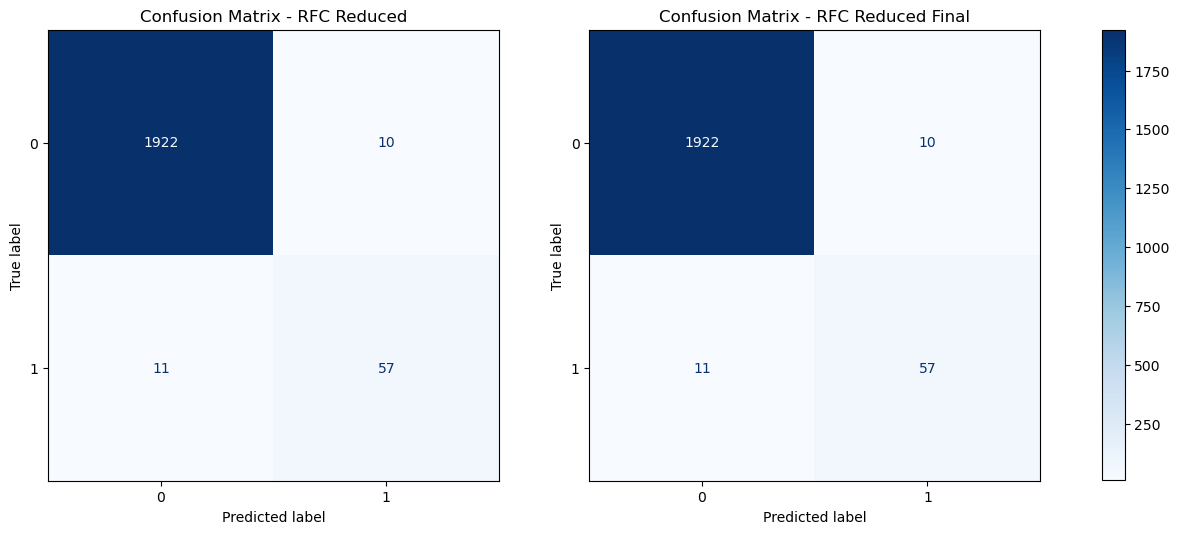

In [127]:
fig, ax = plt.subplots(1,2,figsize=(16, 9))
images = []
disp = ConfusionMatrixDisplay(confusion_matrix=pipelines_resultados['RFC_Reduced'][-1])
disp.plot(cmap='Blues', ax=ax[0], colorbar = False)
ax[0].set_title(f'Confusion Matrix - RFC Reduced')
images.append(ax[0].images[0])
    
disp = ConfusionMatrixDisplay(confusion_matrix=pipelines_resultados['RFC_Reduced_Final'][-1])
disp.plot(cmap='Blues', ax=ax[1], colorbar = False)
ax[1].set_title(f'Confusion Matrix - RFC Reduced Final')
images.append(ax[1].images[0])

fig.colorbar(images[-1], ax=ax, location='right', shrink=0.65)

## Results

Our model was fine tunned, however it did not yield any difference from the previous one.

# Conclusions

The best model we had to predict failures was a pipeline with a Random Forest Classifier, with the parameters shown in the next cell.

We also tested a Logistic Regression and a XGBoost Classifier, being the last one a bit short from the RFC, but not a bad choice.

From 2000 test data, our RFC correctly predicted 57 failures among 68 in total, leaving 11 false negatives behind. It also predicted 1922 no failures correctly, and gave 10 false positives of machine failure.

That being said, if no machine learning project was deployed in this business, there would be 68 machine failures during the studied period. With our model, there would be just 11 failures, and 57+10 machine stops to do a predictive maintenance, which is usually far less expensive that corrective maintenance. 

## Business Impact

Taking into account that usually a predictive maintenance downtime is at maximum 4h, and a corrective maintenance downtime takes usually much longer than that, even depending on outside support, it could surpass 24h easily, or even 48 hours.

FOr the sake of our analysis, let's take into account a scenario where we did not have any machine monitoring, which accounted for 68 total machine failures, whereas our model predicted 57 of them correctly, with some misslabelling:

Without machine data monitoring: 68 failures * 24 hours --> Total of 1632 hours of machine downtime

With the presented model: 57 predicted failures + 10 false positives * 4 hours of intervention: 268 hours
                            11 false negatives, leading to machine failures * 24 hours: 264 hours
                                                                                    total: 532 hours of machine downtime

### Results:

Our Predictive machinery model has a potential of **reducing a total of 1100 hours of maintenance** for the business, representing a **total of 67% of downtime reduction**





## Next Steps

Our data contained not only if the machine fails or not, but why it fails. The next lab will be focused on if our model is capable of finding what is the cause of machine failure

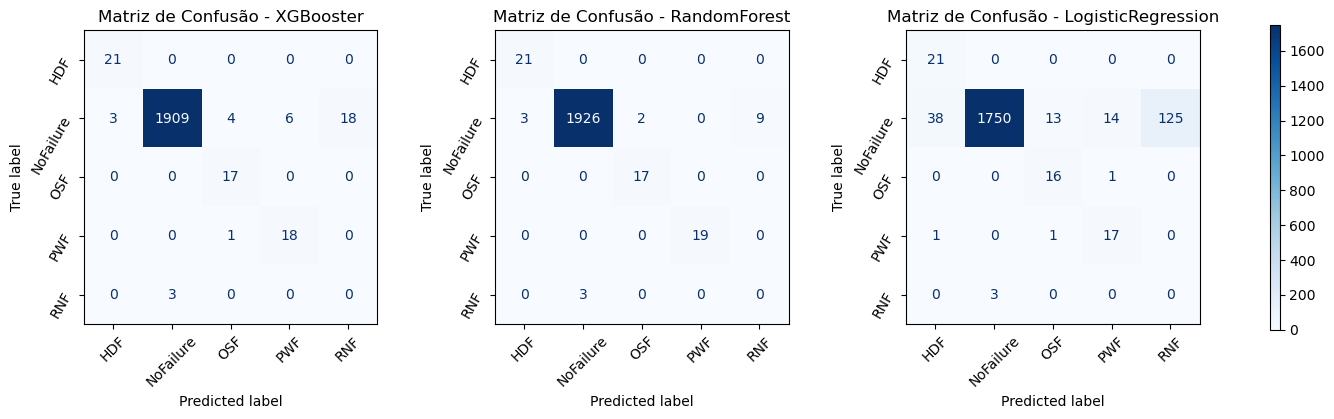

In [198]:
fig, ax = plt.subplots(1,3,figsize=(18, 12))
plt.subplots_adjust(wspace=0.4)
cm = []
images = []

for i, algoritmo in enumerate(yhat):
    cm.append(confusion_matrix(y_test, yhat[algoritmo]))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm[i], display_labels=['HDF','NoFailure','OSF','PWF','RNF'])
    disp.plot(cmap='Blues', ax=ax[i], colorbar = False)
    ax[i].set_title(f'Matriz de Confusão - {chaves[i]}')
    ax[i].set_xticklabels(['HDF','NoFailure','OSF','PWF','RNF'],rotation = 45)
    ax[i].set_yticklabels(['HDF','NoFailure','OSF','PWF','RNF'],rotation = 60)
    images.append(ax[i].images[0])
    
fig.colorbar(images[-1], ax=ax, location='right', shrink=0.33, aspect = 30)
    

In [200]:
features_names = modelos_resultados[1].named_steps['preprocessor'].get_feature_names_out()
importances = modelos_resultados[1].named_steps['classifier'].feature_importances_
plotao = pd.DataFrame({'feature': [f[5:] for f in features_names],
                    'importances':importances})

features_names = modelos_resultados[0].named_steps['preprocessor'].get_feature_names_out()
importances = modelos_resultados[0].named_steps['classifier'].feature_importances_
plotao2 = pd.DataFrame({'feature': [f[5:] for f in features_names],
                    'importances':importances})

for i,valor in enumerate(importances):
    print(f'feature RF: {features_names[i][5:]}, value: {valor:.3f}')

print('\n')    

feature RF: Air temperature [K], value: 0.057
feature RF: Process temperature [K], value: 0.031
feature RF: Rotational speed [rpm], value: 0.117
feature RF: Tool wear [min], value: 0.104
feature RF: AirProcessTemperature, value: 0.132
feature RF: TorqueRPM, value: 0.154
feature RF: Torque [Nm], value: 0.167
feature RF: TorqueWear, value: 0.163
feature RF: Type, value: 0.077




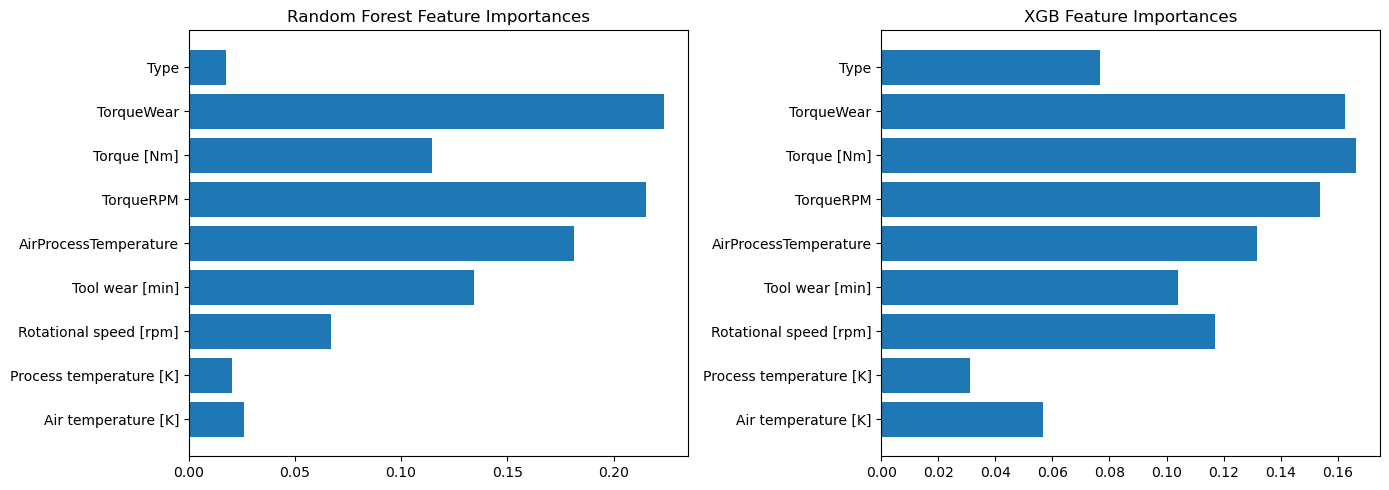

In [201]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].barh(plotao['feature'],plotao['importances'])
ax[0].set_title('Random Forest Feature Importances')

ax[1].barh(plotao2['feature'],plotao2['importances'])
ax[1].set_title('XGB Feature Importances')

plt.tight_layout()
plt.show()

In [204]:
features_continuas = ['TorqueWear','TorqueRPM','AirProcessTemperature','Torque [Nm]','Tool wear [min]','Rotational speed [rpm]']
#features_categoricas = ['Type']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), features_continuas)#,
        #('cat', OrdinalEncoder(categories = [['L', 'M', 'H']]), features_categoricas)
    ])

pipe2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', BorderlineSMOTE(random_state=42)), # Trata o desbalanceamento
    ('classifier', modelos['Random Forest']) 
])

X_train, X_test, y_train, y_test = train_test_split(X_new, y_encoded_new, test_size=0.2, random_state=42,stratify = y_encoded_new)

cv = StratifiedKFold(n_splits = 5,random_state=42, shuffle = True)

results = cross_validate(pipe2, X_train, y_train, cv = cv, scoring = 'f1_weighted',return_train_score=True)

pipe2.fit(X_train, y_train)
yhat_rf2 = pipe2.predict(X_test)

print(f"RF new train score:{np.mean(results['train_score']):.3f} - RF new validation score:{np.mean(results['test_score']):.3f}")

print(f" RF new test score \n {classification_report(y_test,yhat_rf2)}")

RF new train score:0.995 - RF new validation score:0.990
 RF new test score 
               precision    recall  f1-score   support

           0       0.84      1.00      0.91        21
           1       1.00      0.99      0.99      1940
           2       0.77      1.00      0.87        17
           3       1.00      1.00      1.00        19
           4       0.00      0.00      0.00         3

    accuracy                           0.99      2000
   macro avg       0.72      0.80      0.76      2000
weighted avg       0.99      0.99      0.99      2000



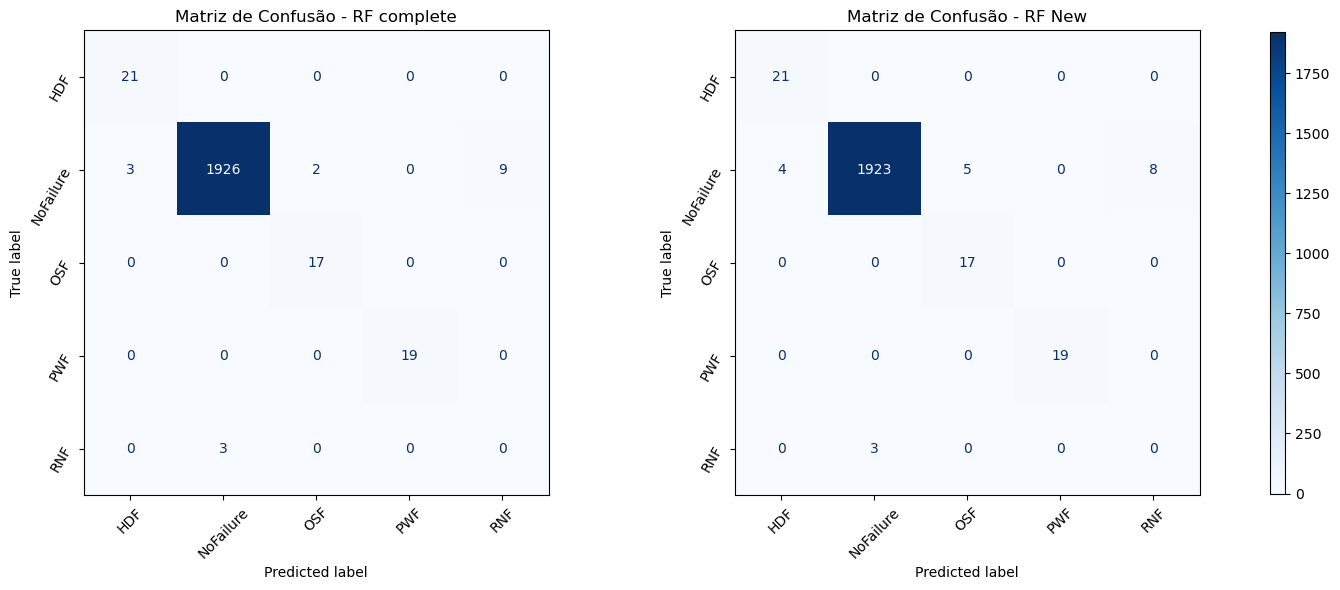

In [205]:
fig, ax = plt.subplots(1,2,figsize=(18, 12))
plt.subplots_adjust(wspace=0.4)
labe = ['RF complete','RF New']
cm = []
images = []

for i, algoritmo in enumerate([yhat['RandomForest'],yhat_rf2]):
    cm.append(confusion_matrix(y_test, algoritmo))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm[i], display_labels=['HDF','NoFailure','OSF','PWF','RNF'])
    disp.plot(cmap='Blues', ax=ax[i], colorbar = False)
    ax[i].set_title(f'Matriz de Confusão - {labe[i]}')
    ax[i].set_xticklabels(['HDF','NoFailure','OSF','PWF','RNF'],rotation = 45)
    ax[i].set_yticklabels(['HDF','NoFailure','OSF','PWF','RNF'],rotation = 60)
    images.append(ax[i].images[0])
    
fig.colorbar(images[-1], ax=ax, location='right', shrink=0.5, aspect = 30)

Com estes valores, não da para descartar feature sem perder um pouco de acurácia no modelo. Melhor manter o modelo completo, e otimizar em cima disto.

In [250]:
features_continuas = X_new.drop(columns = 'Type').columns.tolist()
features_categoricas = ['Type']

X_train, X_test, y_train, y_test = train_test_split(X_new, y_TWF, test_size=0.2, random_state=42,stratify = y_TWF)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_resultados = []
scores = []

modelos = {'XGBooster': XGBClassifier(
        n_estimators = 500,
        learning_rate = 0.051356,
        max_depth = 6,
        subsample = 0.936868,
        colsample_bytree = 0.57771,
        reg_alpha = 0.07255,
        reg_lambda = 0.0506,
        min_child_weight = 4,
        gamma = 0.1,
        #num_class=5,
        objective='binary:logistic',
        random_state=42,
        tree_method='hist',
        eval_metric='logloss'
    ),
        'Random Forest':RandomForestClassifier(
        n_estimators = 329,
        max_depth = 29,
        min_samples_split = 3,
        min_samples_leaf = 2,
        max_features = 'log2',
        class_weight = None
    ),
        'Logistic Regression': LogisticRegression(
        penalty = 'l2',
        C = 43.8752,
        solver = 'lbfgs',
        max_iter = 1000
    )}
        
sampler = [SMOTE(sampling_strategy = 0.1,random_state=42),BorderlineSMOTE(sampling_strategy = 0.1,random_state=42)]



    ])

# ======================== Create pipeline and check all the models ================================

for k,(nome,pedro) in enumerate(modelos.items()):
    if k == 0:
        i = 0
    else:
        i = 1
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('sampler', sampler[i]), # Trata o desbalanceamento
        ('under', RandomUnderSampler(sampling_strategy=0.25, random_state=42)),
        ('classifier', pedro)
    ])
    scores.append(cross_validate(pipe, X_train, y_train, cv=cv, scoring = 'f1_weighted',return_train_score=True))
    modelos_resultados.append(pipe)

InvalidParameterError: The 'scoring' parameter of cross_validate must be a str among {'neg_negative_likelihood_ratio', 'precision_samples', 'adjusted_rand_score', 'balanced_accuracy', 'jaccard', 'precision_macro', 'completeness_score', 'neg_mean_absolute_error', 'neg_median_absolute_error', 'precision_weighted', 'f1', 'precision_micro', 'roc_auc_ovr', 'precision', 'matthews_corrcoef', 'recall_micro', 'neg_root_mean_squared_error', 'v_measure_score', 'recall_weighted', 'jaccard_samples', 'normalized_mutual_info_score', 'f1_weighted', 'roc_auc_ovr_weighted', 'average_precision', 'jaccard_macro', 'accuracy', 'roc_auc_ovo', 'neg_mean_squared_error', 'rand_score', 'neg_mean_poisson_deviance', 'roc_auc', 'explained_variance', 'adjusted_mutual_info_score', 'jaccard_micro', 'neg_mean_gamma_deviance', 'd2_absolute_error_score', 'roc_auc_ovo_weighted', 'neg_log_loss', 'jaccard_weighted', 'neg_brier_score', 'neg_root_mean_squared_log_error', 'recall_macro', 'neg_mean_squared_log_error', 'f1_samples', 'recall', 'f1_macro', 'mutual_info_score', 'neg_max_error', 'recall_samples', 'positive_likelihood_ratio', 'r2', 'f1_micro', 'top_k_accuracy', 'homogeneity_score', 'fowlkes_mallows_score', 'neg_mean_absolute_percentage_error'}, a callable, an instance of 'list', an instance of 'tuple', an instance of 'dict' or None. Got 'avg_prec' instead.

In [235]:
yhat

{'XGBooster': array([[1., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0.],
        ...,
        [1., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0.]], shape=(2000, 5)),
 'RandomForest': [],
 'LogisticRegression': []}

In [246]:
yhat = {'XGBooster':[],'RandomForest':[],'LogisticRegression':[]}
chaves = list(yhat.keys())

for k,modelo in enumerate(modelos_resultados):
    modelo.fit(X_train,y_train)
    yhat[chaves[k]] = modelo.predict(X_test)

    print(f"Predictor performance analysis: {chaves[k]}\n {classification_report(y_test,yhat[chaves[k]],target_names=['NoFailure','TWF'])}")   

Predictor performance analysis: XGBooster
               precision    recall  f1-score   support

   NoFailure       1.00      0.98      0.99      1991
         TWF       0.03      0.11      0.05         9

    accuracy                           0.98      2000
   macro avg       0.51      0.55      0.52      2000
weighted avg       0.99      0.98      0.99      2000

Predictor performance analysis: RandomForest
               precision    recall  f1-score   support

   NoFailure       1.00      1.00      1.00      1991
         TWF       0.12      0.11      0.12         9

    accuracy                           0.99      2000
   macro avg       0.56      0.55      0.56      2000
weighted avg       0.99      0.99      0.99      2000

Predictor performance analysis: LogisticRegression
               precision    recall  f1-score   support

   NoFailure       1.00      0.96      0.98      1991
         TWF       0.05      0.56      0.10         9

    accuracy                           0.

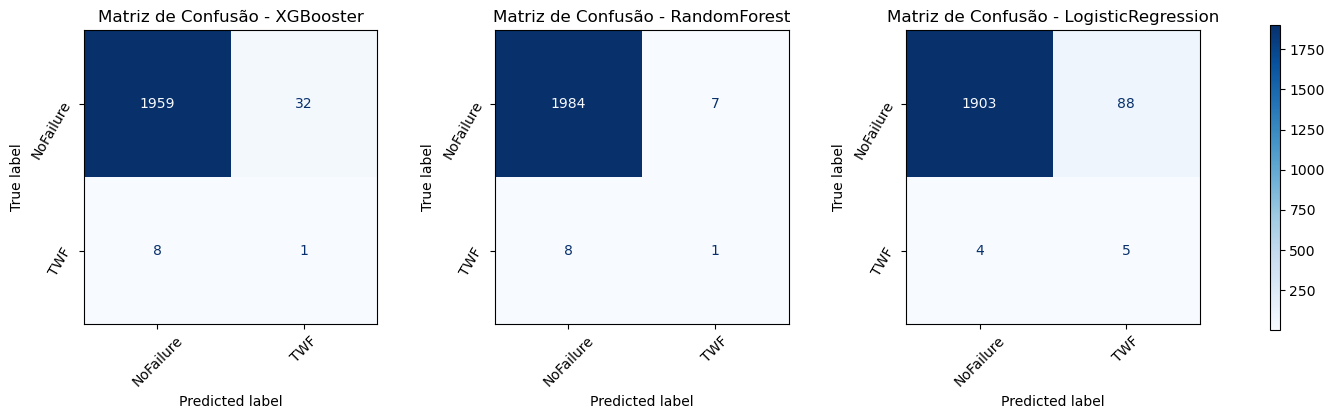

In [247]:
fig, ax = plt.subplots(1,3,figsize=(18, 12))
plt.subplots_adjust(wspace=0.4)
cm = []
images = []

for i, algoritmo in enumerate(yhat):
    cm.append(confusion_matrix(y_test, yhat[algoritmo]))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm[i], display_labels=['NoFailure','TWF'])
    disp.plot(cmap='Blues', ax=ax[i], colorbar = False)
    ax[i].set_title(f'Matriz de Confusão - {chaves[i]}')
    ax[i].set_xticklabels(['NoFailure','TWF'],rotation = 45)
    ax[i].set_yticklabels(['NoFailure','TWF'],rotation = 60)
    images.append(ax[i].images[0])
    
fig.colorbar(images[-1], ax=ax, location='right', shrink=0.33, aspect = 30)
    

In [270]:
dados

[<bound method Series.to_numpy of shape: (9_954,)
 Series: 'Tool wear [min]' [i64]
 [
 	0
 	3
 	5
 	7
 	9
 	…
 	14
 	17
 	22
 	25
 	30
 ]>,
 <bound method Series.to_numpy of shape: (9_954,)
 Series: 'Tool wear [min]' [i64]
 [
 	0
 	3
 	5
 	7
 	9
 	…
 	14
 	17
 	22
 	25
 	30
 ]>]

 total TWF Failures:46


[Text(1, 0, 'No Failure'), Text(2, 0, 'Failed Tool')]

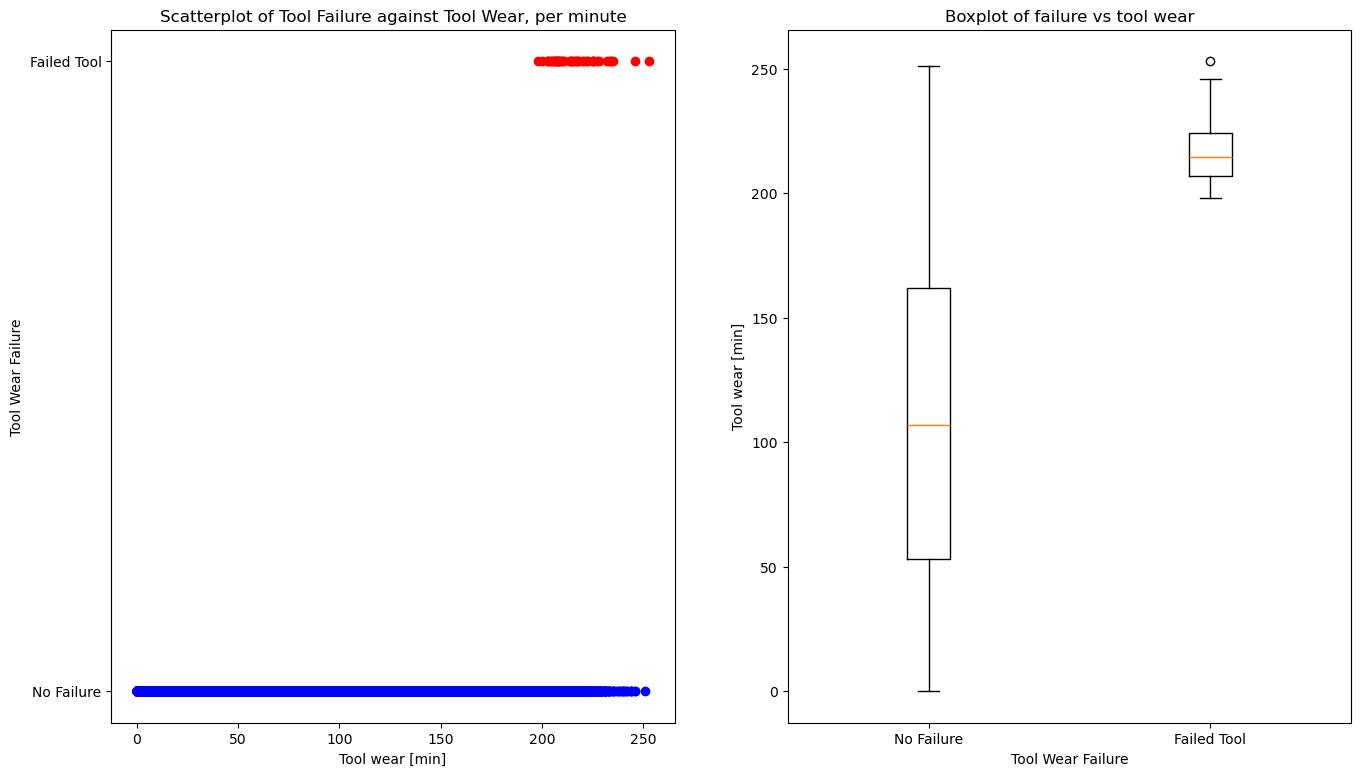

In [276]:
print(f" total TWF Failures:{df['TWF'].sum()}")

fig, ax = plt.subplots(1,2,figsize=(16,9))

#ax[0].hist(df.filter((pl.col('Tool wear [min]')>=200)  & (pl.col('TWF')==1)).select(['Tool wear [ min]'))
#ax[1].hist(df.filter((pl.col('Tool wear [min]')>=200)  & (pl.col('TWF')==0)).select(['Tool wear [ min]']))

ax[0].scatter(data = df.filter((pl.col('TWF')==0)).select(['Tool wear [min]','TWF']), x = 'Tool wear [min]', y = 'TWF', color = 'blue')
ax[0].scatter(data = df.filter((pl.col('TWF')==1)).select(['Tool wear [min]','TWF']), x = 'Tool wear [min]', y = 'TWF', color = 'red')
ax[0].set_title('Scatterplot of Tool Failure against Tool Wear, per minute')
ax[0].set_xlabel('Tool wear [min]')
ax[0].set_ylabel('Tool Wear Failure')
ax[0].set_yticks([0, 1])
ax[0].set_yticklabels(['No Failure', 'Failed Tool'])


groups = df['TWF'].unique().sort().to_list()
dados = [df.filter(pl.col('TWF') == i)['Tool wear [min]'].to_numpy() for i in groups] 

ax[1].boxplot(dados, labels = groups)
ax[1].set_title('Boxplot of failure vs tool wear')
ax[1].set_xlabel('Tool Wear Failure')
ax[1].set_ylabel('Tool wear [min]')
#ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(['No Failure', 'Failed Tool'])


Let's try an categorical feature to see if our model performs well.